Loaded: density1.0000_damping0.005_lm500_bias_summary.pkl rows: 189
Loaded: density1.0000_damping0.005_lm750_bias_summary.pkl rows: 189
Loaded: density1.0000_damping0.005_lm1000_bias_summary.pkl rows: 189
Loaded: density1.0000_damping0.005_lm1500_bias_summary.pkl rows: 189
Loaded: density1.0000_damping0.005_lm2000_bias_summary.pkl rows: 189
linear_mass = 500, median mass ratio = 0.289857, range = [0.227317, 0.345059]
linear_mass = 750, median mass ratio = 0.191435, range = [0.136114, 0.226542]
linear_mass = 1000, median mass ratio = 0.142232, range = [0.107267, 0.179360]
linear_mass = 1500, median mass ratio = 0.097973, range = [0.070585, 0.120293]
linear_mass = 2000, median mass ratio = 0.069730, range = [0.049168, 0.090879]


C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\4091621526.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\4091621526.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\4091621526.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)


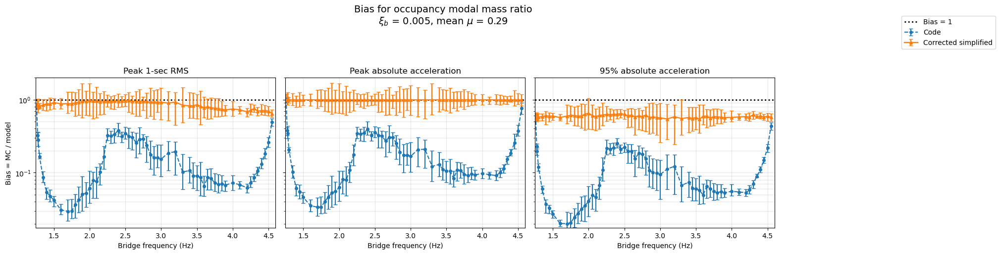

C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\4091621526.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\4091621526.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\4091621526.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)


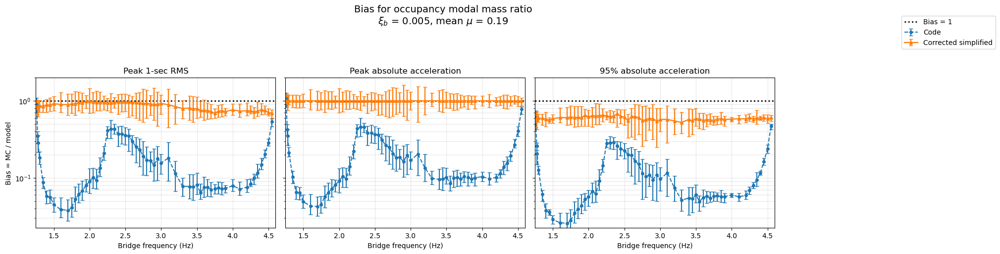

C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\4091621526.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\4091621526.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\4091621526.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)


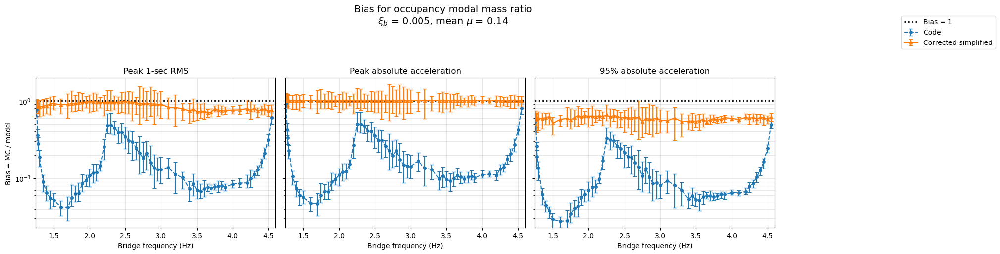

C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\4091621526.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\4091621526.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\4091621526.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)


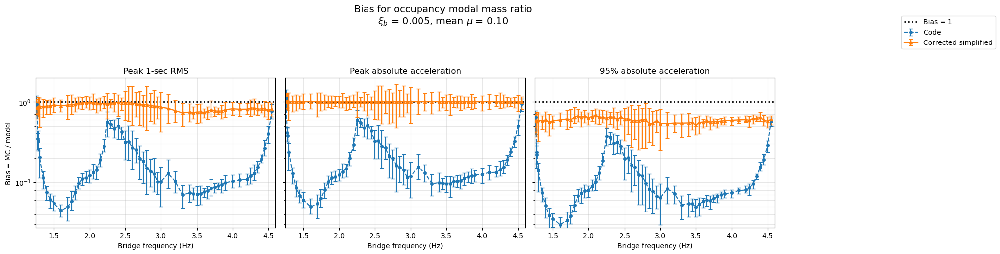

C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\4091621526.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\4091621526.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\4091621526.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)


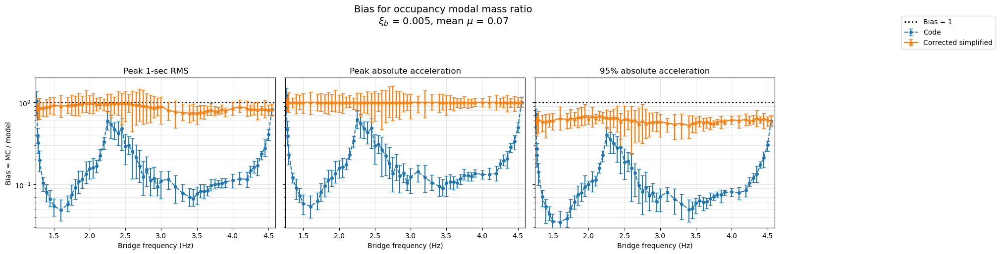

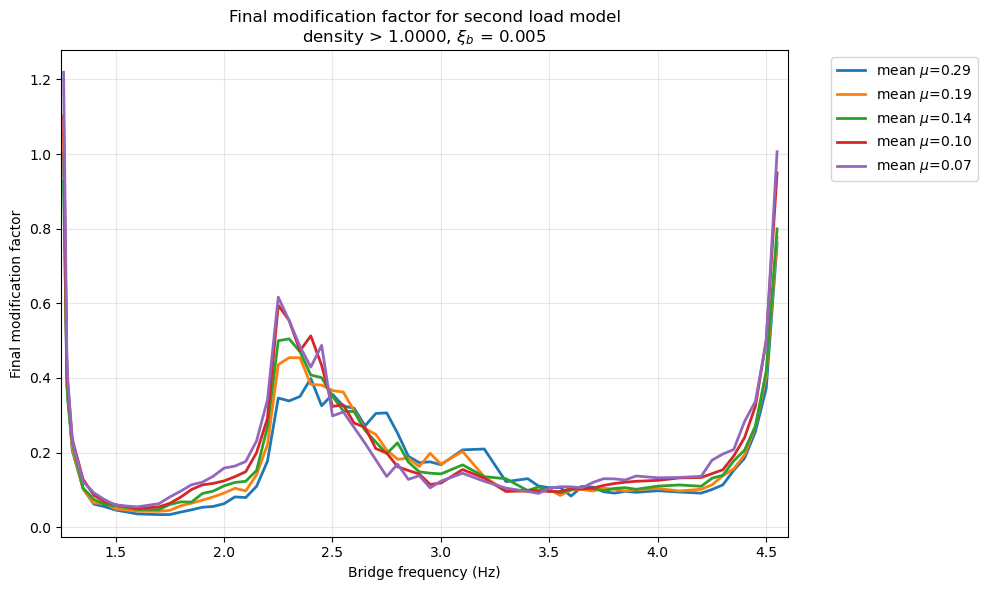

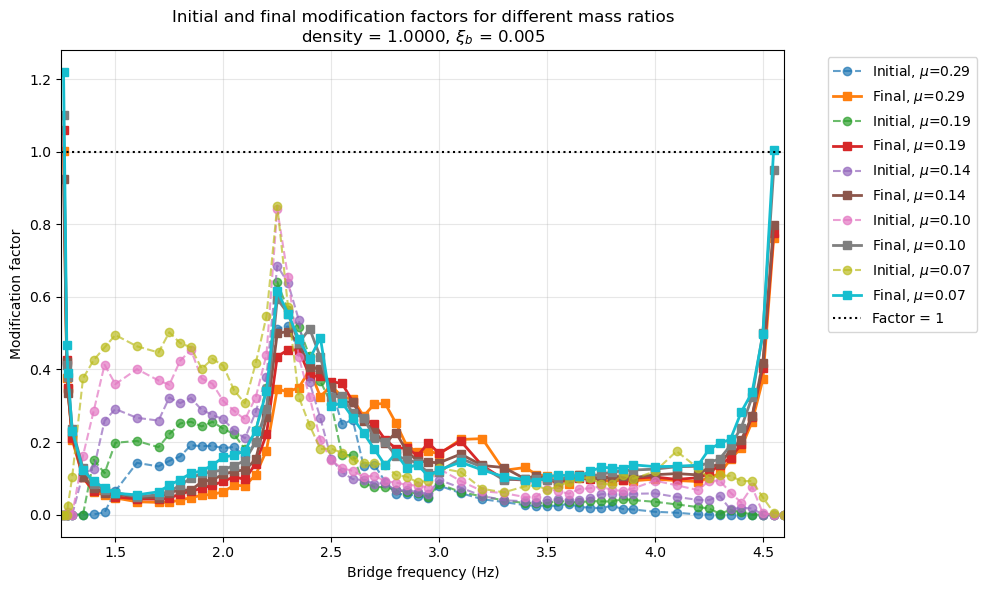

In [13]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# LOAD NEW SAVED FILES AND PLOT BY MASS RATIO
# ==================================================

TARGET_DENSITY = 1.0000
TARGET_DAMPINGS = [0.005]
LINEAR_MASS_VALUES = [500.0, 750.0, 1000.0, 1500.0, 2000.0]

PLOT_FMIN = 1.25
PLOT_FMAX = 4.60

MEASURES_TO_PLOT = [
    "Peak 1-sec RMS",
    "Peak absolute acceleration",
    "95% absolute acceleration",
]

SAVE_PLOTS = False

YMIN = 0.10
YMAX = 3.00


# ==================================================
# FILE NAME HELPER
# ==================================================

def make_summary_filename(density, target_beamdamp, linear_mass):
    return (
        f"density{density:.4f}"
        f"_damping{target_beamdamp:.3f}"
        f"_lm{linear_mass:.0f}"
        f"_bias_summary.pkl"
    )


# ==================================================
# LOAD FILES
# ==================================================

all_dfs = []

for damp in TARGET_DAMPINGS:
    for lm in LINEAR_MASS_VALUES:

        fname = make_summary_filename(TARGET_DENSITY, damp, lm)

        if not os.path.exists(fname):
            print("Missing file, skipped:", fname)
            continue

        with open(fname, "rb") as f:
            df_i = pickle.load(f)

        df_i["source_file"] = fname
        df_i["linear_mass_case"] = lm

        all_dfs.append(df_i)

        print("Loaded:", fname, "rows:", len(df_i))

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching summary PKL files were loaded.")

combined_df = pd.concat(all_dfs, ignore_index=True)


# ==================================================
# CLEAN DATA
# ==================================================

numeric_cols = [
    "bridge_frequency",
    "target_beamdamp",
    "target_density",
    "actual_density",
    "linear_mass",
    "linear_mass_case",
    "mean_modal_mass_ratio",
    "mass_ratio_used_for_interpolation",
    "initial_modification_factor",
    "final_modification_factor",
    "code_bias_mean",
    "code_bias_p5",
    "code_bias_p50",
    "code_bias_p95",
    "corrected_bias_mean",
    "corrected_bias_p5",
    "corrected_bias_p50",
    "corrected_bias_p95",
]

for col in numeric_cols:
    if col in combined_df.columns:
        combined_df[col] = pd.to_numeric(combined_df[col], errors="coerce")

combined_df = combined_df[
    (combined_df["bridge_frequency"] >= PLOT_FMIN) &
    (combined_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

combined_df = combined_df[
    np.isclose(combined_df["target_density"], TARGET_DENSITY)
].copy()

if combined_df.empty:
    raise ValueError("No rows left after filtering.")


# ==================================================
# MASS RATIO LABELS
# ==================================================

mass_ratio_labels = {}

for lm in LINEAR_MASS_VALUES:

    sub = combined_df[np.isclose(combined_df["linear_mass"], lm)]

    if sub.empty:
        continue

    mu_med = np.nanmedian(sub["mean_modal_mass_ratio"])
    mu_min = np.nanmin(sub["mean_modal_mass_ratio"])
    mu_max = np.nanmax(sub["mean_modal_mass_ratio"])

    mass_ratio_labels[lm] = (
        rf"$m_L$={lm:.0f} kg/m, "
        rf"$\mu$={mu_med:.3f}"
    )

    print(
        f"linear_mass = {lm:.0f}, "
        f"median mass ratio = {mu_med:.6f}, "
        f"range = [{mu_min:.6f}, {mu_max:.6f}]"
    )


# ==================================================
# HELPER: ERROR BAR
# ==================================================

def make_yerr(df, mean_col, p5_col, p95_col):
    lower = df[mean_col].to_numpy() - df[p5_col].to_numpy()
    upper = df[p95_col].to_numpy() - df[mean_col].to_numpy()

    lower = np.maximum(lower, 0.0)
    upper = np.maximum(upper, 0.0)

    return np.vstack([lower, upper])


# ==================================================
# PLOT 1:
# BIAS FOR DIFFERENT MASS RATIOS
# ONE SEPARATE FIGURE PER MASS RATIO
# ==================================================

for lm in LINEAR_MASS_VALUES:

    lm_df = combined_df[np.isclose(combined_df["linear_mass"], lm)].copy()

    if lm_df.empty:
        continue

    mu_med = np.nanmedian(lm_df["mean_modal_mass_ratio"])

    for damp in TARGET_DAMPINGS:

        damp_df = lm_df[np.isclose(lm_df["target_beamdamp"], damp)].copy()

        if damp_df.empty:
            continue

        n_measures = len(MEASURES_TO_PLOT)

        fig, axes = plt.subplots(
            nrows=1,
            ncols=n_measures,
            figsize=(6.0 * n_measures, 5.2),
            sharex=True,
            sharey=True
        )

        if n_measures == 1:
            axes = [axes]

        for ax, measure_name in zip(axes, MEASURES_TO_PLOT):

            sub = damp_df[
                damp_df["measure"].astype(str) == measure_name
            ].copy()

            if sub.empty:
                ax.set_title(measure_name + "\nNo data")
                ax.axis("off")
                continue

            sub = sub.sort_values("bridge_frequency")

            ax.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                color="black",
                label="Bias = 1"
            )

            ax.errorbar(
                sub["bridge_frequency"],
                sub["code_bias_mean"],
                yerr=make_yerr(
                    sub,
                    "code_bias_mean",
                    "code_bias_p5",
                    "code_bias_p95"
                ),
                marker="o",
                markersize=4,
                capsize=3,
                linewidth=1.5,
                linestyle="--",
                label="Code"
            )

            ax.errorbar(
                sub["bridge_frequency"],
                sub["corrected_bias_mean"],
                yerr=make_yerr(
                    sub,
                    "corrected_bias_mean",
                    "corrected_bias_p5",
                    "corrected_bias_p95"
                ),
                marker="^",
                markersize=4,
                capsize=3,
                linewidth=1.7,
                linestyle="-",
                label="Corrected simplified"
            )

            ax.set_title(measure_name)
            ax.set_xlabel("Bridge frequency (Hz)")
            ax.set_xlim(PLOT_FMIN, PLOT_FMAX)

            ax.set_yscale("log")
            ax.set_ylim(0, 2)

            ax.grid(True, which="both", alpha=0.3)

        axes[0].set_ylabel("Bias = MC / model")

        handles, labels = axes[0].get_legend_handles_labels()

        fig.legend(
            handles,
            labels,
            bbox_to_anchor=(1.01, 0.95),
            loc="upper left"
        )

        fig.suptitle(
            f"Bias for occupancy modal mass ratio\n"
            rf"$\xi_b$ = {damp:.3f}, "
            rf"mean $\mu$ = {mu_med:.2f}",
            fontsize=14
        )

        fig.tight_layout(rect=[0, 0, 0.88, 0.88])

        if SAVE_PLOTS:
            fig_name = (
                f"bias_density{TARGET_DENSITY:.4f}_"
                f"damping{damp:.3f}_"
                f"lm{lm:.0f}_"
                f"mu{mu_med:.3f}.png"
            )
            fig.savefig(fig_name, dpi=300, bbox_inches="tight")
            print("Saved:", fig_name)

        plt.show()


# ==================================================
# PLOT 2:
# MODIFICATION FACTORS FOR DIFFERENT MASS RATIOS
# SAME PLOT
# ==================================================

factor_df = combined_df.drop_duplicates(
    subset=[
        "bridge_frequency",
        "target_beamdamp",
        "target_density",
        "linear_mass",
    ]
).copy()

for damp in TARGET_DAMPINGS:

    sub_damp = factor_df[
        np.isclose(factor_df["target_beamdamp"], damp)
    ].copy()

    if sub_damp.empty:
        continue

    plt.figure(figsize=(10, 6))

    for lm in LINEAR_MASS_VALUES:

        sub = sub_damp[
            np.isclose(sub_damp["linear_mass"], lm)
        ].copy()

        if sub.empty:
            continue

        sub = sub.sort_values("bridge_frequency")

        mu_med = np.nanmedian(sub["mean_modal_mass_ratio"])

        plt.plot(
            sub["bridge_frequency"],
            sub["final_modification_factor"],
            linewidth=2,
            label=rf"mean $\mu$={mu_med:.2f}"
        )

    

    plt.xlabel("Bridge frequency (Hz)")
    plt.ylabel("Final modification factor")
    plt.title(
        f"Final modification factor for second load model\n"
        f"density > {TARGET_DENSITY:.4f}, "
        rf"$\xi_b$ = {damp:.3f}"
    )

    plt.xlim(PLOT_FMIN, PLOT_FMAX)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    if SAVE_PLOTS:
        fig_name = (
            f"final_factor_density{TARGET_DENSITY:.4f}_"
            f"damping{damp:.3f}_all_mass_ratios.png"
        )
        plt.savefig(fig_name, dpi=300, bbox_inches="tight")
        print("Saved:", fig_name)

    plt.show()


# ==================================================
# OPTIONAL:
# INITIAL AND FINAL FACTORS TOGETHER
# SAME PLOT, ALL MASS RATIOS
# ==================================================

for damp in TARGET_DAMPINGS:

    sub_damp = factor_df[
        np.isclose(factor_df["target_beamdamp"], damp)
    ].copy()

    if sub_damp.empty:
        continue

    plt.figure(figsize=(10, 6))

    for lm in LINEAR_MASS_VALUES:

        sub = sub_damp[
            np.isclose(sub_damp["linear_mass"], lm)
        ].copy()

        if sub.empty:
            continue

        sub = sub.sort_values("bridge_frequency")

        mu_med = np.nanmedian(sub["mean_modal_mass_ratio"])

        plt.plot(
            sub["bridge_frequency"],
            sub["initial_modification_factor"],
            linestyle="--",
            marker="o",
            linewidth=1.5,
            alpha=0.7,
            label=rf"Initial, $\mu$={mu_med:.2f}"
        )

        plt.plot(
            sub["bridge_frequency"],
            sub["final_modification_factor"],
            linestyle="-",
            marker="s",
            linewidth=2,
            label=rf"Final, $\mu$={mu_med:.2f}"
        )

    plt.axhline(
        1.0,
        linestyle=":",
        linewidth=1.5,
        color="black",
        label="Factor = 1"
    )

    plt.xlabel("Bridge frequency (Hz)")
    plt.ylabel("Modification factor")
    plt.title(
        f"Initial and final modification factors for different mass ratios\n"
        f"density = {TARGET_DENSITY:.4f}, "
        rf"$\xi_b$ = {damp:.3f}"
    )

    plt.xlim(PLOT_FMIN, PLOT_FMAX)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

Loaded old: Old OS density1.0000_damping0.005_0S_bias_summary.pkl rows: 102
Loaded old: Old OS125 density1.0000_damping0.005_0S125_bias_summary.pkl rows: 21
Loaded old: Old OS456 density1.0000_damping0.005_0S456_bias_summary.pkl rows: 66
Loaded new: New lm500 density1.0000_damping0.005_lm500_bias_summary.pkl rows: 189

Mass ratio check
----------------
New lm500 median mean_modal_mass_ratio = 0.2898566229330478
Old OS median mean_modal_mass_ratio = 0.2850446882922076
Old OS125 median mean_modal_mass_ratio = 0.2830083655416335
Old OS456 median mean_modal_mass_ratio = 0.2838687750940091


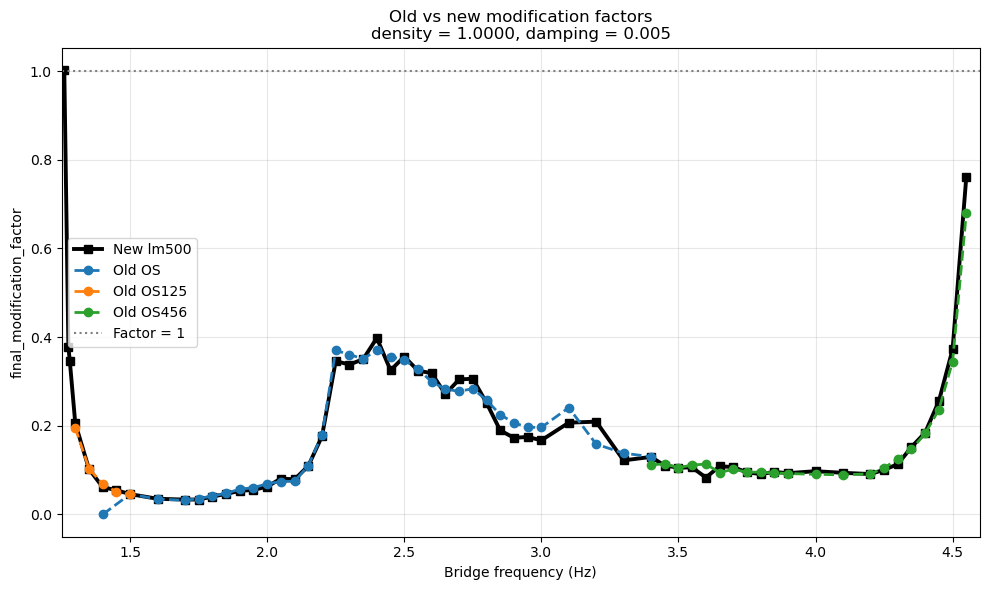

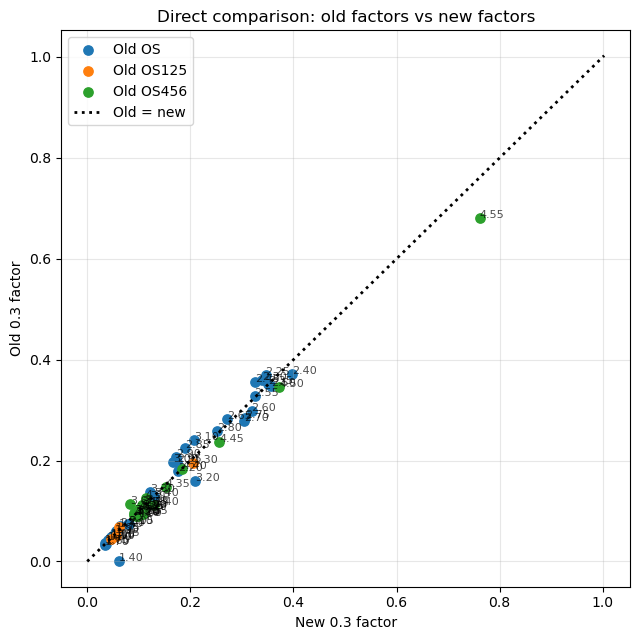

In [6]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# OLD vs NEW FACTOR COMPARISON
# Mass ratio about 0.30, density = 1.0000, damping = 0.005
# ==================================================

OLD_FILES = {
    "Old OS": "density1.0000_damping0.005_0S_bias_summary.pkl",
    "Old OS125": "density1.0000_damping0.005_0S125_bias_summary.pkl",
    "Old OS456": "density1.0000_damping0.005_0S456_bias_summary.pkl",
}


NEW_FILE = "density1.0000_damping0.005_lm500_bias_summary.pkl"
NEW_LABEL = "New lm500"

TARGET_DENSITY = 1.0000
TARGET_DAMPING = 0.005

FACTOR_COL = "final_modification_factor"
# You can change to:
# FACTOR_COL = "initial_modification_factor"

PLOT_FMIN = 1.25
PLOT_FMAX = 4.60

SAVE_PLOTS = False


# ==================================================
# LOAD HELPER
# ==================================================

def load_summary_pkl(filename, label):
    if not os.path.exists(filename):
        raise FileNotFoundError(f"Missing file: {filename}")

    with open(filename, "rb") as f:
        df = pickle.load(f)

    df = df.copy()
    df["case_label"] = label
    df["source_file"] = filename

    return df


# ==================================================
# LOAD DATA
# ==================================================

dfs = []

for label, fname in OLD_FILES.items():
    df_i = load_summary_pkl(fname, label)
    dfs.append(df_i)
    print("Loaded old:", label, fname, "rows:", len(df_i))

new_df = load_summary_pkl(NEW_FILE, NEW_LABEL)
dfs.append(new_df)

print("Loaded new:", NEW_LABEL, NEW_FILE, "rows:", len(new_df))

combined_df = pd.concat(dfs, ignore_index=True)


# ==================================================
# CLEAN DATA
# ==================================================

needed_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "measure",
    FACTOR_COL,
]

for col in needed_cols:
    if col not in combined_df.columns:
        raise KeyError(f"Column missing from loaded data: {col}")

numeric_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    FACTOR_COL,
    "mean_modal_mass_ratio",
    "mass_ratio_used_for_interpolation",
]

for col in numeric_cols:
    if col in combined_df.columns:
        combined_df[col] = pd.to_numeric(combined_df[col], errors="coerce")

combined_df = combined_df.dropna(
    subset=["bridge_frequency", "target_density", "target_beamdamp", FACTOR_COL]
).copy()

combined_df = combined_df[
    np.isclose(combined_df["target_density"], TARGET_DENSITY) &
    np.isclose(combined_df["target_beamdamp"], TARGET_DAMPING) &
    (combined_df["bridge_frequency"] >= PLOT_FMIN) &
    (combined_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

if combined_df.empty:
    raise ValueError("No rows left after filtering.")


# ==================================================
# FACTOR DATA ONLY
# Remove repeated rows from different response measures
# ==================================================

factor_df = combined_df.drop_duplicates(
    subset=[
        "case_label",
        "bridge_frequency",
        "target_density",
        "target_beamdamp",
    ]
).copy()

factor_df = factor_df.sort_values(["case_label", "bridge_frequency"])


# ==================================================
# PRINT MASS RATIO CHECK
# ==================================================

print("\nMass ratio check")
print("----------------")

for label in factor_df["case_label"].unique():
    sub = factor_df[factor_df["case_label"] == label]

    if "mean_modal_mass_ratio" in sub.columns:
        print(
            label,
            "median mean_modal_mass_ratio =",
            np.nanmedian(sub["mean_modal_mass_ratio"])
        )


# ==================================================
# PLOT 1: OVERLAY OLD AND NEW FACTORS vs FREQUENCY
# ==================================================

plt.figure(figsize=(10, 6))

for label in factor_df["case_label"].unique():

    sub = factor_df[factor_df["case_label"] == label].copy()
    sub = sub.sort_values("bridge_frequency")

    if label == NEW_LABEL:
        plt.plot(
            sub["bridge_frequency"],
            sub[FACTOR_COL],
            marker="s",
            linewidth=2.8,
            color="black",
            label=label
        )
    else:
        plt.plot(
            sub["bridge_frequency"],
            sub[FACTOR_COL],
            marker="o",
            linewidth=2,
            linestyle="--",
            label=label
        )

plt.axhline(
    1.0,
    linestyle=":",
    linewidth=1.5,
    color="gray",
    label="Factor = 1"
)

plt.xlabel("Bridge frequency (Hz)")
plt.ylabel(FACTOR_COL)
plt.title(
    f"Old vs new modification factors\n"
    f"density = {TARGET_DENSITY:.4f}, damping = {TARGET_DAMPING:.3f}"
)

plt.xlim(PLOT_FMIN, PLOT_FMAX)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

if SAVE_PLOTS:
    plt.savefig("old_vs_new_factor_vs_frequency.png", dpi=300, bbox_inches="tight")

plt.show()


# ==================================================
# PLOT 2: DIRECT OLD-vs-NEW FACTOR COMPARISON
# x-axis = new factor, y-axis = old factor
# ==================================================

new_factor = factor_df[factor_df["case_label"] == NEW_LABEL][
    ["bridge_frequency", FACTOR_COL]
].rename(columns={FACTOR_COL: "new_factor"})

plt.figure(figsize=(6.5, 6.5))

for old_label in OLD_FILES.keys():

    old_factor = factor_df[factor_df["case_label"] == old_label][
        ["bridge_frequency", FACTOR_COL]
    ].rename(columns={FACTOR_COL: "old_factor"})

    merged = pd.merge(
        new_factor,
        old_factor,
        on="bridge_frequency",
        how="inner"
    ).dropna()

    if merged.empty:
        print("No matching frequencies for:", old_label)
        continue

    plt.scatter(
        merged["new_factor"],
        merged["old_factor"],
        s=45,
        label=old_label
    )

    for _, row in merged.iterrows():
        plt.text(
            row["new_factor"],
            row["old_factor"],
            f"{row['bridge_frequency']:.2f}",
            fontsize=8,
            alpha=0.7
        )

all_vals = []

all_vals.extend(new_factor["new_factor"].dropna().to_list())

for old_label in OLD_FILES.keys():
    old_vals = factor_df[factor_df["case_label"] == old_label][FACTOR_COL].dropna()
    all_vals.extend(old_vals.to_list())

vmin = np.nanmin(all_vals)
vmax = np.nanmax(all_vals)

plt.plot(
    [vmin, vmax],
    [vmin, vmax],
    linestyle=":",
    linewidth=2,
    color="black",
    label="Old = new"
)

plt.xlabel("New 0.3 factor")
plt.ylabel("Old 0.3 factor")
plt.title("Direct comparison: old factors vs new factors")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

if SAVE_PLOTS:
    plt.savefig("old_vs_new_factor_parity.png", dpi=300, bbox_inches="tight")

plt.show()

     bridge_frequency  envelope_factor  envelope_linear_mass  \
762             1.260         1.219105                2000.0   
765             1.275         0.468407                2000.0   
768             1.280         0.389743                2000.0   
582             1.300         0.236375                1500.0   
585             1.350         0.127959                1500.0   
777             1.400         0.091684                2000.0   
780             1.450         0.073534                2000.0   
594             1.500         0.060319                1500.0   
786             1.600         0.054352                2000.0   
789             1.700         0.062886                2000.0   
792             1.750         0.080983                2000.0   
795             1.800         0.096454                2000.0   
798             1.850         0.113635                2000.0   
801             1.900         0.120497                2000.0   
804             1.950         0.136388  

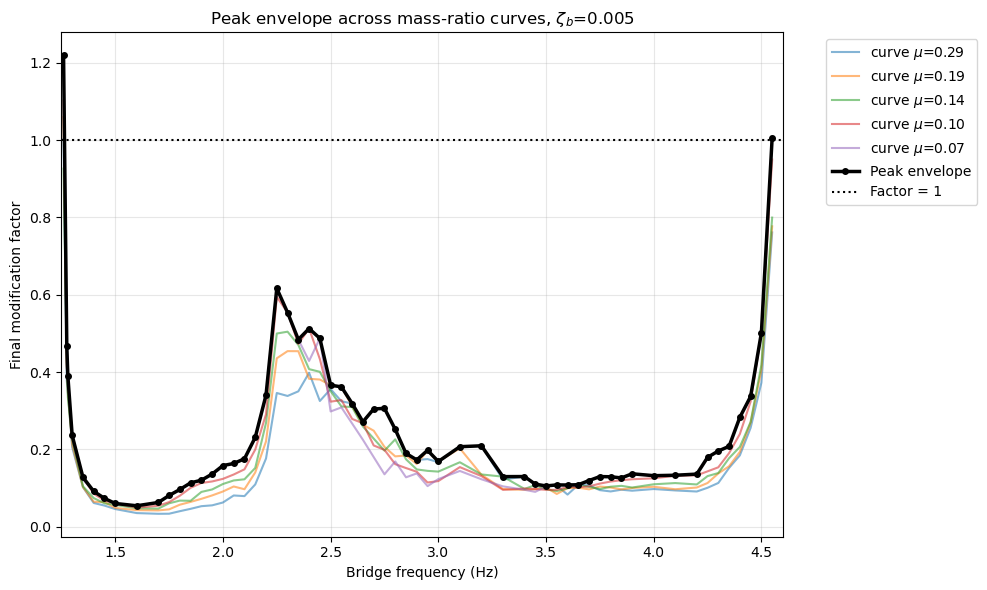

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# PEAK ENVELOPE ACROSS MASS-RATIO CURVES
# ==================================================

Y_COL = "final_modification_factor"
DAMPING_TO_USE = 0.005
TARGET_DENSITY = 1.0000

FMIN = 1.25
FMAX = 4.60

df = combined_df.copy()

for col in [
    "bridge_frequency",
    "target_beamdamp",
    "target_density",
    "linear_mass",
    "mean_modal_mass_ratio",
    Y_COL,
]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(
    subset=[
        "bridge_frequency",
        "target_beamdamp",
        "target_density",
        "linear_mass",
        "mean_modal_mass_ratio",
        Y_COL,
    ]
).copy()

df = df[
    np.isclose(df["target_beamdamp"], DAMPING_TO_USE) &
    np.isclose(df["target_density"], TARGET_DENSITY) &
    (df["bridge_frequency"] >= FMIN) &
    (df["bridge_frequency"] <= FMAX)
].copy()

# Remove repeated rows from the three response measures
df["freq_key"] = df["bridge_frequency"].round(6)

df_unique = df.drop_duplicates(
    subset=["freq_key", "linear_mass"],
    keep="first"
).copy()

# ==================================================
# Envelope: maximum factor at each frequency
# ==================================================

idx = df_unique.groupby("freq_key")[Y_COL].idxmax()

envelope_df = (
    df_unique
    .loc[idx]
    .copy()
    .sort_values("bridge_frequency")
)

envelope_df = envelope_df[
    [
        "bridge_frequency",
        Y_COL,
        "linear_mass",
        "mean_modal_mass_ratio",
    ]
].rename(
    columns={
        Y_COL: "envelope_factor",
        "linear_mass": "envelope_linear_mass",
        "mean_modal_mass_ratio": "envelope_mass_ratio",
    }
)

print(envelope_df.head(20))


# ==================================================
# Plot curves + peak envelope
# ==================================================

plt.figure(figsize=(10, 6))

for lm in sorted(df_unique["linear_mass"].unique()):

    sub = df_unique[
        np.isclose(df_unique["linear_mass"], lm)
    ].sort_values("bridge_frequency")

    mu_med = np.nanmedian(sub["mean_modal_mass_ratio"])

    plt.plot(
        sub["bridge_frequency"],
        sub[Y_COL],
        linewidth=1.5,
        alpha=0.55,
        label=rf"curve $\mu$={mu_med:.2f}"
    )

plt.plot(
    envelope_df["bridge_frequency"],
    envelope_df["envelope_factor"],
    "ko-",
    linewidth=2.5,
    markersize=4,
    label="Peak envelope"
)

plt.axhline(
    1.0,
    linestyle=":",
    linewidth=1.5,
    color="black",
    label="Factor = 1"
)

plt.xlabel("Bridge frequency (Hz)")
plt.ylabel("Final modification factor")
plt.title(
    rf"Peak envelope across mass-ratio curves, $\zeta_b$={DAMPING_TO_USE:.3f}"
)

plt.xlim(FMIN, FMAX)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Loading: density1.0000_damping0.005_lm1000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm1500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm2000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm750_bias_summary.pkl

Loaded combined dataframe shape: (945, 41)

Frequency coverage:
   linear_mass_key   min   max  count
0              500  1.26  4.55     60
1              750  1.26  4.55     60
2             1000  1.26  4.55     60
3             1500  1.26  4.55     60
4             2000  1.26  4.55     60

Number of fitting points: 50
Fitting frequency range: 1.5 to 4.4

Initial guesses
----------------
y0       = 0.052699
B        = 5.404707e-02
mu       = 0.183065
alpha    = 0.510706
zeta_a   = 0.399814
beta_p0  = 1.008401

Fitted parameters
-----------------
y0              = 0.00269915
B               = 8.51265033e-02
mu              = 0.22286233
alpha           = 0.59041978
zeta_b          = 0.00500000

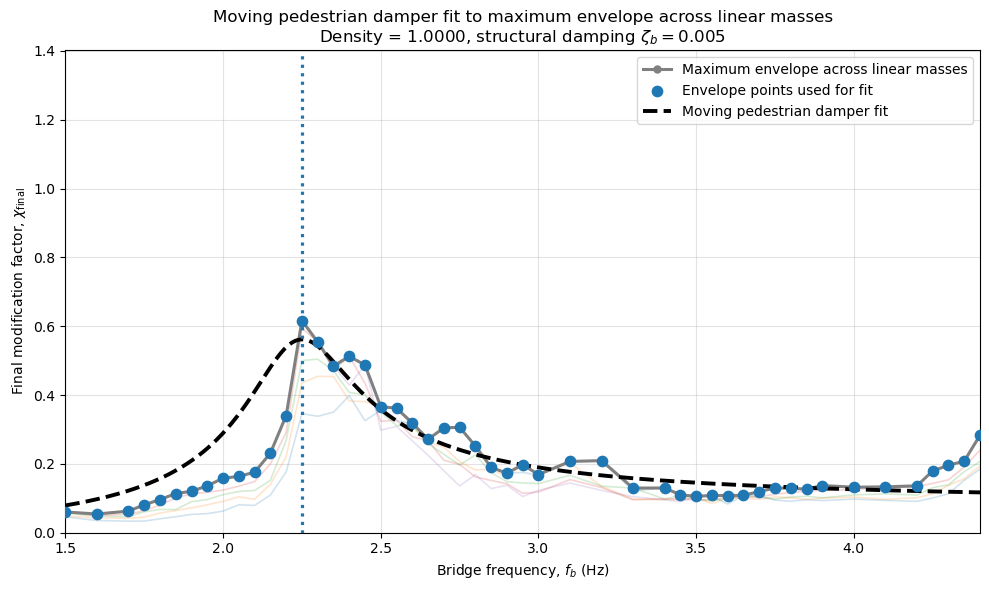


FINAL FITTED IDEAL MODIFICATION FACTOR EQUATION

Model form:
chi_ideal(f_b) = y0 + B * Q(beta_eff)
beta_eff       = beta_p * f_b / f_p
f_p            = 2.25 Hz

Fitted equation:
chi_ideal(f_b) = 0.002699 + 8.512650e-02 * Q(1.028471 * f_b / 2.250000)

Fitted parameters:
y0       = 0.00269915
B        = 8.51265033e-02
mu       = 0.22286233
alpha    = 0.59041978
zeta_b   = 0.00500000
zeta_a   = 0.32317373
beta_p   = 1.02847141
f_p      = 2.25000000 Hz


In [20]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import least_squares

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DENSITY = 1.0000
TARGET_DAMPING = 0.005

Y_COL = "final_modification_factor"

FIT_FMIN = 1.50
FIT_FMAX = 4.40

PLOT_FMIN = 1.50
PLOT_FMAX = 4.40

F_TARGET_PEAK = 2.25

zeta_b = TARGET_DAMPING

BETA_MIN = 0.20
BETA_MAX = 3.00
N_BETA_PEAK = 6000

eps = 1e-12


# ==================================================
# LOAD NEW lm FILES
# Expected names:
# density1.0000_damping0.005_lm500_bias_summary.pkl
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"lm(?P<linear_mass>\d+)_"
    r"bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_lm*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:

    match = pattern.match(file.name)

    if match is None:
        print("Skipping file because name does not match expected pattern:", file.name)
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_linear_mass = float(match.group("linear_mass"))

    # Keep only target density and damping
    if not np.isclose(file_density, TARGET_DENSITY):
        continue

    if not np.isclose(file_damping, TARGET_DAMPING):
        continue

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["linear_mass"] = file_linear_mass

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError(
        "No matching lm summary files found for "
        f"density={TARGET_DENSITY:.4f}, damping={TARGET_DAMPING:.3f}"
    )

corrected_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded combined dataframe shape:", corrected_df.shape)


# ==================================================
# CLEAN NUMERIC COLUMNS
# ==================================================

needed_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "linear_mass",
    Y_COL,
]

for col in needed_cols:
    corrected_df[col] = pd.to_numeric(corrected_df[col], errors="coerce")

corrected_df = corrected_df.dropna(subset=needed_cols).copy()

corrected_df["density_key"] = corrected_df["target_density"].round(4)
corrected_df["damping_key"] = corrected_df["target_beamdamp"].round(3)
corrected_df["linear_mass_key"] = corrected_df["linear_mass"].round(0).astype(int)

# Remove repeated rows if the pkl has multiple measures
sort_cols = ["linear_mass_key", "bridge_frequency"]

if "measure" in corrected_df.columns:
    corrected_df = corrected_df.sort_values(sort_cols)
    corrected_df = corrected_df.drop_duplicates(
        subset=["linear_mass_key", "bridge_frequency"],
        keep="first"
    ).copy()

corrected_df = corrected_df.sort_values(
    ["linear_mass_key", "bridge_frequency"]
).reset_index(drop=True)

print("\nFrequency coverage:")
coverage = (
    corrected_df
    .groupby("linear_mass_key")["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)
print(coverage)


# ==================================================
# MAXIMUM ENVELOPE ACROSS LINEAR MASSES
# ==================================================

env_df = (
    corrected_df
    .groupby("bridge_frequency", as_index=False)
    .agg(
        envelope_factor=(Y_COL, "max")
    )
    .sort_values("bridge_frequency")
)

fit_source_df = env_df.copy()

fit_df = fit_source_df[
    (fit_source_df["bridge_frequency"] >= FIT_FMIN) &
    (fit_source_df["bridge_frequency"] <= FIT_FMAX) &
    (fit_source_df["envelope_factor"] > 0)
].copy()

x_fit = fit_df["bridge_frequency"].to_numpy()
y_fit = fit_df["envelope_factor"].to_numpy()

if len(x_fit) < 8:
    raise ValueError("Too few envelope points in fitting range.")

print("\nNumber of fitting points:", len(x_fit))
print("Fitting frequency range:", x_fit.min(), "to", x_fit.max())


# ==================================================
# CLOSED-FORM MMD / TMD ACCELERATION SHAPE Q(beta)
# ==================================================

def Q_mmd(beta, mu, alpha, zeta_b, zeta_a):
    beta = np.asarray(beta, dtype=float)

    N_R = alpha**2 - beta**2
    N_I = 2.0 * zeta_a * alpha * beta

    D_R = (
        (1.0 - beta**2) * (alpha**2 - beta**2)
        - 4.0 * zeta_b * zeta_a * alpha * beta**2
        - mu * alpha**2 * beta**2
    )

    D_I = (
        2.0 * beta
        * (
            zeta_a * alpha * (1.0 - (1.0 + mu) * beta**2)
            + zeta_b * (alpha**2 - beta**2)
        )
    )

    numerator_abs = np.sqrt(N_R**2 + N_I**2)
    denominator_abs = np.sqrt(D_R**2 + D_I**2)

    return beta**2 * numerator_abs / (denominator_abs + 1e-14)


def beta_peak_for_parameters(mu, alpha, zeta_a, zeta_b):
    beta_grid = np.linspace(BETA_MIN, BETA_MAX, N_BETA_PEAK)

    Q_grid = Q_mmd(
        beta=beta_grid,
        mu=mu,
        alpha=alpha,
        zeta_b=zeta_b,
        zeta_a=zeta_a
    )

    return beta_grid[np.nanargmax(Q_grid)]


def chi_peak_locked_B_model(f_bridge, y0, B, mu, alpha, zeta_a):
    beta_p = beta_peak_for_parameters(
        mu=mu,
        alpha=alpha,
        zeta_a=zeta_a,
        zeta_b=zeta_b
    )

    beta_eff = beta_p * (f_bridge / F_TARGET_PEAK)

    Q_eff = Q_mmd(
        beta=beta_eff,
        mu=mu,
        alpha=alpha,
        zeta_b=zeta_b,
        zeta_a=zeta_a
    )

    return y0 + B * Q_eff


# ==================================================
# INITIAL GUESSES
# ==================================================

previous_fits = {
    0.005: {
        "y0": 0.12625630,
        "B":  1.57791445e-01,
        "mu": 0.18306454,
        "alpha": 0.51070586,
        "zeta_a": 0.39981395,
    },
    0.010: {
        "y0": 0.14782840,
        "B":  2.02927309e-01,
        "mu": 0.16074344,
        "alpha": 0.55129448,
        "zeta_a": 0.38537497,
    },
    0.020: {
        "y0": 0.19097260,
        "B":  2.93199037e-01,
        "mu": 0.11610124,
        "alpha": 0.63247172,
        "zeta_a": 0.35649701,
    },
}

if zeta_b in previous_fits:
    mu0 = previous_fits[zeta_b]["mu"]
    alpha0 = previous_fits[zeta_b]["alpha"]
    zeta_a0 = previous_fits[zeta_b]["zeta_a"]
else:
    damping_arr = np.array(sorted(previous_fits.keys()))
    mu_arr = np.array([previous_fits[d]["mu"] for d in damping_arr])
    alpha_arr = np.array([previous_fits[d]["alpha"] for d in damping_arr])
    zeta_a_arr = np.array([previous_fits[d]["zeta_a"] for d in damping_arr])

    mu0 = np.interp(zeta_b, damping_arr, mu_arr)
    alpha0 = np.interp(zeta_b, damping_arr, alpha_arr)
    zeta_a0 = np.interp(zeta_b, damping_arr, zeta_a_arr)

mu0 = np.clip(mu0, 0.001, 0.50)
alpha0 = np.clip(alpha0, 0.50, 1.50)
zeta_a0 = np.clip(zeta_a0, 0.30, 2.00)

beta_p0 = beta_peak_for_parameters(
    mu=mu0,
    alpha=alpha0,
    zeta_a=zeta_a0,
    zeta_b=zeta_b
)

beta_eff0 = beta_p0 * (x_fit / F_TARGET_PEAK)

Q0 = Q_mmd(
    beta=beta_eff0,
    mu=mu0,
    alpha=alpha0,
    zeta_b=zeta_b,
    zeta_a=zeta_a0
)

X0 = np.column_stack([np.ones_like(Q0), Q0])
y0_guess, B_guess = np.linalg.lstsq(X0, y_fit, rcond=None)[0]

y0_guess = max(y0_guess, 1e-8)
B_guess = max(B_guess, 1e-8)

p0 = np.array([
    y0_guess,
    B_guess,
    mu0,
    alpha0,
    zeta_a0
])

print("\nInitial guesses")
print("----------------")
print(f"y0       = {p0[0]:.6f}")
print(f"B        = {p0[1]:.6e}")
print(f"mu       = {p0[2]:.6f}")
print(f"alpha    = {p0[3]:.6f}")
print(f"zeta_a   = {p0[4]:.6f}")
print(f"beta_p0  = {beta_p0:.6f}")


# ==================================================
# BOUNDS
# ==================================================

ymax = np.nanmax(y_fit)

lower_bounds = np.array([
    0.0,      # y0
    0.0,      # B
    0.001,    # mu
    0.50,     # alpha
    0.30      # zeta_a
])

upper_bounds = np.array([
    5.0 * ymax,  # y0
    1e6,         # B
    0.50,        # mu
    1.50,        # alpha
    2.00         # zeta_a
])


# ==================================================
# FIT OBJECTIVE
# ==================================================

RIGHT_SHOULDER_WEIGHT = 2.00
POST_PEAK_SHOULDER_WEIGHT = 1.50
PEAK_WEIGHT_STRENGTH = 0.20

def residuals(p):
    y0, B, mu, alpha, zeta_a = p

    y_model = chi_peak_locked_B_model(
        f_bridge=x_fit,
        y0=y0,
        B=B,
        mu=mu,
        alpha=alpha,
        zeta_a=zeta_a
    )

    if np.any(y_model <= 0):
        return 1e6 * np.ones_like(y_fit)

    res = np.log(y_model + eps) - np.log(y_fit + eps)

    peak_weight = 1.0 + PEAK_WEIGHT_STRENGTH * np.exp(
        -0.5 * ((x_fit - F_TARGET_PEAK) / 0.25)**2
    )

    right_weight = np.where(
        x_fit > F_TARGET_PEAK,
        RIGHT_SHOULDER_WEIGHT,
        1.0
    )

    post_peak_weight = np.where(
        (x_fit >= 2.35) & (x_fit <= 3.00),
        POST_PEAK_SHOULDER_WEIGHT,
        1.0
    )

    return peak_weight * right_weight * post_peak_weight * res


# ==================================================
# RUN OPTIMIZATION
# ==================================================

result = least_squares(
    residuals,
    p0,
    bounds=(lower_bounds, upper_bounds),
    loss="soft_l1",
    f_scale=0.1,
    max_nfev=50000
)

y0_fit, B_fit, mu_fit, alpha_fit, zeta_a_fit = result.x

beta_p_fit = beta_peak_for_parameters(
    mu=mu_fit,
    alpha=alpha_fit,
    zeta_a=zeta_a_fit,
    zeta_b=zeta_b
)

Q_beta_p_fit = Q_mmd(
    beta=beta_p_fit,
    mu=mu_fit,
    alpha=alpha_fit,
    zeta_b=zeta_b,
    zeta_a=zeta_a_fit
)

A_equivalent = B_fit * Q_beta_p_fit

print("\nFitted parameters")
print("-----------------")
print(f"y0              = {y0_fit:.8f}")
print(f"B               = {B_fit:.8e}")
print(f"mu              = {mu_fit:.8f}")
print(f"alpha           = {alpha_fit:.8f}")
print(f"zeta_b          = {zeta_b:.8f} fixed")
print(f"zeta_a          = {zeta_a_fit:.8f}")
print(f"beta_p          = {beta_p_fit:.8f}")
print(f"Q(beta_p)       = {Q_beta_p_fit:.8f}")
print(f"A equivalent    = B * Q(beta_p) = {A_equivalent:.8f}")
print("Success:", result.success)
print("Message:", result.message)
print("Cost:", result.cost)


# ==================================================
# SMOOTH FITTED CURVE
# ==================================================

x_smooth = np.linspace(FIT_FMIN, FIT_FMAX, 1500)

y_smooth = chi_peak_locked_B_model(
    f_bridge=x_smooth,
    y0=y0_fit,
    B=B_fit,
    mu=mu_fit,
    alpha=alpha_fit,
    zeta_a=zeta_a_fit
)

peak_idx = np.nanargmax(y_smooth)

print("\nFitted curve check")
print("------------------")
print(f"Checked peak frequency = {x_smooth[peak_idx]:.6f} Hz")
print(f"Checked peak value     = {y_smooth[peak_idx]:.6f}")


# ==================================================
# PLOT LIKE YOUR FIGURE
# Original lm curves + maximum envelope + fitted curve
# ==================================================

plt.figure(figsize=(10, 6))

# Original linear-mass curves
for lm in sorted(corrected_df["linear_mass_key"].dropna().unique()):

    sub = corrected_df[
        corrected_df["linear_mass_key"] == lm
    ].copy()

    sub = sub.sort_values("bridge_frequency")

    plt.plot(
        sub["bridge_frequency"],
        sub[Y_COL],
        linewidth=1.2,
        alpha=0.20,
        label=None
    )

# Maximum envelope across linear masses
plt.plot(
    env_df["bridge_frequency"],
    env_df["envelope_factor"],
    "o-",
    linewidth=2.2,
    markersize=5,
    color="gray",
    label="Maximum envelope across linear masses"
)

# Points used for fit
plt.scatter(
    x_fit,
    y_fit,
    s=55,
    zorder=5,
    color="tab:blue",
    label="Envelope points used for fit"
)

# Fitted curve
plt.plot(
    x_smooth,
    y_smooth,
    "k--",
    linewidth=2.8,
    label="Moving pedestrian damper fit"
)

# Locked peak line
plt.axvline(
    F_TARGET_PEAK,
    linestyle=":",
    linewidth=2.3,
    color="tab:blue"
)

plt.xlabel(r"Bridge frequency, $f_b$ (Hz)")
plt.ylabel(r"Final modification factor, $\chi_{\mathrm{final}}$")

plt.title(
    "Moving pedestrian damper fit to maximum envelope across linear masses\n"
    rf"Density = {TARGET_DENSITY:.4f}, structural damping $\zeta_b={zeta_b:.3f}$"
)

plt.xlim(PLOT_FMIN, PLOT_FMAX)

ymax_plot = max(
    np.nanmax(env_df["envelope_factor"]),
    np.nanmax(y_smooth),
    np.nanmax(corrected_df[Y_COL])
)

plt.ylim(0, 1.15 * ymax_plot)

plt.grid(True, alpha=0.35)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


# ==================================================
# PRINT FINAL EQUATION
# ==================================================

print("\n" + "="*80)
print("FINAL FITTED IDEAL MODIFICATION FACTOR EQUATION")
print("="*80)

print("\nModel form:")
print("chi_ideal(f_b) = y0 + B * Q(beta_eff)")
print("beta_eff       = beta_p * f_b / f_p")
print("f_p            = 2.25 Hz")

print("\nFitted equation:")
print(
    f"chi_ideal(f_b) = {y0_fit:.6f} "
    f"+ {B_fit:.6e} * Q({beta_p_fit:.6f} * f_b / {F_TARGET_PEAK:.6f})"
)

print("\nFitted parameters:")
print(f"y0       = {y0_fit:.8f}")
print(f"B        = {B_fit:.8e}")
print(f"mu       = {mu_fit:.8f}")
print(f"alpha    = {alpha_fit:.8f}")
print(f"zeta_b   = {zeta_b:.8f}")
print(f"zeta_a   = {zeta_a_fit:.8f}")
print(f"beta_p   = {beta_p_fit:.8f}")
print(f"f_p      = {F_TARGET_PEAK:.8f} Hz")

print("="*80)

Loading: density1.0000_damping0.005_lm1000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm1500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm2000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm750_bias_summary.pkl

Loaded combined dataframe shape: (945, 42)

Linear mass to mass ratio mapping:
     linear_mass_key  mass_ratio_key
600              500           0.300
450              750           0.200
300             1000           0.150
150             1500           0.100
0               2000           0.075

Example rows after idealised bias adjustment:
    mass_ratio_key  linear_mass_key  bridge_frequency  \
0            0.075             2000              1.50   
1            0.075             2000              1.60   
2            0.075             2000              1.70   
3            0.075             2000              1.75   
4            0.075             2000              1.80   
5          

C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\2767636843.py:450: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)


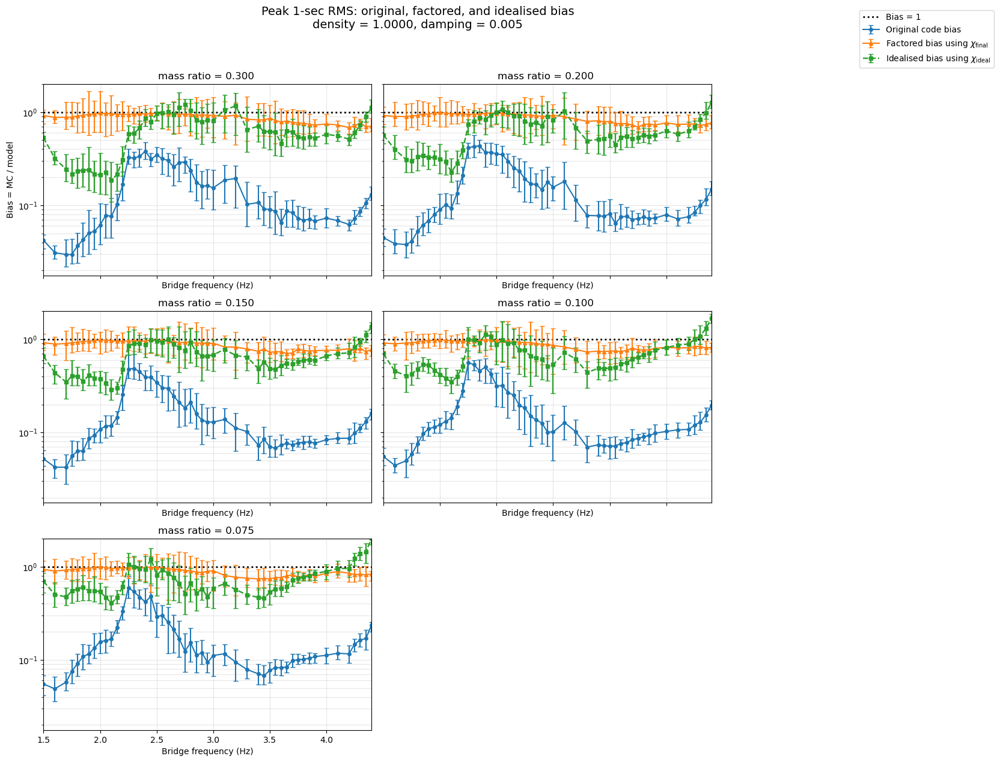

C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\2767636843.py:450: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)


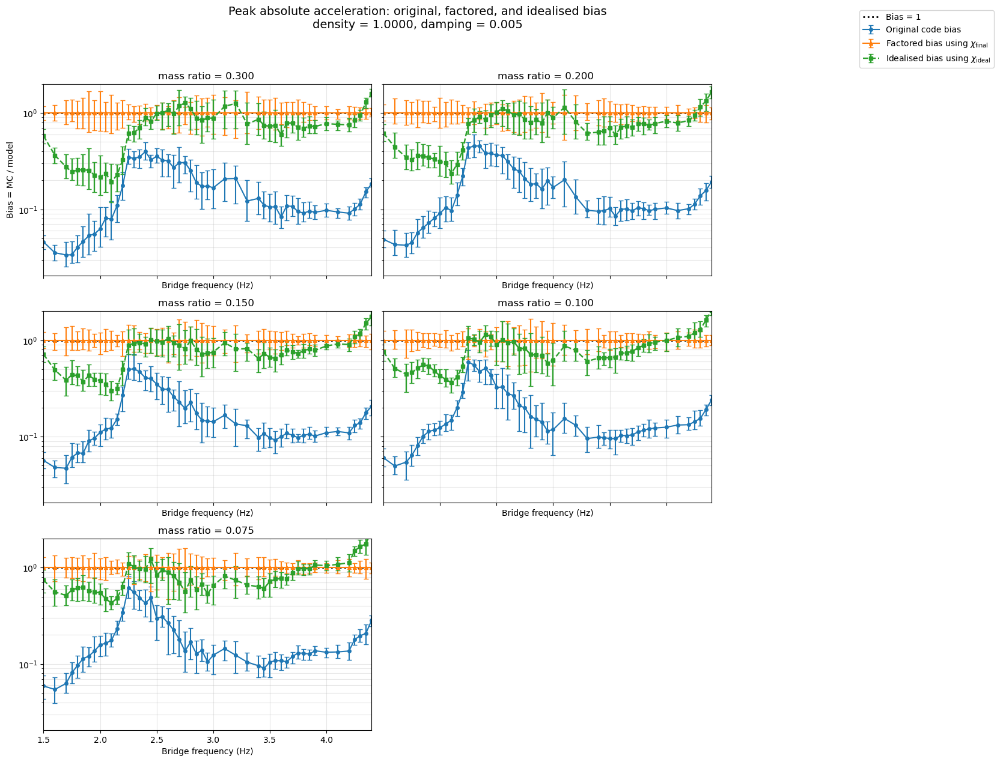

C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\2767636843.py:450: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)


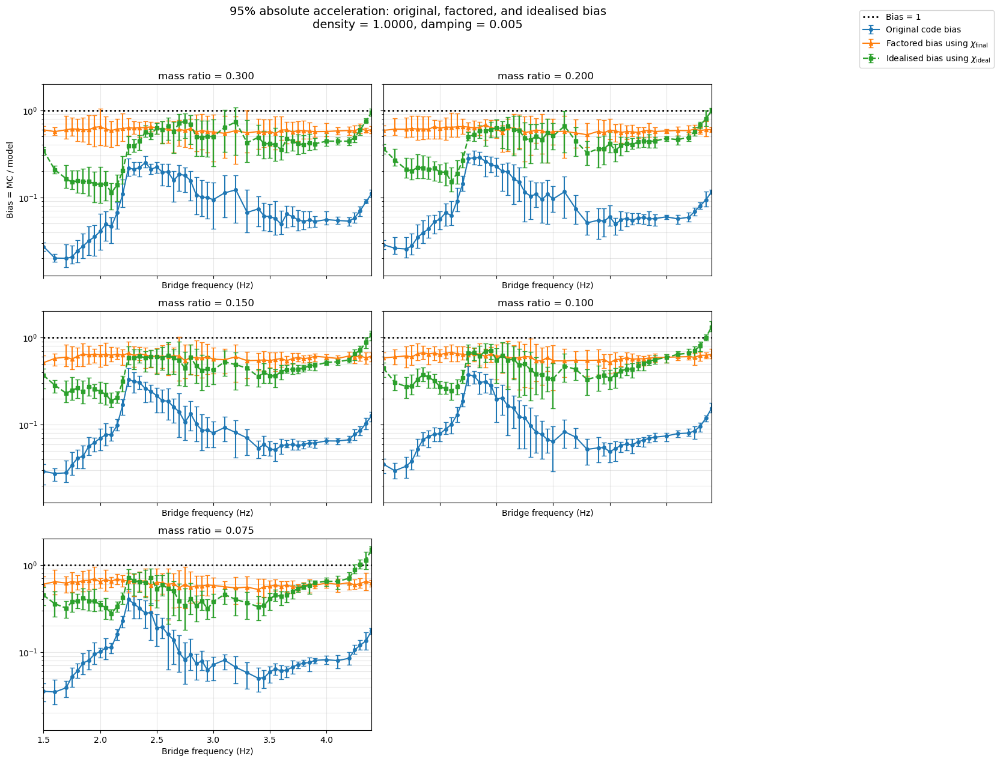

In [26]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DENSITY = 1.0000
TARGET_DAMPING = 0.005

# We still load the lm files, but plot by mass ratio
LINEAR_MASSES_TO_LOAD = [500, 750, 1000, 1500, 2000]

# Reference:
# For density = 1 and linear mass = 500 kg/m, mass ratio = 0.30
REFERENCE_LINEAR_MASS = 500.0
REFERENCE_MASS_RATIO = 0.30

Y_COL_FACTOR = "final_modification_factor"

MEASURES_TO_PLOT = [
    "Peak 1-sec RMS",
    "Peak absolute acceleration",
    "95% absolute acceleration",
]

PLOT_FMIN = 1.50
PLOT_FMAX = 4.40

SAVE_PLOTS = False

USE_LOG_Y = True
YMIN = 0.10
YMAX = 3.00

EPS = 1e-12


# ==================================================
# NEW IDEALISED EQUATION PARAMETERS
# From your fitted result
# ==================================================

IDEAL_PARAMS = {
    "y0": 0.00269915,
    "B": 8.51265033e-02,
    "mu": 0.22286233,
    "alpha": 0.59041978,
    "zeta_b": 0.00500000,
    "zeta_a": 0.32317373,
    "beta_p": 1.02847141,
    "f_p": 2.25000000,
}


# ==================================================
# MASS RATIO FUNCTION
# ==================================================

def linear_mass_to_mass_ratio(linear_mass):
    """
    For density = 1.0000:
        lm = 500 kg/m -> mass ratio = 0.30

    Since bridge modal mass scales with linear mass:
        mass_ratio = 0.30 * 500 / linear_mass
    """
    return REFERENCE_MASS_RATIO * REFERENCE_LINEAR_MASS / linear_mass


# ==================================================
# Q(beta) AND IDEALISED FACTOR
# ==================================================

def Q_mmd(beta, mu, alpha, zeta_b, zeta_a):
    beta = np.asarray(beta, dtype=float)

    N_R = alpha**2 - beta**2
    N_I = 2.0 * zeta_a * alpha * beta

    D_R = (
        (1.0 - beta**2) * (alpha**2 - beta**2)
        - 4.0 * zeta_b * zeta_a * alpha * beta**2
        - mu * alpha**2 * beta**2
    )

    D_I = (
        2.0 * beta
        * (
            zeta_a * alpha * (1.0 - (1.0 + mu) * beta**2)
            + zeta_b * (alpha**2 - beta**2)
        )
    )

    numerator_abs = np.sqrt(N_R**2 + N_I**2)
    denominator_abs = np.sqrt(D_R**2 + D_I**2)

    return beta**2 * numerator_abs / (denominator_abs + 1e-14)


def chi_ideal_from_params(f_bridge, params):
    f_bridge = np.asarray(f_bridge, dtype=float)

    beta_eff = params["beta_p"] * f_bridge / params["f_p"]

    Q_eff = Q_mmd(
        beta=beta_eff,
        mu=params["mu"],
        alpha=params["alpha"],
        zeta_b=params["zeta_b"],
        zeta_a=params["zeta_a"]
    )

    return params["y0"] + params["B"] * Q_eff


# ==================================================
# LOAD lm SUMMARY FILES
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"lm(?P<linear_mass>\d+)_"
    r"bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_lm*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:

    match = pattern.match(file.name)

    if match is None:
        print("Skipping file:", file.name)
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_linear_mass = int(match.group("linear_mass"))

    if not np.isclose(file_density, TARGET_DENSITY):
        continue

    if not np.isclose(file_damping, TARGET_DAMPING):
        continue

    if file_linear_mass not in LINEAR_MASSES_TO_LOAD:
        continue

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["linear_mass"] = file_linear_mass

    # Convert linear mass to mass ratio
    df["mass_ratio"] = linear_mass_to_mass_ratio(file_linear_mass)

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError(
        f"No matching lm files found for density={TARGET_DENSITY:.4f}, "
        f"damping={TARGET_DAMPING:.3f}"
    )

combined_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded combined dataframe shape:", combined_df.shape)


# ==================================================
# CLEAN DATA
# ==================================================

num_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "linear_mass",
    "mass_ratio",
    Y_COL_FACTOR,

    "code_bias_mean", "code_bias_p5", "code_bias_p50", "code_bias_p95",
    "corrected_bias_mean", "corrected_bias_p5", "corrected_bias_p50", "corrected_bias_p95",
]

for col in num_cols:
    if col in combined_df.columns:
        combined_df[col] = pd.to_numeric(combined_df[col], errors="coerce")

required_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "linear_mass",
    "mass_ratio",
    Y_COL_FACTOR,
    "measure",
    "code_bias_mean",
    "code_bias_p5",
    "code_bias_p95",
    "corrected_bias_mean",
    "corrected_bias_p5",
    "corrected_bias_p95",
]

missing = [col for col in required_cols if col not in combined_df.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

combined_df = combined_df.dropna(subset=required_cols).copy()

combined_df["density_key"] = combined_df["target_density"].round(4)
combined_df["damping_key"] = combined_df["target_beamdamp"].round(3)
combined_df["linear_mass_key"] = combined_df["linear_mass"].round(0).astype(int)

# This is the important new key
combined_df["mass_ratio_key"] = combined_df["mass_ratio"].round(4)

combined_df = combined_df[
    (combined_df["bridge_frequency"] >= PLOT_FMIN) &
    (combined_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

combined_df = combined_df.sort_values(
    ["mass_ratio_key", "measure", "bridge_frequency"]
).reset_index(drop=True)


print("\nLinear mass to mass ratio mapping:")
print(
    combined_df[
        ["linear_mass_key", "mass_ratio_key"]
    ]
    .drop_duplicates()
    .sort_values("mass_ratio_key", ascending=False)
)


# ==================================================
# CALCULATE IDEALISED FACTOR AND IDEALISED BIAS
# ==================================================

combined_df["chi_final"] = combined_df[Y_COL_FACTOR]

combined_df["chi_ideal"] = chi_ideal_from_params(
    combined_df["bridge_frequency"].to_numpy(),
    IDEAL_PARAMS
)

combined_df["chi_ideal"] = np.maximum(combined_df["chi_ideal"], EPS)

# corrected_bias = MC / (simplified * chi_final)
# idealised_bias = MC / (simplified * chi_ideal)
#
# Therefore:
# idealised_bias = corrected_bias * chi_final / chi_ideal

combined_df["bias_scale_final_to_ideal"] = (
    combined_df["chi_final"] / combined_df["chi_ideal"]
)

for stat in ["mean", "p5", "p50", "p95"]:
    combined_df[f"idealized_bias_{stat}"] = (
        combined_df[f"corrected_bias_{stat}"]
        * combined_df["bias_scale_final_to_ideal"]
    )


print("\nExample rows after idealised bias adjustment:")
print(
    combined_df[
        [
            "mass_ratio_key",
            "linear_mass_key",
            "bridge_frequency",
            "measure",
            "chi_final",
            "chi_ideal",
            "code_bias_mean",
            "corrected_bias_mean",
            "idealized_bias_mean",
        ]
    ].head(12)
)


# ==================================================
# HELPER FUNCTION
# ==================================================

def make_yerr(df, mean_col, p5_col, p95_col):
    lower = df[mean_col].to_numpy() - df[p5_col].to_numpy()
    upper = df[p95_col].to_numpy() - df[mean_col].to_numpy()

    lower = np.maximum(lower, 0.0)
    upper = np.maximum(upper, 0.0)

    return np.vstack([lower, upper])


# ==================================================
# PLOT FUNCTION
# One figure per measure
# One subplot per mass ratio
# ==================================================

def plot_bias_for_measure(measure_name):

    measure_df = combined_df[
        combined_df["measure"].astype(str) == measure_name
    ].copy()

    if measure_df.empty:
        print(f"Skipping measure because no rows found: {measure_name}")
        return

    # Sort from highest mass ratio to lowest
    mass_ratios = sorted(
        measure_df["mass_ratio_key"].dropna().unique(),
        reverse=True
    )

    n = len(mass_ratios)
    ncols = 2
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(14, 4.3 * nrows),
        sharex=True,
        sharey=True
    )

    axes = np.asarray(axes).reshape(-1)

    for ax, mr in zip(axes, mass_ratios):

        sub = measure_df[
            np.isclose(measure_df["mass_ratio_key"], mr)
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        lm_values = sorted(sub["linear_mass_key"].dropna().unique())

        if len(lm_values) == 1:
            title_label = f"mass ratio = {mr:.3f} "
        else:
            title_label = f"mass ratio = {mr:.3f}"

        ax.axhline(
            1.0,
            linestyle=":",
            linewidth=2,
            color="black",
            label="Bias = 1"
        )

        # --------------------------------------------------
        # Original code bias
        # --------------------------------------------------
        ax.errorbar(
            sub["bridge_frequency"],
            sub["code_bias_mean"],
            yerr=make_yerr(
                sub,
                "code_bias_mean",
                "code_bias_p5",
                "code_bias_p95"
            ),
            marker="o",
            markersize=4,
            capsize=3,
            linewidth=1.5,
            label="Original code bias"
        )

        # --------------------------------------------------
        # Factored bias using chi_final
        # --------------------------------------------------
        ax.errorbar(
            sub["bridge_frequency"],
            sub["corrected_bias_mean"],
            yerr=make_yerr(
                sub,
                "corrected_bias_mean",
                "corrected_bias_p5",
                "corrected_bias_p95"
            ),
            marker="^",
            markersize=4,
            capsize=3,
            linewidth=1.5,
            label=r"Factored bias using $\chi_{\mathrm{final}}$"
        )

        # --------------------------------------------------
        # Idealised factor bias using new equation
        # --------------------------------------------------
        ax.errorbar(
            sub["bridge_frequency"],
            sub["idealized_bias_mean"],
            yerr=make_yerr(
                sub,
                "idealized_bias_mean",
                "idealized_bias_p5",
                "idealized_bias_p95"
            ),
            marker="s",
            markersize=4,
            capsize=3,
            linewidth=1.7,
            linestyle="--",
            label=r"Idealised bias using $\chi_{\mathrm{ideal}}$"
        )

        ax.set_title(title_label)
        ax.set_xlabel("Bridge frequency (Hz)")
        ax.set_xlim(PLOT_FMIN, PLOT_FMAX)

        if USE_LOG_Y:
            ax.set_yscale("log")
            ax.set_ylim(0, 2)
        else:
            ax.set_ylim(0.0, YMAX)

        ax.grid(True, which="both", alpha=0.3)

    axes[0].set_ylabel("Bias = MC / model")

    # Remove unused subplot
    for j in range(len(mass_ratios), len(axes)):
        fig.delaxes(axes[j])

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        bbox_to_anchor=(1.02, 0.98),
        loc="upper left"
    )

    fig.suptitle(
        f"{measure_name}: original, factored, and idealised bias\n"
        f"density = {TARGET_DENSITY:.4f}, damping = {TARGET_DAMPING:.3f}",
        fontsize=14
    )

    fig.tight_layout(rect=[0, 0, 0.86, 0.95])

    if SAVE_PLOTS:
        safe_measure = (
            measure_name
            .replace(" ", "_")
            .replace("%", "pct")
            .replace("/", "_")
        )

        fig_name = (
            f"bias_original_factored_idealised_"
            f"density{TARGET_DENSITY:.4f}_"
            f"damping{TARGET_DAMPING:.3f}_"
            f"{safe_measure}_all_mass_ratios.png"
        )

        fig.savefig(fig_name, dpi=300, bbox_inches="tight")
        print("Saved:", fig_name)

    plt.show()


# ==================================================
# MAKE THE 3 FIGURES
# ==================================================

for measure_name in MEASURES_TO_PLOT:
    plot_bias_for_measure(measure_name)


Loaded: density1.0000_damping0.010_lm483_bias_summary.pkl rows: 189
Loaded: density1.0000_damping0.010_lm580_bias_summary.pkl rows: 189
Loaded: density1.0000_damping0.010_lm725_bias_summary.pkl rows: 189
Loaded: density1.0000_damping0.010_lm967_bias_summary.pkl rows: 189
Loaded: density1.0000_damping0.010_lm1450_bias_summary.pkl rows: 189
Loaded: density1.0000_damping0.010_lm2900_bias_summary.pkl rows: 189
linear_mass = 483, median mass ratio = 0.296652, range = [0.217168, 0.379743]
linear_mass = 580, median mass ratio = 0.241879, range = [0.157236, 0.320441]
linear_mass = 725, median mass ratio = 0.193991, range = [0.140159, 0.264100]
linear_mass = 967, median mass ratio = 0.145623, range = [0.110916, 0.183887]
linear_mass = 1450, median mass ratio = 0.101371, range = [0.081705, 0.118009]
linear_mass = 2900, median mass ratio = 0.048505, range = [0.035679, 0.059707]


C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\109096163.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\109096163.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\109096163.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)


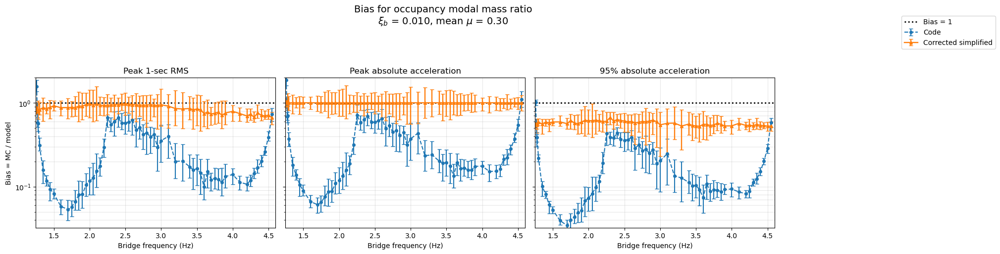

C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\109096163.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\109096163.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\109096163.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)


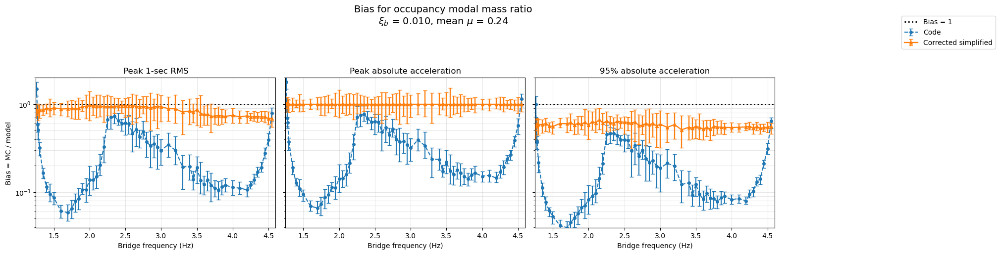

C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\109096163.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\109096163.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\109096163.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)


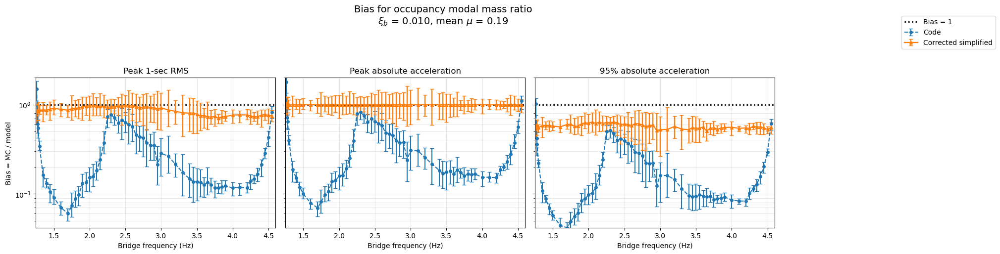

C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\109096163.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\109096163.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\109096163.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)


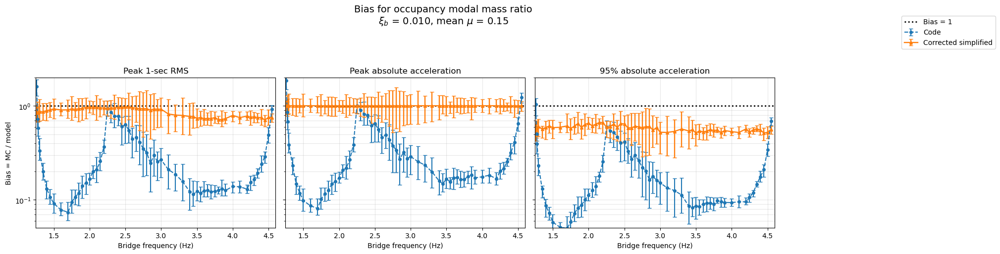

C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\109096163.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\109096163.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\109096163.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)


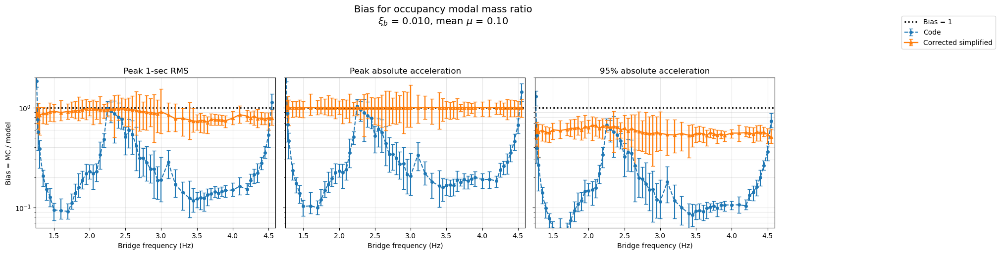

C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\109096163.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\109096163.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\109096163.py:254: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)


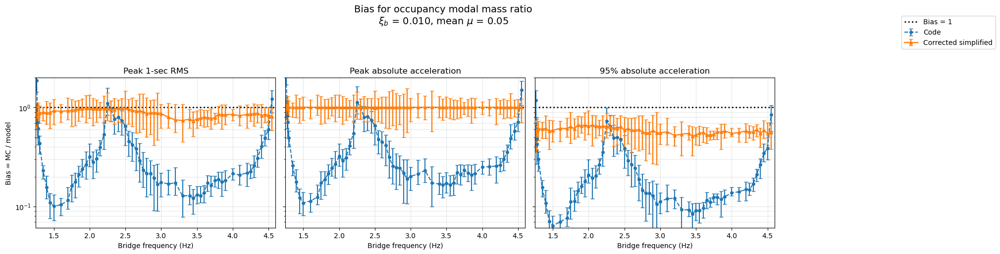

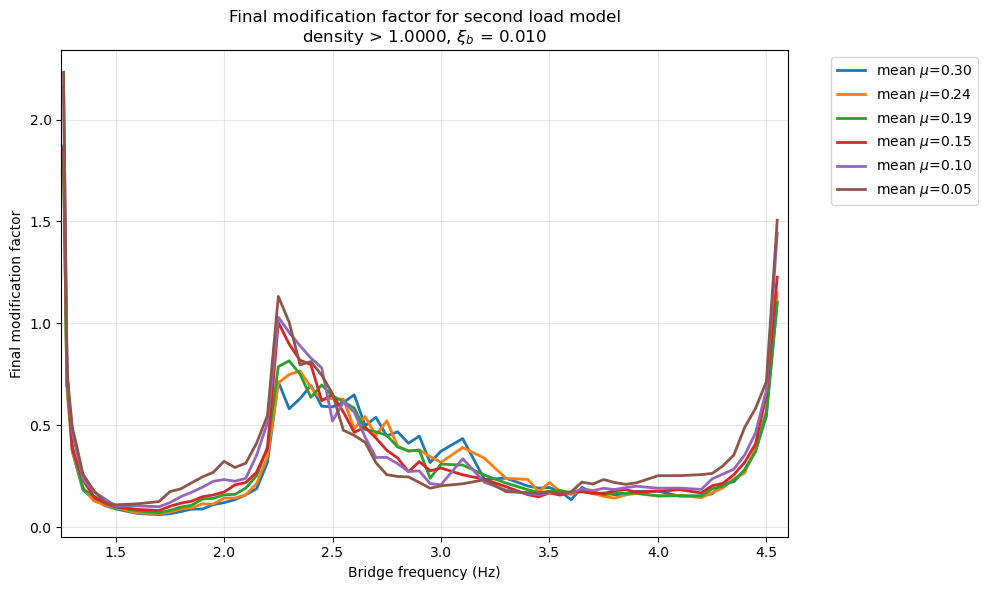

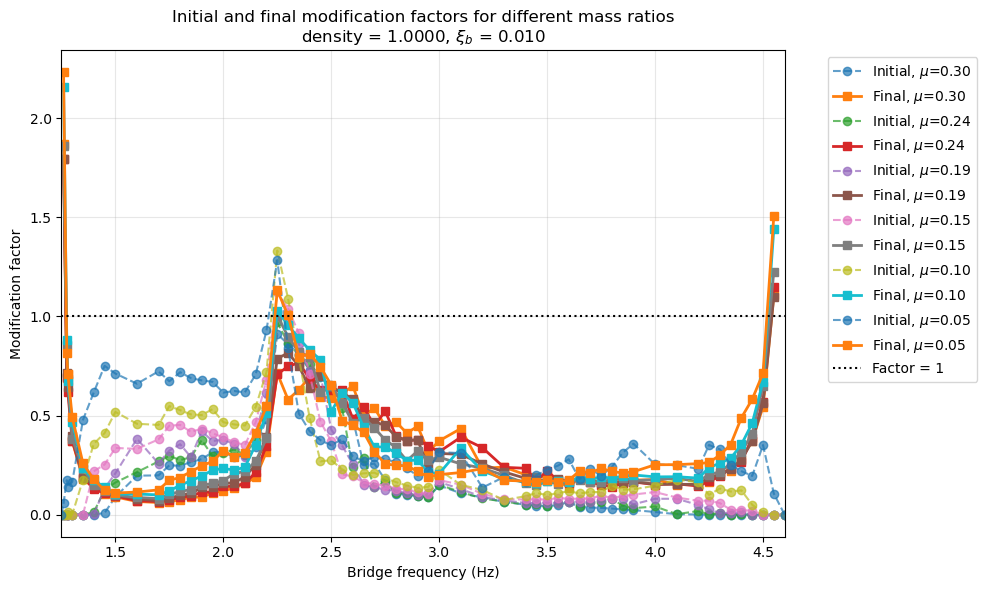

In [27]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# LOAD NEW SAVED FILES AND PLOT BY MASS RATIO
# ==================================================

TARGET_DENSITY = 1.0000
TARGET_DAMPINGS = [0.010]
LINEAR_MASS_VALUES = [483.33, 580.00, 725.00, 966.67, 1450.00, 2900.00]

PLOT_FMIN = 1.25
PLOT_FMAX = 4.60

MEASURES_TO_PLOT = [
    "Peak 1-sec RMS",
    "Peak absolute acceleration",
    "95% absolute acceleration",
]

SAVE_PLOTS = False

YMIN = 0.10
YMAX = 3.00


# ==================================================
# FILE NAME HELPER
# ==================================================

def make_summary_filename(density, target_beamdamp, linear_mass):
    return (
        f"density{density:.4f}"
        f"_damping{target_beamdamp:.3f}"
        f"_lm{linear_mass:.0f}"
        f"_bias_summary.pkl"
    )


# ==================================================
# LOAD FILES
# ==================================================

all_dfs = []

for damp in TARGET_DAMPINGS:
    for lm in LINEAR_MASS_VALUES:

        fname = make_summary_filename(TARGET_DENSITY, damp, lm)

        if not os.path.exists(fname):
            print("Missing file, skipped:", fname)
            continue

        with open(fname, "rb") as f:
            df_i = pickle.load(f)

        df_i["source_file"] = fname
        df_i["linear_mass_case"] = lm

        all_dfs.append(df_i)

        print("Loaded:", fname, "rows:", len(df_i))

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching summary PKL files were loaded.")

combined_df = pd.concat(all_dfs, ignore_index=True)


# ==================================================
# CLEAN DATA
# ==================================================

numeric_cols = [
    "bridge_frequency",
    "target_beamdamp",
    "target_density",
    "actual_density",
    "linear_mass",
    "linear_mass_case",
    "mean_modal_mass_ratio",
    "mass_ratio_used_for_interpolation",
    "initial_modification_factor",
    "final_modification_factor",
    "code_bias_mean",
    "code_bias_p5",
    "code_bias_p50",
    "code_bias_p95",
    "corrected_bias_mean",
    "corrected_bias_p5",
    "corrected_bias_p50",
    "corrected_bias_p95",
]

for col in numeric_cols:
    if col in combined_df.columns:
        combined_df[col] = pd.to_numeric(combined_df[col], errors="coerce")

combined_df = combined_df[
    (combined_df["bridge_frequency"] >= PLOT_FMIN) &
    (combined_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

combined_df = combined_df[
    np.isclose(combined_df["target_density"], TARGET_DENSITY)
].copy()

if combined_df.empty:
    raise ValueError("No rows left after filtering.")


# ==================================================
# MASS RATIO LABELS
# ==================================================

mass_ratio_labels = {}

for lm in LINEAR_MASS_VALUES:

    sub = combined_df[np.isclose(combined_df["linear_mass"], lm)]

    if sub.empty:
        continue

    mu_med = np.nanmedian(sub["mean_modal_mass_ratio"])
    mu_min = np.nanmin(sub["mean_modal_mass_ratio"])
    mu_max = np.nanmax(sub["mean_modal_mass_ratio"])

    mass_ratio_labels[lm] = (
        rf"$m_L$={lm:.0f} kg/m, "
        rf"$\mu$={mu_med:.3f}"
    )

    print(
        f"linear_mass = {lm:.0f}, "
        f"median mass ratio = {mu_med:.6f}, "
        f"range = [{mu_min:.6f}, {mu_max:.6f}]"
    )


# ==================================================
# HELPER: ERROR BAR
# ==================================================

def make_yerr(df, mean_col, p5_col, p95_col):
    lower = df[mean_col].to_numpy() - df[p5_col].to_numpy()
    upper = df[p95_col].to_numpy() - df[mean_col].to_numpy()

    lower = np.maximum(lower, 0.0)
    upper = np.maximum(upper, 0.0)

    return np.vstack([lower, upper])


# ==================================================
# PLOT 1:
# BIAS FOR DIFFERENT MASS RATIOS
# ONE SEPARATE FIGURE PER MASS RATIO
# ==================================================

for lm in LINEAR_MASS_VALUES:

    lm_df = combined_df[np.isclose(combined_df["linear_mass"], lm)].copy()

    if lm_df.empty:
        continue

    mu_med = np.nanmedian(lm_df["mean_modal_mass_ratio"])

    for damp in TARGET_DAMPINGS:

        damp_df = lm_df[np.isclose(lm_df["target_beamdamp"], damp)].copy()

        if damp_df.empty:
            continue

        n_measures = len(MEASURES_TO_PLOT)

        fig, axes = plt.subplots(
            nrows=1,
            ncols=n_measures,
            figsize=(6.0 * n_measures, 5.2),
            sharex=True,
            sharey=True
        )

        if n_measures == 1:
            axes = [axes]

        for ax, measure_name in zip(axes, MEASURES_TO_PLOT):

            sub = damp_df[
                damp_df["measure"].astype(str) == measure_name
            ].copy()

            if sub.empty:
                ax.set_title(measure_name + "\nNo data")
                ax.axis("off")
                continue

            sub = sub.sort_values("bridge_frequency")

            ax.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                color="black",
                label="Bias = 1"
            )

            ax.errorbar(
                sub["bridge_frequency"],
                sub["code_bias_mean"],
                yerr=make_yerr(
                    sub,
                    "code_bias_mean",
                    "code_bias_p5",
                    "code_bias_p95"
                ),
                marker="o",
                markersize=4,
                capsize=3,
                linewidth=1.5,
                linestyle="--",
                label="Code"
            )

            ax.errorbar(
                sub["bridge_frequency"],
                sub["corrected_bias_mean"],
                yerr=make_yerr(
                    sub,
                    "corrected_bias_mean",
                    "corrected_bias_p5",
                    "corrected_bias_p95"
                ),
                marker="^",
                markersize=4,
                capsize=3,
                linewidth=1.7,
                linestyle="-",
                label="Corrected simplified"
            )

            ax.set_title(measure_name)
            ax.set_xlabel("Bridge frequency (Hz)")
            ax.set_xlim(PLOT_FMIN, PLOT_FMAX)

            ax.set_yscale("log")
            ax.set_ylim(0, 2)

            ax.grid(True, which="both", alpha=0.3)

        axes[0].set_ylabel("Bias = MC / model")

        handles, labels = axes[0].get_legend_handles_labels()

        fig.legend(
            handles,
            labels,
            bbox_to_anchor=(1.01, 0.95),
            loc="upper left"
        )

        fig.suptitle(
            f"Bias for occupancy modal mass ratio\n"
            rf"$\xi_b$ = {damp:.3f}, "
            rf"mean $\mu$ = {mu_med:.2f}",
            fontsize=14
        )

        fig.tight_layout(rect=[0, 0, 0.88, 0.88])

        if SAVE_PLOTS:
            fig_name = (
                f"bias_density{TARGET_DENSITY:.4f}_"
                f"damping{damp:.3f}_"
                f"lm{lm:.0f}_"
                f"mu{mu_med:.3f}.png"
            )
            fig.savefig(fig_name, dpi=300, bbox_inches="tight")
            print("Saved:", fig_name)

        plt.show()


# ==================================================
# PLOT 2:
# MODIFICATION FACTORS FOR DIFFERENT MASS RATIOS
# SAME PLOT
# ==================================================

factor_df = combined_df.drop_duplicates(
    subset=[
        "bridge_frequency",
        "target_beamdamp",
        "target_density",
        "linear_mass",
    ]
).copy()

for damp in TARGET_DAMPINGS:

    sub_damp = factor_df[
        np.isclose(factor_df["target_beamdamp"], damp)
    ].copy()

    if sub_damp.empty:
        continue

    plt.figure(figsize=(10, 6))

    for lm in LINEAR_MASS_VALUES:

        sub = sub_damp[
            np.isclose(sub_damp["linear_mass"], lm)
        ].copy()

        if sub.empty:
            continue

        sub = sub.sort_values("bridge_frequency")

        mu_med = np.nanmedian(sub["mean_modal_mass_ratio"])

        plt.plot(
            sub["bridge_frequency"],
            sub["final_modification_factor"],
            linewidth=2,
            label=rf"mean $\mu$={mu_med:.2f}"
        )

    

    plt.xlabel("Bridge frequency (Hz)")
    plt.ylabel("Final modification factor")
    plt.title(
        f"Final modification factor for second load model\n"
        f"density > {TARGET_DENSITY:.4f}, "
        rf"$\xi_b$ = {damp:.3f}"
    )

    plt.xlim(PLOT_FMIN, PLOT_FMAX)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    if SAVE_PLOTS:
        fig_name = (
            f"final_factor_density{TARGET_DENSITY:.4f}_"
            f"damping{damp:.3f}_all_mass_ratios.png"
        )
        plt.savefig(fig_name, dpi=300, bbox_inches="tight")
        print("Saved:", fig_name)

    plt.show()


# ==================================================
# OPTIONAL:
# INITIAL AND FINAL FACTORS TOGETHER
# SAME PLOT, ALL MASS RATIOS
# ==================================================

for damp in TARGET_DAMPINGS:

    sub_damp = factor_df[
        np.isclose(factor_df["target_beamdamp"], damp)
    ].copy()

    if sub_damp.empty:
        continue

    plt.figure(figsize=(10, 6))

    for lm in LINEAR_MASS_VALUES:

        sub = sub_damp[
            np.isclose(sub_damp["linear_mass"], lm)
        ].copy()

        if sub.empty:
            continue

        sub = sub.sort_values("bridge_frequency")

        mu_med = np.nanmedian(sub["mean_modal_mass_ratio"])

        plt.plot(
            sub["bridge_frequency"],
            sub["initial_modification_factor"],
            linestyle="--",
            marker="o",
            linewidth=1.5,
            alpha=0.7,
            label=rf"Initial, $\mu$={mu_med:.2f}"
        )

        plt.plot(
            sub["bridge_frequency"],
            sub["final_modification_factor"],
            linestyle="-",
            marker="s",
            linewidth=2,
            label=rf"Final, $\mu$={mu_med:.2f}"
        )

    plt.axhline(
        1.0,
        linestyle=":",
        linewidth=1.5,
        color="black",
        label="Factor = 1"
    )

    plt.xlabel("Bridge frequency (Hz)")
    plt.ylabel("Modification factor")
    plt.title(
        f"Initial and final modification factors for different mass ratios\n"
        f"density = {TARGET_DENSITY:.4f}, "
        rf"$\xi_b$ = {damp:.3f}"
    )

    plt.xlim(PLOT_FMIN, PLOT_FMAX)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

Loading: density1.0000_damping0.010_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.010_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.010_lm483_bias_summary.pkl
Loading: density1.0000_damping0.010_lm580_bias_summary.pkl
Loading: density1.0000_damping0.010_lm725_bias_summary.pkl
Loading: density1.0000_damping0.010_lm967_bias_summary.pkl

Loaded combined dataframe shape: (1134, 41)

Frequency coverage:
   linear_mass_key   min   max  count
0              483  1.26  4.55     60
1              580  1.26  4.55     60
2              725  1.26  4.55     60
3              967  1.26  4.55     60
4             1450  1.26  4.55     60
5             2900  1.26  4.55     60

Number of fitting points: 50
Fitting frequency range: 1.5 to 4.4

Initial guesses
----------------
y0       = 0.094881
B        = 1.001443e-01
mu       = 0.160743
alpha    = 0.551294
zeta_a   = 0.385375
beta_p0  = 1.009802

Fitted parameters
-----------------
y0              = 0.09487318
B               = 1.19

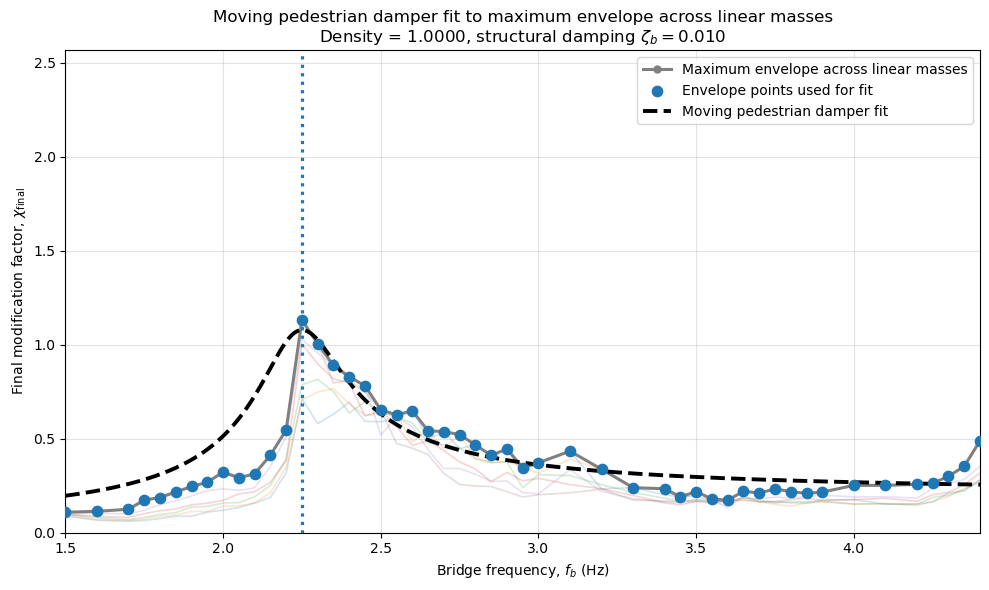


FINAL FITTED IDEAL MODIFICATION FACTOR EQUATION

Model form:
chi_ideal(f_b) = y0 + B * Q(beta_eff)
beta_eff       = beta_p * f_b / f_p
f_p            = 2.25 Hz

Fitted equation:
chi_ideal(f_b) = 0.094873 + 1.193533e-01 * Q(1.009802 * f_b / 2.250000)

Fitted parameters:
y0       = 0.09487318
B        = 1.19353288e-01
mu       = 0.16073981
alpha    = 0.55129458
zeta_b   = 0.01000000
zeta_a   = 0.38537211
beta_p   = 1.00980163
f_p      = 2.25000000 Hz


In [28]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import least_squares

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DENSITY = 1.0000
TARGET_DAMPING = 0.010

Y_COL = "final_modification_factor"

FIT_FMIN = 1.50
FIT_FMAX = 4.40

PLOT_FMIN = 1.50
PLOT_FMAX = 4.40

F_TARGET_PEAK = 2.25

zeta_b = TARGET_DAMPING

BETA_MIN = 0.20
BETA_MAX = 3.00
N_BETA_PEAK = 6000

eps = 1e-12


# ==================================================
# LOAD NEW lm FILES
# Expected names:
# density1.0000_damping0.005_lm500_bias_summary.pkl
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"lm(?P<linear_mass>\d+)_"
    r"bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_lm*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:

    match = pattern.match(file.name)

    if match is None:
        print("Skipping file because name does not match expected pattern:", file.name)
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_linear_mass = float(match.group("linear_mass"))

    # Keep only target density and damping
    if not np.isclose(file_density, TARGET_DENSITY):
        continue

    if not np.isclose(file_damping, TARGET_DAMPING):
        continue

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["linear_mass"] = file_linear_mass

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError(
        "No matching lm summary files found for "
        f"density={TARGET_DENSITY:.4f}, damping={TARGET_DAMPING:.3f}"
    )

corrected_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded combined dataframe shape:", corrected_df.shape)


# ==================================================
# CLEAN NUMERIC COLUMNS
# ==================================================

needed_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "linear_mass",
    Y_COL,
]

for col in needed_cols:
    corrected_df[col] = pd.to_numeric(corrected_df[col], errors="coerce")

corrected_df = corrected_df.dropna(subset=needed_cols).copy()

corrected_df["density_key"] = corrected_df["target_density"].round(4)
corrected_df["damping_key"] = corrected_df["target_beamdamp"].round(3)
corrected_df["linear_mass_key"] = corrected_df["linear_mass"].round(0).astype(int)

# Remove repeated rows if the pkl has multiple measures
sort_cols = ["linear_mass_key", "bridge_frequency"]

if "measure" in corrected_df.columns:
    corrected_df = corrected_df.sort_values(sort_cols)
    corrected_df = corrected_df.drop_duplicates(
        subset=["linear_mass_key", "bridge_frequency"],
        keep="first"
    ).copy()

corrected_df = corrected_df.sort_values(
    ["linear_mass_key", "bridge_frequency"]
).reset_index(drop=True)

print("\nFrequency coverage:")
coverage = (
    corrected_df
    .groupby("linear_mass_key")["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)
print(coverage)


# ==================================================
# MAXIMUM ENVELOPE ACROSS LINEAR MASSES
# ==================================================

env_df = (
    corrected_df
    .groupby("bridge_frequency", as_index=False)
    .agg(
        envelope_factor=(Y_COL, "max")
    )
    .sort_values("bridge_frequency")
)

fit_source_df = env_df.copy()

fit_df = fit_source_df[
    (fit_source_df["bridge_frequency"] >= FIT_FMIN) &
    (fit_source_df["bridge_frequency"] <= FIT_FMAX) &
    (fit_source_df["envelope_factor"] > 0)
].copy()

x_fit = fit_df["bridge_frequency"].to_numpy()
y_fit = fit_df["envelope_factor"].to_numpy()

if len(x_fit) < 8:
    raise ValueError("Too few envelope points in fitting range.")

print("\nNumber of fitting points:", len(x_fit))
print("Fitting frequency range:", x_fit.min(), "to", x_fit.max())


# ==================================================
# CLOSED-FORM MMD / TMD ACCELERATION SHAPE Q(beta)
# ==================================================

def Q_mmd(beta, mu, alpha, zeta_b, zeta_a):
    beta = np.asarray(beta, dtype=float)

    N_R = alpha**2 - beta**2
    N_I = 2.0 * zeta_a * alpha * beta

    D_R = (
        (1.0 - beta**2) * (alpha**2 - beta**2)
        - 4.0 * zeta_b * zeta_a * alpha * beta**2
        - mu * alpha**2 * beta**2
    )

    D_I = (
        2.0 * beta
        * (
            zeta_a * alpha * (1.0 - (1.0 + mu) * beta**2)
            + zeta_b * (alpha**2 - beta**2)
        )
    )

    numerator_abs = np.sqrt(N_R**2 + N_I**2)
    denominator_abs = np.sqrt(D_R**2 + D_I**2)

    return beta**2 * numerator_abs / (denominator_abs + 1e-14)


def beta_peak_for_parameters(mu, alpha, zeta_a, zeta_b):
    beta_grid = np.linspace(BETA_MIN, BETA_MAX, N_BETA_PEAK)

    Q_grid = Q_mmd(
        beta=beta_grid,
        mu=mu,
        alpha=alpha,
        zeta_b=zeta_b,
        zeta_a=zeta_a
    )

    return beta_grid[np.nanargmax(Q_grid)]


def chi_peak_locked_B_model(f_bridge, y0, B, mu, alpha, zeta_a):
    beta_p = beta_peak_for_parameters(
        mu=mu,
        alpha=alpha,
        zeta_a=zeta_a,
        zeta_b=zeta_b
    )

    beta_eff = beta_p * (f_bridge / F_TARGET_PEAK)

    Q_eff = Q_mmd(
        beta=beta_eff,
        mu=mu,
        alpha=alpha,
        zeta_b=zeta_b,
        zeta_a=zeta_a
    )

    return y0 + B * Q_eff


# ==================================================
# INITIAL GUESSES
# ==================================================

previous_fits = {
    0.005: {
        "y0": 0.12625630,
        "B":  1.57791445e-01,
        "mu": 0.18306454,
        "alpha": 0.51070586,
        "zeta_a": 0.39981395,
    },
    0.010: {
        "y0": 0.14782840,
        "B":  2.02927309e-01,
        "mu": 0.16074344,
        "alpha": 0.55129448,
        "zeta_a": 0.38537497,
    },
    0.020: {
        "y0": 0.19097260,
        "B":  2.93199037e-01,
        "mu": 0.11610124,
        "alpha": 0.63247172,
        "zeta_a": 0.35649701,
    },
}

if zeta_b in previous_fits:
    mu0 = previous_fits[zeta_b]["mu"]
    alpha0 = previous_fits[zeta_b]["alpha"]
    zeta_a0 = previous_fits[zeta_b]["zeta_a"]
else:
    damping_arr = np.array(sorted(previous_fits.keys()))
    mu_arr = np.array([previous_fits[d]["mu"] for d in damping_arr])
    alpha_arr = np.array([previous_fits[d]["alpha"] for d in damping_arr])
    zeta_a_arr = np.array([previous_fits[d]["zeta_a"] for d in damping_arr])

    mu0 = np.interp(zeta_b, damping_arr, mu_arr)
    alpha0 = np.interp(zeta_b, damping_arr, alpha_arr)
    zeta_a0 = np.interp(zeta_b, damping_arr, zeta_a_arr)

mu0 = np.clip(mu0, 0.001, 0.50)
alpha0 = np.clip(alpha0, 0.50, 1.50)
zeta_a0 = np.clip(zeta_a0, 0.30, 2.00)

beta_p0 = beta_peak_for_parameters(
    mu=mu0,
    alpha=alpha0,
    zeta_a=zeta_a0,
    zeta_b=zeta_b
)

beta_eff0 = beta_p0 * (x_fit / F_TARGET_PEAK)

Q0 = Q_mmd(
    beta=beta_eff0,
    mu=mu0,
    alpha=alpha0,
    zeta_b=zeta_b,
    zeta_a=zeta_a0
)

X0 = np.column_stack([np.ones_like(Q0), Q0])
y0_guess, B_guess = np.linalg.lstsq(X0, y_fit, rcond=None)[0]

y0_guess = max(y0_guess, 1e-8)
B_guess = max(B_guess, 1e-8)

p0 = np.array([
    y0_guess,
    B_guess,
    mu0,
    alpha0,
    zeta_a0
])

print("\nInitial guesses")
print("----------------")
print(f"y0       = {p0[0]:.6f}")
print(f"B        = {p0[1]:.6e}")
print(f"mu       = {p0[2]:.6f}")
print(f"alpha    = {p0[3]:.6f}")
print(f"zeta_a   = {p0[4]:.6f}")
print(f"beta_p0  = {beta_p0:.6f}")


# ==================================================
# BOUNDS
# ==================================================

ymax = np.nanmax(y_fit)

lower_bounds = np.array([
    0.0,      # y0
    0.0,      # B
    0.001,    # mu
    0.50,     # alpha
    0.30      # zeta_a
])

upper_bounds = np.array([
    5.0 * ymax,  # y0
    1e6,         # B
    0.50,        # mu
    1.50,        # alpha
    2.00         # zeta_a
])


# ==================================================
# FIT OBJECTIVE
# ==================================================

RIGHT_SHOULDER_WEIGHT = 2.00
POST_PEAK_SHOULDER_WEIGHT = 1.50
PEAK_WEIGHT_STRENGTH = 0.20

def residuals(p):
    y0, B, mu, alpha, zeta_a = p

    y_model = chi_peak_locked_B_model(
        f_bridge=x_fit,
        y0=y0,
        B=B,
        mu=mu,
        alpha=alpha,
        zeta_a=zeta_a
    )

    if np.any(y_model <= 0):
        return 1e6 * np.ones_like(y_fit)

    res = np.log(y_model + eps) - np.log(y_fit + eps)

    peak_weight = 1.0 + PEAK_WEIGHT_STRENGTH * np.exp(
        -0.5 * ((x_fit - F_TARGET_PEAK) / 0.25)**2
    )

    right_weight = np.where(
        x_fit > F_TARGET_PEAK,
        RIGHT_SHOULDER_WEIGHT,
        1.0
    )

    post_peak_weight = np.where(
        (x_fit >= 2.35) & (x_fit <= 3.00),
        POST_PEAK_SHOULDER_WEIGHT,
        1.0
    )

    return peak_weight * right_weight * post_peak_weight * res


# ==================================================
# RUN OPTIMIZATION
# ==================================================

result = least_squares(
    residuals,
    p0,
    bounds=(lower_bounds, upper_bounds),
    loss="soft_l1",
    f_scale=0.1,
    max_nfev=50000
)

y0_fit, B_fit, mu_fit, alpha_fit, zeta_a_fit = result.x

beta_p_fit = beta_peak_for_parameters(
    mu=mu_fit,
    alpha=alpha_fit,
    zeta_a=zeta_a_fit,
    zeta_b=zeta_b
)

Q_beta_p_fit = Q_mmd(
    beta=beta_p_fit,
    mu=mu_fit,
    alpha=alpha_fit,
    zeta_b=zeta_b,
    zeta_a=zeta_a_fit
)

A_equivalent = B_fit * Q_beta_p_fit

print("\nFitted parameters")
print("-----------------")
print(f"y0              = {y0_fit:.8f}")
print(f"B               = {B_fit:.8e}")
print(f"mu              = {mu_fit:.8f}")
print(f"alpha           = {alpha_fit:.8f}")
print(f"zeta_b          = {zeta_b:.8f} fixed")
print(f"zeta_a          = {zeta_a_fit:.8f}")
print(f"beta_p          = {beta_p_fit:.8f}")
print(f"Q(beta_p)       = {Q_beta_p_fit:.8f}")
print(f"A equivalent    = B * Q(beta_p) = {A_equivalent:.8f}")
print("Success:", result.success)
print("Message:", result.message)
print("Cost:", result.cost)


# ==================================================
# SMOOTH FITTED CURVE
# ==================================================

x_smooth = np.linspace(FIT_FMIN, FIT_FMAX, 1500)

y_smooth = chi_peak_locked_B_model(
    f_bridge=x_smooth,
    y0=y0_fit,
    B=B_fit,
    mu=mu_fit,
    alpha=alpha_fit,
    zeta_a=zeta_a_fit
)

peak_idx = np.nanargmax(y_smooth)

print("\nFitted curve check")
print("------------------")
print(f"Checked peak frequency = {x_smooth[peak_idx]:.6f} Hz")
print(f"Checked peak value     = {y_smooth[peak_idx]:.6f}")


# ==================================================
# PLOT LIKE YOUR FIGURE
# Original lm curves + maximum envelope + fitted curve
# ==================================================

plt.figure(figsize=(10, 6))

# Original linear-mass curves
for lm in sorted(corrected_df["linear_mass_key"].dropna().unique()):

    sub = corrected_df[
        corrected_df["linear_mass_key"] == lm
    ].copy()

    sub = sub.sort_values("bridge_frequency")

    plt.plot(
        sub["bridge_frequency"],
        sub[Y_COL],
        linewidth=1.2,
        alpha=0.20,
        label=None
    )

# Maximum envelope across linear masses
plt.plot(
    env_df["bridge_frequency"],
    env_df["envelope_factor"],
    "o-",
    linewidth=2.2,
    markersize=5,
    color="gray",
    label="Maximum envelope across linear masses"
)

# Points used for fit
plt.scatter(
    x_fit,
    y_fit,
    s=55,
    zorder=5,
    color="tab:blue",
    label="Envelope points used for fit"
)

# Fitted curve
plt.plot(
    x_smooth,
    y_smooth,
    "k--",
    linewidth=2.8,
    label="Moving pedestrian damper fit"
)

# Locked peak line
plt.axvline(
    F_TARGET_PEAK,
    linestyle=":",
    linewidth=2.3,
    color="tab:blue"
)

plt.xlabel(r"Bridge frequency, $f_b$ (Hz)")
plt.ylabel(r"Final modification factor, $\chi_{\mathrm{final}}$")

plt.title(
    "Moving pedestrian damper fit to maximum envelope across linear masses\n"
    rf"Density = {TARGET_DENSITY:.4f}, structural damping $\zeta_b={zeta_b:.3f}$"
)

plt.xlim(PLOT_FMIN, PLOT_FMAX)

ymax_plot = max(
    np.nanmax(env_df["envelope_factor"]),
    np.nanmax(y_smooth),
    np.nanmax(corrected_df[Y_COL])
)

plt.ylim(0, 1.15 * ymax_plot)

plt.grid(True, alpha=0.35)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


# ==================================================
# PRINT FINAL EQUATION
# ==================================================

print("\n" + "="*80)
print("FINAL FITTED IDEAL MODIFICATION FACTOR EQUATION")
print("="*80)

print("\nModel form:")
print("chi_ideal(f_b) = y0 + B * Q(beta_eff)")
print("beta_eff       = beta_p * f_b / f_p")
print("f_p            = 2.25 Hz")

print("\nFitted equation:")
print(
    f"chi_ideal(f_b) = {y0_fit:.6f} "
    f"+ {B_fit:.6e} * Q({beta_p_fit:.6f} * f_b / {F_TARGET_PEAK:.6f})"
)

print("\nFitted parameters:")
print(f"y0       = {y0_fit:.8f}")
print(f"B        = {B_fit:.8e}")
print(f"mu       = {mu_fit:.8f}")
print(f"alpha    = {alpha_fit:.8f}")
print(f"zeta_b   = {zeta_b:.8f}")
print(f"zeta_a   = {zeta_a_fit:.8f}")
print(f"beta_p   = {beta_p_fit:.8f}")
print(f"f_p      = {F_TARGET_PEAK:.8f} Hz")

print("="*80)

Loading: density1.0000_damping0.010_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.010_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.010_lm483_bias_summary.pkl
Loading: density1.0000_damping0.010_lm580_bias_summary.pkl
Loading: density1.0000_damping0.010_lm725_bias_summary.pkl
Loading: density1.0000_damping0.010_lm967_bias_summary.pkl

Loaded combined dataframe shape: (1134, 42)

Linear mass to mass ratio mapping:
     linear_mass_key  mass_ratio_key
750              483          0.3106
600              580          0.2586
450              725          0.2069
300              967          0.1551
150             1450          0.1034
0               2900          0.0517

Example rows after idealised bias adjustment:
    mass_ratio_key  linear_mass_key  bridge_frequency  \
0           0.0517             2900              1.50   
1           0.0517             2900              1.60   
2           0.0517             2900              1.70   
3           0.0517           

C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\118678662.py:449: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)


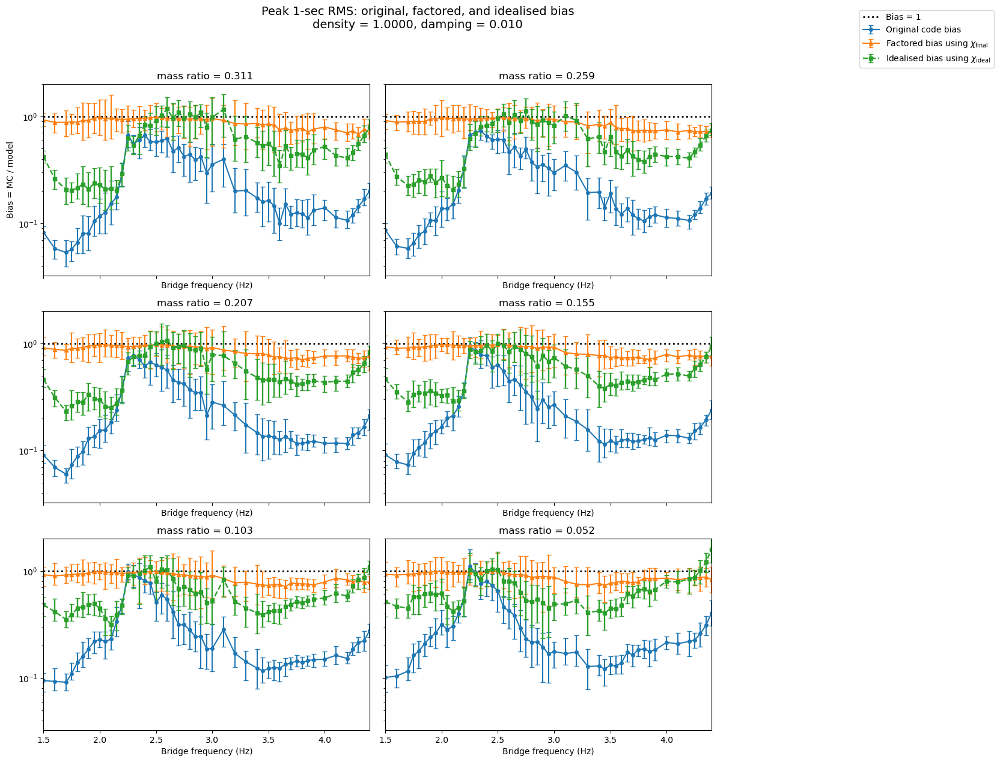

C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\118678662.py:449: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)


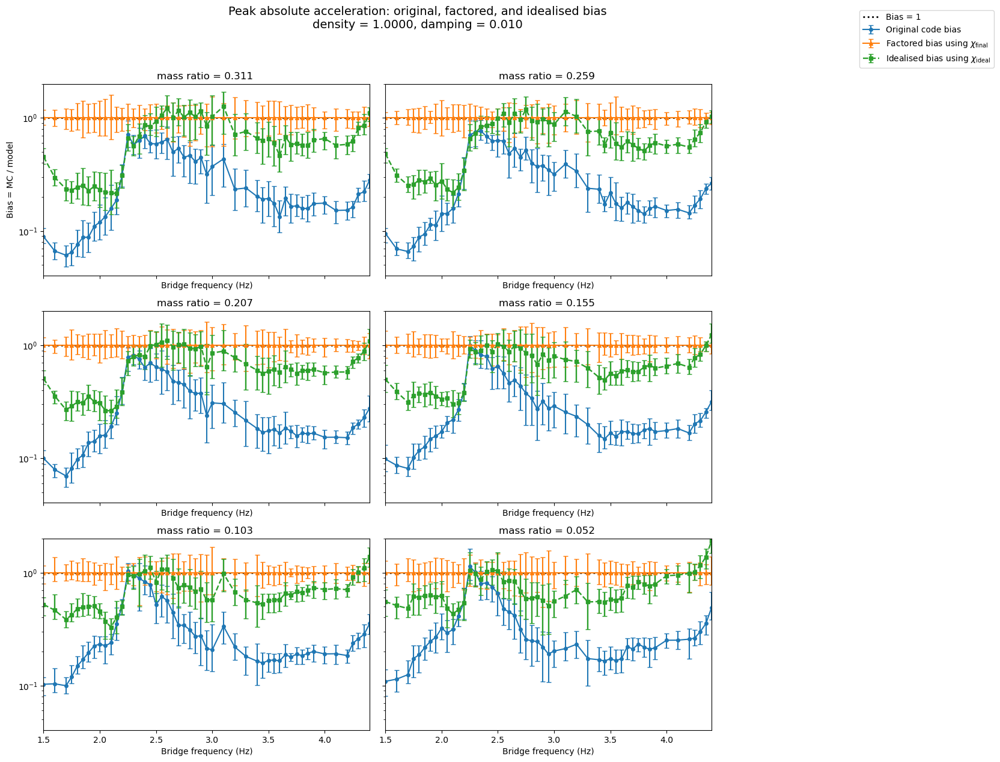

C:\Users\slok0019\AppData\Local\Temp\ipykernel_23140\118678662.py:449: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)


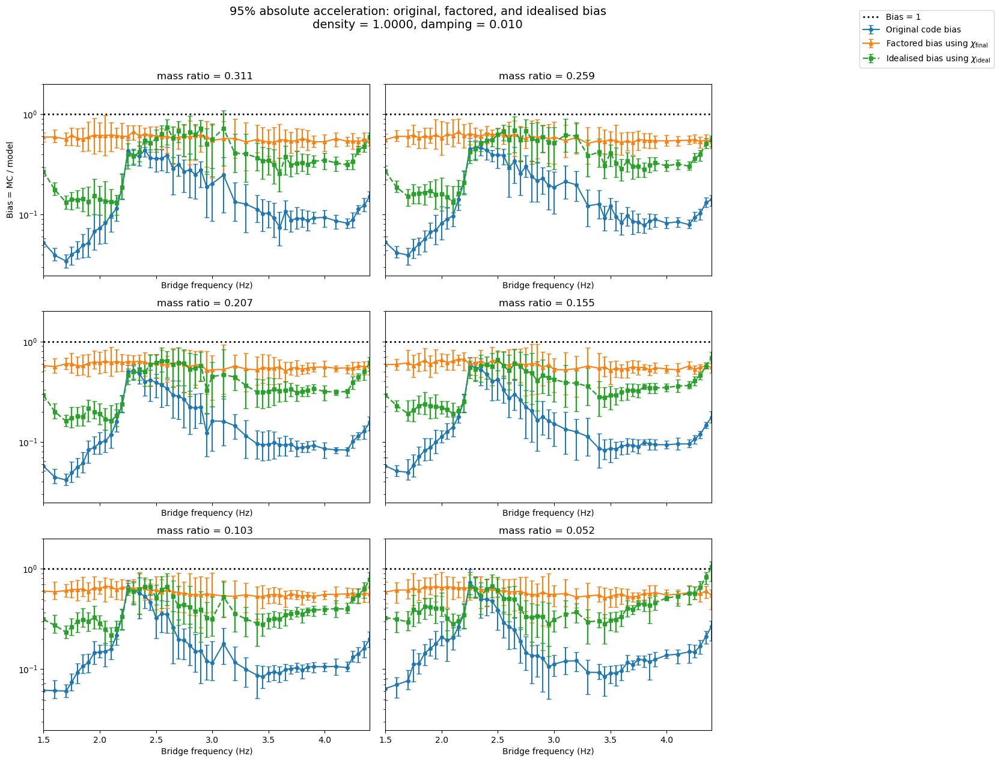

In [30]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DENSITY = 1.0000
TARGET_DAMPING = 0.010

# New linear masses corresponding approximately to:
# mu = 0.30, 0.25, 0.20, 0.15, 0.10, 0.05
LINEAR_MASSES_TO_LOAD = [483, 580, 725, 967, 1450, 2900]

# Reference:
# For density = 1 and linear mass = 500 kg/m, mass ratio ≈ 0.30
REFERENCE_LINEAR_MASS = 500.0
REFERENCE_MASS_RATIO = 0.30

Y_COL_FACTOR = "final_modification_factor"

MEASURES_TO_PLOT = [
    "Peak 1-sec RMS",
    "Peak absolute acceleration",
    "95% absolute acceleration",
]

PLOT_FMIN = 1.50
PLOT_FMAX = 4.40

SAVE_PLOTS = False

USE_LOG_Y = True
YMIN = 0.10
YMAX = 3.00

EPS = 1e-12

# ==================================================
# NEW IDEALISED EQUATION PARAMETERS
# From fitted result for damping = 0.010
# ==================================================

IDEAL_PARAMS = {
    "y0": 0.09487318,
    "B": 1.19353288e-01,
    "mu": 0.16073981,
    "alpha": 0.55129458,
    "zeta_b": 0.01000000,
    "zeta_a": 0.38537211,
    "beta_p": 1.00980163,
    "f_p": 2.25000000,
}

# ==================================================
# MASS RATIO FUNCTION
# ==================================================

def linear_mass_to_mass_ratio(linear_mass):
    """
    For density = 1.0000:
        lm = 500 kg/m -> mass ratio = 0.30

    Since bridge modal mass scales with linear mass:
        mass_ratio = 0.30 * 500 / linear_mass
    """
    return REFERENCE_MASS_RATIO * REFERENCE_LINEAR_MASS / linear_mass


# ==================================================
# Q(beta) AND IDEALISED FACTOR
# ==================================================

def Q_mmd(beta, mu, alpha, zeta_b, zeta_a):
    beta = np.asarray(beta, dtype=float)

    N_R = alpha**2 - beta**2
    N_I = 2.0 * zeta_a * alpha * beta

    D_R = (
        (1.0 - beta**2) * (alpha**2 - beta**2)
        - 4.0 * zeta_b * zeta_a * alpha * beta**2
        - mu * alpha**2 * beta**2
    )

    D_I = (
        2.0 * beta
        * (
            zeta_a * alpha * (1.0 - (1.0 + mu) * beta**2)
            + zeta_b * (alpha**2 - beta**2)
        )
    )

    numerator_abs = np.sqrt(N_R**2 + N_I**2)
    denominator_abs = np.sqrt(D_R**2 + D_I**2)

    return beta**2 * numerator_abs / (denominator_abs + 1e-14)


def chi_ideal_from_params(f_bridge, params):
    f_bridge = np.asarray(f_bridge, dtype=float)

    beta_eff = params["beta_p"] * f_bridge / params["f_p"]

    Q_eff = Q_mmd(
        beta=beta_eff,
        mu=params["mu"],
        alpha=params["alpha"],
        zeta_b=params["zeta_b"],
        zeta_a=params["zeta_a"]
    )

    return params["y0"] + params["B"] * Q_eff


# ==================================================
# LOAD lm SUMMARY FILES
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"lm(?P<linear_mass>\d+)_"
    r"bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_lm*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:

    match = pattern.match(file.name)

    if match is None:
        print("Skipping file:", file.name)
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_linear_mass = int(match.group("linear_mass"))

    if not np.isclose(file_density, TARGET_DENSITY):
        continue

    if not np.isclose(file_damping, TARGET_DAMPING):
        continue

    if file_linear_mass not in LINEAR_MASSES_TO_LOAD:
        continue

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["linear_mass"] = file_linear_mass

    # Convert linear mass to mass ratio
    df["mass_ratio"] = linear_mass_to_mass_ratio(file_linear_mass)

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError(
        f"No matching lm files found for density={TARGET_DENSITY:.4f}, "
        f"damping={TARGET_DAMPING:.3f}"
    )

combined_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded combined dataframe shape:", combined_df.shape)


# ==================================================
# CLEAN DATA
# ==================================================

num_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "linear_mass",
    "mass_ratio",
    Y_COL_FACTOR,

    "code_bias_mean", "code_bias_p5", "code_bias_p50", "code_bias_p95",
    "corrected_bias_mean", "corrected_bias_p5", "corrected_bias_p50", "corrected_bias_p95",
]

for col in num_cols:
    if col in combined_df.columns:
        combined_df[col] = pd.to_numeric(combined_df[col], errors="coerce")

required_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "linear_mass",
    "mass_ratio",
    Y_COL_FACTOR,
    "measure",
    "code_bias_mean",
    "code_bias_p5",
    "code_bias_p95",
    "corrected_bias_mean",
    "corrected_bias_p5",
    "corrected_bias_p95",
]

missing = [col for col in required_cols if col not in combined_df.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

combined_df = combined_df.dropna(subset=required_cols).copy()

combined_df["density_key"] = combined_df["target_density"].round(4)
combined_df["damping_key"] = combined_df["target_beamdamp"].round(3)
combined_df["linear_mass_key"] = combined_df["linear_mass"].round(0).astype(int)

# This is the important new key
combined_df["mass_ratio_key"] = combined_df["mass_ratio"].round(4)

combined_df = combined_df[
    (combined_df["bridge_frequency"] >= PLOT_FMIN) &
    (combined_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

combined_df = combined_df.sort_values(
    ["mass_ratio_key", "measure", "bridge_frequency"]
).reset_index(drop=True)


print("\nLinear mass to mass ratio mapping:")
print(
    combined_df[
        ["linear_mass_key", "mass_ratio_key"]
    ]
    .drop_duplicates()
    .sort_values("mass_ratio_key", ascending=False)
)


# ==================================================
# CALCULATE IDEALISED FACTOR AND IDEALISED BIAS
# ==================================================

combined_df["chi_final"] = combined_df[Y_COL_FACTOR]

combined_df["chi_ideal"] = chi_ideal_from_params(
    combined_df["bridge_frequency"].to_numpy(),
    IDEAL_PARAMS
)

combined_df["chi_ideal"] = np.maximum(combined_df["chi_ideal"], EPS)

# corrected_bias = MC / (simplified * chi_final)
# idealised_bias = MC / (simplified * chi_ideal)
#
# Therefore:
# idealised_bias = corrected_bias * chi_final / chi_ideal

combined_df["bias_scale_final_to_ideal"] = (
    combined_df["chi_final"] / combined_df["chi_ideal"]
)

for stat in ["mean", "p5", "p50", "p95"]:
    combined_df[f"idealized_bias_{stat}"] = (
        combined_df[f"corrected_bias_{stat}"]
        * combined_df["bias_scale_final_to_ideal"]
    )


print("\nExample rows after idealised bias adjustment:")
print(
    combined_df[
        [
            "mass_ratio_key",
            "linear_mass_key",
            "bridge_frequency",
            "measure",
            "chi_final",
            "chi_ideal",
            "code_bias_mean",
            "corrected_bias_mean",
            "idealized_bias_mean",
        ]
    ].head(12)
)


# ==================================================
# HELPER FUNCTION
# ==================================================

def make_yerr(df, mean_col, p5_col, p95_col):
    lower = df[mean_col].to_numpy() - df[p5_col].to_numpy()
    upper = df[p95_col].to_numpy() - df[mean_col].to_numpy()

    lower = np.maximum(lower, 0.0)
    upper = np.maximum(upper, 0.0)

    return np.vstack([lower, upper])


# ==================================================
# PLOT FUNCTION
# One figure per measure
# One subplot per mass ratio
# ==================================================

def plot_bias_for_measure(measure_name):

    measure_df = combined_df[
        combined_df["measure"].astype(str) == measure_name
    ].copy()

    if measure_df.empty:
        print(f"Skipping measure because no rows found: {measure_name}")
        return

    # Sort from highest mass ratio to lowest
    mass_ratios = sorted(
        measure_df["mass_ratio_key"].dropna().unique(),
        reverse=True
    )

    n = len(mass_ratios)
    ncols = 2
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(14, 4.3 * nrows),
        sharex=True,
        sharey=True
    )

    axes = np.asarray(axes).reshape(-1)

    for ax, mr in zip(axes, mass_ratios):

        sub = measure_df[
            np.isclose(measure_df["mass_ratio_key"], mr)
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        lm_values = sorted(sub["linear_mass_key"].dropna().unique())

        if len(lm_values) == 1:
            title_label = f"mass ratio = {mr:.3f} "
        else:
            title_label = f"mass ratio = {mr:.3f}"

        ax.axhline(
            1.0,
            linestyle=":",
            linewidth=2,
            color="black",
            label="Bias = 1"
        )

        # --------------------------------------------------
        # Original code bias
        # --------------------------------------------------
        ax.errorbar(
            sub["bridge_frequency"],
            sub["code_bias_mean"],
            yerr=make_yerr(
                sub,
                "code_bias_mean",
                "code_bias_p5",
                "code_bias_p95"
            ),
            marker="o",
            markersize=4,
            capsize=3,
            linewidth=1.5,
            label="Original code bias"
        )

        # --------------------------------------------------
        # Factored bias using chi_final
        # --------------------------------------------------
        ax.errorbar(
            sub["bridge_frequency"],
            sub["corrected_bias_mean"],
            yerr=make_yerr(
                sub,
                "corrected_bias_mean",
                "corrected_bias_p5",
                "corrected_bias_p95"
            ),
            marker="^",
            markersize=4,
            capsize=3,
            linewidth=1.5,
            label=r"Factored bias using $\chi_{\mathrm{final}}$"
        )

        # --------------------------------------------------
        # Idealised factor bias using new equation
        # --------------------------------------------------
        ax.errorbar(
            sub["bridge_frequency"],
            sub["idealized_bias_mean"],
            yerr=make_yerr(
                sub,
                "idealized_bias_mean",
                "idealized_bias_p5",
                "idealized_bias_p95"
            ),
            marker="s",
            markersize=4,
            capsize=3,
            linewidth=1.7,
            linestyle="--",
            label=r"Idealised bias using $\chi_{\mathrm{ideal}}$"
        )

        ax.set_title(title_label)
        ax.set_xlabel("Bridge frequency (Hz)")
        ax.set_xlim(PLOT_FMIN, PLOT_FMAX)

        if USE_LOG_Y:
            ax.set_yscale("log")
            ax.set_ylim(0, 2)
        else:
            ax.set_ylim(0.0, YMAX)

    axes[0].set_ylabel("Bias = MC / model")

    # Remove unused subplot
    for j in range(len(mass_ratios), len(axes)):
        fig.delaxes(axes[j])

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        bbox_to_anchor=(1.02, 0.98),
        loc="upper left"
    )

    fig.suptitle(
        f"{measure_name}: original, factored, and idealised bias\n"
        f"density = {TARGET_DENSITY:.4f}, damping = {TARGET_DAMPING:.3f}",
        fontsize=14
    )

    fig.tight_layout(rect=[0, 0, 0.86, 0.95])

    if SAVE_PLOTS:
        safe_measure = (
            measure_name
            .replace(" ", "_")
            .replace("%", "pct")
            .replace("/", "_")
        )

        fig_name = (
            f"bias_original_factored_idealised_"
            f"density{TARGET_DENSITY:.4f}_"
            f"damping{TARGET_DAMPING:.3f}_"
            f"{safe_measure}_all_mass_ratios.png"
        )

        fig.savefig(fig_name, dpi=300, bbox_inches="tight")
        print("Saved:", fig_name)

    plt.show()


# ==================================================
# MAKE THE 3 FIGURES
# ==================================================

for measure_name in MEASURES_TO_PLOT:
    plot_bias_for_measure(measure_name)


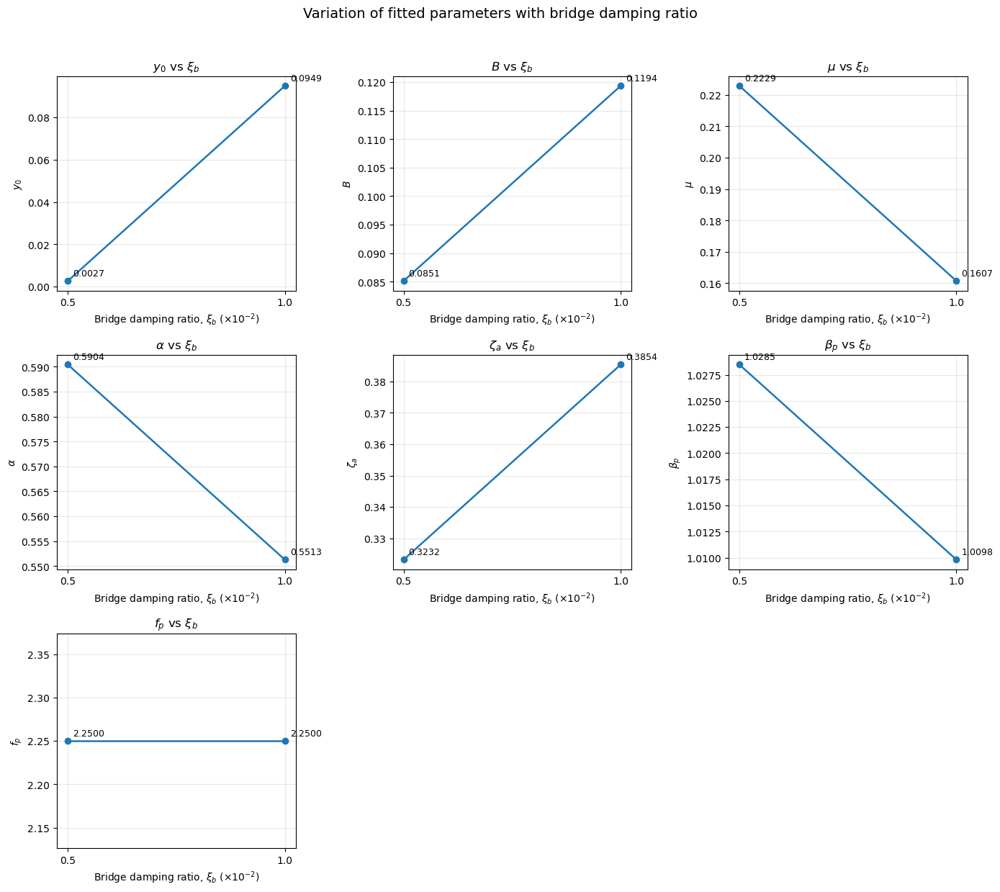

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# FITTED PARAMETERS VS BRIDGE DAMPING xi_b
# ==========================================

df_params = pd.DataFrame({
    "xi_b":    [0.005, 0.010],

    # From fitted equation for xi_b = 0.005
    # and xi_b = 0.010
    "y0":      [0.00269915, 0.09487318],
    "B":       [8.51265033e-02, 1.19353288e-01],
    "mu":      [0.22286233, 0.16073981],
    "alpha":   [0.59041978, 0.55129458],
    "zeta_a":  [0.32317373, 0.38537211],
    "beta_p":  [1.02847141, 1.00980163],
    "f_p":     [2.25, 2.25],
})

# Scale damping for x-axis display
df_params["xi_b_scaled"] = df_params["xi_b"] * 1e2

# Mapping from column names to symbols
symbol_labels = {
    "y0": r"$y_0$",
    "B": r"$B$",
    "mu": r"$\mu$",
    "alpha": r"$\alpha$",
    "zeta_a": r"$\zeta_a$",
    "beta_p": r"$\beta_p$",
    "f_p": r"$f_p$",
    "xi_b": r"$\xi_b$",
}

# Unknown/fitted parameters to plot
params_to_plot = ["y0", "B", "mu", "alpha", "zeta_a", "beta_p", "f_p"]

n = len(params_to_plot)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.2 * nrows))
axes = np.asarray(axes).reshape(-1)

for ax, param in zip(axes, params_to_plot):

    ax.plot(
        df_params["xi_b_scaled"],
        df_params[param],
        marker="o",
        linewidth=1.8,
        markersize=6
    )

    for x, y in zip(df_params["xi_b_scaled"], df_params[param]):
        ax.annotate(
            f"{y:.4f}",
            (x, y),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

    ax.set_title(f"{symbol_labels[param]} vs {symbol_labels['xi_b']}")
    ax.set_xlabel(r"Bridge damping ratio, $\xi_b$ $(\times 10^{-2})$")
    ax.set_ylabel(symbol_labels[param])

    ax.set_xticks(df_params["xi_b_scaled"])
    ax.set_xticklabels([f"{x:.1f}" for x in df_params["xi_b_scaled"]])

    ax.grid(True, alpha=0.3)

# Remove unused axes
for j in range(len(params_to_plot), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Variation of fitted parameters with bridge damping ratio", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Loading: density1.0000_damping0.005_lm1000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm1500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm2000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm750_bias_summary.pkl

Loaded combined dataframe shape: (945, 41)

Frequency coverage:
   linear_mass_key   min   max  count
0              500  1.26  4.55     60
1              750  1.26  4.55     60
2             1000  1.26  4.55     60
3             1500  1.26  4.55     60
4             2000  1.26  4.55     60

Number of fitting points: 50
Fitting frequency range: 1.5 to 4.4

Initial guesses
----------------
y0       = 0.052699
B        = 5.404707e-02
mu       = 0.183065
alpha    = 0.510706
zeta_a   = 0.399814
beta_p0  = 1.008401

Fitted parameters
-----------------
y0              = 0.00269915
B               = 8.51265033e-02
mu              = 0.22286233
alpha           = 0.59041978
zeta_b          = 0.00500000

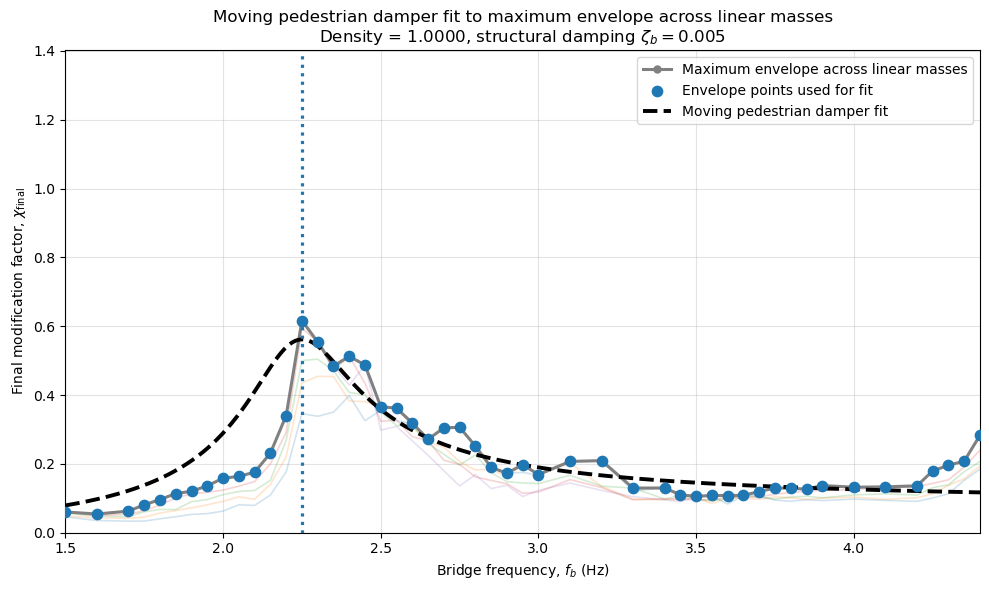


FINAL FITTED IDEAL MODIFICATION FACTOR EQUATION

Model form:
chi_ideal(f_b) = y0 + B * Q(beta_eff)
beta_eff       = beta_p * f_b / f_p
f_p            = 2.25 Hz

Fitted equation:
chi_ideal(f_b) = 0.002699 + 8.512650e-02 * Q(1.028471 * f_b / 2.250000)

Fitted parameters:
y0       = 0.00269915
B        = 8.51265033e-02
mu       = 0.22286233
alpha    = 0.59041978
zeta_b   = 0.00500000
zeta_a   = 0.32317373
beta_p   = 1.02847141
f_p      = 2.25000000 Hz


In [32]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import least_squares

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DENSITY = 1.0000
TARGET_DAMPING = 0.005

Y_COL = "final_modification_factor"

FIT_FMIN = 1.50
FIT_FMAX = 4.40

PLOT_FMIN = 1.50
PLOT_FMAX = 4.40

F_TARGET_PEAK = 2.25

zeta_b = TARGET_DAMPING

BETA_MIN = 0.20
BETA_MAX = 3.00
N_BETA_PEAK = 6000

eps = 1e-12


# ==================================================
# LOAD NEW lm FILES
# Expected names:
# density1.0000_damping0.005_lm500_bias_summary.pkl
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"lm(?P<linear_mass>\d+)_"
    r"bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_lm*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:

    match = pattern.match(file.name)

    if match is None:
        print("Skipping file because name does not match expected pattern:", file.name)
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_linear_mass = float(match.group("linear_mass"))

    # Keep only target density and damping
    if not np.isclose(file_density, TARGET_DENSITY):
        continue

    if not np.isclose(file_damping, TARGET_DAMPING):
        continue

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["linear_mass"] = file_linear_mass

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError(
        "No matching lm summary files found for "
        f"density={TARGET_DENSITY:.4f}, damping={TARGET_DAMPING:.3f}"
    )

corrected_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded combined dataframe shape:", corrected_df.shape)


# ==================================================
# CLEAN NUMERIC COLUMNS
# ==================================================

needed_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "linear_mass",
    Y_COL,
]

for col in needed_cols:
    corrected_df[col] = pd.to_numeric(corrected_df[col], errors="coerce")

corrected_df = corrected_df.dropna(subset=needed_cols).copy()

corrected_df["density_key"] = corrected_df["target_density"].round(4)
corrected_df["damping_key"] = corrected_df["target_beamdamp"].round(3)
corrected_df["linear_mass_key"] = corrected_df["linear_mass"].round(0).astype(int)

# Remove repeated rows if the pkl has multiple measures
sort_cols = ["linear_mass_key", "bridge_frequency"]

if "measure" in corrected_df.columns:
    corrected_df = corrected_df.sort_values(sort_cols)
    corrected_df = corrected_df.drop_duplicates(
        subset=["linear_mass_key", "bridge_frequency"],
        keep="first"
    ).copy()

corrected_df = corrected_df.sort_values(
    ["linear_mass_key", "bridge_frequency"]
).reset_index(drop=True)

print("\nFrequency coverage:")
coverage = (
    corrected_df
    .groupby("linear_mass_key")["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)
print(coverage)


# ==================================================
# MAXIMUM ENVELOPE ACROSS LINEAR MASSES
# ==================================================

env_df = (
    corrected_df
    .groupby("bridge_frequency", as_index=False)
    .agg(
        envelope_factor=(Y_COL, "max")
    )
    .sort_values("bridge_frequency")
)

fit_source_df = env_df.copy()

fit_df = fit_source_df[
    (fit_source_df["bridge_frequency"] >= FIT_FMIN) &
    (fit_source_df["bridge_frequency"] <= FIT_FMAX) &
    (fit_source_df["envelope_factor"] > 0)
].copy()

x_fit = fit_df["bridge_frequency"].to_numpy()
y_fit = fit_df["envelope_factor"].to_numpy()

if len(x_fit) < 8:
    raise ValueError("Too few envelope points in fitting range.")

print("\nNumber of fitting points:", len(x_fit))
print("Fitting frequency range:", x_fit.min(), "to", x_fit.max())


# ==================================================
# CLOSED-FORM MMD / TMD ACCELERATION SHAPE Q(beta)
# ==================================================

def Q_mmd(beta, mu, alpha, zeta_b, zeta_a):
    beta = np.asarray(beta, dtype=float)

    N_R = alpha**2 - beta**2
    N_I = 2.0 * zeta_a * alpha * beta

    D_R = (
        (1.0 - beta**2) * (alpha**2 - beta**2)
        - 4.0 * zeta_b * zeta_a * alpha * beta**2
        - mu * alpha**2 * beta**2
    )

    D_I = (
        2.0 * beta
        * (
            zeta_a * alpha * (1.0 - (1.0 + mu) * beta**2)
            + zeta_b * (alpha**2 - beta**2)
        )
    )

    numerator_abs = np.sqrt(N_R**2 + N_I**2)
    denominator_abs = np.sqrt(D_R**2 + D_I**2)

    return beta**2 * numerator_abs / (denominator_abs + 1e-14)


def beta_peak_for_parameters(mu, alpha, zeta_a, zeta_b):
    beta_grid = np.linspace(BETA_MIN, BETA_MAX, N_BETA_PEAK)

    Q_grid = Q_mmd(
        beta=beta_grid,
        mu=mu,
        alpha=alpha,
        zeta_b=zeta_b,
        zeta_a=zeta_a
    )

    return beta_grid[np.nanargmax(Q_grid)]


def chi_peak_locked_B_model(f_bridge, y0, B, mu, alpha, zeta_a):
    beta_p = beta_peak_for_parameters(
        mu=mu,
        alpha=alpha,
        zeta_a=zeta_a,
        zeta_b=zeta_b
    )

    beta_eff = beta_p * (f_bridge / F_TARGET_PEAK)

    Q_eff = Q_mmd(
        beta=beta_eff,
        mu=mu,
        alpha=alpha,
        zeta_b=zeta_b,
        zeta_a=zeta_a
    )

    return y0 + B * Q_eff


# ==================================================
# INITIAL GUESSES
# ==================================================

previous_fits = {
    0.005: {
        "y0": 0.12625630,
        "B":  1.57791445e-01,
        "mu": 0.18306454,
        "alpha": 0.51070586,
        "zeta_a": 0.39981395,
    },
    0.010: {
        "y0": 0.14782840,
        "B":  2.02927309e-01,
        "mu": 0.16074344,
        "alpha": 0.55129448,
        "zeta_a": 0.38537497,
    },
    0.020: {
        "y0": 0.19097260,
        "B":  2.93199037e-01,
        "mu": 0.11610124,
        "alpha": 0.63247172,
        "zeta_a": 0.35649701,
    },
}

if zeta_b in previous_fits:
    mu0 = previous_fits[zeta_b]["mu"]
    alpha0 = previous_fits[zeta_b]["alpha"]
    zeta_a0 = previous_fits[zeta_b]["zeta_a"]
else:
    damping_arr = np.array(sorted(previous_fits.keys()))
    mu_arr = np.array([previous_fits[d]["mu"] for d in damping_arr])
    alpha_arr = np.array([previous_fits[d]["alpha"] for d in damping_arr])
    zeta_a_arr = np.array([previous_fits[d]["zeta_a"] for d in damping_arr])

    mu0 = np.interp(zeta_b, damping_arr, mu_arr)
    alpha0 = np.interp(zeta_b, damping_arr, alpha_arr)
    zeta_a0 = np.interp(zeta_b, damping_arr, zeta_a_arr)

mu0 = np.clip(mu0, 0.001, 0.50)
alpha0 = np.clip(alpha0, 0.50, 1.50)
zeta_a0 = np.clip(zeta_a0, 0.30, 2.00)

beta_p0 = beta_peak_for_parameters(
    mu=mu0,
    alpha=alpha0,
    zeta_a=zeta_a0,
    zeta_b=zeta_b
)

beta_eff0 = beta_p0 * (x_fit / F_TARGET_PEAK)

Q0 = Q_mmd(
    beta=beta_eff0,
    mu=mu0,
    alpha=alpha0,
    zeta_b=zeta_b,
    zeta_a=zeta_a0
)

X0 = np.column_stack([np.ones_like(Q0), Q0])
y0_guess, B_guess = np.linalg.lstsq(X0, y_fit, rcond=None)[0]

y0_guess = max(y0_guess, 1e-8)
B_guess = max(B_guess, 1e-8)

p0 = np.array([
    y0_guess,
    B_guess,
    mu0,
    alpha0,
    zeta_a0
])

print("\nInitial guesses")
print("----------------")
print(f"y0       = {p0[0]:.6f}")
print(f"B        = {p0[1]:.6e}")
print(f"mu       = {p0[2]:.6f}")
print(f"alpha    = {p0[3]:.6f}")
print(f"zeta_a   = {p0[4]:.6f}")
print(f"beta_p0  = {beta_p0:.6f}")


# ==================================================
# BOUNDS
# ==================================================

ymax = np.nanmax(y_fit)

lower_bounds = np.array([
    0.0,      # y0
    0.0,      # B
    0.001,    # mu
    0.50,     # alpha
    0.30      # zeta_a
])

upper_bounds = np.array([
    5.0 * ymax,  # y0
    1e6,         # B
    0.50,        # mu
    1.50,        # alpha
    2.00         # zeta_a
])


# ==================================================
# FIT OBJECTIVE
# ==================================================

RIGHT_SHOULDER_WEIGHT = 2.00
POST_PEAK_SHOULDER_WEIGHT = 1.50
PEAK_WEIGHT_STRENGTH = 0.20

def residuals(p):
    y0, B, mu, alpha, zeta_a = p

    y_model = chi_peak_locked_B_model(
        f_bridge=x_fit,
        y0=y0,
        B=B,
        mu=mu,
        alpha=alpha,
        zeta_a=zeta_a
    )

    if np.any(y_model <= 0):
        return 1e6 * np.ones_like(y_fit)

    res = np.log(y_model + eps) - np.log(y_fit + eps)

    peak_weight = 1.0 + PEAK_WEIGHT_STRENGTH * np.exp(
        -0.5 * ((x_fit - F_TARGET_PEAK) / 0.25)**2
    )

    right_weight = np.where(
        x_fit > F_TARGET_PEAK,
        RIGHT_SHOULDER_WEIGHT,
        1.0
    )

    post_peak_weight = np.where(
        (x_fit >= 2.35) & (x_fit <= 3.00),
        POST_PEAK_SHOULDER_WEIGHT,
        1.0
    )

    return peak_weight * right_weight * post_peak_weight * res


# ==================================================
# RUN OPTIMIZATION
# ==================================================

result = least_squares(
    residuals,
    p0,
    bounds=(lower_bounds, upper_bounds),
    loss="soft_l1",
    f_scale=0.1,
    max_nfev=50000
)

y0_fit, B_fit, mu_fit, alpha_fit, zeta_a_fit = result.x

beta_p_fit = beta_peak_for_parameters(
    mu=mu_fit,
    alpha=alpha_fit,
    zeta_a=zeta_a_fit,
    zeta_b=zeta_b
)

Q_beta_p_fit = Q_mmd(
    beta=beta_p_fit,
    mu=mu_fit,
    alpha=alpha_fit,
    zeta_b=zeta_b,
    zeta_a=zeta_a_fit
)

A_equivalent = B_fit * Q_beta_p_fit

print("\nFitted parameters")
print("-----------------")
print(f"y0              = {y0_fit:.8f}")
print(f"B               = {B_fit:.8e}")
print(f"mu              = {mu_fit:.8f}")
print(f"alpha           = {alpha_fit:.8f}")
print(f"zeta_b          = {zeta_b:.8f} fixed")
print(f"zeta_a          = {zeta_a_fit:.8f}")
print(f"beta_p          = {beta_p_fit:.8f}")
print(f"Q(beta_p)       = {Q_beta_p_fit:.8f}")
print(f"A equivalent    = B * Q(beta_p) = {A_equivalent:.8f}")
print("Success:", result.success)
print("Message:", result.message)
print("Cost:", result.cost)


# ==================================================
# SMOOTH FITTED CURVE
# ==================================================

x_smooth = np.linspace(FIT_FMIN, FIT_FMAX, 1500)

y_smooth = chi_peak_locked_B_model(
    f_bridge=x_smooth,
    y0=y0_fit,
    B=B_fit,
    mu=mu_fit,
    alpha=alpha_fit,
    zeta_a=zeta_a_fit
)

peak_idx = np.nanargmax(y_smooth)

print("\nFitted curve check")
print("------------------")
print(f"Checked peak frequency = {x_smooth[peak_idx]:.6f} Hz")
print(f"Checked peak value     = {y_smooth[peak_idx]:.6f}")


# ==================================================
# PLOT LIKE YOUR FIGURE
# Original lm curves + maximum envelope + fitted curve
# ==================================================

plt.figure(figsize=(10, 6))

# Original linear-mass curves
for lm in sorted(corrected_df["linear_mass_key"].dropna().unique()):

    sub = corrected_df[
        corrected_df["linear_mass_key"] == lm
    ].copy()

    sub = sub.sort_values("bridge_frequency")

    plt.plot(
        sub["bridge_frequency"],
        sub[Y_COL],
        linewidth=1.2,
        alpha=0.20,
        label=None
    )

# Maximum envelope across linear masses
plt.plot(
    env_df["bridge_frequency"],
    env_df["envelope_factor"],
    "o-",
    linewidth=2.2,
    markersize=5,
    color="gray",
    label="Maximum envelope across linear masses"
)

# Points used for fit
plt.scatter(
    x_fit,
    y_fit,
    s=55,
    zorder=5,
    color="tab:blue",
    label="Envelope points used for fit"
)

# Fitted curve
plt.plot(
    x_smooth,
    y_smooth,
    "k--",
    linewidth=2.8,
    label="Moving pedestrian damper fit"
)

# Locked peak line
plt.axvline(
    F_TARGET_PEAK,
    linestyle=":",
    linewidth=2.3,
    color="tab:blue"
)

plt.xlabel(r"Bridge frequency, $f_b$ (Hz)")
plt.ylabel(r"Final modification factor, $\chi_{\mathrm{final}}$")

plt.title(
    "Moving pedestrian damper fit to maximum envelope across linear masses\n"
    rf"Density = {TARGET_DENSITY:.4f}, structural damping $\zeta_b={zeta_b:.3f}$"
)

plt.xlim(PLOT_FMIN, PLOT_FMAX)

ymax_plot = max(
    np.nanmax(env_df["envelope_factor"]),
    np.nanmax(y_smooth),
    np.nanmax(corrected_df[Y_COL])
)

plt.ylim(0, 1.15 * ymax_plot)

plt.grid(True, alpha=0.35)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


# ==================================================
# PRINT FINAL EQUATION
# ==================================================

print("\n" + "="*80)
print("FINAL FITTED IDEAL MODIFICATION FACTOR EQUATION")
print("="*80)

print("\nModel form:")
print("chi_ideal(f_b) = y0 + B * Q(beta_eff)")
print("beta_eff       = beta_p * f_b / f_p")
print("f_p            = 2.25 Hz")

print("\nFitted equation:")
print(
    f"chi_ideal(f_b) = {y0_fit:.6f} "
    f"+ {B_fit:.6e} * Q({beta_p_fit:.6f} * f_b / {F_TARGET_PEAK:.6f})"
)

print("\nFitted parameters:")
print(f"y0       = {y0_fit:.8f}")
print(f"B        = {B_fit:.8e}")
print(f"mu       = {mu_fit:.8f}")
print(f"alpha    = {alpha_fit:.8f}")
print(f"zeta_b   = {zeta_b:.8f}")
print(f"zeta_a   = {zeta_a_fit:.8f}")
print(f"beta_p   = {beta_p_fit:.8f}")
print(f"f_p      = {F_TARGET_PEAK:.8f} Hz")

print("="*80)

Loading: density1.0000_damping0.010_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.010_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.010_lm483_bias_summary.pkl
Loading: density1.0000_damping0.010_lm580_bias_summary.pkl
Loading: density1.0000_damping0.010_lm725_bias_summary.pkl
Loading: density1.0000_damping0.010_lm967_bias_summary.pkl

Loaded combined dataframe shape: (1134, 41)

Frequency coverage:
   linear_mass_key   min   max  count
0              483  1.26  4.55     60
1              580  1.26  4.55     60
2              725  1.26  4.55     60
3              967  1.26  4.55     60
4             1450  1.26  4.55     60
5             2900  1.26  4.55     60

Number of fitting points: 50
Fitting frequency range: 1.5 to 4.4

Initial guesses
----------------
y0       = 0.094881
B        = 1.001443e-01
mu       = 0.160743
alpha    = 0.551294
zeta_a   = 0.385375
beta_p0  = 1.009802

Fitted parameters
-----------------
y0              = 0.09487318
B               = 1.19

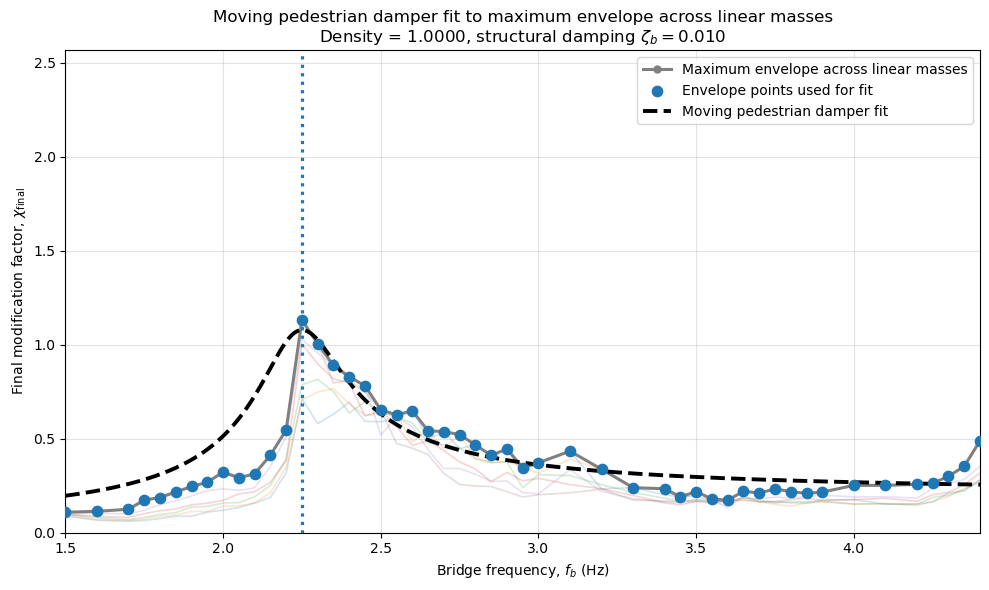


FINAL FITTED IDEAL MODIFICATION FACTOR EQUATION

Model form:
chi_ideal(f_b) = y0 + B * Q(beta_eff)
beta_eff       = beta_p * f_b / f_p
f_p            = 2.25 Hz

Fitted equation:
chi_ideal(f_b) = 0.094873 + 1.193533e-01 * Q(1.009802 * f_b / 2.250000)

Fitted parameters:
y0       = 0.09487318
B        = 1.19353288e-01
mu       = 0.16073981
alpha    = 0.55129458
zeta_b   = 0.01000000
zeta_a   = 0.38537211
beta_p   = 1.00980163
f_p      = 2.25000000 Hz


In [33]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import least_squares

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DENSITY = 1.0000
TARGET_DAMPING = 0.010

Y_COL = "final_modification_factor"

FIT_FMIN = 1.50
FIT_FMAX = 4.40

PLOT_FMIN = 1.50
PLOT_FMAX = 4.40

F_TARGET_PEAK = 2.25

zeta_b = TARGET_DAMPING

BETA_MIN = 0.20
BETA_MAX = 3.00
N_BETA_PEAK = 6000

eps = 1e-12


# ==================================================
# LOAD NEW lm FILES
# Expected names:
# density1.0000_damping0.005_lm500_bias_summary.pkl
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"lm(?P<linear_mass>\d+)_"
    r"bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_lm*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:

    match = pattern.match(file.name)

    if match is None:
        print("Skipping file because name does not match expected pattern:", file.name)
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_linear_mass = float(match.group("linear_mass"))

    # Keep only target density and damping
    if not np.isclose(file_density, TARGET_DENSITY):
        continue

    if not np.isclose(file_damping, TARGET_DAMPING):
        continue

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["linear_mass"] = file_linear_mass

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError(
        "No matching lm summary files found for "
        f"density={TARGET_DENSITY:.4f}, damping={TARGET_DAMPING:.3f}"
    )

corrected_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded combined dataframe shape:", corrected_df.shape)


# ==================================================
# CLEAN NUMERIC COLUMNS
# ==================================================

needed_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "linear_mass",
    Y_COL,
]

for col in needed_cols:
    corrected_df[col] = pd.to_numeric(corrected_df[col], errors="coerce")

corrected_df = corrected_df.dropna(subset=needed_cols).copy()

corrected_df["density_key"] = corrected_df["target_density"].round(4)
corrected_df["damping_key"] = corrected_df["target_beamdamp"].round(3)
corrected_df["linear_mass_key"] = corrected_df["linear_mass"].round(0).astype(int)

# Remove repeated rows if the pkl has multiple measures
sort_cols = ["linear_mass_key", "bridge_frequency"]

if "measure" in corrected_df.columns:
    corrected_df = corrected_df.sort_values(sort_cols)
    corrected_df = corrected_df.drop_duplicates(
        subset=["linear_mass_key", "bridge_frequency"],
        keep="first"
    ).copy()

corrected_df = corrected_df.sort_values(
    ["linear_mass_key", "bridge_frequency"]
).reset_index(drop=True)

print("\nFrequency coverage:")
coverage = (
    corrected_df
    .groupby("linear_mass_key")["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)
print(coverage)


# ==================================================
# MAXIMUM ENVELOPE ACROSS LINEAR MASSES
# ==================================================

env_df = (
    corrected_df
    .groupby("bridge_frequency", as_index=False)
    .agg(
        envelope_factor=(Y_COL, "max")
    )
    .sort_values("bridge_frequency")
)

fit_source_df = env_df.copy()

fit_df = fit_source_df[
    (fit_source_df["bridge_frequency"] >= FIT_FMIN) &
    (fit_source_df["bridge_frequency"] <= FIT_FMAX) &
    (fit_source_df["envelope_factor"] > 0)
].copy()

x_fit = fit_df["bridge_frequency"].to_numpy()
y_fit = fit_df["envelope_factor"].to_numpy()

if len(x_fit) < 8:
    raise ValueError("Too few envelope points in fitting range.")

print("\nNumber of fitting points:", len(x_fit))
print("Fitting frequency range:", x_fit.min(), "to", x_fit.max())


# ==================================================
# CLOSED-FORM MMD / TMD ACCELERATION SHAPE Q(beta)
# ==================================================

def Q_mmd(beta, mu, alpha, zeta_b, zeta_a):
    beta = np.asarray(beta, dtype=float)

    N_R = alpha**2 - beta**2
    N_I = 2.0 * zeta_a * alpha * beta

    D_R = (
        (1.0 - beta**2) * (alpha**2 - beta**2)
        - 4.0 * zeta_b * zeta_a * alpha * beta**2
        - mu * alpha**2 * beta**2
    )

    D_I = (
        2.0 * beta
        * (
            zeta_a * alpha * (1.0 - (1.0 + mu) * beta**2)
            + zeta_b * (alpha**2 - beta**2)
        )
    )

    numerator_abs = np.sqrt(N_R**2 + N_I**2)
    denominator_abs = np.sqrt(D_R**2 + D_I**2)

    return beta**2 * numerator_abs / (denominator_abs + 1e-14)


def beta_peak_for_parameters(mu, alpha, zeta_a, zeta_b):
    beta_grid = np.linspace(BETA_MIN, BETA_MAX, N_BETA_PEAK)

    Q_grid = Q_mmd(
        beta=beta_grid,
        mu=mu,
        alpha=alpha,
        zeta_b=zeta_b,
        zeta_a=zeta_a
    )

    return beta_grid[np.nanargmax(Q_grid)]


def chi_peak_locked_B_model(f_bridge, y0, B, mu, alpha, zeta_a):
    beta_p = beta_peak_for_parameters(
        mu=mu,
        alpha=alpha,
        zeta_a=zeta_a,
        zeta_b=zeta_b
    )

    beta_eff = beta_p * (f_bridge / F_TARGET_PEAK)

    Q_eff = Q_mmd(
        beta=beta_eff,
        mu=mu,
        alpha=alpha,
        zeta_b=zeta_b,
        zeta_a=zeta_a
    )

    return y0 + B * Q_eff


# ==================================================
# INITIAL GUESSES
# ==================================================

previous_fits = {
    0.005: {
        "y0": 0.12625630,
        "B":  1.57791445e-01,
        "mu": 0.18306454,
        "alpha": 0.51070586,
        "zeta_a": 0.39981395,
    },
    0.010: {
        "y0": 0.14782840,
        "B":  2.02927309e-01,
        "mu": 0.16074344,
        "alpha": 0.55129448,
        "zeta_a": 0.38537497,
    },
    0.020: {
        "y0": 0.19097260,
        "B":  2.93199037e-01,
        "mu": 0.11610124,
        "alpha": 0.63247172,
        "zeta_a": 0.35649701,
    },
}

if zeta_b in previous_fits:
    mu0 = previous_fits[zeta_b]["mu"]
    alpha0 = previous_fits[zeta_b]["alpha"]
    zeta_a0 = previous_fits[zeta_b]["zeta_a"]
else:
    damping_arr = np.array(sorted(previous_fits.keys()))
    mu_arr = np.array([previous_fits[d]["mu"] for d in damping_arr])
    alpha_arr = np.array([previous_fits[d]["alpha"] for d in damping_arr])
    zeta_a_arr = np.array([previous_fits[d]["zeta_a"] for d in damping_arr])

    mu0 = np.interp(zeta_b, damping_arr, mu_arr)
    alpha0 = np.interp(zeta_b, damping_arr, alpha_arr)
    zeta_a0 = np.interp(zeta_b, damping_arr, zeta_a_arr)

mu0 = np.clip(mu0, 0.001, 0.50)
alpha0 = np.clip(alpha0, 0.50, 1.50)
zeta_a0 = np.clip(zeta_a0, 0.30, 2.00)

beta_p0 = beta_peak_for_parameters(
    mu=mu0,
    alpha=alpha0,
    zeta_a=zeta_a0,
    zeta_b=zeta_b
)

beta_eff0 = beta_p0 * (x_fit / F_TARGET_PEAK)

Q0 = Q_mmd(
    beta=beta_eff0,
    mu=mu0,
    alpha=alpha0,
    zeta_b=zeta_b,
    zeta_a=zeta_a0
)

X0 = np.column_stack([np.ones_like(Q0), Q0])
y0_guess, B_guess = np.linalg.lstsq(X0, y_fit, rcond=None)[0]

y0_guess = max(y0_guess, 1e-8)
B_guess = max(B_guess, 1e-8)

p0 = np.array([
    y0_guess,
    B_guess,
    mu0,
    alpha0,
    zeta_a0
])

print("\nInitial guesses")
print("----------------")
print(f"y0       = {p0[0]:.6f}")
print(f"B        = {p0[1]:.6e}")
print(f"mu       = {p0[2]:.6f}")
print(f"alpha    = {p0[3]:.6f}")
print(f"zeta_a   = {p0[4]:.6f}")
print(f"beta_p0  = {beta_p0:.6f}")


# ==================================================
# BOUNDS
# ==================================================

ymax = np.nanmax(y_fit)

lower_bounds = np.array([
    0.0,      # y0
    0.0,      # B
    0.001,    # mu
    0.50,     # alpha
    0.30      # zeta_a
])

upper_bounds = np.array([
    5.0 * ymax,  # y0
    1e6,         # B
    0.50,        # mu
    1.50,        # alpha
    2.00         # zeta_a
])


# ==================================================
# FIT OBJECTIVE
# ==================================================

RIGHT_SHOULDER_WEIGHT = 2.00
POST_PEAK_SHOULDER_WEIGHT = 1.50
PEAK_WEIGHT_STRENGTH = 0.20

def residuals(p):
    y0, B, mu, alpha, zeta_a = p

    y_model = chi_peak_locked_B_model(
        f_bridge=x_fit,
        y0=y0,
        B=B,
        mu=mu,
        alpha=alpha,
        zeta_a=zeta_a
    )

    if np.any(y_model <= 0):
        return 1e6 * np.ones_like(y_fit)

    res = np.log(y_model + eps) - np.log(y_fit + eps)

    peak_weight = 1.0 + PEAK_WEIGHT_STRENGTH * np.exp(
        -0.5 * ((x_fit - F_TARGET_PEAK) / 0.25)**2
    )

    right_weight = np.where(
        x_fit > F_TARGET_PEAK,
        RIGHT_SHOULDER_WEIGHT,
        1.0
    )

    post_peak_weight = np.where(
        (x_fit >= 2.35) & (x_fit <= 3.00),
        POST_PEAK_SHOULDER_WEIGHT,
        1.0
    )

    return peak_weight * right_weight * post_peak_weight * res


# ==================================================
# RUN OPTIMIZATION
# ==================================================

result = least_squares(
    residuals,
    p0,
    bounds=(lower_bounds, upper_bounds),
    loss="soft_l1",
    f_scale=0.1,
    max_nfev=50000
)

y0_fit, B_fit, mu_fit, alpha_fit, zeta_a_fit = result.x

beta_p_fit = beta_peak_for_parameters(
    mu=mu_fit,
    alpha=alpha_fit,
    zeta_a=zeta_a_fit,
    zeta_b=zeta_b
)

Q_beta_p_fit = Q_mmd(
    beta=beta_p_fit,
    mu=mu_fit,
    alpha=alpha_fit,
    zeta_b=zeta_b,
    zeta_a=zeta_a_fit
)

A_equivalent = B_fit * Q_beta_p_fit

print("\nFitted parameters")
print("-----------------")
print(f"y0              = {y0_fit:.8f}")
print(f"B               = {B_fit:.8e}")
print(f"mu              = {mu_fit:.8f}")
print(f"alpha           = {alpha_fit:.8f}")
print(f"zeta_b          = {zeta_b:.8f} fixed")
print(f"zeta_a          = {zeta_a_fit:.8f}")
print(f"beta_p          = {beta_p_fit:.8f}")
print(f"Q(beta_p)       = {Q_beta_p_fit:.8f}")
print(f"A equivalent    = B * Q(beta_p) = {A_equivalent:.8f}")
print("Success:", result.success)
print("Message:", result.message)
print("Cost:", result.cost)


# ==================================================
# SMOOTH FITTED CURVE
# ==================================================

x_smooth = np.linspace(FIT_FMIN, FIT_FMAX, 1500)

y_smooth = chi_peak_locked_B_model(
    f_bridge=x_smooth,
    y0=y0_fit,
    B=B_fit,
    mu=mu_fit,
    alpha=alpha_fit,
    zeta_a=zeta_a_fit
)

peak_idx = np.nanargmax(y_smooth)

print("\nFitted curve check")
print("------------------")
print(f"Checked peak frequency = {x_smooth[peak_idx]:.6f} Hz")
print(f"Checked peak value     = {y_smooth[peak_idx]:.6f}")


# ==================================================
# PLOT LIKE YOUR FIGURE
# Original lm curves + maximum envelope + fitted curve
# ==================================================

plt.figure(figsize=(10, 6))

# Original linear-mass curves
for lm in sorted(corrected_df["linear_mass_key"].dropna().unique()):

    sub = corrected_df[
        corrected_df["linear_mass_key"] == lm
    ].copy()

    sub = sub.sort_values("bridge_frequency")

    plt.plot(
        sub["bridge_frequency"],
        sub[Y_COL],
        linewidth=1.2,
        alpha=0.20,
        label=None
    )

# Maximum envelope across linear masses
plt.plot(
    env_df["bridge_frequency"],
    env_df["envelope_factor"],
    "o-",
    linewidth=2.2,
    markersize=5,
    color="gray",
    label="Maximum envelope across linear masses"
)

# Points used for fit
plt.scatter(
    x_fit,
    y_fit,
    s=55,
    zorder=5,
    color="tab:blue",
    label="Envelope points used for fit"
)

# Fitted curve
plt.plot(
    x_smooth,
    y_smooth,
    "k--",
    linewidth=2.8,
    label="Moving pedestrian damper fit"
)

# Locked peak line
plt.axvline(
    F_TARGET_PEAK,
    linestyle=":",
    linewidth=2.3,
    color="tab:blue"
)

plt.xlabel(r"Bridge frequency, $f_b$ (Hz)")
plt.ylabel(r"Final modification factor, $\chi_{\mathrm{final}}$")

plt.title(
    "Moving pedestrian damper fit to maximum envelope across linear masses\n"
    rf"Density = {TARGET_DENSITY:.4f}, structural damping $\zeta_b={zeta_b:.3f}$"
)

plt.xlim(PLOT_FMIN, PLOT_FMAX)

ymax_plot = max(
    np.nanmax(env_df["envelope_factor"]),
    np.nanmax(y_smooth),
    np.nanmax(corrected_df[Y_COL])
)

plt.ylim(0, 1.15 * ymax_plot)

plt.grid(True, alpha=0.35)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


# ==================================================
# PRINT FINAL EQUATION
# ==================================================

print("\n" + "="*80)
print("FINAL FITTED IDEAL MODIFICATION FACTOR EQUATION")
print("="*80)

print("\nModel form:")
print("chi_ideal(f_b) = y0 + B * Q(beta_eff)")
print("beta_eff       = beta_p * f_b / f_p")
print("f_p            = 2.25 Hz")

print("\nFitted equation:")
print(
    f"chi_ideal(f_b) = {y0_fit:.6f} "
    f"+ {B_fit:.6e} * Q({beta_p_fit:.6f} * f_b / {F_TARGET_PEAK:.6f})"
)

print("\nFitted parameters:")
print(f"y0       = {y0_fit:.8f}")
print(f"B        = {B_fit:.8e}")
print(f"mu       = {mu_fit:.8f}")
print(f"alpha    = {alpha_fit:.8f}")
print(f"zeta_b   = {zeta_b:.8f}")
print(f"zeta_a   = {zeta_a_fit:.8f}")
print(f"beta_p   = {beta_p_fit:.8f}")
print(f"f_p      = {F_TARGET_PEAK:.8f} Hz")

print("="*80)

Loading: density1.0000_damping0.015_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.015_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.015_lm483_bias_summary.pkl
Loading: density1.0000_damping0.015_lm580_bias_summary.pkl
Loading: density1.0000_damping0.015_lm725_bias_summary.pkl
Loading: density1.0000_damping0.015_lm967_bias_summary.pkl

Loaded combined dataframe shape: (1134, 41)

Frequency coverage:
   linear_mass_key   min   max  count
0              483  1.26  4.55     60
1              580  1.26  4.55     60
2              725  1.26  4.55     60
3              967  1.26  4.55     60
4             1450  1.26  4.55     60
5             2900  1.26  4.55     60

Number of fitting points: 50
Fitting frequency range: 1.5 to 4.4

Initial guesses
----------------
y0       = 0.101739
B        = 1.520896e-01
mu       = 0.138422
alpha    = 0.591883
zeta_a   = 0.370936
beta_p0  = 1.011202

Fitted parameters
-----------------
y0              = 0.01292234
B               = 2.15

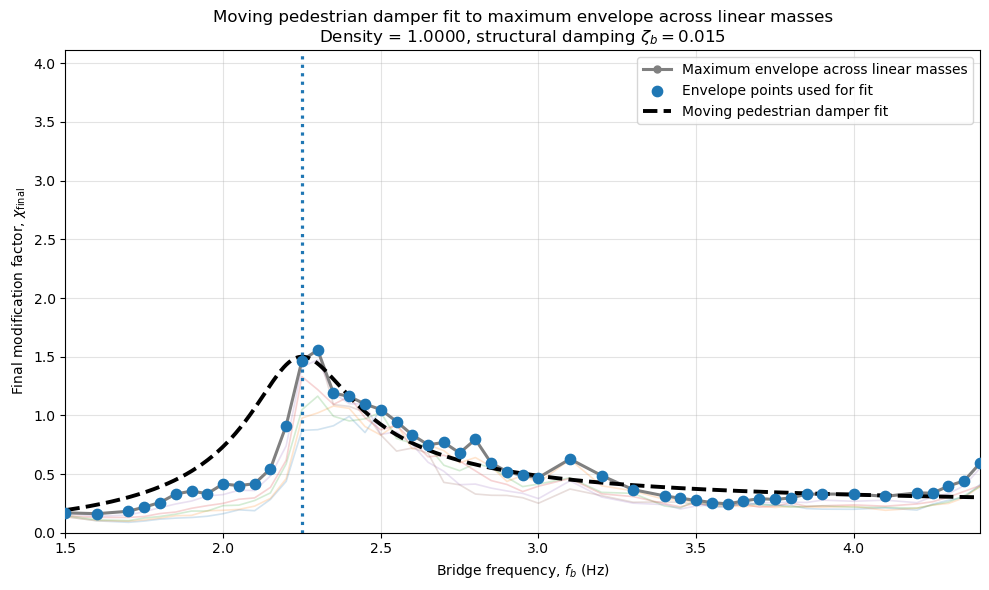


FINAL FITTED IDEAL MODIFICATION FACTOR EQUATION

Model form:
chi_ideal(f_b) = y0 + B * Q(beta_eff)
beta_eff       = beta_p * f_b / f_p
f_p            = 2.25 Hz

Fitted equation:
chi_ideal(f_b) = 0.012922 + 2.150562e-01 * Q(1.027071 * f_b / 2.250000)

Fitted parameters:
y0       = 0.01292234
B        = 2.15056173e-01
mu       = 0.24504529
alpha    = 0.51300792
zeta_b   = 0.01500000
zeta_a   = 0.30712497
beta_p   = 1.02707118
f_p      = 2.25000000 Hz


In [34]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import least_squares

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DENSITY = 1.0000
TARGET_DAMPING = 0.015

Y_COL = "final_modification_factor"

FIT_FMIN = 1.50
FIT_FMAX = 4.40

PLOT_FMIN = 1.50
PLOT_FMAX = 4.40

F_TARGET_PEAK = 2.25

zeta_b = TARGET_DAMPING

BETA_MIN = 0.20
BETA_MAX = 3.00
N_BETA_PEAK = 6000

eps = 1e-12


# ==================================================
# LOAD NEW lm FILES
# Expected names:
# density1.0000_damping0.005_lm500_bias_summary.pkl
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"lm(?P<linear_mass>\d+)_"
    r"bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_lm*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:

    match = pattern.match(file.name)

    if match is None:
        print("Skipping file because name does not match expected pattern:", file.name)
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_linear_mass = float(match.group("linear_mass"))

    # Keep only target density and damping
    if not np.isclose(file_density, TARGET_DENSITY):
        continue

    if not np.isclose(file_damping, TARGET_DAMPING):
        continue

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["linear_mass"] = file_linear_mass

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError(
        "No matching lm summary files found for "
        f"density={TARGET_DENSITY:.4f}, damping={TARGET_DAMPING:.3f}"
    )

corrected_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded combined dataframe shape:", corrected_df.shape)


# ==================================================
# CLEAN NUMERIC COLUMNS
# ==================================================

needed_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "linear_mass",
    Y_COL,
]

for col in needed_cols:
    corrected_df[col] = pd.to_numeric(corrected_df[col], errors="coerce")

corrected_df = corrected_df.dropna(subset=needed_cols).copy()

corrected_df["density_key"] = corrected_df["target_density"].round(4)
corrected_df["damping_key"] = corrected_df["target_beamdamp"].round(3)
corrected_df["linear_mass_key"] = corrected_df["linear_mass"].round(0).astype(int)

# Remove repeated rows if the pkl has multiple measures
sort_cols = ["linear_mass_key", "bridge_frequency"]

if "measure" in corrected_df.columns:
    corrected_df = corrected_df.sort_values(sort_cols)
    corrected_df = corrected_df.drop_duplicates(
        subset=["linear_mass_key", "bridge_frequency"],
        keep="first"
    ).copy()

corrected_df = corrected_df.sort_values(
    ["linear_mass_key", "bridge_frequency"]
).reset_index(drop=True)

print("\nFrequency coverage:")
coverage = (
    corrected_df
    .groupby("linear_mass_key")["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)
print(coverage)


# ==================================================
# MAXIMUM ENVELOPE ACROSS LINEAR MASSES
# ==================================================

env_df = (
    corrected_df
    .groupby("bridge_frequency", as_index=False)
    .agg(
        envelope_factor=(Y_COL, "max")
    )
    .sort_values("bridge_frequency")
)

fit_source_df = env_df.copy()

fit_df = fit_source_df[
    (fit_source_df["bridge_frequency"] >= FIT_FMIN) &
    (fit_source_df["bridge_frequency"] <= FIT_FMAX) &
    (fit_source_df["envelope_factor"] > 0)
].copy()

x_fit = fit_df["bridge_frequency"].to_numpy()
y_fit = fit_df["envelope_factor"].to_numpy()

if len(x_fit) < 8:
    raise ValueError("Too few envelope points in fitting range.")

print("\nNumber of fitting points:", len(x_fit))
print("Fitting frequency range:", x_fit.min(), "to", x_fit.max())


# ==================================================
# CLOSED-FORM MMD / TMD ACCELERATION SHAPE Q(beta)
# ==================================================

def Q_mmd(beta, mu, alpha, zeta_b, zeta_a):
    beta = np.asarray(beta, dtype=float)

    N_R = alpha**2 - beta**2
    N_I = 2.0 * zeta_a * alpha * beta

    D_R = (
        (1.0 - beta**2) * (alpha**2 - beta**2)
        - 4.0 * zeta_b * zeta_a * alpha * beta**2
        - mu * alpha**2 * beta**2
    )

    D_I = (
        2.0 * beta
        * (
            zeta_a * alpha * (1.0 - (1.0 + mu) * beta**2)
            + zeta_b * (alpha**2 - beta**2)
        )
    )

    numerator_abs = np.sqrt(N_R**2 + N_I**2)
    denominator_abs = np.sqrt(D_R**2 + D_I**2)

    return beta**2 * numerator_abs / (denominator_abs + 1e-14)


def beta_peak_for_parameters(mu, alpha, zeta_a, zeta_b):
    beta_grid = np.linspace(BETA_MIN, BETA_MAX, N_BETA_PEAK)

    Q_grid = Q_mmd(
        beta=beta_grid,
        mu=mu,
        alpha=alpha,
        zeta_b=zeta_b,
        zeta_a=zeta_a
    )

    return beta_grid[np.nanargmax(Q_grid)]


def chi_peak_locked_B_model(f_bridge, y0, B, mu, alpha, zeta_a):
    beta_p = beta_peak_for_parameters(
        mu=mu,
        alpha=alpha,
        zeta_a=zeta_a,
        zeta_b=zeta_b
    )

    beta_eff = beta_p * (f_bridge / F_TARGET_PEAK)

    Q_eff = Q_mmd(
        beta=beta_eff,
        mu=mu,
        alpha=alpha,
        zeta_b=zeta_b,
        zeta_a=zeta_a
    )

    return y0 + B * Q_eff


# ==================================================
# INITIAL GUESSES
# ==================================================

previous_fits = {
    0.005: {
        "y0": 0.12625630,
        "B":  1.57791445e-01,
        "mu": 0.18306454,
        "alpha": 0.51070586,
        "zeta_a": 0.39981395,
    },
    0.010: {
        "y0": 0.14782840,
        "B":  2.02927309e-01,
        "mu": 0.16074344,
        "alpha": 0.55129448,
        "zeta_a": 0.38537497,
    },
    0.020: {
        "y0": 0.19097260,
        "B":  2.93199037e-01,
        "mu": 0.11610124,
        "alpha": 0.63247172,
        "zeta_a": 0.35649701,
    },
}

if zeta_b in previous_fits:
    mu0 = previous_fits[zeta_b]["mu"]
    alpha0 = previous_fits[zeta_b]["alpha"]
    zeta_a0 = previous_fits[zeta_b]["zeta_a"]
else:
    damping_arr = np.array(sorted(previous_fits.keys()))
    mu_arr = np.array([previous_fits[d]["mu"] for d in damping_arr])
    alpha_arr = np.array([previous_fits[d]["alpha"] for d in damping_arr])
    zeta_a_arr = np.array([previous_fits[d]["zeta_a"] for d in damping_arr])

    mu0 = np.interp(zeta_b, damping_arr, mu_arr)
    alpha0 = np.interp(zeta_b, damping_arr, alpha_arr)
    zeta_a0 = np.interp(zeta_b, damping_arr, zeta_a_arr)

mu0 = np.clip(mu0, 0.001, 0.50)
alpha0 = np.clip(alpha0, 0.50, 1.50)
zeta_a0 = np.clip(zeta_a0, 0.30, 2.00)

beta_p0 = beta_peak_for_parameters(
    mu=mu0,
    alpha=alpha0,
    zeta_a=zeta_a0,
    zeta_b=zeta_b
)

beta_eff0 = beta_p0 * (x_fit / F_TARGET_PEAK)

Q0 = Q_mmd(
    beta=beta_eff0,
    mu=mu0,
    alpha=alpha0,
    zeta_b=zeta_b,
    zeta_a=zeta_a0
)

X0 = np.column_stack([np.ones_like(Q0), Q0])
y0_guess, B_guess = np.linalg.lstsq(X0, y_fit, rcond=None)[0]

y0_guess = max(y0_guess, 1e-8)
B_guess = max(B_guess, 1e-8)

p0 = np.array([
    y0_guess,
    B_guess,
    mu0,
    alpha0,
    zeta_a0
])

print("\nInitial guesses")
print("----------------")
print(f"y0       = {p0[0]:.6f}")
print(f"B        = {p0[1]:.6e}")
print(f"mu       = {p0[2]:.6f}")
print(f"alpha    = {p0[3]:.6f}")
print(f"zeta_a   = {p0[4]:.6f}")
print(f"beta_p0  = {beta_p0:.6f}")


# ==================================================
# BOUNDS
# ==================================================

ymax = np.nanmax(y_fit)

lower_bounds = np.array([
    0.0,      # y0
    0.0,      # B
    0.001,    # mu
    0.50,     # alpha
    0.30      # zeta_a
])

upper_bounds = np.array([
    5.0 * ymax,  # y0
    1e6,         # B
    0.50,        # mu
    1.50,        # alpha
    2.00         # zeta_a
])


# ==================================================
# FIT OBJECTIVE
# ==================================================

RIGHT_SHOULDER_WEIGHT = 2.00
POST_PEAK_SHOULDER_WEIGHT = 1.50
PEAK_WEIGHT_STRENGTH = 0.20

def residuals(p):
    y0, B, mu, alpha, zeta_a = p

    y_model = chi_peak_locked_B_model(
        f_bridge=x_fit,
        y0=y0,
        B=B,
        mu=mu,
        alpha=alpha,
        zeta_a=zeta_a
    )

    if np.any(y_model <= 0):
        return 1e6 * np.ones_like(y_fit)

    res = np.log(y_model + eps) - np.log(y_fit + eps)

    peak_weight = 1.0 + PEAK_WEIGHT_STRENGTH * np.exp(
        -0.5 * ((x_fit - F_TARGET_PEAK) / 0.25)**2
    )

    right_weight = np.where(
        x_fit > F_TARGET_PEAK,
        RIGHT_SHOULDER_WEIGHT,
        1.0
    )

    post_peak_weight = np.where(
        (x_fit >= 2.35) & (x_fit <= 3.00),
        POST_PEAK_SHOULDER_WEIGHT,
        1.0
    )

    return peak_weight * right_weight * post_peak_weight * res


# ==================================================
# RUN OPTIMIZATION
# ==================================================

result = least_squares(
    residuals,
    p0,
    bounds=(lower_bounds, upper_bounds),
    loss="soft_l1",
    f_scale=0.1,
    max_nfev=50000
)

y0_fit, B_fit, mu_fit, alpha_fit, zeta_a_fit = result.x

beta_p_fit = beta_peak_for_parameters(
    mu=mu_fit,
    alpha=alpha_fit,
    zeta_a=zeta_a_fit,
    zeta_b=zeta_b
)

Q_beta_p_fit = Q_mmd(
    beta=beta_p_fit,
    mu=mu_fit,
    alpha=alpha_fit,
    zeta_b=zeta_b,
    zeta_a=zeta_a_fit
)

A_equivalent = B_fit * Q_beta_p_fit

print("\nFitted parameters")
print("-----------------")
print(f"y0              = {y0_fit:.8f}")
print(f"B               = {B_fit:.8e}")
print(f"mu              = {mu_fit:.8f}")
print(f"alpha           = {alpha_fit:.8f}")
print(f"zeta_b          = {zeta_b:.8f} fixed")
print(f"zeta_a          = {zeta_a_fit:.8f}")
print(f"beta_p          = {beta_p_fit:.8f}")
print(f"Q(beta_p)       = {Q_beta_p_fit:.8f}")
print(f"A equivalent    = B * Q(beta_p) = {A_equivalent:.8f}")
print("Success:", result.success)
print("Message:", result.message)
print("Cost:", result.cost)


# ==================================================
# SMOOTH FITTED CURVE
# ==================================================

x_smooth = np.linspace(FIT_FMIN, FIT_FMAX, 1500)

y_smooth = chi_peak_locked_B_model(
    f_bridge=x_smooth,
    y0=y0_fit,
    B=B_fit,
    mu=mu_fit,
    alpha=alpha_fit,
    zeta_a=zeta_a_fit
)

peak_idx = np.nanargmax(y_smooth)

print("\nFitted curve check")
print("------------------")
print(f"Checked peak frequency = {x_smooth[peak_idx]:.6f} Hz")
print(f"Checked peak value     = {y_smooth[peak_idx]:.6f}")


# ==================================================
# PLOT LIKE YOUR FIGURE
# Original lm curves + maximum envelope + fitted curve
# ==================================================

plt.figure(figsize=(10, 6))

# Original linear-mass curves
for lm in sorted(corrected_df["linear_mass_key"].dropna().unique()):

    sub = corrected_df[
        corrected_df["linear_mass_key"] == lm
    ].copy()

    sub = sub.sort_values("bridge_frequency")

    plt.plot(
        sub["bridge_frequency"],
        sub[Y_COL],
        linewidth=1.2,
        alpha=0.20,
        label=None
    )

# Maximum envelope across linear masses
plt.plot(
    env_df["bridge_frequency"],
    env_df["envelope_factor"],
    "o-",
    linewidth=2.2,
    markersize=5,
    color="gray",
    label="Maximum envelope across linear masses"
)

# Points used for fit
plt.scatter(
    x_fit,
    y_fit,
    s=55,
    zorder=5,
    color="tab:blue",
    label="Envelope points used for fit"
)

# Fitted curve
plt.plot(
    x_smooth,
    y_smooth,
    "k--",
    linewidth=2.8,
    label="Moving pedestrian damper fit"
)

# Locked peak line
plt.axvline(
    F_TARGET_PEAK,
    linestyle=":",
    linewidth=2.3,
    color="tab:blue"
)

plt.xlabel(r"Bridge frequency, $f_b$ (Hz)")
plt.ylabel(r"Final modification factor, $\chi_{\mathrm{final}}$")

plt.title(
    "Moving pedestrian damper fit to maximum envelope across linear masses\n"
    rf"Density = {TARGET_DENSITY:.4f}, structural damping $\zeta_b={zeta_b:.3f}$"
)

plt.xlim(PLOT_FMIN, PLOT_FMAX)

ymax_plot = max(
    np.nanmax(env_df["envelope_factor"]),
    np.nanmax(y_smooth),
    np.nanmax(corrected_df[Y_COL])
)

plt.ylim(0, 1.15 * ymax_plot)

plt.grid(True, alpha=0.35)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


# ==================================================
# PRINT FINAL EQUATION
# ==================================================

print("\n" + "="*80)
print("FINAL FITTED IDEAL MODIFICATION FACTOR EQUATION")
print("="*80)

print("\nModel form:")
print("chi_ideal(f_b) = y0 + B * Q(beta_eff)")
print("beta_eff       = beta_p * f_b / f_p")
print("f_p            = 2.25 Hz")

print("\nFitted equation:")
print(
    f"chi_ideal(f_b) = {y0_fit:.6f} "
    f"+ {B_fit:.6e} * Q({beta_p_fit:.6f} * f_b / {F_TARGET_PEAK:.6f})"
)

print("\nFitted parameters:")
print(f"y0       = {y0_fit:.8f}")
print(f"B        = {B_fit:.8e}")
print(f"mu       = {mu_fit:.8f}")
print(f"alpha    = {alpha_fit:.8f}")
print(f"zeta_b   = {zeta_b:.8f}")
print(f"zeta_a   = {zeta_a_fit:.8f}")
print(f"beta_p   = {beta_p_fit:.8f}")
print(f"f_p      = {F_TARGET_PEAK:.8f} Hz")

print("="*80)

Loading: density1.0000_damping0.020_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.020_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.020_lm483_bias_summary.pkl
Loading: density1.0000_damping0.020_lm580_bias_summary.pkl
Loading: density1.0000_damping0.020_lm725_bias_summary.pkl
Loading: density1.0000_damping0.020_lm967_bias_summary.pkl

Loaded combined dataframe shape: (1134, 41)

Frequency coverage:
   linear_mass_key   min   max  count
0              483  1.26  4.55     60
1              580  1.26  4.55     60
2              725  1.26  4.55     60
3              967  1.26  4.55     60
4             1450  1.26  4.55     60
5             2900  1.26  4.55     60

Number of fitting points: 50
Fitting frequency range: 1.5 to 4.4

Initial guesses
----------------
y0       = 0.146384
B        = 1.853590e-01
mu       = 0.116101
alpha    = 0.632472
zeta_a   = 0.356497
beta_p0  = 1.011669

Fitted parameters
-----------------
y0              = 0.00184578
B               = 2.83

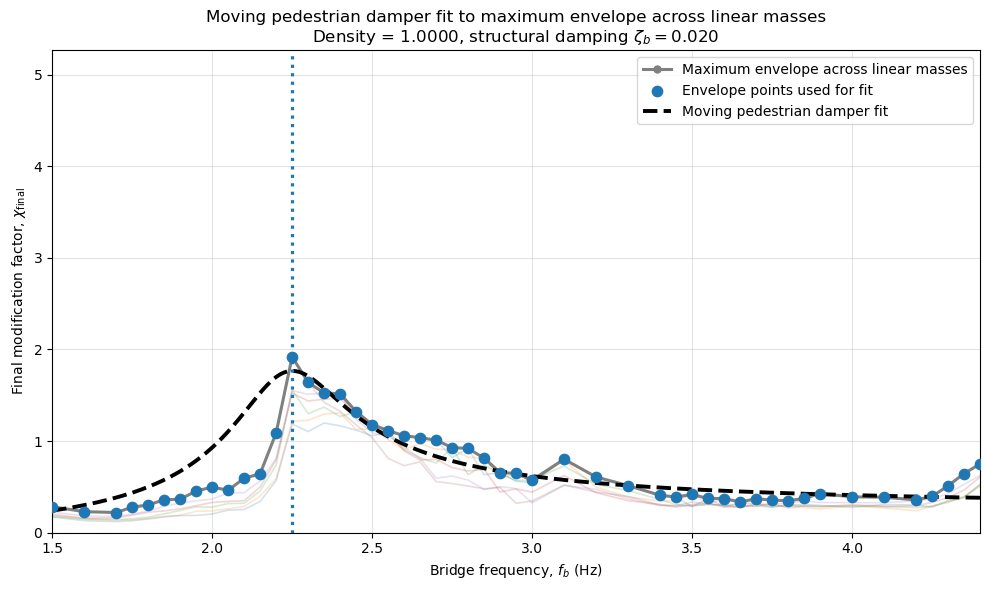


FINAL FITTED IDEAL MODIFICATION FACTOR EQUATION

Model form:
chi_ideal(f_b) = y0 + B * Q(beta_eff)
beta_eff       = beta_p * f_b / f_p
f_p            = 2.25 Hz

Fitted equation:
chi_ideal(f_b) = 0.001846 + 2.832499e-01 * Q(1.030338 * f_b / 2.250000)

Fitted parameters:
y0       = 0.00184578
B        = 2.83249887e-01
mu       = 0.24456404
alpha    = 0.52979911
zeta_b   = 0.02000000
zeta_a   = 0.30603216
beta_p   = 1.03033839
f_p      = 2.25000000 Hz


In [35]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import least_squares

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DENSITY = 1.0000
TARGET_DAMPING = 0.020

Y_COL = "final_modification_factor"

FIT_FMIN = 1.50
FIT_FMAX = 4.40

PLOT_FMIN = 1.50
PLOT_FMAX = 4.40

F_TARGET_PEAK = 2.25

zeta_b = TARGET_DAMPING

BETA_MIN = 0.20
BETA_MAX = 3.00
N_BETA_PEAK = 6000

eps = 1e-12


# ==================================================
# LOAD NEW lm FILES
# Expected names:
# density1.0000_damping0.005_lm500_bias_summary.pkl
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"lm(?P<linear_mass>\d+)_"
    r"bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_lm*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:

    match = pattern.match(file.name)

    if match is None:
        print("Skipping file because name does not match expected pattern:", file.name)
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_linear_mass = float(match.group("linear_mass"))

    # Keep only target density and damping
    if not np.isclose(file_density, TARGET_DENSITY):
        continue

    if not np.isclose(file_damping, TARGET_DAMPING):
        continue

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["linear_mass"] = file_linear_mass

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError(
        "No matching lm summary files found for "
        f"density={TARGET_DENSITY:.4f}, damping={TARGET_DAMPING:.3f}"
    )

corrected_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded combined dataframe shape:", corrected_df.shape)


# ==================================================
# CLEAN NUMERIC COLUMNS
# ==================================================

needed_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "linear_mass",
    Y_COL,
]

for col in needed_cols:
    corrected_df[col] = pd.to_numeric(corrected_df[col], errors="coerce")

corrected_df = corrected_df.dropna(subset=needed_cols).copy()

corrected_df["density_key"] = corrected_df["target_density"].round(4)
corrected_df["damping_key"] = corrected_df["target_beamdamp"].round(3)
corrected_df["linear_mass_key"] = corrected_df["linear_mass"].round(0).astype(int)

# Remove repeated rows if the pkl has multiple measures
sort_cols = ["linear_mass_key", "bridge_frequency"]

if "measure" in corrected_df.columns:
    corrected_df = corrected_df.sort_values(sort_cols)
    corrected_df = corrected_df.drop_duplicates(
        subset=["linear_mass_key", "bridge_frequency"],
        keep="first"
    ).copy()

corrected_df = corrected_df.sort_values(
    ["linear_mass_key", "bridge_frequency"]
).reset_index(drop=True)

print("\nFrequency coverage:")
coverage = (
    corrected_df
    .groupby("linear_mass_key")["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)
print(coverage)


# ==================================================
# MAXIMUM ENVELOPE ACROSS LINEAR MASSES
# ==================================================

env_df = (
    corrected_df
    .groupby("bridge_frequency", as_index=False)
    .agg(
        envelope_factor=(Y_COL, "max")
    )
    .sort_values("bridge_frequency")
)

fit_source_df = env_df.copy()

fit_df = fit_source_df[
    (fit_source_df["bridge_frequency"] >= FIT_FMIN) &
    (fit_source_df["bridge_frequency"] <= FIT_FMAX) &
    (fit_source_df["envelope_factor"] > 0)
].copy()

x_fit = fit_df["bridge_frequency"].to_numpy()
y_fit = fit_df["envelope_factor"].to_numpy()

if len(x_fit) < 8:
    raise ValueError("Too few envelope points in fitting range.")

print("\nNumber of fitting points:", len(x_fit))
print("Fitting frequency range:", x_fit.min(), "to", x_fit.max())


# ==================================================
# CLOSED-FORM MMD / TMD ACCELERATION SHAPE Q(beta)
# ==================================================

def Q_mmd(beta, mu, alpha, zeta_b, zeta_a):
    beta = np.asarray(beta, dtype=float)

    N_R = alpha**2 - beta**2
    N_I = 2.0 * zeta_a * alpha * beta

    D_R = (
        (1.0 - beta**2) * (alpha**2 - beta**2)
        - 4.0 * zeta_b * zeta_a * alpha * beta**2
        - mu * alpha**2 * beta**2
    )

    D_I = (
        2.0 * beta
        * (
            zeta_a * alpha * (1.0 - (1.0 + mu) * beta**2)
            + zeta_b * (alpha**2 - beta**2)
        )
    )

    numerator_abs = np.sqrt(N_R**2 + N_I**2)
    denominator_abs = np.sqrt(D_R**2 + D_I**2)

    return beta**2 * numerator_abs / (denominator_abs + 1e-14)


def beta_peak_for_parameters(mu, alpha, zeta_a, zeta_b):
    beta_grid = np.linspace(BETA_MIN, BETA_MAX, N_BETA_PEAK)

    Q_grid = Q_mmd(
        beta=beta_grid,
        mu=mu,
        alpha=alpha,
        zeta_b=zeta_b,
        zeta_a=zeta_a
    )

    return beta_grid[np.nanargmax(Q_grid)]


def chi_peak_locked_B_model(f_bridge, y0, B, mu, alpha, zeta_a):
    beta_p = beta_peak_for_parameters(
        mu=mu,
        alpha=alpha,
        zeta_a=zeta_a,
        zeta_b=zeta_b
    )

    beta_eff = beta_p * (f_bridge / F_TARGET_PEAK)

    Q_eff = Q_mmd(
        beta=beta_eff,
        mu=mu,
        alpha=alpha,
        zeta_b=zeta_b,
        zeta_a=zeta_a
    )

    return y0 + B * Q_eff


# ==================================================
# INITIAL GUESSES
# ==================================================

previous_fits = {
    0.005: {
        "y0": 0.12625630,
        "B":  1.57791445e-01,
        "mu": 0.18306454,
        "alpha": 0.51070586,
        "zeta_a": 0.39981395,
    },
    0.010: {
        "y0": 0.14782840,
        "B":  2.02927309e-01,
        "mu": 0.16074344,
        "alpha": 0.55129448,
        "zeta_a": 0.38537497,
    },
    0.020: {
        "y0": 0.19097260,
        "B":  2.93199037e-01,
        "mu": 0.11610124,
        "alpha": 0.63247172,
        "zeta_a": 0.35649701,
    },
}

if zeta_b in previous_fits:
    mu0 = previous_fits[zeta_b]["mu"]
    alpha0 = previous_fits[zeta_b]["alpha"]
    zeta_a0 = previous_fits[zeta_b]["zeta_a"]
else:
    damping_arr = np.array(sorted(previous_fits.keys()))
    mu_arr = np.array([previous_fits[d]["mu"] for d in damping_arr])
    alpha_arr = np.array([previous_fits[d]["alpha"] for d in damping_arr])
    zeta_a_arr = np.array([previous_fits[d]["zeta_a"] for d in damping_arr])

    mu0 = np.interp(zeta_b, damping_arr, mu_arr)
    alpha0 = np.interp(zeta_b, damping_arr, alpha_arr)
    zeta_a0 = np.interp(zeta_b, damping_arr, zeta_a_arr)

mu0 = np.clip(mu0, 0.001, 0.50)
alpha0 = np.clip(alpha0, 0.50, 1.50)
zeta_a0 = np.clip(zeta_a0, 0.30, 2.00)

beta_p0 = beta_peak_for_parameters(
    mu=mu0,
    alpha=alpha0,
    zeta_a=zeta_a0,
    zeta_b=zeta_b
)

beta_eff0 = beta_p0 * (x_fit / F_TARGET_PEAK)

Q0 = Q_mmd(
    beta=beta_eff0,
    mu=mu0,
    alpha=alpha0,
    zeta_b=zeta_b,
    zeta_a=zeta_a0
)

X0 = np.column_stack([np.ones_like(Q0), Q0])
y0_guess, B_guess = np.linalg.lstsq(X0, y_fit, rcond=None)[0]

y0_guess = max(y0_guess, 1e-8)
B_guess = max(B_guess, 1e-8)

p0 = np.array([
    y0_guess,
    B_guess,
    mu0,
    alpha0,
    zeta_a0
])

print("\nInitial guesses")
print("----------------")
print(f"y0       = {p0[0]:.6f}")
print(f"B        = {p0[1]:.6e}")
print(f"mu       = {p0[2]:.6f}")
print(f"alpha    = {p0[3]:.6f}")
print(f"zeta_a   = {p0[4]:.6f}")
print(f"beta_p0  = {beta_p0:.6f}")


# ==================================================
# BOUNDS
# ==================================================

ymax = np.nanmax(y_fit)

lower_bounds = np.array([
    0.0,      # y0
    0.0,      # B
    0.001,    # mu
    0.50,     # alpha
    0.30      # zeta_a
])

upper_bounds = np.array([
    5.0 * ymax,  # y0
    1e6,         # B
    0.50,        # mu
    1.50,        # alpha
    2.00         # zeta_a
])


# ==================================================
# FIT OBJECTIVE
# ==================================================

RIGHT_SHOULDER_WEIGHT = 2.00
POST_PEAK_SHOULDER_WEIGHT = 1.50
PEAK_WEIGHT_STRENGTH = 0.20

def residuals(p):
    y0, B, mu, alpha, zeta_a = p

    y_model = chi_peak_locked_B_model(
        f_bridge=x_fit,
        y0=y0,
        B=B,
        mu=mu,
        alpha=alpha,
        zeta_a=zeta_a
    )

    if np.any(y_model <= 0):
        return 1e6 * np.ones_like(y_fit)

    res = np.log(y_model + eps) - np.log(y_fit + eps)

    peak_weight = 1.0 + PEAK_WEIGHT_STRENGTH * np.exp(
        -0.5 * ((x_fit - F_TARGET_PEAK) / 0.25)**2
    )

    right_weight = np.where(
        x_fit > F_TARGET_PEAK,
        RIGHT_SHOULDER_WEIGHT,
        1.0
    )

    post_peak_weight = np.where(
        (x_fit >= 2.35) & (x_fit <= 3.00),
        POST_PEAK_SHOULDER_WEIGHT,
        1.0
    )

    return peak_weight * right_weight * post_peak_weight * res


# ==================================================
# RUN OPTIMIZATION
# ==================================================

result = least_squares(
    residuals,
    p0,
    bounds=(lower_bounds, upper_bounds),
    loss="soft_l1",
    f_scale=0.1,
    max_nfev=50000
)

y0_fit, B_fit, mu_fit, alpha_fit, zeta_a_fit = result.x

beta_p_fit = beta_peak_for_parameters(
    mu=mu_fit,
    alpha=alpha_fit,
    zeta_a=zeta_a_fit,
    zeta_b=zeta_b
)

Q_beta_p_fit = Q_mmd(
    beta=beta_p_fit,
    mu=mu_fit,
    alpha=alpha_fit,
    zeta_b=zeta_b,
    zeta_a=zeta_a_fit
)

A_equivalent = B_fit * Q_beta_p_fit

print("\nFitted parameters")
print("-----------------")
print(f"y0              = {y0_fit:.8f}")
print(f"B               = {B_fit:.8e}")
print(f"mu              = {mu_fit:.8f}")
print(f"alpha           = {alpha_fit:.8f}")
print(f"zeta_b          = {zeta_b:.8f} fixed")
print(f"zeta_a          = {zeta_a_fit:.8f}")
print(f"beta_p          = {beta_p_fit:.8f}")
print(f"Q(beta_p)       = {Q_beta_p_fit:.8f}")
print(f"A equivalent    = B * Q(beta_p) = {A_equivalent:.8f}")
print("Success:", result.success)
print("Message:", result.message)
print("Cost:", result.cost)


# ==================================================
# SMOOTH FITTED CURVE
# ==================================================

x_smooth = np.linspace(FIT_FMIN, FIT_FMAX, 1500)

y_smooth = chi_peak_locked_B_model(
    f_bridge=x_smooth,
    y0=y0_fit,
    B=B_fit,
    mu=mu_fit,
    alpha=alpha_fit,
    zeta_a=zeta_a_fit
)

peak_idx = np.nanargmax(y_smooth)

print("\nFitted curve check")
print("------------------")
print(f"Checked peak frequency = {x_smooth[peak_idx]:.6f} Hz")
print(f"Checked peak value     = {y_smooth[peak_idx]:.6f}")


# ==================================================
# PLOT LIKE YOUR FIGURE
# Original lm curves + maximum envelope + fitted curve
# ==================================================

plt.figure(figsize=(10, 6))

# Original linear-mass curves
for lm in sorted(corrected_df["linear_mass_key"].dropna().unique()):

    sub = corrected_df[
        corrected_df["linear_mass_key"] == lm
    ].copy()

    sub = sub.sort_values("bridge_frequency")

    plt.plot(
        sub["bridge_frequency"],
        sub[Y_COL],
        linewidth=1.2,
        alpha=0.20,
        label=None
    )

# Maximum envelope across linear masses
plt.plot(
    env_df["bridge_frequency"],
    env_df["envelope_factor"],
    "o-",
    linewidth=2.2,
    markersize=5,
    color="gray",
    label="Maximum envelope across linear masses"
)

# Points used for fit
plt.scatter(
    x_fit,
    y_fit,
    s=55,
    zorder=5,
    color="tab:blue",
    label="Envelope points used for fit"
)

# Fitted curve
plt.plot(
    x_smooth,
    y_smooth,
    "k--",
    linewidth=2.8,
    label="Moving pedestrian damper fit"
)

# Locked peak line
plt.axvline(
    F_TARGET_PEAK,
    linestyle=":",
    linewidth=2.3,
    color="tab:blue"
)

plt.xlabel(r"Bridge frequency, $f_b$ (Hz)")
plt.ylabel(r"Final modification factor, $\chi_{\mathrm{final}}$")

plt.title(
    "Moving pedestrian damper fit to maximum envelope across linear masses\n"
    rf"Density = {TARGET_DENSITY:.4f}, structural damping $\zeta_b={zeta_b:.3f}$"
)

plt.xlim(PLOT_FMIN, PLOT_FMAX)

ymax_plot = max(
    np.nanmax(env_df["envelope_factor"]),
    np.nanmax(y_smooth),
    np.nanmax(corrected_df[Y_COL])
)

plt.ylim(0, 1.15 * ymax_plot)

plt.grid(True, alpha=0.35)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


# ==================================================
# PRINT FINAL EQUATION
# ==================================================

print("\n" + "="*80)
print("FINAL FITTED IDEAL MODIFICATION FACTOR EQUATION")
print("="*80)

print("\nModel form:")
print("chi_ideal(f_b) = y0 + B * Q(beta_eff)")
print("beta_eff       = beta_p * f_b / f_p")
print("f_p            = 2.25 Hz")

print("\nFitted equation:")
print(
    f"chi_ideal(f_b) = {y0_fit:.6f} "
    f"+ {B_fit:.6e} * Q({beta_p_fit:.6f} * f_b / {F_TARGET_PEAK:.6f})"
)

print("\nFitted parameters:")
print(f"y0       = {y0_fit:.8f}")
print(f"B        = {B_fit:.8e}")
print(f"mu       = {mu_fit:.8f}")
print(f"alpha    = {alpha_fit:.8f}")
print(f"zeta_b   = {zeta_b:.8f}")
print(f"zeta_a   = {zeta_a_fit:.8f}")
print(f"beta_p   = {beta_p_fit:.8f}")
print(f"f_p      = {F_TARGET_PEAK:.8f} Hz")

print("="*80)

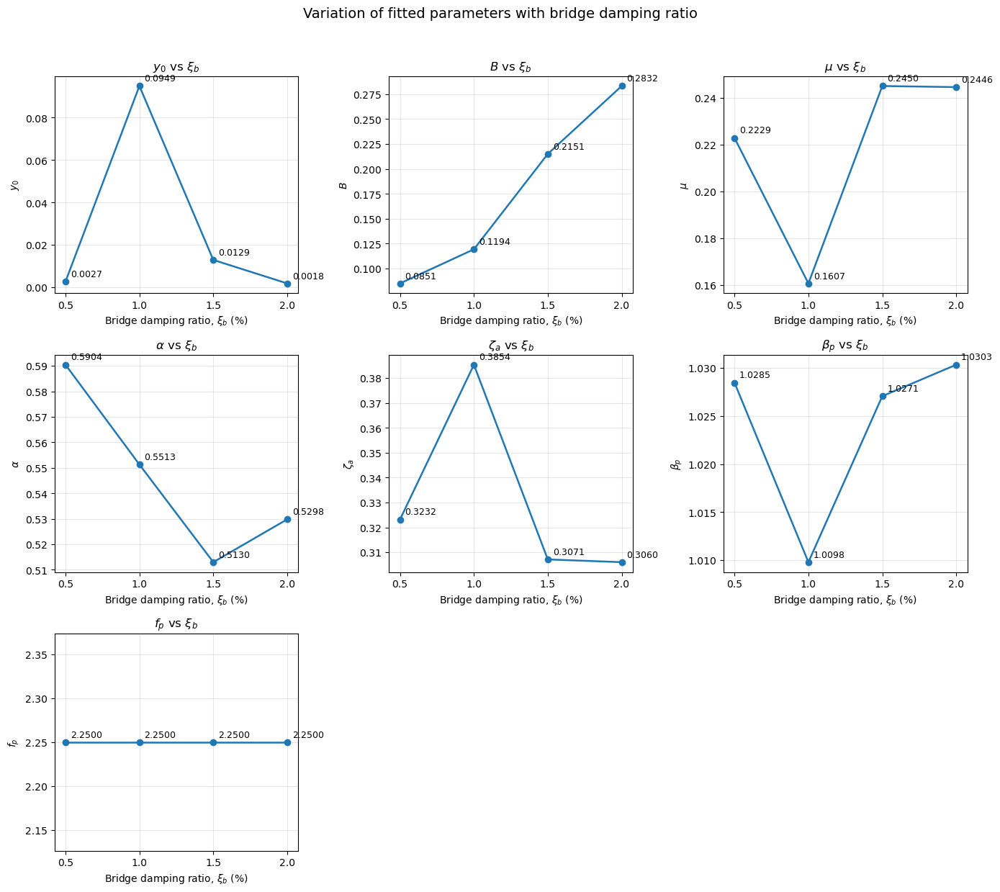

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# FITTED PARAMETERS VS BRIDGE DAMPING xi_b
# ==========================================

df_params = pd.DataFrame({
    "xi_b":    [0.005, 0.010, 0.015, 0.020],

    # Fitted parameters from your four equations
    "y0":      [0.00269915, 0.09487318, 0.01292234, 0.00184578],
    "B":       [8.51265033e-02, 1.19353288e-01, 2.15056173e-01, 2.83249887e-01],
    "mu":      [0.22286233, 0.16073981, 0.24504529, 0.24456404],
    "alpha":   [0.59041978, 0.55129458, 0.51300792, 0.52979911],
    "zeta_a":  [0.32317373, 0.38537211, 0.30712497, 0.30603216],
    "beta_p":  [1.02847141, 1.00980163, 1.02707118, 1.03033839],
    "f_p":     [2.25, 2.25, 2.25, 2.25],
})

# Display damping as percentage: 0.005 -> 0.5%, 0.010 -> 1.0%
df_params["xi_b_percent"] = df_params["xi_b"] * 100.0

# Labels
symbol_labels = {
    "y0": r"$y_0$",
    "B": r"$B$",
    "mu": r"$\mu$",
    "alpha": r"$\alpha$",
    "zeta_a": r"$\zeta_a$",
    "beta_p": r"$\beta_p$",
    "f_p": r"$f_p$",
    "xi_b": r"$\xi_b$",
}

params_to_plot = [
    "y0",
    "B",
    "mu",
    "alpha",
    "zeta_a",
    "beta_p",
    "f_p",
]

n = len(params_to_plot)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(14, 4.2 * nrows)
)

axes = np.asarray(axes).reshape(-1)

for ax, param in zip(axes, params_to_plot):

    ax.plot(
        df_params["xi_b_percent"],
        df_params[param],
        marker="o",
        linewidth=1.8,
        markersize=6
    )

    for x, y in zip(df_params["xi_b_percent"], df_params[param]):
        ax.annotate(
            f"{y:.4f}",
            (x, y),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

    ax.set_title(f"{symbol_labels[param]} vs {symbol_labels['xi_b']}")
    ax.set_xlabel(r"Bridge damping ratio, $\xi_b$ (%)")
    ax.set_ylabel(symbol_labels[param])

    ax.set_xticks(df_params["xi_b_percent"])
    ax.set_xticklabels([f"{x:.1f}" for x in df_params["xi_b_percent"]])

    ax.grid(True, alpha=0.3)

# Remove unused axes
for j in range(len(params_to_plot), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Variation of fitted parameters with bridge damping ratio",
    fontsize=14
)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


REGULARIZED PARAMETER TABLE
parameter   xi_b         B     alpha    beta_p   f_p        mu        y0  \
0          0.005  0.072186  0.579153  1.020490  2.25  0.195891  0.040762   
1          0.010  0.141193  0.557138  1.022777  2.25  0.210832  0.032311   
2          0.015  0.210200  0.535123  1.025064  2.25  0.225773  0.023860   
3          0.020  0.279207  0.513108  1.027351  2.25  0.240714  0.015408   

parameter    zeta_a  xi_b_percent  
0          0.349877           0.5  
1          0.336909           1.0  
2          0.323942           1.5  
3          0.310975           2.0  


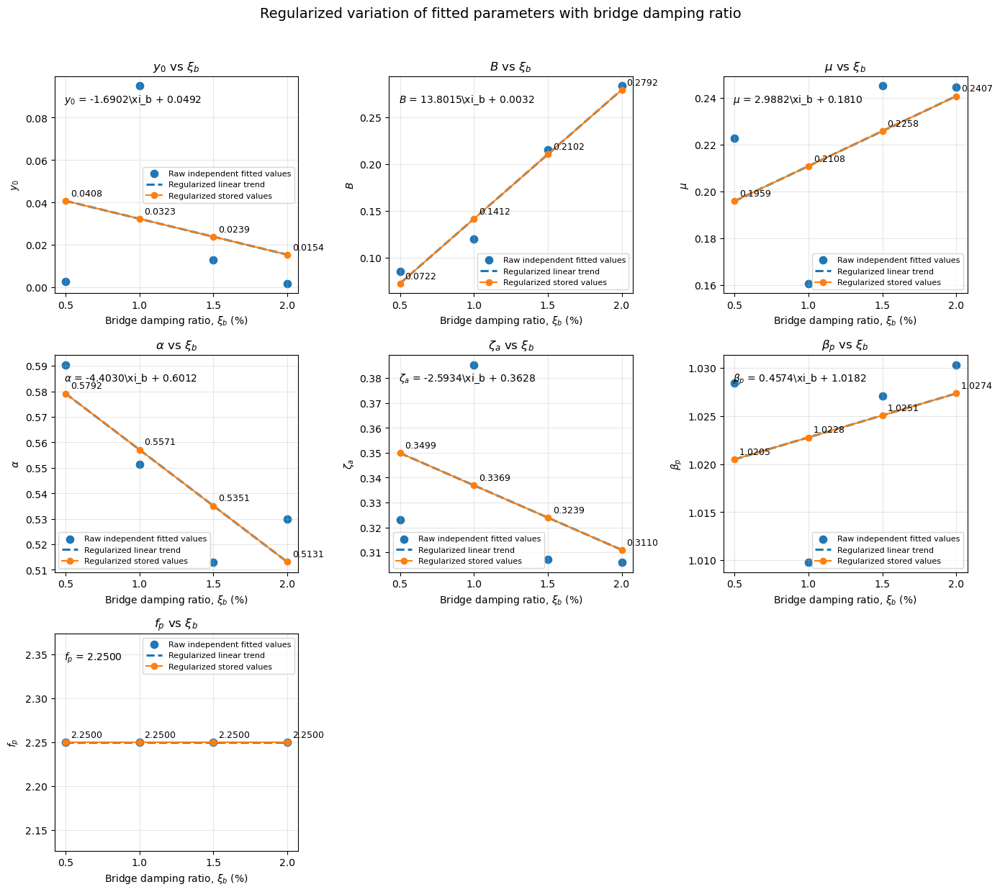

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# RAW FITTED PARAMETERS FROM YOUR 4 DAMPING RATIOS
# ==================================================

df_raw = pd.DataFrame({
    "xi_b":    [0.005, 0.010, 0.015, 0.020],

    "y0":      [0.00269915, 0.09487318, 0.01292234, 0.00184578],
    "B":       [8.51265033e-02, 1.19353288e-01, 2.15056173e-01, 2.83249887e-01],
    "mu":      [0.22286233, 0.16073981, 0.24504529, 0.24456404],
    "alpha":   [0.59041978, 0.55129458, 0.51300792, 0.52979911],
    "zeta_a":  [0.32317373, 0.38537211, 0.30712497, 0.30603216],
    "beta_p":  [1.02847141, 1.00980163, 1.02707118, 1.03033839],
    "f_p":     [2.25, 2.25, 2.25, 2.25],
})

df_raw["xi_b_percent"] = 100.0 * df_raw["xi_b"]

# ==================================================
# PARAMETERS TO REGULARIZE
# ==================================================

params_to_plot = ["y0", "B", "mu", "alpha", "zeta_a", "beta_p", "f_p"]

symbol_labels = {
    "y0": r"$y_0$",
    "B": r"$B$",
    "mu": r"$\mu$",
    "alpha": r"$\alpha$",
    "zeta_a": r"$\zeta_a$",
    "beta_p": r"$\beta_p$",
    "f_p": r"$f_p$",
    "xi_b": r"$\xi_b$",
}

# ==================================================
# REGULARIZATION CHOICE
# ==================================================
# B is clearly almost linear.
# For the others, the raw values are unstable.
# Therefore:
#   - B: linear fit to raw values
#   - f_p: fixed at 2.25
#   - others: linear fit, but treat them as smoothed/regularized values

regularized_rows = []

xi = df_raw["xi_b"].to_numpy()
xi_plot = np.linspace(xi.min(), xi.max(), 200)
xi_plot_percent = 100.0 * xi_plot

fit_equations = {}

for param in params_to_plot:

    y = df_raw[param].to_numpy()

    if param == "f_p":
        m = 0.0
        c = 2.25
        y_reg = np.full_like(xi, 2.25)
        y_plot = np.full_like(xi_plot, 2.25)

    else:
        m, c = np.polyfit(xi, y, 1)
        y_reg = m * xi + c
        y_plot = m * xi_plot + c

        # Optional physical clipping
        if param == "y0":
            y_reg = np.maximum(y_reg, 0.0)
            y_plot = np.maximum(y_plot, 0.0)

        if param == "B":
            y_reg = np.maximum(y_reg, 0.0)
            y_plot = np.maximum(y_plot, 0.0)

        if param == "mu":
            y_reg = np.clip(y_reg, 0.001, 0.50)
            y_plot = np.clip(y_plot, 0.001, 0.50)

        if param == "alpha":
            y_reg = np.clip(y_reg, 0.50, 1.50)
            y_plot = np.clip(y_plot, 0.50, 1.50)

        if param == "zeta_a":
            y_reg = np.clip(y_reg, 0.30, 2.00)
            y_plot = np.clip(y_plot, 0.30, 2.00)

    fit_equations[param] = (m, c, xi_plot, y_plot)

    for xb, val in zip(xi, y_reg):
        regularized_rows.append({
            "xi_b": xb,
            "parameter": param,
            "regularized_value": val,
        })

df_reg_long = pd.DataFrame(regularized_rows)

df_reg = (
    df_reg_long
    .pivot(index="xi_b", columns="parameter", values="regularized_value")
    .reset_index()
)

df_reg["xi_b_percent"] = 100.0 * df_reg["xi_b"]

print("\nREGULARIZED PARAMETER TABLE")
print(df_reg)

# ==================================================
# PLOT RAW VALUES + REGULARIZED LINE
# ==================================================

n = len(params_to_plot)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.2 * nrows))
axes = np.asarray(axes).reshape(-1)

for ax, param in zip(axes, params_to_plot):

    m, c, xi_plot, y_plot = fit_equations[param]

    # Raw fitted values
    ax.scatter(
        df_raw["xi_b_percent"],
        df_raw[param],
        s=55,
        label="Raw independent fitted values"
    )

    # Regularized trend
    ax.plot(
        100.0 * xi_plot,
        y_plot,
        linestyle="--",
        linewidth=2.2,
        label="Regularized linear trend"
    )

    # Regularized values at actual damping ratios
    y_reg_actual = df_reg[param].to_numpy()

    ax.plot(
        df_reg["xi_b_percent"],
        y_reg_actual,
        marker="o",
        linewidth=1.5,
        label="Regularized stored values"
    )

    for xval, yval in zip(df_reg["xi_b_percent"], y_reg_actual):
        ax.annotate(
            f"{yval:.4f}",
            (xval, yval),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

    if param == "f_p":
        equation_text = rf"{symbol_labels[param]} = {c:.4f}"
    else:
        equation_text = rf"{symbol_labels[param]} = {m:.4f}\xi_b + {c:.4f}"

    ax.text(
        0.04,
        0.92,
        equation_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top"
    )

    ax.set_title(f"{symbol_labels[param]} vs {symbol_labels['xi_b']}")
    ax.set_xlabel(r"Bridge damping ratio, $\xi_b$ (%)")
    ax.set_ylabel(symbol_labels[param])
    ax.grid(True, alpha=0.3)

    ax.set_xticks(df_raw["xi_b_percent"])
    ax.set_xticklabels([f"{x:.1f}" for x in df_raw["xi_b_percent"]])

    ax.legend(fontsize=8)

for j in range(len(params_to_plot), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Regularized variation of fitted parameters with bridge damping ratio",
    fontsize=14
)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Loading: density1.0000_damping0.005_lm1000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm1500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm2000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm750_bias_summary.pkl
Loading: density1.0000_damping0.010_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.010_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.010_lm483_bias_summary.pkl
Loading: density1.0000_damping0.010_lm580_bias_summary.pkl
Loading: density1.0000_damping0.010_lm725_bias_summary.pkl
Loading: density1.0000_damping0.010_lm967_bias_summary.pkl
Loading: density1.0000_damping0.015_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.015_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.015_lm483_bias_summary.pkl
Loading: density1.0000_damping0.015_lm580_bias_summary.pkl
Loading: density1.0000_damping0.015_lm725_bias_summary.pkl
Loading: density1.0000_damping0.015_lm967_bias_su

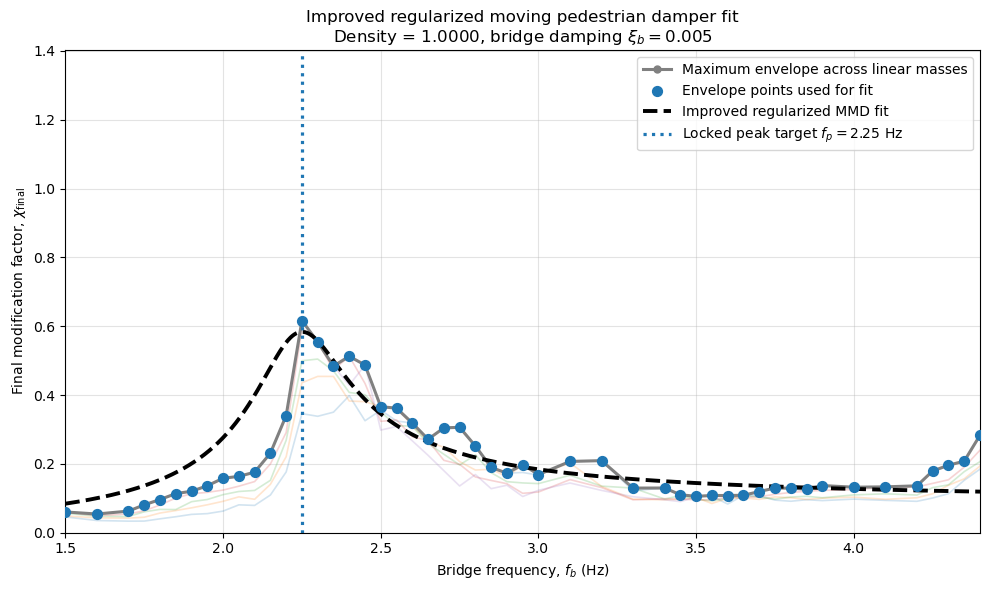


FITTING DAMPING = 0.010

Regularized starting guess
--------------------------
y0      = 0.03231066
B       = 1.41192811e-01
mu      = 0.21083234
alpha   = 0.55713778
zeta_a  = 0.33690933

Improved fitted parameters
--------------------------
y0              = 0.02115758
B               = 1.51624622e-01
mu              = 0.21780991
alpha           = 0.57088853
zeta_b          = 0.01000000 fixed
zeta_a          = 0.32334260
beta_p          = 1.02660443
Q(beta_p)       = 6.66240704
A equivalent    = 1.01018495
Checked peak f  = 2.250634 Hz
Checked peak y  = 1.031347
Success: True
Cost: 1.6164258208144509


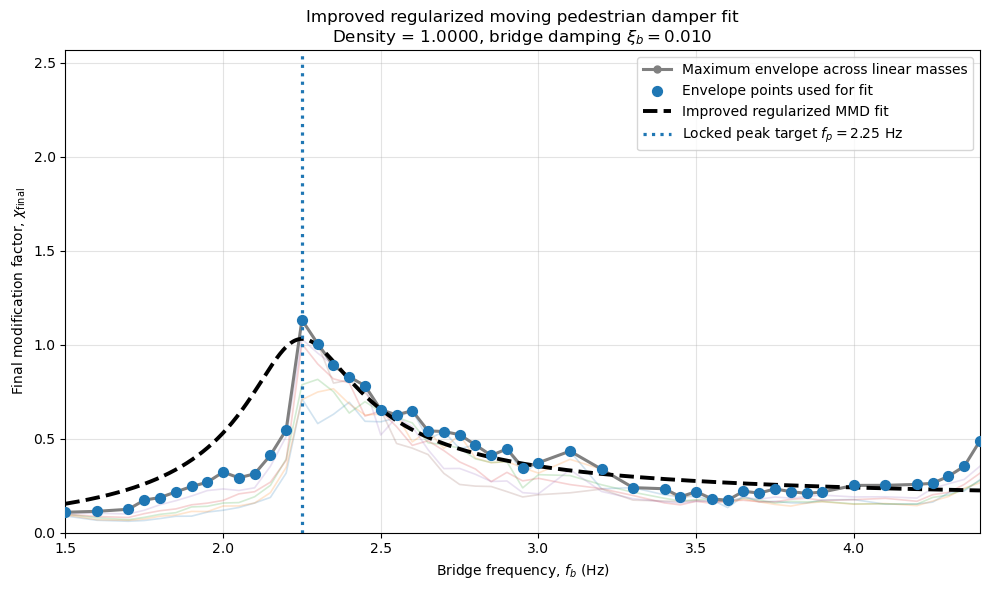


FITTING DAMPING = 0.015

Regularized starting guess
--------------------------
y0      = 0.02385956
B       = 2.10200115e-01
mu      = 0.22577340
alpha   = 0.53512291
zeta_a  = 0.32394215

Improved fitted parameters
--------------------------
y0              = 0.02355884
B               = 2.09756101e-01
mu              = 0.22629117
alpha           = 0.53572502
zeta_b          = 0.01500000 fixed
zeta_a          = 0.32353721
beta_p          = 1.02520420
Q(beta_p)       = 6.68862958
A equivalent    = 1.40298086
Checked peak f  = 2.250634 Hz
Checked peak y  = 1.426546
Success: True
Cost: 1.5614395873504827


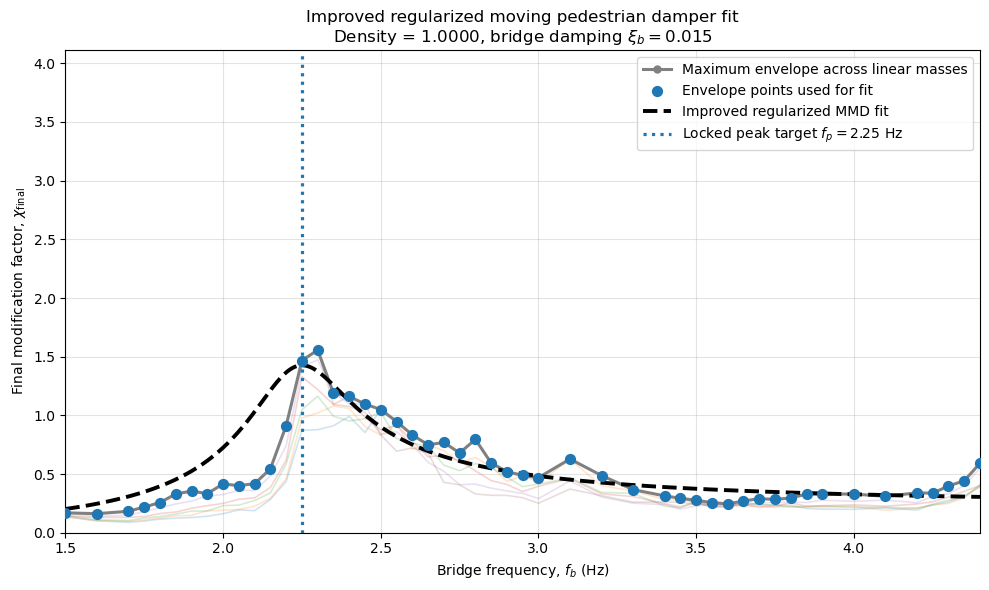


FITTING DAMPING = 0.020

Regularized starting guess
--------------------------
y0      = 0.01540847
B       = 2.79207418e-01
mu      = 0.24071446
alpha   = 0.51310805
zeta_a  = 0.31097496

Improved fitted parameters
--------------------------
y0              = 0.01316404
B               = 2.73979247e-01
mu              = 0.24591804
alpha           = 0.53376217
zeta_b          = 0.02000000 fixed
zeta_a          = 0.30049139
beta_p          = 1.03173862
Q(beta_p)       = 6.20874387
A equivalent    = 1.70106697
Checked peak f  = 2.250634 Hz
Checked peak y  = 1.714237
Success: True
Cost: 1.536677183765889


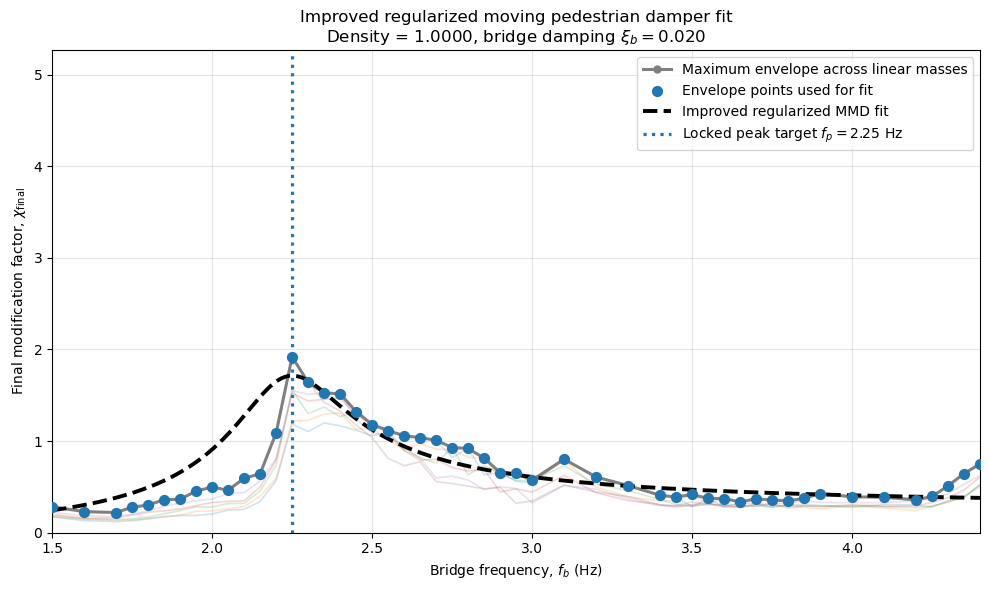


FINAL IMPROVED PARAMETER TABLE
    xi_b        y0         B        mu     alpha    zeta_a    beta_p   f_p  \
0  0.005  0.019423  0.074200  0.199229  0.574711  0.323945  1.022870  2.25   
1  0.010  0.021158  0.151625  0.217810  0.570889  0.323343  1.026604  2.25   
2  0.015  0.023559  0.209756  0.226291  0.535725  0.323537  1.025204  2.25   
3  0.020  0.013164  0.273979  0.245918  0.533762  0.300491  1.031739  2.25   

   Q_beta_p  A_equivalent  success      cost  peak_frequency_checked  \
0  7.602707      0.564121     True  1.792799                2.250634   
1  6.662407      1.010185     True  1.616426                2.250634   
2  6.688630      1.402981     True  1.561440                2.250634   
3  6.208744      1.701067     True  1.536677                2.250634   

   peak_value_checked  
0            0.583547  
1            1.031347  
2            1.426546  
3            1.714237  

Saved improved fit results.


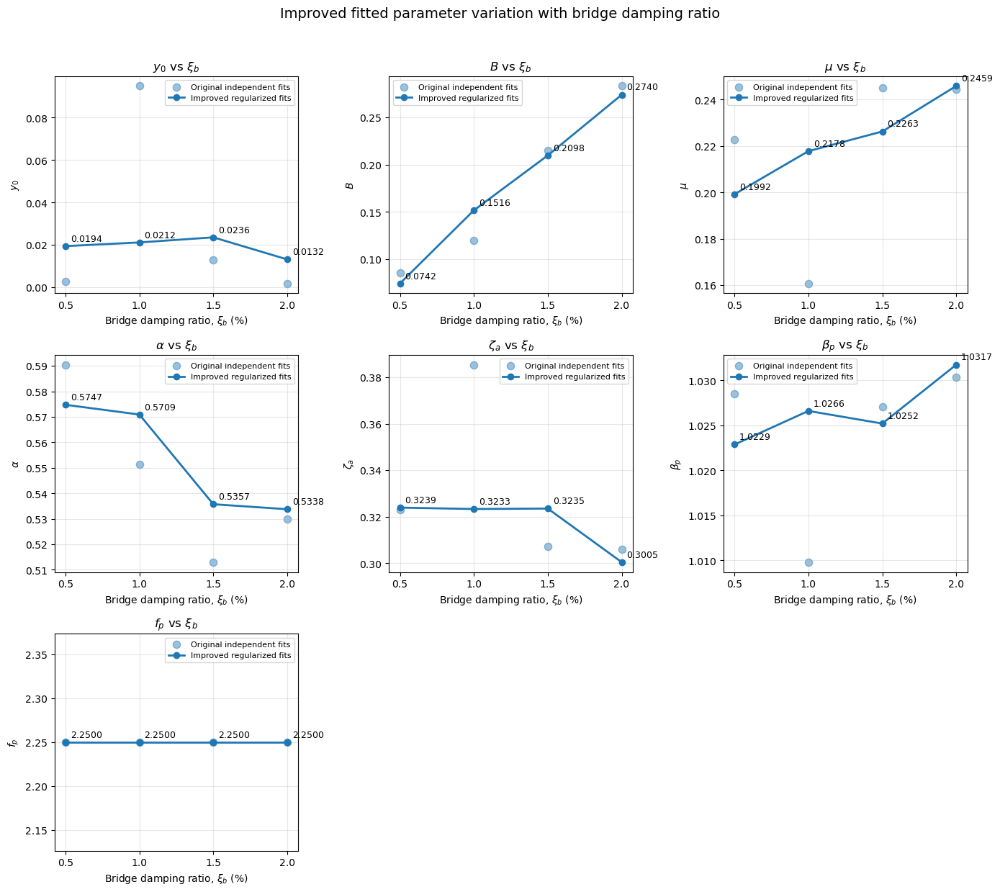


FINAL IMPROVED FITTED IDEAL MODIFICATION FACTOR EQUATIONS

--------------------------------------------------------------------------------
Bridge damping xi_b = 0.005
--------------------------------------------------------------------------------
Model form:
chi_ideal(f_b) = y0 + B * Q(beta_eff)
beta_eff       = beta_p * f_b / f_p
f_p            = 2.25 Hz

Fitted equation:
chi_ideal(f_b) = 0.019423 + 7.420004e-02 * Q(1.022870 * f_b / 2.250000)

Fitted parameters:
y0       = 0.01942254
B        = 7.42000444e-02
mu       = 0.19922925
alpha    = 0.57471147
zeta_b   = 0.00500000
zeta_a   = 0.32394505
beta_p   = 1.02287048
f_p      = 2.25000000 Hz

--------------------------------------------------------------------------------
Bridge damping xi_b = 0.010
--------------------------------------------------------------------------------
Model form:
chi_ideal(f_b) = y0 + B * Q(beta_eff)
beta_eff       = beta_p * f_b / f_p
f_p            = 2.25 Hz

Fitted equation:
chi_ideal(f_b) = 0.021158 

In [17]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import least_squares

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DENSITY = 1.0000

TARGET_DAMPINGS = [0.005, 0.010, 0.015, 0.020]

Y_COL = "final_modification_factor"

FIT_FMIN = 1.50
FIT_FMAX = 4.40

PLOT_FMIN = 1.50
PLOT_FMAX = 4.40

F_TARGET_PEAK = 2.25

BETA_MIN = 0.20
BETA_MAX = 3.00
N_BETA_PEAK = 6000

eps = 1e-12

SAVE_RESULTS = True


# ==================================================
# RAW PARAMETER VALUES FROM YOUR FIRST FITS
# These are used only to build smooth regularized guesses
# ==================================================

df_raw_params = pd.DataFrame({
    "xi_b":    [0.005, 0.010, 0.015, 0.020],

    "y0":      [0.00269915, 0.09487318, 0.01292234, 0.00184578],
    "B":       [8.51265033e-02, 1.19353288e-01, 2.15056173e-01, 2.83249887e-01],
    "mu":      [0.22286233, 0.16073981, 0.24504529, 0.24456404],
    "alpha":   [0.59041978, 0.55129458, 0.51300792, 0.52979911],
    "zeta_a":  [0.32317373, 0.38537211, 0.30712497, 0.30603216],
    "beta_p":  [1.02847141, 1.00980163, 1.02707118, 1.03033839],
    "f_p":     [2.25, 2.25, 2.25, 2.25],
})


# ==================================================
# BUILD SMOOTH / REGULARIZED PARAMETER TRENDS
# ==================================================

def make_linear_trend(df, param):
    xi = df["xi_b"].to_numpy()
    y = df[param].to_numpy()

    if param == "f_p":
        return 0.0, 2.25

    m, c = np.polyfit(xi, y, 1)
    return m, c


trend = {}

for param in ["y0", "B", "mu", "alpha", "zeta_a", "beta_p", "f_p"]:
    trend[param] = make_linear_trend(df_raw_params, param)


def get_regularized_guess(xi_b):
    guess = {}

    for param, (m, c) in trend.items():
        guess[param] = m * xi_b + c

    # Physical clipping
    guess["y0"] = max(guess["y0"], 1e-8)
    guess["B"] = max(guess["B"], 1e-8)
    guess["mu"] = np.clip(guess["mu"], 0.001, 0.50)
    guess["alpha"] = np.clip(guess["alpha"], 0.50, 1.50)
    guess["zeta_a"] = np.clip(guess["zeta_a"], 0.30, 2.00)
    guess["f_p"] = 2.25

    return guess


# ==================================================
# FILE LOADING
# Expected:
# density1.0000_damping0.005_lm500_bias_summary.pkl
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"lm(?P<linear_mass>\d+)_"
    r"bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_lm*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:

    match = pattern.match(file.name)

    if match is None:
        print("Skipping unmatched file:", file.name)
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_linear_mass = float(match.group("linear_mass"))

    if not np.isclose(file_density, TARGET_DENSITY):
        continue

    if not any(np.isclose(file_damping, d) for d in TARGET_DAMPINGS):
        continue

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["linear_mass"] = file_linear_mass

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching lm summary files found.")

full_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded dataframe shape:", full_df.shape)


# ==================================================
# CLEAN DATA
# ==================================================

needed_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "linear_mass",
    Y_COL,
]

for col in needed_cols:
    if col not in full_df.columns:
        raise KeyError(f"Missing required column: {col}")

    full_df[col] = pd.to_numeric(full_df[col], errors="coerce")

full_df = full_df.dropna(subset=needed_cols).copy()

full_df["density_key"] = full_df["target_density"].round(4)
full_df["damping_key"] = full_df["target_beamdamp"].round(3)
full_df["linear_mass_key"] = full_df["linear_mass"].round(0).astype(int)

# Remove repeated rows if PKL contains multiple measures
if "measure" in full_df.columns:
    full_df = full_df.sort_values(
        ["damping_key", "linear_mass_key", "bridge_frequency"]
    )

    full_df = full_df.drop_duplicates(
        subset=["damping_key", "linear_mass_key", "bridge_frequency"],
        keep="first"
    ).copy()

full_df = full_df.sort_values(
    ["damping_key", "linear_mass_key", "bridge_frequency"]
).reset_index(drop=True)


print("\nFrequency coverage:")
coverage = (
    full_df
    .groupby(["damping_key", "linear_mass_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)
print(coverage)


# ==================================================
# CLOSED-FORM MMD / TMD ACCELERATION SHAPE Q(beta)
# ==================================================

def Q_mmd(beta, mu, alpha, zeta_b, zeta_a):
    beta = np.asarray(beta, dtype=float)

    N_R = alpha**2 - beta**2
    N_I = 2.0 * zeta_a * alpha * beta

    D_R = (
        (1.0 - beta**2) * (alpha**2 - beta**2)
        - 4.0 * zeta_b * zeta_a * alpha * beta**2
        - mu * alpha**2 * beta**2
    )

    D_I = (
        2.0 * beta
        * (
            zeta_a * alpha * (1.0 - (1.0 + mu) * beta**2)
            + zeta_b * (alpha**2 - beta**2)
        )
    )

    numerator_abs = np.sqrt(N_R**2 + N_I**2)
    denominator_abs = np.sqrt(D_R**2 + D_I**2)

    return beta**2 * numerator_abs / (denominator_abs + 1e-14)


def beta_peak_for_parameters(mu, alpha, zeta_a, zeta_b):
    beta_grid = np.linspace(BETA_MIN, BETA_MAX, N_BETA_PEAK)

    Q_grid = Q_mmd(
        beta=beta_grid,
        mu=mu,
        alpha=alpha,
        zeta_b=zeta_b,
        zeta_a=zeta_a
    )

    return beta_grid[np.nanargmax(Q_grid)]


def chi_peak_locked_B_model(f_bridge, y0, B, mu, alpha, zeta_a, zeta_b):
    beta_p = beta_peak_for_parameters(
        mu=mu,
        alpha=alpha,
        zeta_a=zeta_a,
        zeta_b=zeta_b
    )

    beta_eff = beta_p * (f_bridge / F_TARGET_PEAK)

    Q_eff = Q_mmd(
        beta=beta_eff,
        mu=mu,
        alpha=alpha,
        zeta_b=zeta_b,
        zeta_a=zeta_a
    )

    return y0 + B * Q_eff


# ==================================================
# IMPROVED FIT FOR ONE DAMPING
# ==================================================

def fit_one_damping(df_all, target_damping):

    zeta_b = target_damping

    damping_df = df_all[
        np.isclose(df_all["target_beamdamp"], target_damping)
    ].copy()

    if damping_df.empty:
        print(f"\nNo data for damping {target_damping:.3f}")
        return None

    # --------------------------------------------------
    # Maximum envelope across linear masses
    # --------------------------------------------------

    env_df = (
        damping_df
        .groupby("bridge_frequency", as_index=False)
        .agg(envelope_factor=(Y_COL, "max"))
        .sort_values("bridge_frequency")
    )

    fit_df = env_df[
        (env_df["bridge_frequency"] >= FIT_FMIN) &
        (env_df["bridge_frequency"] <= FIT_FMAX) &
        (env_df["envelope_factor"] > 0)
    ].copy()

    x_fit = fit_df["bridge_frequency"].to_numpy()
    y_fit = fit_df["envelope_factor"].to_numpy()

    if len(x_fit) < 8:
        raise ValueError(
            f"Too few fitting points for damping {target_damping:.3f}"
        )

    # --------------------------------------------------
    # Regularized initial guess
    # --------------------------------------------------

    guess = get_regularized_guess(zeta_b)

    p0 = np.array([
        guess["y0"],
        guess["B"],
        guess["mu"],
        guess["alpha"],
        guess["zeta_a"],
    ], dtype=float)

    print("\n" + "="*80)
    print(f"FITTING DAMPING = {zeta_b:.3f}")
    print("="*80)

    print("\nRegularized starting guess")
    print("--------------------------")
    print(f"y0      = {p0[0]:.8f}")
    print(f"B       = {p0[1]:.8e}")
    print(f"mu      = {p0[2]:.8f}")
    print(f"alpha   = {p0[3]:.8f}")
    print(f"zeta_a  = {p0[4]:.8f}")

    # --------------------------------------------------
    # Bounds around regularized guess
    # --------------------------------------------------

    y0_0, B_0, mu0, alpha0, zeta_a0 = p0

    lower_bounds = np.array([
        max(0.0, 0.20 * y0_0),
        max(0.0, 0.35 * B_0),
        max(0.001, mu0 - 0.07),
        max(0.50, alpha0 - 0.15),
        max(0.30, zeta_a0 - 0.10),
    ])

    upper_bounds = np.array([
        max(1e-6, 3.00 * y0_0 + 0.05),
        max(1e-6, 2.50 * B_0),
        min(0.50, mu0 + 0.07),
        min(1.50, alpha0 + 0.15),
        min(2.00, zeta_a0 + 0.10),
    ])

    p0 = np.minimum(np.maximum(p0, lower_bounds + 1e-10), upper_bounds - 1e-10)

    # --------------------------------------------------
    # Regularization strength
    # --------------------------------------------------
    # Increase these if parameters still jump too much.
    # Decrease them if the fitted curve is too stiff.

    REG_STRENGTH = {
        "y0": 0.40,
        "B": 0.25,
        "mu": 0.80,
        "alpha": 0.70,
        "zeta_a": 0.70,
    }

    PARAM_SCALE = np.array([
        max(abs(y0_0), 0.02),
        max(abs(B_0), 0.05),
        0.05,
        0.10,
        0.08,
    ])

    REG_VECTOR = np.array([
        REG_STRENGTH["y0"],
        REG_STRENGTH["B"],
        REG_STRENGTH["mu"],
        REG_STRENGTH["alpha"],
        REG_STRENGTH["zeta_a"],
    ])

    # --------------------------------------------------
    # Objective function
    # --------------------------------------------------

    RIGHT_SHOULDER_WEIGHT = 1.80
    POST_PEAK_SHOULDER_WEIGHT = 1.30
    PEAK_WEIGHT_STRENGTH = 0.25

    def residuals(p):
        y0, B, mu, alpha, zeta_a = p

        y_model = chi_peak_locked_B_model(
            f_bridge=x_fit,
            y0=y0,
            B=B,
            mu=mu,
            alpha=alpha,
            zeta_a=zeta_a,
            zeta_b=zeta_b
        )

        if np.any(~np.isfinite(y_model)) or np.any(y_model <= 0):
            return 1e6 * np.ones(len(y_fit) + len(p))

        data_res = np.log(y_model + eps) - np.log(y_fit + eps)

        peak_weight = 1.0 + PEAK_WEIGHT_STRENGTH * np.exp(
            -0.5 * ((x_fit - F_TARGET_PEAK) / 0.25)**2
        )

        right_weight = np.where(
            x_fit > F_TARGET_PEAK,
            RIGHT_SHOULDER_WEIGHT,
            1.0
        )

        post_peak_weight = np.where(
            (x_fit >= 2.35) & (x_fit <= 3.00),
            POST_PEAK_SHOULDER_WEIGHT,
            1.0
        )

        weighted_data_res = peak_weight * right_weight * post_peak_weight * data_res

        # Soft pull towards smooth trend
        reg_res = REG_VECTOR * ((p - p0) / PARAM_SCALE)

        return np.r_[weighted_data_res, reg_res]

    # --------------------------------------------------
    # Optimization
    # --------------------------------------------------

    result = least_squares(
        residuals,
        p0,
        bounds=(lower_bounds, upper_bounds),
        loss="soft_l1",
        f_scale=0.10,
        max_nfev=80000
    )

    y0_fit, B_fit, mu_fit, alpha_fit, zeta_a_fit = result.x

    beta_p_fit = beta_peak_for_parameters(
        mu=mu_fit,
        alpha=alpha_fit,
        zeta_a=zeta_a_fit,
        zeta_b=zeta_b
    )

    Q_beta_p_fit = Q_mmd(
        beta=beta_p_fit,
        mu=mu_fit,
        alpha=alpha_fit,
        zeta_b=zeta_b,
        zeta_a=zeta_a_fit
    )

    A_equivalent = B_fit * Q_beta_p_fit

    # --------------------------------------------------
    # Smooth fitted curve
    # --------------------------------------------------

    x_smooth = np.linspace(PLOT_FMIN, PLOT_FMAX, 1500)

    y_smooth = chi_peak_locked_B_model(
        f_bridge=x_smooth,
        y0=y0_fit,
        B=B_fit,
        mu=mu_fit,
        alpha=alpha_fit,
        zeta_a=zeta_a_fit,
        zeta_b=zeta_b
    )

    peak_idx = np.nanargmax(y_smooth)

    print("\nImproved fitted parameters")
    print("--------------------------")
    print(f"y0              = {y0_fit:.8f}")
    print(f"B               = {B_fit:.8e}")
    print(f"mu              = {mu_fit:.8f}")
    print(f"alpha           = {alpha_fit:.8f}")
    print(f"zeta_b          = {zeta_b:.8f} fixed")
    print(f"zeta_a          = {zeta_a_fit:.8f}")
    print(f"beta_p          = {beta_p_fit:.8f}")
    print(f"Q(beta_p)       = {Q_beta_p_fit:.8f}")
    print(f"A equivalent    = {A_equivalent:.8f}")
    print(f"Checked peak f  = {x_smooth[peak_idx]:.6f} Hz")
    print(f"Checked peak y  = {y_smooth[peak_idx]:.6f}")
    print("Success:", result.success)
    print("Cost:", result.cost)

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    plt.figure(figsize=(10, 6))

    for lm in sorted(damping_df["linear_mass_key"].dropna().unique()):

        sub = damping_df[
            damping_df["linear_mass_key"] == lm
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        plt.plot(
            sub["bridge_frequency"],
            sub[Y_COL],
            linewidth=1.2,
            alpha=0.20,
            label=None
        )

    plt.plot(
        env_df["bridge_frequency"],
        env_df["envelope_factor"],
        "o-",
        linewidth=2.2,
        markersize=5,
        color="gray",
        label="Maximum envelope across linear masses"
    )

    plt.scatter(
        x_fit,
        y_fit,
        s=50,
        zorder=5,
        label="Envelope points used for fit"
    )

    plt.plot(
        x_smooth,
        y_smooth,
        "k--",
        linewidth=2.8,
        label="Improved regularized MMD fit"
    )

    plt.axvline(
        F_TARGET_PEAK,
        linestyle=":",
        linewidth=2.3,
        label=rf"Locked peak target $f_p={F_TARGET_PEAK:.2f}$ Hz"
    )

    plt.xlabel(r"Bridge frequency, $f_b$ (Hz)")
    plt.ylabel(r"Final modification factor, $\chi_{\mathrm{final}}$")

    plt.title(
        "Improved regularized moving pedestrian damper fit\n"
        rf"Density = {TARGET_DENSITY:.4f}, bridge damping $\xi_b={zeta_b:.3f}$"
    )

    plt.xlim(PLOT_FMIN, PLOT_FMAX)

    ymax_plot = max(
        np.nanmax(env_df["envelope_factor"]),
        np.nanmax(y_smooth),
        np.nanmax(damping_df[Y_COL])
    )

    plt.ylim(0, 1.15 * ymax_plot)

    plt.grid(True, alpha=0.35)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    fit_row = {
        "xi_b": zeta_b,
        "y0": y0_fit,
        "B": B_fit,
        "mu": mu_fit,
        "alpha": alpha_fit,
        "zeta_a": zeta_a_fit,
        "beta_p": beta_p_fit,
        "f_p": F_TARGET_PEAK,
        "Q_beta_p": Q_beta_p_fit,
        "A_equivalent": A_equivalent,
        "success": result.success,
        "cost": result.cost,
        "peak_frequency_checked": x_smooth[peak_idx],
        "peak_value_checked": y_smooth[peak_idx],
    }

    curve_df = pd.DataFrame({
        "xi_b": zeta_b,
        "bridge_frequency": x_smooth,
        "chi_ideal": y_smooth,
    })

    return fit_row, curve_df, env_df


# ==================================================
# RUN IMPROVED FITS FOR ALL DAMPINGS
# ==================================================

fit_rows = []
curve_dfs = []
env_dfs = []

for damp in TARGET_DAMPINGS:

    out = fit_one_damping(full_df, damp)

    if out is None:
        continue

    fit_row, curve_df, env_df = out

    fit_rows.append(fit_row)
    curve_dfs.append(curve_df)

    env_tmp = env_df.copy()
    env_tmp["xi_b"] = damp
    env_dfs.append(env_tmp)

df_fit_params = pd.DataFrame(fit_rows)
df_fit_curves = pd.concat(curve_dfs, ignore_index=True)
df_envelopes = pd.concat(env_dfs, ignore_index=True)

print("\n" + "="*80)
print("FINAL IMPROVED PARAMETER TABLE")
print("="*80)
print(df_fit_params)


# ==================================================
# SAVE RESULTS
# ==================================================

if SAVE_RESULTS:
    df_fit_params.to_csv(
        f"improved_mmd_fit_params_density{TARGET_DENSITY:.4f}.csv",
        index=False
    )

    df_fit_curves.to_csv(
        f"improved_mmd_fit_curves_density{TARGET_DENSITY:.4f}.csv",
        index=False
    )

    with open(f"improved_mmd_fit_results_density{TARGET_DENSITY:.4f}.pkl", "wb") as f:
        pickle.dump(
            {
                "fit_params": df_fit_params,
                "fit_curves": df_fit_curves,
                "envelopes": df_envelopes,
                "raw_params_used_for_regularization": df_raw_params,
            },
            f
        )

    print("\nSaved improved fit results.")


# ==================================================
# PARAMETER TREND PLOT AFTER IMPROVED FIT
# ==================================================

symbol_labels = {
    "y0": r"$y_0$",
    "B": r"$B$",
    "mu": r"$\mu$",
    "alpha": r"$\alpha$",
    "zeta_a": r"$\zeta_a$",
    "beta_p": r"$\beta_p$",
    "f_p": r"$f_p$",
    "xi_b": r"$\xi_b$",
}

params_to_plot = ["y0", "B", "mu", "alpha", "zeta_a", "beta_p", "f_p"]

df_fit_params["xi_b_percent"] = 100.0 * df_fit_params["xi_b"]
df_raw_params["xi_b_percent"] = 100.0 * df_raw_params["xi_b"]

n = len(params_to_plot)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.2 * nrows))
axes = np.asarray(axes).reshape(-1)

for ax, param in zip(axes, params_to_plot):

    ax.scatter(
        df_raw_params["xi_b_percent"],
        df_raw_params[param],
        s=55,
        alpha=0.45,
        label="Original independent fits"
    )

    ax.plot(
        df_fit_params["xi_b_percent"],
        df_fit_params[param],
        marker="o",
        linewidth=2.0,
        label="Improved regularized fits"
    )

    for x, y in zip(df_fit_params["xi_b_percent"], df_fit_params[param]):
        ax.annotate(
            f"{y:.4f}",
            (x, y),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

    ax.set_title(f"{symbol_labels[param]} vs {symbol_labels['xi_b']}")
    ax.set_xlabel(r"Bridge damping ratio, $\xi_b$ (%)")
    ax.set_ylabel(symbol_labels[param])
    ax.grid(True, alpha=0.3)

    ax.set_xticks(df_fit_params["xi_b_percent"])
    ax.set_xticklabels([f"{x:.1f}" for x in df_fit_params["xi_b_percent"]])

    ax.legend(fontsize=8)

for j in range(len(params_to_plot), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Improved fitted parameter variation with bridge damping ratio",
    fontsize=14
)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# ==================================================
# FINAL EQUATIONS
# ==================================================

print("\n" + "="*80)
print("FINAL IMPROVED FITTED IDEAL MODIFICATION FACTOR EQUATIONS")
print("="*80)

for _, row in df_fit_params.iterrows():

    print("\n" + "-"*80)
    print(f"Bridge damping xi_b = {row['xi_b']:.3f}")
    print("-"*80)

    print("Model form:")
    print("chi_ideal(f_b) = y0 + B * Q(beta_eff)")
    print("beta_eff       = beta_p * f_b / f_p")
    print("f_p            = 2.25 Hz")

    print("\nFitted equation:")
    print(
        f"chi_ideal(f_b) = {row['y0']:.6f} "
        f"+ {row['B']:.6e} * Q({row['beta_p']:.6f} * f_b / {F_TARGET_PEAK:.6f})"
    )

    print("\nFitted parameters:")
    print(f"y0       = {row['y0']:.8f}")
    print(f"B        = {row['B']:.8e}")
    print(f"mu       = {row['mu']:.8f}")
    print(f"alpha    = {row['alpha']:.8f}")
    print(f"zeta_b   = {row['xi_b']:.8f}")
    print(f"zeta_a   = {row['zeta_a']:.8f}")
    print(f"beta_p   = {row['beta_p']:.8f}")
    print(f"f_p      = {row['f_p']:.8f} Hz")

print("="*80)


MANUAL / ANCHORED PARAMETER TABLE
    xi_b        y0         B        mu    zeta_a    beta_p     alpha   f_p  \
0  0.005  0.018076  0.085878  0.196582  0.321541  1.020163  0.577474  2.25   
1  0.010  0.016439  0.151625  0.211436  0.314525  1.022684  0.561672  2.25   
2  0.015  0.014801  0.217372  0.226291  0.307508  1.025204  0.545871  2.25   
3  0.020  0.013164  0.283118  0.241146  0.300491  1.027725  0.530070  2.25   

   xi_b_percent  
0           0.5  
1           1.0  
2           1.5  
3           2.0  

Trend information:
y0 : {'method': 'anchor_shift', 'slope': np.float64(-0.32748523008891817), 'intercept': np.float64(0.01971374427232128), 'anchor_xi_b': np.float64(0.02), 'anchor_value': np.float64(0.013164039670542915), 'anchor_point': 4}
B : {'method': 'anchor_shift', 'slope': np.float64(13.149381726186062), 'intercept': np.float64(0.0201308049004299), 'anchor_xi_b': np.float64(0.01), 'anchor_value': np.float64(0.15162462216229053), 'anchor_point': 2}
mu : {'method': 'anchor

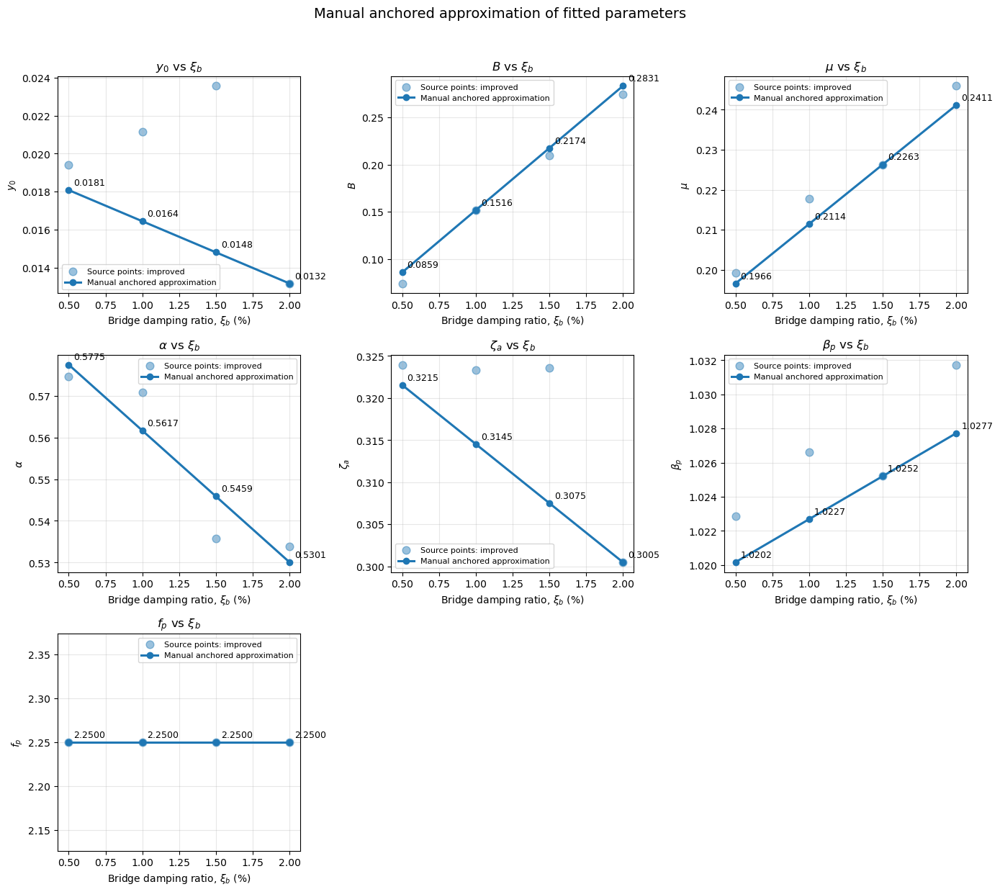

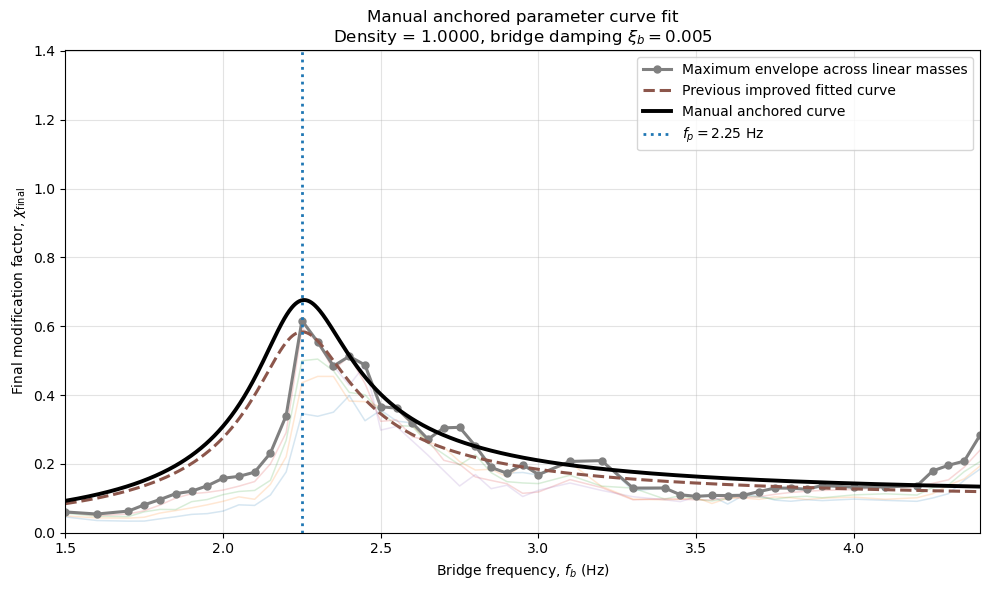

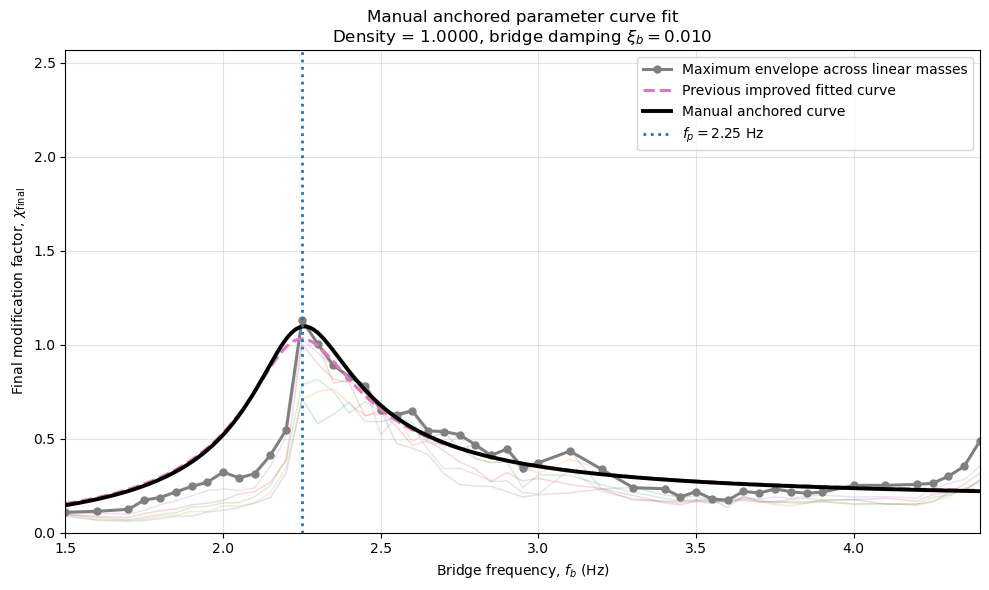

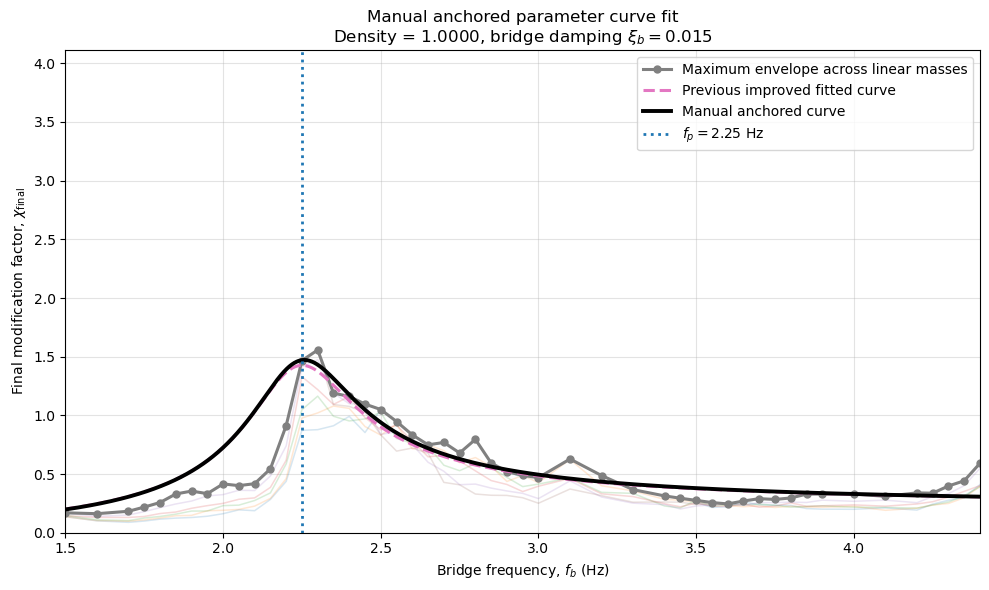

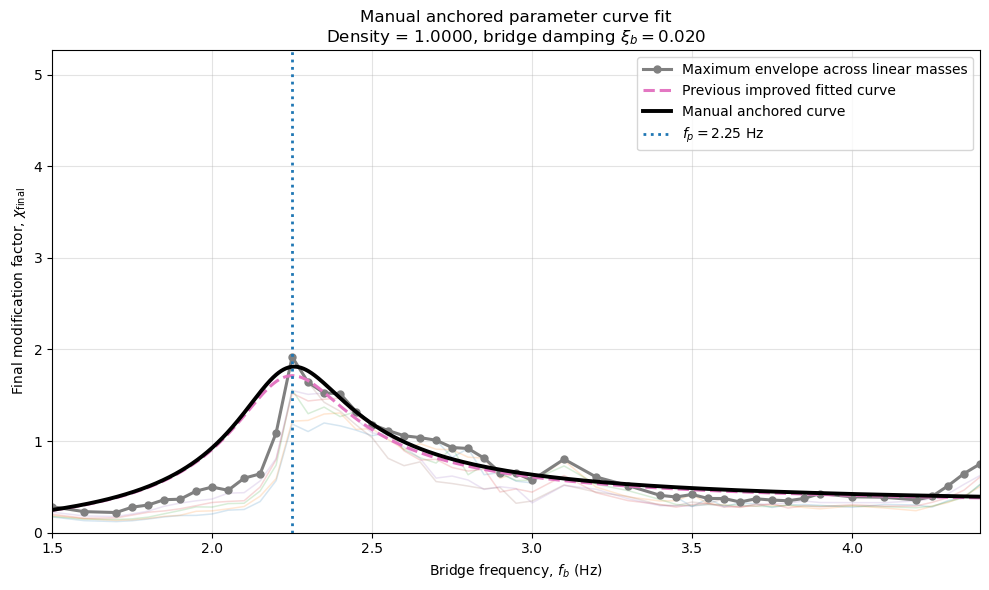


Manual curves dataframe:
    xi_b  bridge_frequency  chi_manual
0  0.005          1.500000    0.092683
1  0.005          1.501935    0.092989
2  0.005          1.503869    0.093296
3  0.005          1.505804    0.093605
4  0.005          1.507738    0.093915

FINAL MANUAL / ANCHORED MODIFICATION FACTOR EQUATIONS

--------------------------------------------------------------------------------
Bridge damping xi_b = 0.005
--------------------------------------------------------------------------------
Model form:
chi_manual(f_b) = y0 + B * Q(beta_eff)
beta_eff        = beta_p * f_b / f_p
f_p             = 2.25 Hz

Manual anchored equation:
chi_manual(f_b) = 0.018076 + 8.587771e-02 * Q(1.020163 * f_b / 2.250000)

Parameters:
y0       = 0.01807632
B        = 8.58777135e-02
mu       = 0.19658165
alpha    = 0.57747351
zeta_b   = 0.00500000
zeta_a   = 0.32154131
beta_p   = 1.02016336
f_p      = 2.25000000 Hz

--------------------------------------------------------------------------------
Br

In [33]:
# ==================================================
# MANUAL / ANCHORED PARAMETER APPROXIMATION
# ==================================================
# This block uses selected points from the parameter plots
# and redraws the fitted modification-factor curves.
#
# Assumes these already exist from previous code:
#   full_df
#   df_fit_params
#   df_raw_params
#   Q_mmd
#   Y_COL
#   TARGET_DENSITY
#   TARGET_DAMPINGS
#   F_TARGET_PEAK
#   FIT_FMIN, FIT_FMAX
#   PLOT_FMIN, PLOT_FMAX
# ==================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Choose which parameter graph to use as the source
# --------------------------------------------------
# "improved" = dark-blue points from previous parameter plot
# "raw"      = original independent fitted values

PARAM_SOURCE = "improved"

if PARAM_SOURCE == "improved":
    source_params = df_fit_params.copy()
elif PARAM_SOURCE == "raw":
    source_params = df_raw_params.copy()
else:
    raise ValueError("PARAM_SOURCE must be 'improved' or 'raw'.")

source_params = source_params.sort_values("xi_b").reset_index(drop=True)

# --------------------------------------------------
# Your selected anchor points, using 1-based indexing
# --------------------------------------------------
# y0      : 4th point from 1st graph
# B       : 2nd point from 2nd graph
# mu      : 3rd point from 3rd graph
# alpha   : keep smooth linear trend from all points
# zeta_a  : 4th point from 5th graph
# beta_p  : 3rd point from 6th graph

ANCHOR_POINT = {
    "y0": 4,
    "B": 2,
    "mu": 3,
    "zeta_a": 4,
    "beta_p": 3,
}

# For alpha, choose one of these:
#   "linear_all"       = use linear trend through all alpha points
#   "constant_median"  = use median alpha value
#   "anchor_shift"     = use one selected anchor point + slope from all points

ALPHA_MODE = "linear_all"
ALPHA_ANCHOR_POINT = 3


# ==================================================
# HELPER FUNCTIONS
# ==================================================

def anchored_linear_values(df, param, anchor_point_1based, xi_eval):
    """
    Linear trend using slope from all points,
    but shifted so that it passes exactly through the selected anchor point.
    """

    x = df["xi_b"].to_numpy(dtype=float)
    y = df[param].to_numpy(dtype=float)

    m, c_raw = np.polyfit(x, y, 1)

    anchor_idx = anchor_point_1based - 1
    x_anchor = x[anchor_idx]
    y_anchor = y[anchor_idx]

    c_shifted = y_anchor - m * x_anchor

    y_eval = m * xi_eval + c_shifted

    return y_eval, m, c_shifted, x_anchor, y_anchor


def ordinary_linear_values(df, param, xi_eval):
    """
    Ordinary least-squares linear trend through all points.
    """

    x = df["xi_b"].to_numpy(dtype=float)
    y = df[param].to_numpy(dtype=float)

    m, c = np.polyfit(x, y, 1)

    y_eval = m * xi_eval + c

    return y_eval, m, c


def clip_manual_params(row):
    """
    Keep parameters inside sensible physical/numerical ranges.
    """

    row["y0"] = max(row["y0"], 1e-8)
    row["B"] = max(row["B"], 1e-8)

    row["mu"] = np.clip(row["mu"], 0.001, 0.50)
    row["alpha"] = np.clip(row["alpha"], 0.50, 1.50)
    row["zeta_a"] = np.clip(row["zeta_a"], 0.30, 2.00)
    row["beta_p"] = np.clip(row["beta_p"], 0.80, 1.20)

    row["f_p"] = F_TARGET_PEAK

    return row


def chi_manual_beta_model(
    f_bridge,
    y0,
    B,
    mu,
    alpha,
    zeta_a,
    zeta_b,
    beta_p,
    f_p=F_TARGET_PEAK
):
    """
    Same MMD/TMD shape, but beta_p is now manually supplied.
    This is needed if you want to use beta_p from the parameter graph.
    """

    beta_eff = beta_p * (np.asarray(f_bridge, dtype=float) / f_p)

    Q_eff = Q_mmd(
        beta=beta_eff,
        mu=mu,
        alpha=alpha,
        zeta_b=zeta_b,
        zeta_a=zeta_a
    )

    return y0 + B * Q_eff


# ==================================================
# BUILD MANUAL PARAMETER TABLE
# ==================================================

xi_eval = np.array(TARGET_DAMPINGS, dtype=float)

manual_param_data = {
    "xi_b": xi_eval,
}

trend_info = {}

# y0, B, mu, zeta_a, beta_p from your selected anchor points
for param in ["y0", "B", "mu", "zeta_a", "beta_p"]:

    y_eval, m, c, x_anchor, y_anchor = anchored_linear_values(
        source_params,
        param,
        ANCHOR_POINT[param],
        xi_eval
    )

    manual_param_data[param] = y_eval

    trend_info[param] = {
        "method": "anchor_shift",
        "slope": m,
        "intercept": c,
        "anchor_xi_b": x_anchor,
        "anchor_value": y_anchor,
        "anchor_point": ANCHOR_POINT[param],
    }

# alpha treatment
if ALPHA_MODE == "linear_all":

    y_eval, m, c = ordinary_linear_values(
        source_params,
        "alpha",
        xi_eval
    )

    manual_param_data["alpha"] = y_eval

    trend_info["alpha"] = {
        "method": "linear_all",
        "slope": m,
        "intercept": c,
    }

elif ALPHA_MODE == "constant_median":

    alpha_const = np.nanmedian(source_params["alpha"])

    manual_param_data["alpha"] = np.full_like(xi_eval, alpha_const)

    trend_info["alpha"] = {
        "method": "constant_median",
        "value": alpha_const,
    }

elif ALPHA_MODE == "anchor_shift":

    y_eval, m, c, x_anchor, y_anchor = anchored_linear_values(
        source_params,
        "alpha",
        ALPHA_ANCHOR_POINT,
        xi_eval
    )

    manual_param_data["alpha"] = y_eval

    trend_info["alpha"] = {
        "method": "anchor_shift",
        "slope": m,
        "intercept": c,
        "anchor_xi_b": x_anchor,
        "anchor_value": y_anchor,
        "anchor_point": ALPHA_ANCHOR_POINT,
    }

else:
    raise ValueError("Unknown ALPHA_MODE.")

manual_param_data["f_p"] = np.full_like(xi_eval, F_TARGET_PEAK)

df_manual_params = pd.DataFrame(manual_param_data)

df_manual_params = df_manual_params.apply(
    lambda row: clip_manual_params(row),
    axis=1
)

df_manual_params["xi_b_percent"] = 100.0 * df_manual_params["xi_b"]

print("\n" + "="*80)
print("MANUAL / ANCHORED PARAMETER TABLE")
print("="*80)
print(df_manual_params)

print("\nTrend information:")
for param, info in trend_info.items():
    print(param, ":", info)


# ==================================================
# PARAMETER COMPARISON PLOT
# ==================================================

symbol_labels = {
    "y0": r"$y_0$",
    "B": r"$B$",
    "mu": r"$\mu$",
    "alpha": r"$\alpha$",
    "zeta_a": r"$\zeta_a$",
    "beta_p": r"$\beta_p$",
    "f_p": r"$f_p$",
    "xi_b": r"$\xi_b$",
}

params_to_plot = ["y0", "B", "mu", "alpha", "zeta_a", "beta_p", "f_p"]

source_params["xi_b_percent"] = 100.0 * source_params["xi_b"]

n = len(params_to_plot)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.2 * nrows))
axes = np.asarray(axes).reshape(-1)

for ax, param in zip(axes, params_to_plot):

    ax.scatter(
        source_params["xi_b_percent"],
        source_params[param],
        s=60,
        alpha=0.45,
        label=f"Source points: {PARAM_SOURCE}"
    )

    ax.plot(
        df_manual_params["xi_b_percent"],
        df_manual_params[param],
        marker="o",
        linewidth=2.2,
        label="Manual anchored approximation"
    )

    for x, y in zip(df_manual_params["xi_b_percent"], df_manual_params[param]):
        ax.annotate(
            f"{y:.4f}",
            (x, y),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

    ax.set_title(f"{symbol_labels[param]} vs {symbol_labels['xi_b']}")
    ax.set_xlabel(r"Bridge damping ratio, $\xi_b$ (%)")
    ax.set_ylabel(symbol_labels[param])
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

for j in range(len(params_to_plot), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Manual anchored approximation of fitted parameters",
    fontsize=14
)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# ==================================================
# REDRAW CURVE FITS USING MANUAL PARAMETERS
# ==================================================

manual_curve_rows = []

for _, prow in df_manual_params.iterrows():

    zeta_b = float(prow["xi_b"])

    damping_df = full_df[
        np.isclose(full_df["target_beamdamp"], zeta_b)
    ].copy()

    if damping_df.empty:
        print(f"No data for damping {zeta_b:.3f}")
        continue

    env_df = (
        damping_df
        .groupby("bridge_frequency", as_index=False)
        .agg(envelope_factor=(Y_COL, "max"))
        .sort_values("bridge_frequency")
    )

    x_smooth = np.linspace(PLOT_FMIN, PLOT_FMAX, 1500)

    y_manual = chi_manual_beta_model(
        f_bridge=x_smooth,
        y0=float(prow["y0"]),
        B=float(prow["B"]),
        mu=float(prow["mu"]),
        alpha=float(prow["alpha"]),
        zeta_a=float(prow["zeta_a"]),
        zeta_b=zeta_b,
        beta_p=float(prow["beta_p"]),
        f_p=float(prow["f_p"])
    )

    for xb, yb in zip(x_smooth, y_manual):
        manual_curve_rows.append({
            "xi_b": zeta_b,
            "bridge_frequency": xb,
            "chi_manual": yb,
        })

    plt.figure(figsize=(10, 6))

    # Individual linear-mass curves
    for lm in sorted(damping_df["linear_mass_key"].dropna().unique()):

        sub = damping_df[
            damping_df["linear_mass_key"] == lm
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        plt.plot(
            sub["bridge_frequency"],
            sub[Y_COL],
            linewidth=1.1,
            alpha=0.18
        )

    # Envelope
    plt.plot(
        env_df["bridge_frequency"],
        env_df["envelope_factor"],
        "o-",
        linewidth=2.2,
        markersize=5,
        color="gray",
        label="Maximum envelope across linear masses"
    )

    # Previous improved curve, if available
    if "df_fit_curves" in globals():

        old_curve = df_fit_curves[
            np.isclose(df_fit_curves["xi_b"], zeta_b)
        ].copy()

        if not old_curve.empty:
            plt.plot(
                old_curve["bridge_frequency"],
                old_curve["chi_ideal"],
                linestyle="--",
                linewidth=2.2,
                label="Previous improved fitted curve"
            )

    # Manual anchored curve
    plt.plot(
        x_smooth,
        y_manual,
        "k-",
        linewidth=2.8,
        label="Manual anchored curve"
    )

    plt.axvline(
        F_TARGET_PEAK,
        linestyle=":",
        linewidth=2.0,
        label=rf"$f_p={F_TARGET_PEAK:.2f}$ Hz"
    )

    plt.xlabel(r"Bridge frequency, $f_b$ (Hz)")
    plt.ylabel(r"Final modification factor, $\chi_{\mathrm{final}}$")

    plt.title(
        "Manual anchored parameter curve fit\n"
        rf"Density = {TARGET_DENSITY:.4f}, bridge damping $\xi_b={zeta_b:.3f}$"
    )

    plt.xlim(PLOT_FMIN, PLOT_FMAX)

    ymax_plot = max(
        np.nanmax(env_df["envelope_factor"]),
        np.nanmax(y_manual),
        np.nanmax(damping_df[Y_COL])
    )

    plt.ylim(0, 1.15 * ymax_plot)

    plt.grid(True, alpha=0.35)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


df_manual_curves = pd.DataFrame(manual_curve_rows)

print("\nManual curves dataframe:")
print(df_manual_curves.head())


# ==================================================
# PRINT FINAL MANUAL EQUATIONS
# ==================================================

print("\n" + "="*80)
print("FINAL MANUAL / ANCHORED MODIFICATION FACTOR EQUATIONS")
print("="*80)

for _, row in df_manual_params.iterrows():

    print("\n" + "-"*80)
    print(f"Bridge damping xi_b = {row['xi_b']:.3f}")
    print("-"*80)

    print("Model form:")
    print("chi_manual(f_b) = y0 + B * Q(beta_eff)")
    print("beta_eff        = beta_p * f_b / f_p")
    print("f_p             = 2.25 Hz")

    print("\nManual anchored equation:")
    print(
        f"chi_manual(f_b) = {row['y0']:.6f} "
        f"+ {row['B']:.6e} * Q({row['beta_p']:.6f} * f_b / {F_TARGET_PEAK:.6f})"
    )

    print("\nParameters:")
    print(f"y0       = {row['y0']:.8f}")
    print(f"B        = {row['B']:.8e}")
    print(f"mu       = {row['mu']:.8f}")
    print(f"alpha    = {row['alpha']:.8f}")
    print(f"zeta_b   = {row['xi_b']:.8f}")
    print(f"zeta_a   = {row['zeta_a']:.8f}")
    print(f"beta_p   = {row['beta_p']:.8f}")
    print(f"f_p      = {row['f_p']:.8f} Hz")

print("="*80)

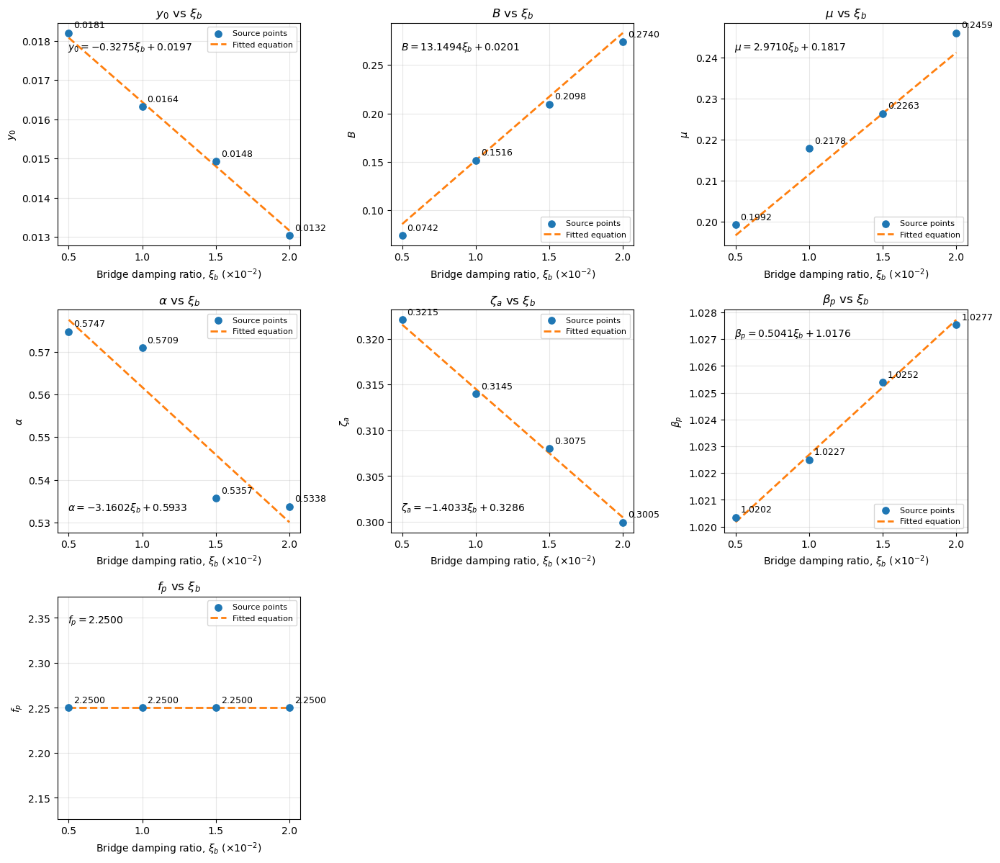

In [39]:
# ==================================================
# PREVIOUS-STYLE PARAMETER EQUATION PLOT
# Run this AFTER the manual/anchored approximation code
# ==================================================

import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Required objects from previous manual code
# --------------------------------------------------
required_objects = [
    "source_params",
    "df_manual_params",
    "trend_info",
    "PARAM_SOURCE",
    "F_TARGET_PEAK",
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"{obj} not found. Run the manual/anchored code first.")

# --------------------------------------------------
# Settings
# --------------------------------------------------
params_to_plot = ["y0", "B", "mu", "alpha", "zeta_a", "beta_p", "f_p"]

# Do not show original/source points for these
hide_original_points_for = ["y0", "zeta_a", "beta_p"]

# Spread predicted points visually for hidden-original parameters
SPREAD_FRACTION = 0.025

symbol_labels = {
    "y0": r"$y_0$",
    "B": r"$B$",
    "mu": r"$\mu$",
    "alpha": r"$\alpha$",
    "zeta_a": r"$\zeta_a$",
    "beta_p": r"$\beta_p$",
    "f_p": r"$f_p$",
    "xi_b": r"$\xi_b$",
}

symbol_raw = {
    "y0": r"y_0",
    "B": r"B",
    "mu": r"\mu",
    "alpha": r"\alpha",
    "zeta_a": r"\zeta_a",
    "beta_p": r"\beta_p",
    "f_p": r"f_p",
}

# --------------------------------------------------
# Prepare x-values
# --------------------------------------------------
plot_source = source_params.copy()
plot_manual = df_manual_params.copy()

if "xi_b_percent" not in plot_source.columns:
    plot_source["xi_b_percent"] = 100.0 * plot_source["xi_b"]

if "xi_b_percent" not in plot_manual.columns:
    plot_manual["xi_b_percent"] = 100.0 * plot_manual["xi_b"]

xi_min = min(plot_source["xi_b"].min(), plot_manual["xi_b"].min())
xi_max = max(plot_source["xi_b"].max(), plot_manual["xi_b"].max())

xi_fit = np.linspace(xi_min, xi_max, 300)
xi_fit_percent = 100.0 * xi_fit

# --------------------------------------------------
# Helper: evaluate manual/anchored equation
# --------------------------------------------------
def evaluate_manual_trend(param, xi_values):
    """
    Evaluate the parameter equation created in the manual/anchored code.
    """

    xi_values = np.asarray(xi_values, dtype=float)

    if param == "f_p":
        return np.full_like(xi_values, F_TARGET_PEAK, dtype=float), 0.0, F_TARGET_PEAK, "constant"

    info = trend_info[param]

    if info["method"] in ["anchor_shift", "linear_all"]:
        m = float(info["slope"])
        c = float(info["intercept"])
        return m * xi_values + c, m, c, info["method"]

    if info["method"] == "constant_median":
        c = float(info["value"])
        return np.full_like(xi_values, c, dtype=float), 0.0, c, info["method"]

    raise ValueError(f"Unknown trend method for {param}: {info['method']}")

# --------------------------------------------------
# Plot
# --------------------------------------------------
ncols = 3
nrows = int(np.ceil(len(params_to_plot) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(14, 4.2 * nrows)
)

axes = np.asarray(axes).reshape(-1)

for ax, param in zip(axes, params_to_plot):

    # Manual fitted/equation line
    y_fit, m, c, method = evaluate_manual_trend(param, xi_fit)

    # Manual predicted points at target damping ratios
    y_pred, _, _, _ = evaluate_manual_trend(param, plot_manual["xi_b"].to_numpy())

    # --------------------------------------------------
    # Blue points
    # --------------------------------------------------
    if param in hide_original_points_for:

        # Spread predicted points slightly up/down only for visibility
        y_range = max(np.nanmax(y_fit) - np.nanmin(y_fit), 1e-8)
        offsets = np.array([(-1) ** i for i in range(len(y_pred))]) * SPREAD_FRACTION * y_range
        y_pred_spread = y_pred + offsets

        ax.scatter(
            plot_manual["xi_b_percent"],
            y_pred_spread,
            s=45,
            color="#1f77b4",
            label="Source points",
            zorder=3
        )

        for x, y_plot, y_true in zip(
            plot_manual["xi_b_percent"],
            y_pred_spread,
            y_pred
        ):
            ax.annotate(
                f"{y_true:.4f}",
                (x, y_plot),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )

    else:

        # Show original/source points in blue
        ax.scatter(
            plot_source["xi_b_percent"],
            plot_source[param],
            s=45,
            color="#1f77b4",
            label=f"Source points",
            zorder=3
        )

        for x, y in zip(plot_source["xi_b_percent"], plot_source[param]):
            ax.annotate(
                f"{y:.4f}",
                (x, y),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )

    # --------------------------------------------------
    # Orange dashed fit/equation line
    # --------------------------------------------------
    ax.plot(
        xi_fit_percent,
        y_fit,
        linestyle="--",
        linewidth=2.0,
        color="#ff7f0e",
        label="Fitted equation"
    )

    # --------------------------------------------------
    # Equation text
    # Important: equation uses xi_b as ratio, not percent
    # --------------------------------------------------
    if param == "f_p" or abs(m) < 1e-12:
        equation_text = rf"${symbol_raw[param]} = {c:.4f}$"
    else:
        equation_text = rf"${symbol_raw[param]} = {m:.4f}\xi_b + {c:.4f}$"

        # --------------------------------------------------
    # Equation text position
    # --------------------------------------------------
    if param in ["alpha", "zeta_a"]:
        eq_x = 0.04
        eq_y = 0.08
        eq_va = "bottom"
    else:
        eq_x = 0.04
        eq_y = 0.92
        eq_va = "top"

    ax.text(
        eq_x,
        eq_y,
        equation_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment=eq_va
    )

    ax.set_title(rf"{symbol_labels[param]} vs {symbol_labels['xi_b']}")
    ax.set_xlabel(r"Bridge damping ratio, $\xi_b$ $(\times 10^{-2})$")
    ax.set_ylabel(symbol_labels[param])

    ax.set_xticks(plot_manual["xi_b_percent"])
    ax.set_xticklabels([f"{x:.1f}" for x in plot_manual["xi_b_percent"]])

    ax.grid(True, alpha=0.30)
    ax.legend(fontsize=8)

# Remove unused axes
for j in range(len(params_to_plot), len(axes)):
    fig.delaxes(axes[j])



fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Parameter values from equations:
 xi_b       y0        B       mu    alpha   zeta_a   beta_p  f_p  xi_b_percent
0.005 0.018076 0.085878 0.196582 0.577474 0.321541 1.020163 2.25           0.5
0.010 0.016439 0.151625 0.211436 0.561672 0.314525 1.022684 2.25           1.0
0.015 0.014801 0.217372 0.226291 0.545871 0.307508 1.025204 2.25           1.5
0.020 0.013164 0.283118 0.241146 0.530070 0.300491 1.027725 2.25           2.0


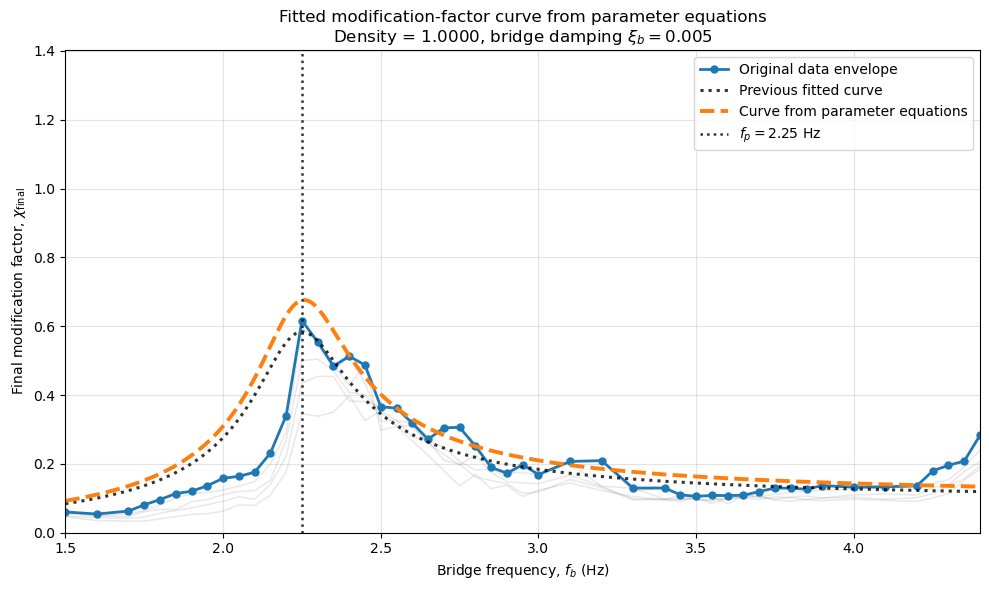

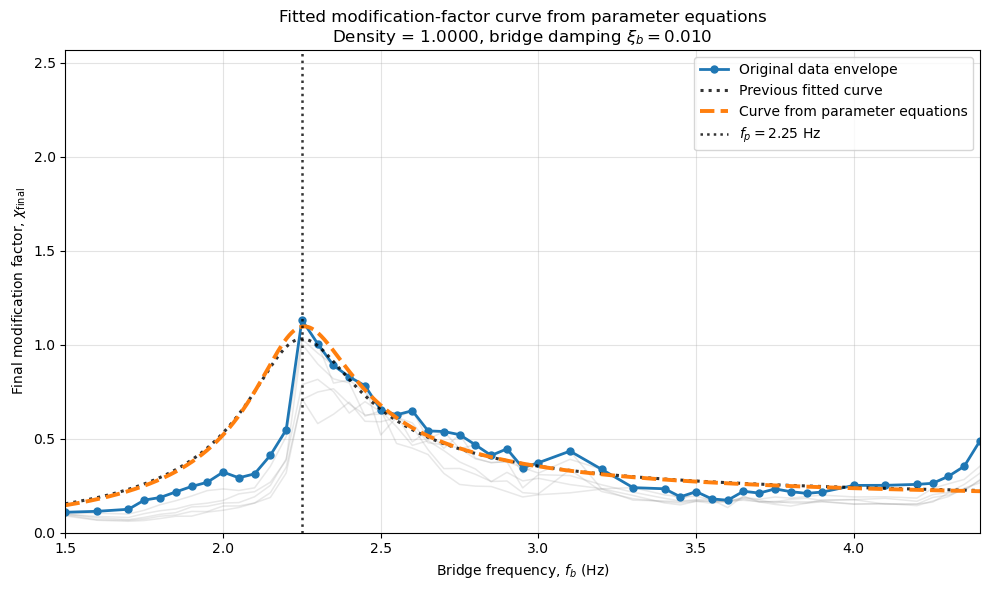

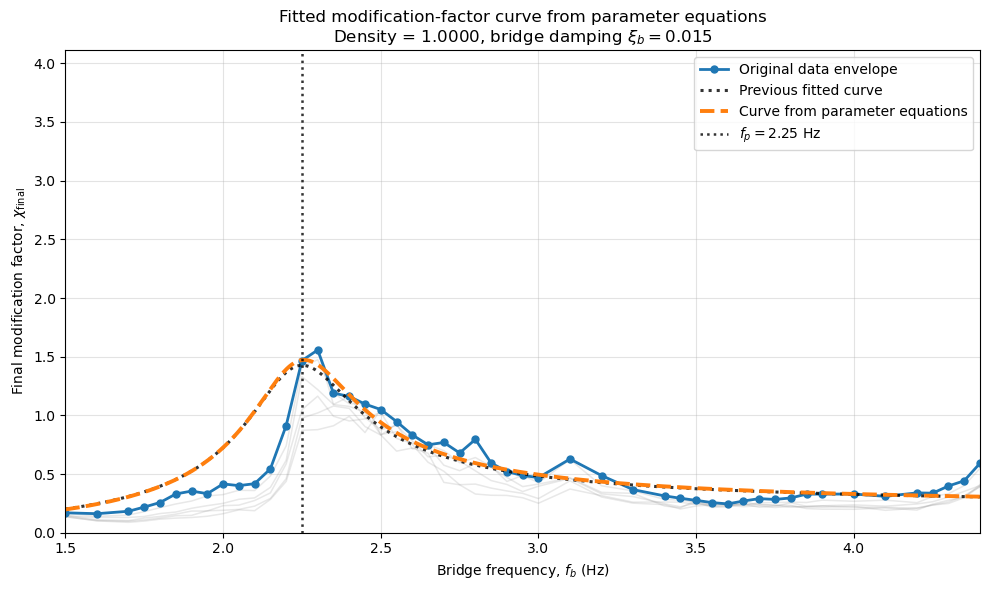

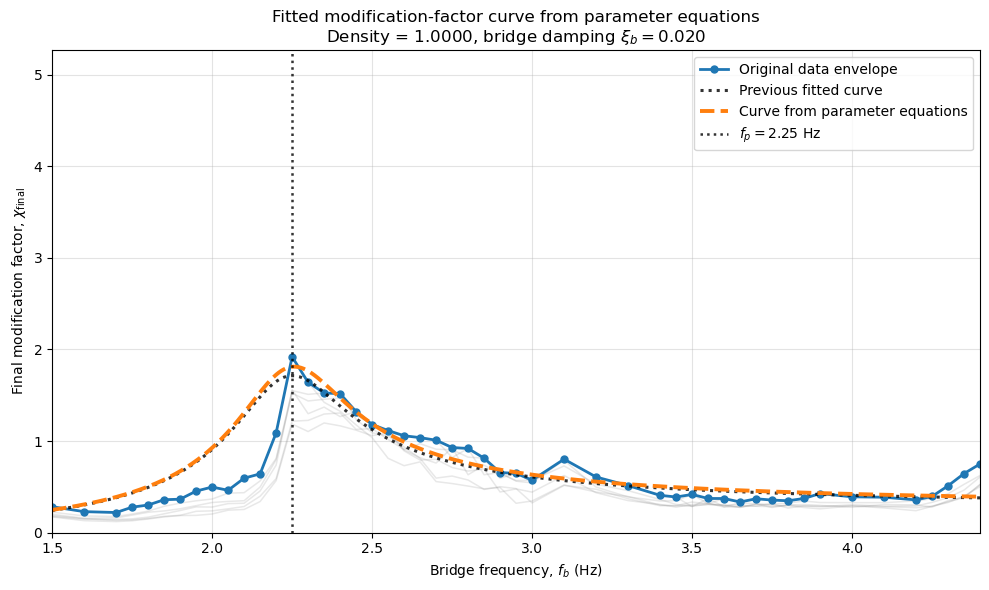


Saved in notebook memory:
df_equation_params
df_equation_curves


In [37]:
# ==================================================
# PLOT FITTED CURVES FROM MANUAL PARAMETER EQUATIONS
# WITH ORIGINAL DATA
# Run this after the parameter-equation plot
# ==================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Required objects
# --------------------------------------------------
required_objects = [
    "full_df",
    "trend_info",
    "df_manual_params",
    "Q_mmd",
    "Y_COL",
    "F_TARGET_PEAK",
    "PLOT_FMIN",
    "PLOT_FMAX",
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"{obj} not found. Run the previous fitting/manual code first.")

# --------------------------------------------------
# Helper: evaluate equations from trend_info
# --------------------------------------------------
def evaluate_manual_param_equation(param, xi_b):
    """
    Evaluate the fitted/manual parameter equation.
    xi_b is the real damping ratio, e.g. 0.010, not percentage.
    """

    xi_b = np.asarray(xi_b, dtype=float)

    if param == "f_p":
        return np.full_like(xi_b, F_TARGET_PEAK, dtype=float)

    info = trend_info[param]

    if info["method"] in ["anchor_shift", "linear_all"]:
        m = float(info["slope"])
        c = float(info["intercept"])
        return m * xi_b + c

    if info["method"] == "constant_median":
        return np.full_like(xi_b, float(info["value"]), dtype=float)

    raise ValueError(f"Unknown method for {param}: {info['method']}")

# --------------------------------------------------
# Build parameter table directly from equations
# --------------------------------------------------
xi_values = np.sort(df_manual_params["xi_b"].unique())

equation_param_rows = []

for xi_b in xi_values:

    row = {
        "xi_b": xi_b,
        "y0": evaluate_manual_param_equation("y0", xi_b).item(),
        "B": evaluate_manual_param_equation("B", xi_b).item(),
        "mu": evaluate_manual_param_equation("mu", xi_b).item(),
        "alpha": evaluate_manual_param_equation("alpha", xi_b).item(),
        "zeta_a": evaluate_manual_param_equation("zeta_a", xi_b).item(),
        "beta_p": evaluate_manual_param_equation("beta_p", xi_b).item(),
        "f_p": evaluate_manual_param_equation("f_p", xi_b).item(),
    }

    # Safety clipping, same idea as earlier
    row["y0"] = max(row["y0"], 1e-8)
    row["B"] = max(row["B"], 1e-8)
    row["mu"] = np.clip(row["mu"], 0.001, 0.50)
    row["alpha"] = np.clip(row["alpha"], 0.50, 1.50)
    row["zeta_a"] = np.clip(row["zeta_a"], 0.30, 2.00)
    row["beta_p"] = np.clip(row["beta_p"], 0.80, 1.20)

    equation_param_rows.append(row)

df_equation_params = pd.DataFrame(equation_param_rows)
df_equation_params["xi_b_percent"] = 100.0 * df_equation_params["xi_b"]

print("\nParameter values from equations:")
print(df_equation_params.to_string(index=False))

# --------------------------------------------------
# Main fitted curve equation
# --------------------------------------------------
def chi_from_equation_params(f_bridge, row):
    """
    chi(f_b) = y0 + B * Q(beta_eff)
    beta_eff = beta_p * f_b / f_p
    """

    f_bridge = np.asarray(f_bridge, dtype=float)

    beta_eff = float(row["beta_p"]) * f_bridge / float(row["f_p"])

    Q_eff = Q_mmd(
        beta=beta_eff,
        mu=float(row["mu"]),
        alpha=float(row["alpha"]),
        zeta_b=float(row["xi_b"]),
        zeta_a=float(row["zeta_a"])
    )

    return float(row["y0"]) + float(row["B"]) * Q_eff

# --------------------------------------------------
# Plot fitted curves with original data
# --------------------------------------------------
equation_curve_rows = []

x_smooth = np.linspace(PLOT_FMIN, PLOT_FMAX, 1500)

for _, prow in df_equation_params.iterrows():

    xi_b = float(prow["xi_b"])

    damping_df = full_df[
        np.isclose(full_df["target_beamdamp"], xi_b)
    ].copy()

    # If full_df contains multiple densities, keep target density
    if "TARGET_DENSITY" in globals() and "target_density" in damping_df.columns:
        damping_df = damping_df[
            np.isclose(damping_df["target_density"], TARGET_DENSITY)
        ].copy()

    if damping_df.empty:
        print(f"No original data found for xi_b = {xi_b:.3f}")
        continue

    damping_df = damping_df.sort_values("bridge_frequency")

    env_df = (
        damping_df
        .groupby("bridge_frequency", as_index=False)
        .agg(envelope_factor=(Y_COL, "max"))
        .sort_values("bridge_frequency")
    )

    y_equation = chi_from_equation_params(x_smooth, prow)

    for f, chi in zip(x_smooth, y_equation):
        equation_curve_rows.append({
            "xi_b": xi_b,
            "bridge_frequency": f,
            "chi_equation": chi,
        })

    plt.figure(figsize=(10, 6))

    # Original individual data curves
    if "linear_mass_key" in damping_df.columns:
        for lm in sorted(damping_df["linear_mass_key"].dropna().unique()):

            sub = damping_df[
                damping_df["linear_mass_key"] == lm
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub[Y_COL],
                linewidth=1.1,
                alpha=0.18,
                color="gray"
            )
    else:
        plt.scatter(
            damping_df["bridge_frequency"],
            damping_df[Y_COL],
            s=18,
            alpha=0.25,
            color="gray",
            label="Original data"
        )

    # Maximum envelope from original data
    plt.plot(
        env_df["bridge_frequency"],
        env_df["envelope_factor"],
        "o-",
        linewidth=2.0,
        markersize=5,
        color="#1f77b4",
        label="Original data envelope"
    )

    # Optional previous fitted curve
    if "df_fit_curves" in globals():
        old_curve = df_fit_curves[
            np.isclose(df_fit_curves["xi_b"], xi_b)
        ].copy()

        if not old_curve.empty:
            y_col_old = "chi_ideal" if "chi_ideal" in old_curve.columns else old_curve.columns[-1]

            plt.plot(
                old_curve["bridge_frequency"],
                old_curve[y_col_old],
                linestyle=":",
                linewidth=2.2,
                color="black",
                alpha=0.8,
                label="Previous fitted curve"
            )

    # New curve from the displayed equations
    plt.plot(
        x_smooth,
        y_equation,
        linestyle="--",
        linewidth=2.8,
        color="#ff7f0e",
        label="Curve from parameter equations"
    )

    plt.axvline(
        F_TARGET_PEAK,
        linestyle=":",
        linewidth=1.8,
        color="black",
        alpha=0.8,
        label=rf"$f_p={F_TARGET_PEAK:.2f}$ Hz"
    )

    plt.xlabel(r"Bridge frequency, $f_b$ (Hz)")
    plt.ylabel(r"Final modification factor, $\chi_{\mathrm{final}}$")

    title_density = ""
    if "TARGET_DENSITY" in globals():
        title_density = rf"Density = {TARGET_DENSITY:.4f}, "

    plt.title(
        "Fitted modification-factor curve from parameter equations\n"
        + title_density
        + rf"bridge damping $\xi_b={xi_b:.3f}$"
    )

    plt.xlim(PLOT_FMIN, PLOT_FMAX)

    ymax_plot = max(
        np.nanmax(damping_df[Y_COL]),
        np.nanmax(env_df["envelope_factor"]),
        np.nanmax(y_equation)
    )

    plt.ylim(0, 1.15 * ymax_plot)

    plt.grid(True, alpha=0.35)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

df_equation_curves = pd.DataFrame(equation_curve_rows)

print("\nSaved in notebook memory:")
print("df_equation_params")
print("df_equation_curves")

Using parameter table: df_upper_env_params

Sensitivity summary:
 xi_b parameter  mean_abs_sensitivity  rms_sensitivity  max_abs_sensitivity  frequency_at_max_abs  signed_sensitivity_at_max_abs
0.005    beta_p              3.136910         4.181037            10.283223              2.205405                      10.283223
0.005         B              0.987607         0.987633             0.996736              2.336036                       0.996736
0.005     alpha              0.842986         1.155220             3.677381              2.353453                       3.677381
0.005        mu              0.417078         0.542977             1.333757              2.446346                      -1.333757
0.005    zeta_a              0.262326         0.324185             0.730075              2.498599                       0.730075
0.005        y0              0.012392         0.014315             0.041247              1.500000                       0.041247
0.010    beta_p              3.3

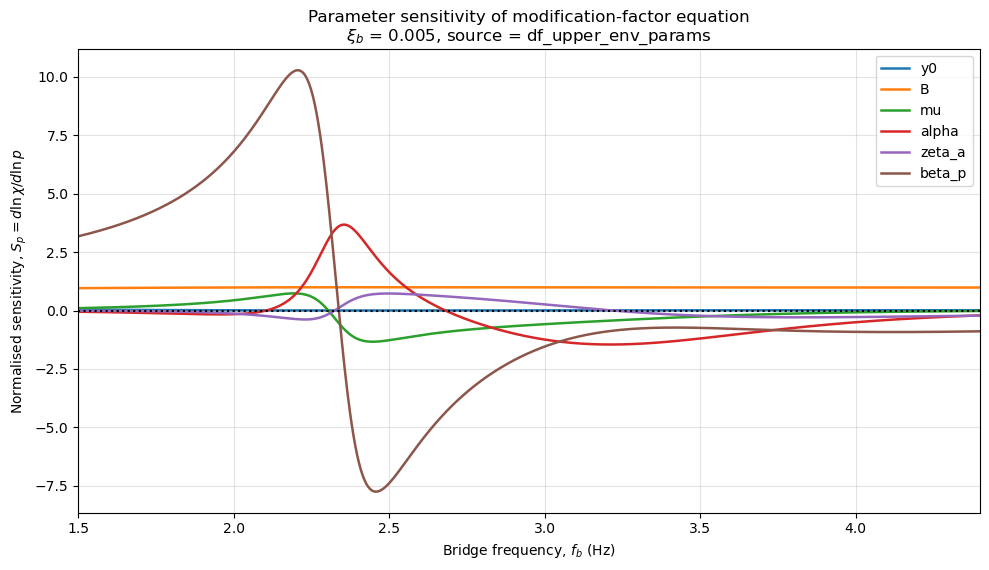

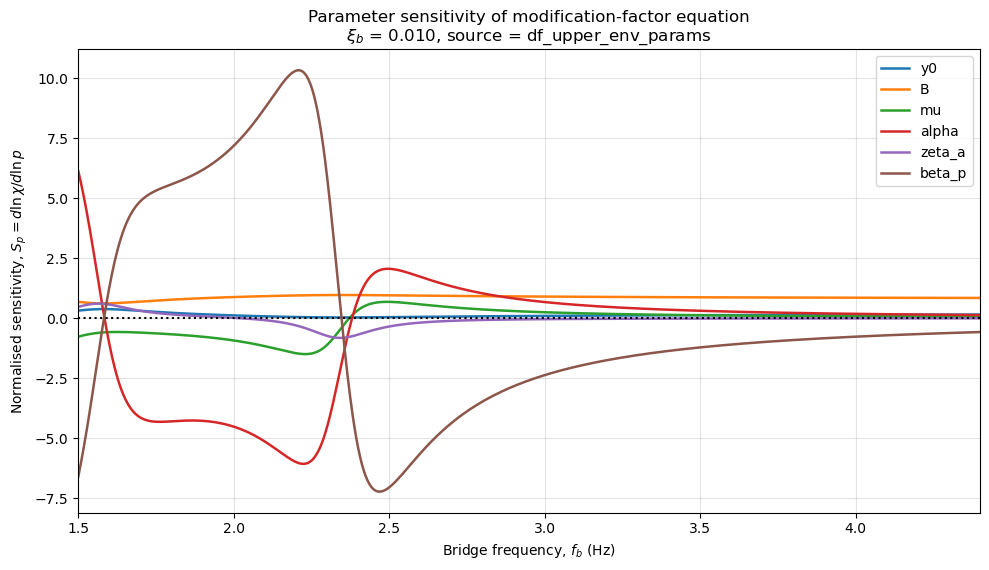

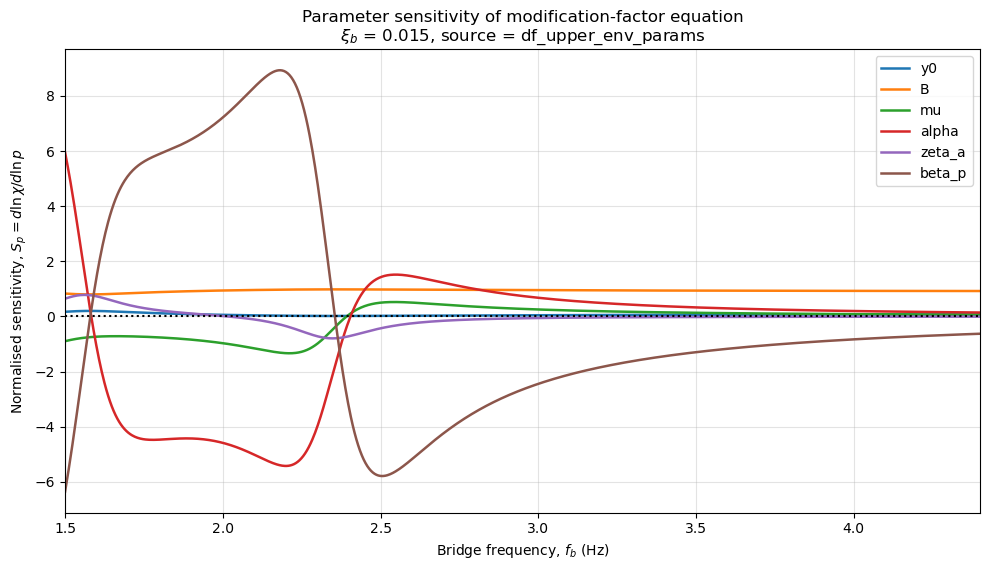

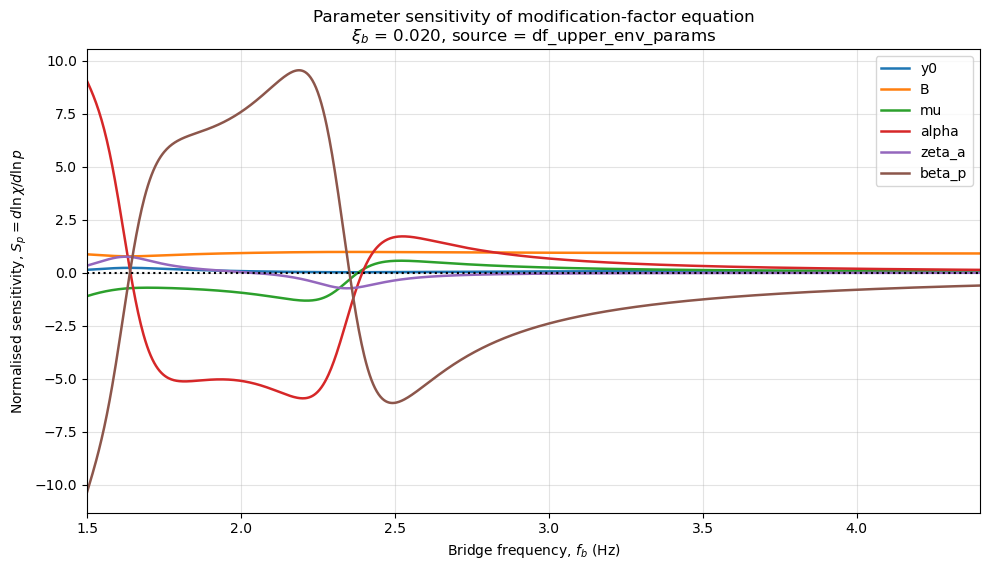


Overall importance ranking:
parameter  mean_abs_sensitivity  rms_sensitivity  max_abs_sensitivity
   beta_p              3.280278         4.246845            10.333482
    alpha              1.495829         2.236157             9.021716
        B              0.927543         0.928955             0.996736
       mu              0.414523         0.553049             1.494395
   zeta_a              0.185938         0.286885             0.819904
       y0              0.072451         0.084446             0.382505


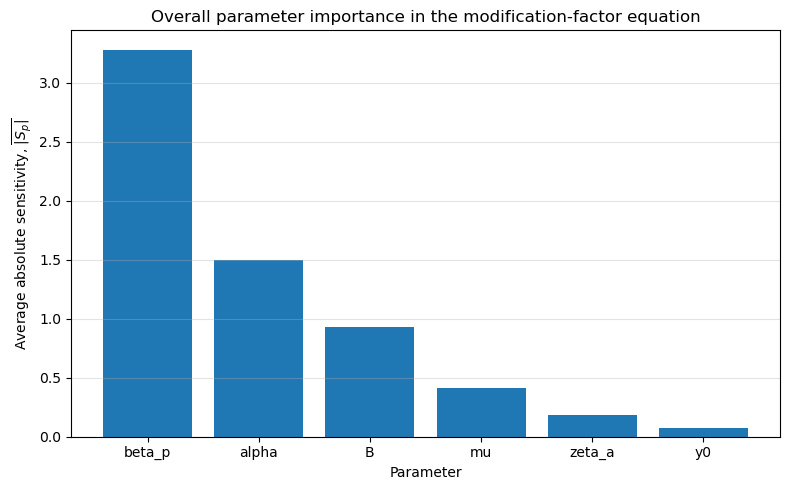

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# SETTINGS
# ==================================================

PARAM_TABLE_SOURCE = "auto"
# Options:
# PARAM_TABLE_SOURCE = "upper_env"
# PARAM_TABLE_SOURCE = "best_anchor"
# PARAM_TABLE_SOURCE = "manual"
# PARAM_TABLE_SOURCE = "fit_params"
# PARAM_TABLE_SOURCE = "auto"

PERTURBATION = 0.01
# 0.01 = plus/minus 1% perturbation

FMIN = 1.50
FMAX = 4.40
N_FREQ = 1000

PARAMS_TO_TEST = ["y0", "B", "mu", "alpha", "zeta_a", "beta_p"]

INCLUDE_F_P = False
# Set True only if you want to test sensitivity to peak location.
# But for your current final model f_p is fixed at 2.25 Hz.

SAVE_RESULTS = True


# ==================================================
# CHOOSE PARAMETER TABLE
# ==================================================

if PARAM_TABLE_SOURCE == "auto":

    if "df_upper_env_params" in globals() and not df_upper_env_params.empty:
        param_df = df_upper_env_params.copy()
        source_name = "df_upper_env_params"

    elif "df_best_params" in globals() and not df_best_params.empty:
        param_df = df_best_params.copy()
        source_name = "df_best_params"

    elif "df_manual_params" in globals() and not df_manual_params.empty:
        param_df = df_manual_params.copy()
        source_name = "df_manual_params"

    elif "df_fit_params" in globals() and not df_fit_params.empty:
        param_df = df_fit_params.copy()
        source_name = "df_fit_params"

    else:
        raise ValueError("No suitable parameter dataframe found.")

elif PARAM_TABLE_SOURCE == "upper_env":
    param_df = df_upper_env_params.copy()
    source_name = "df_upper_env_params"

elif PARAM_TABLE_SOURCE == "best_anchor":
    param_df = df_best_params.copy()
    source_name = "df_best_params"

elif PARAM_TABLE_SOURCE == "manual":
    param_df = df_manual_params.copy()
    source_name = "df_manual_params"

elif PARAM_TABLE_SOURCE == "fit_params":
    param_df = df_fit_params.copy()
    source_name = "df_fit_params"

else:
    raise ValueError("Unknown PARAM_TABLE_SOURCE.")

print("Using parameter table:", source_name)

if "zeta_b" in param_df.columns and "xi_b" not in param_df.columns:
    param_df = param_df.rename(columns={"zeta_b": "xi_b"})

required_cols = ["xi_b", "y0", "B", "mu", "alpha", "zeta_a", "beta_p", "f_p"]

missing_cols = [c for c in required_cols if c not in param_df.columns]

if missing_cols:
    raise KeyError(f"Missing columns in parameter table: {missing_cols}")

for col in required_cols:
    param_df[col] = pd.to_numeric(param_df[col], errors="coerce")

param_df = param_df.dropna(subset=required_cols).copy()
param_df = param_df.sort_values("xi_b").reset_index(drop=True)

if INCLUDE_F_P:
    PARAMS_TO_TEST = PARAMS_TO_TEST + ["f_p"]


# ==================================================
# MODEL FUNCTION
# ==================================================

def chi_model_from_row(f_bridge, row):
    """
    Main modification-factor equation:
        chi = y0 + B * Q(beta_eff)
        beta_eff = beta_p * f_b / f_p
    """

    f_bridge = np.asarray(f_bridge, dtype=float)

    xi_b = float(row["xi_b"])
    y0 = float(row["y0"])
    B = float(row["B"])
    mu = float(row["mu"])
    alpha = float(row["alpha"])
    zeta_a = float(row["zeta_a"])
    beta_p = float(row["beta_p"])
    f_p = float(row["f_p"])

    beta_eff = beta_p * f_bridge / f_p

    Q_eff = Q_mmd(
        beta=beta_eff,
        mu=mu,
        alpha=alpha,
        zeta_b=xi_b,
        zeta_a=zeta_a
    )

    chi = y0 + B * Q_eff

    return chi


def perturb_row(row, param, factor):
    """
    Perturb one parameter by a multiplicative factor.
    """

    row_new = row.copy()

    row_new[param] = float(row_new[param]) * factor

    # Safety limits
    row_new["y0"] = max(float(row_new["y0"]), 1e-8)
    row_new["B"] = max(float(row_new["B"]), 1e-8)

    row_new["mu"] = np.clip(float(row_new["mu"]), 0.001, 0.50)
    row_new["alpha"] = np.clip(float(row_new["alpha"]), 0.40, 1.50)
    row_new["zeta_a"] = np.clip(float(row_new["zeta_a"]), 0.05, 2.00)
    row_new["beta_p"] = np.clip(float(row_new["beta_p"]), 0.80, 1.20)
    row_new["f_p"] = np.clip(float(row_new["f_p"]), 1.50, 4.00)

    return row_new


# ==================================================
# COMPUTE NORMALISED SENSITIVITY
# ==================================================

f_grid = np.linspace(FMIN, FMAX, N_FREQ)

sensitivity_rows = []
summary_rows = []

for _, row in param_df.iterrows():

    xi_b = float(row["xi_b"])

    chi_base = chi_model_from_row(f_grid, row)

    valid_base = np.isfinite(chi_base) & (chi_base > 0)

    for param in PARAMS_TO_TEST:

        row_plus = perturb_row(row, param, 1.0 + PERTURBATION)
        row_minus = perturb_row(row, param, 1.0 - PERTURBATION)

        chi_plus = chi_model_from_row(f_grid, row_plus)
        chi_minus = chi_model_from_row(f_grid, row_minus)

        # Normalised central-difference sensitivity:
        # S = d ln(chi) / d ln(param)
        sensitivity = (
            np.log(chi_plus) - np.log(chi_minus)
        ) / (
            np.log(1.0 + PERTURBATION) - np.log(1.0 - PERTURBATION)
        )

        valid = (
            valid_base &
            np.isfinite(chi_plus) &
            np.isfinite(chi_minus) &
            np.isfinite(sensitivity)
        )

        for f, s in zip(f_grid[valid], sensitivity[valid]):
            sensitivity_rows.append({
                "xi_b": xi_b,
                "parameter": param,
                "bridge_frequency": f,
                "sensitivity": s,
                "abs_sensitivity": abs(s),
            })

        s_valid = sensitivity[valid]
        f_valid = f_grid[valid]

        if len(s_valid) > 0:
            idx_max = np.argmax(np.abs(s_valid))

            summary_rows.append({
                "xi_b": xi_b,
                "parameter": param,
                "mean_abs_sensitivity": np.mean(np.abs(s_valid)),
                "rms_sensitivity": np.sqrt(np.mean(s_valid**2)),
                "max_abs_sensitivity": np.max(np.abs(s_valid)),
                "frequency_at_max_abs": f_valid[idx_max],
                "signed_sensitivity_at_max_abs": s_valid[idx_max],
            })


sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_summary_df = pd.DataFrame(summary_rows)

sensitivity_summary_df = sensitivity_summary_df.sort_values(
    ["xi_b", "mean_abs_sensitivity"],
    ascending=[True, False]
).reset_index(drop=True)

print("\nSensitivity summary:")
print(sensitivity_summary_df.to_string(index=False))

if SAVE_RESULTS:
    sensitivity_df.to_csv("parameter_sensitivity_curves.csv", index=False)
    sensitivity_summary_df.to_csv("parameter_sensitivity_summary.csv", index=False)

    print("\nSaved:")
    print("parameter_sensitivity_curves.csv")
    print("parameter_sensitivity_summary.csv")


# ==================================================
# PLOT SENSITIVITY CURVES
# One figure per damping ratio
# ==================================================

for xi_b in sorted(sensitivity_df["xi_b"].unique()):

    sub_xi = sensitivity_df[
        np.isclose(sensitivity_df["xi_b"], xi_b)
    ].copy()

    plt.figure(figsize=(10, 5.8))

    for param in PARAMS_TO_TEST:

        sub = sub_xi[sub_xi["parameter"] == param].copy()

        if sub.empty:
            continue

        sub = sub.sort_values("bridge_frequency")

        plt.plot(
            sub["bridge_frequency"],
            sub["sensitivity"],
            linewidth=1.8,
            label=param
        )

    plt.axhline(
        0.0,
        linestyle=":",
        linewidth=1.5,
        color="black"
    )

    plt.xlabel(r"Bridge frequency, $f_b$ (Hz)")
    plt.ylabel(r"Normalised sensitivity, $S_p = d\ln\chi / d\ln p$")

    plt.title(
        "Parameter sensitivity of modification-factor equation\n"
        rf"$\xi_b$ = {xi_b:.3f}, source = {source_name}"
    )

    plt.xlim(FMIN, FMAX)
    plt.grid(True, alpha=0.35)
    plt.legend(loc="best")

    plt.tight_layout()
    plt.show()


# ==================================================
# BAR PLOT: OVERALL IMPORTANCE RANKING
# Average over all damping ratios and frequencies
# ==================================================

importance_df = (
    sensitivity_summary_df
    .groupby("parameter", as_index=False)
    .agg(
        mean_abs_sensitivity=("mean_abs_sensitivity", "mean"),
        rms_sensitivity=("rms_sensitivity", "mean"),
        max_abs_sensitivity=("max_abs_sensitivity", "max"),
    )
    .sort_values("mean_abs_sensitivity", ascending=False)
)

print("\nOverall importance ranking:")
print(importance_df.to_string(index=False))

plt.figure(figsize=(8, 5))

plt.bar(
    importance_df["parameter"],
    importance_df["mean_abs_sensitivity"]
)

plt.xlabel("Parameter")
plt.ylabel(r"Average absolute sensitivity, $\overline{|S_p|}$")

plt.title(
    "Overall parameter importance in the modification-factor equation"
)

plt.grid(True, axis="y", alpha=0.35)
plt.tight_layout()
plt.show()

Using parameter table: df_upper_env_params

Sensitivity summary:
 xi_b parameter  mean_abs_sensitivity  rms_sensitivity  max_abs_sensitivity  frequency_at_max_abs  signed_sensitivity_at_max_abs
0.005    beta_p              3.136910         4.181037            10.283223              2.205405                      10.283223
0.005         B              0.987607         0.987633             0.996736              2.336036                       0.996736
0.005     alpha              0.842986         1.155220             3.677381              2.353453                       3.677381
0.005        mu              0.417078         0.542977             1.333757              2.446346                      -1.333757
0.005    zeta_a              0.262326         0.324185             0.730075              2.498599                       0.730075
0.005        y0              0.012392         0.014315             0.041247              1.500000                       0.041247
0.010    beta_p              3.3

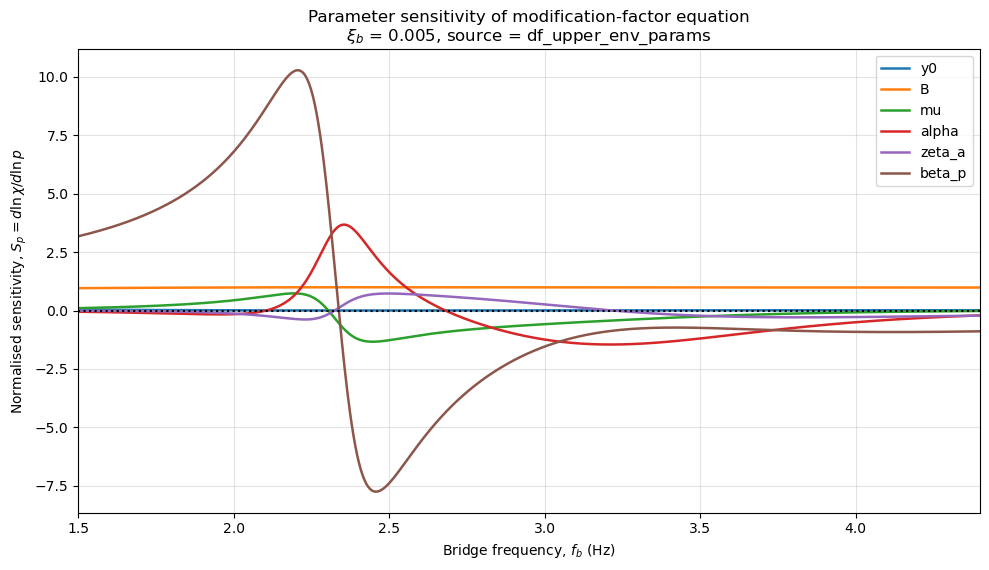

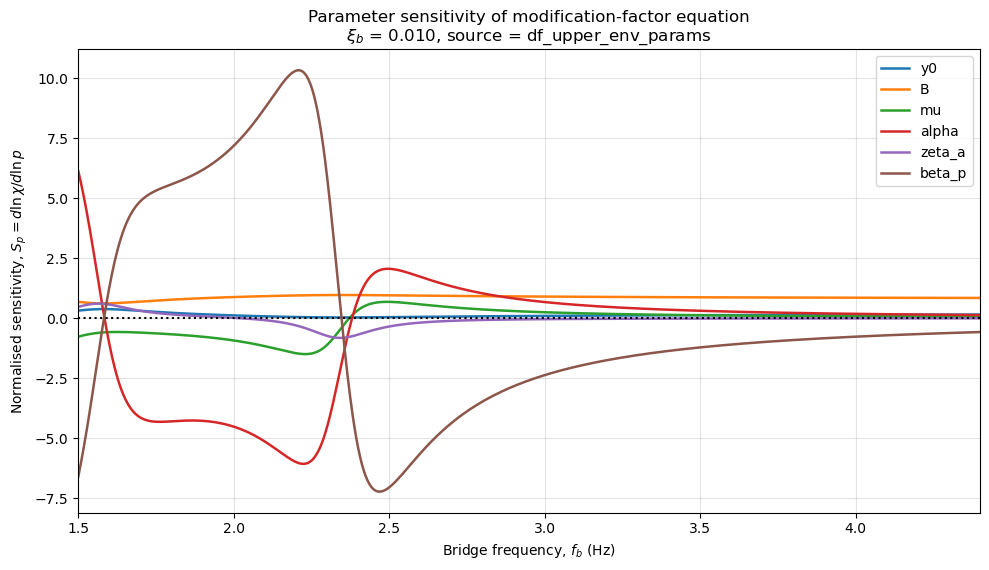

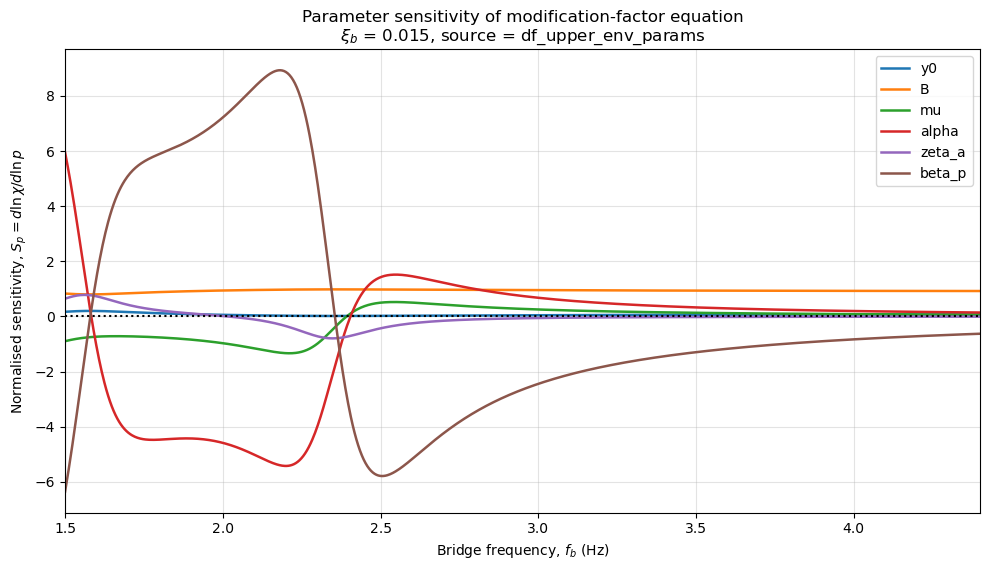

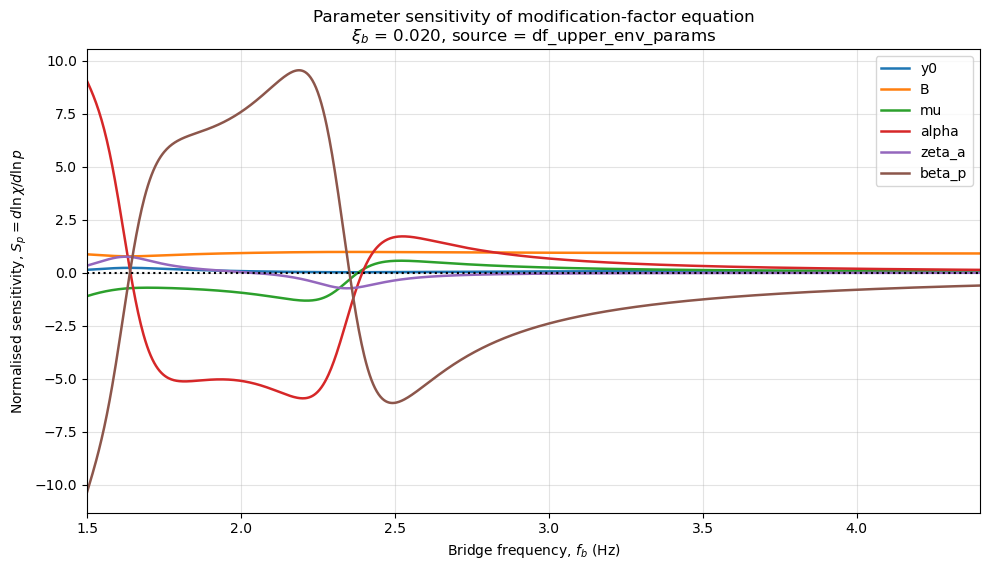


Overall importance ranking:
parameter  mean_abs_sensitivity  rms_sensitivity  max_abs_sensitivity
   beta_p              3.280278         4.246845            10.333482
    alpha              1.495829         2.236157             9.021716
        B              0.927543         0.928955             0.996736
       mu              0.414523         0.553049             1.494395
   zeta_a              0.185938         0.286885             0.819904
       y0              0.072451         0.084446             0.382505


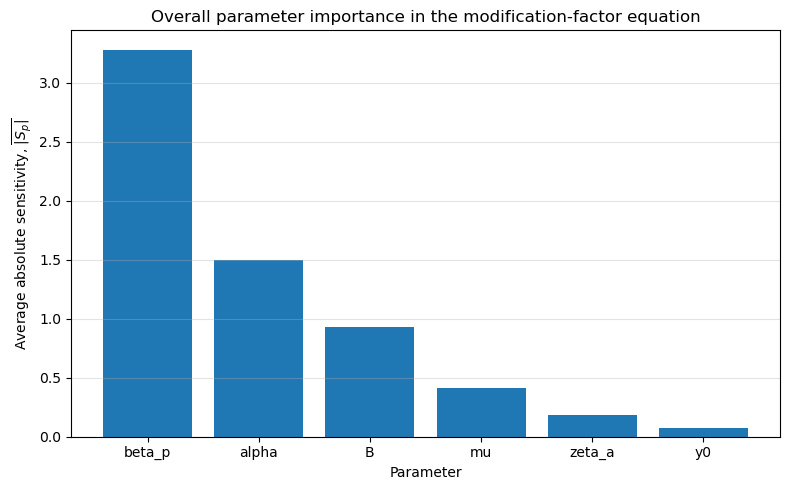

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# SETTINGS
# ==================================================

PARAM_TABLE_SOURCE = "auto"
# Options:
# PARAM_TABLE_SOURCE = "upper_env"
# PARAM_TABLE_SOURCE = "best_anchor"
# PARAM_TABLE_SOURCE = "manual"
# PARAM_TABLE_SOURCE = "fit_params"
# PARAM_TABLE_SOURCE = "auto"

PERTURBATION = 0.01
# 0.01 = plus/minus 1% perturbation

FMIN = 1.50
FMAX = 4.40
N_FREQ = 1000

PARAMS_TO_TEST = ["y0", "B", "mu", "alpha", "zeta_a", "beta_p"]

INCLUDE_F_P = False
# Set True only if you want to test sensitivity to peak location.
# But for your current final model f_p is fixed at 2.25 Hz.

SAVE_RESULTS = True


# ==================================================
# CHOOSE PARAMETER TABLE
# ==================================================

if PARAM_TABLE_SOURCE == "auto":

    if "df_upper_env_params" in globals() and not df_upper_env_params.empty:
        param_df = df_upper_env_params.copy()
        source_name = "df_upper_env_params"

    elif "df_best_params" in globals() and not df_best_params.empty:
        param_df = df_best_params.copy()
        source_name = "df_best_params"

    elif "df_manual_params" in globals() and not df_manual_params.empty:
        param_df = df_manual_params.copy()
        source_name = "df_manual_params"

    elif "df_fit_params" in globals() and not df_fit_params.empty:
        param_df = df_fit_params.copy()
        source_name = "df_fit_params"

    else:
        raise ValueError("No suitable parameter dataframe found.")

elif PARAM_TABLE_SOURCE == "upper_env":
    param_df = df_upper_env_params.copy()
    source_name = "df_upper_env_params"

elif PARAM_TABLE_SOURCE == "best_anchor":
    param_df = df_best_params.copy()
    source_name = "df_best_params"

elif PARAM_TABLE_SOURCE == "manual":
    param_df = df_manual_params.copy()
    source_name = "df_manual_params"

elif PARAM_TABLE_SOURCE == "fit_params":
    param_df = df_fit_params.copy()
    source_name = "df_fit_params"

else:
    raise ValueError("Unknown PARAM_TABLE_SOURCE.")

print("Using parameter table:", source_name)

if "zeta_b" in param_df.columns and "xi_b" not in param_df.columns:
    param_df = param_df.rename(columns={"zeta_b": "xi_b"})

required_cols = ["xi_b", "y0", "B", "mu", "alpha", "zeta_a", "beta_p", "f_p"]

missing_cols = [c for c in required_cols if c not in param_df.columns]

if missing_cols:
    raise KeyError(f"Missing columns in parameter table: {missing_cols}")

for col in required_cols:
    param_df[col] = pd.to_numeric(param_df[col], errors="coerce")

param_df = param_df.dropna(subset=required_cols).copy()
param_df = param_df.sort_values("xi_b").reset_index(drop=True)

if INCLUDE_F_P:
    PARAMS_TO_TEST = PARAMS_TO_TEST + ["f_p"]


# ==================================================
# MODEL FUNCTION
# ==================================================

def chi_model_from_row(f_bridge, row):
    """
    Main modification-factor equation:
        chi = y0 + B * Q(beta_eff)
        beta_eff = beta_p * f_b / f_p
    """

    f_bridge = np.asarray(f_bridge, dtype=float)

    xi_b = float(row["xi_b"])
    y0 = float(row["y0"])
    B = float(row["B"])
    mu = float(row["mu"])
    alpha = float(row["alpha"])
    zeta_a = float(row["zeta_a"])
    beta_p = float(row["beta_p"])
    f_p = float(row["f_p"])

    beta_eff = beta_p * f_bridge / f_p

    Q_eff = Q_mmd(
        beta=beta_eff,
        mu=mu,
        alpha=alpha,
        zeta_b=xi_b,
        zeta_a=zeta_a
    )

    chi = y0 + B * Q_eff

    return chi


def perturb_row(row, param, factor):
    """
    Perturb one parameter by a multiplicative factor.
    """

    row_new = row.copy()

    row_new[param] = float(row_new[param]) * factor

    # Safety limits
    row_new["y0"] = max(float(row_new["y0"]), 1e-8)
    row_new["B"] = max(float(row_new["B"]), 1e-8)

    row_new["mu"] = np.clip(float(row_new["mu"]), 0.001, 0.50)
    row_new["alpha"] = np.clip(float(row_new["alpha"]), 0.40, 1.50)
    row_new["zeta_a"] = np.clip(float(row_new["zeta_a"]), 0.05, 2.00)
    row_new["beta_p"] = np.clip(float(row_new["beta_p"]), 0.80, 1.20)
    row_new["f_p"] = np.clip(float(row_new["f_p"]), 1.50, 4.00)

    return row_new


# ==================================================
# COMPUTE NORMALISED SENSITIVITY
# ==================================================

f_grid = np.linspace(FMIN, FMAX, N_FREQ)

sensitivity_rows = []
summary_rows = []

for _, row in param_df.iterrows():

    xi_b = float(row["xi_b"])

    chi_base = chi_model_from_row(f_grid, row)

    valid_base = np.isfinite(chi_base) & (chi_base > 0)

    for param in PARAMS_TO_TEST:

        row_plus = perturb_row(row, param, 1.0 + PERTURBATION)
        row_minus = perturb_row(row, param, 1.0 - PERTURBATION)

        chi_plus = chi_model_from_row(f_grid, row_plus)
        chi_minus = chi_model_from_row(f_grid, row_minus)

        # Normalised central-difference sensitivity:
        # S = d ln(chi) / d ln(param)
        sensitivity = (
            np.log(chi_plus) - np.log(chi_minus)
        ) / (
            np.log(1.0 + PERTURBATION) - np.log(1.0 - PERTURBATION)
        )

        valid = (
            valid_base &
            np.isfinite(chi_plus) &
            np.isfinite(chi_minus) &
            np.isfinite(sensitivity)
        )

        for f, s in zip(f_grid[valid], sensitivity[valid]):
            sensitivity_rows.append({
                "xi_b": xi_b,
                "parameter": param,
                "bridge_frequency": f,
                "sensitivity": s,
                "abs_sensitivity": abs(s),
            })

        s_valid = sensitivity[valid]
        f_valid = f_grid[valid]

        if len(s_valid) > 0:
            idx_max = np.argmax(np.abs(s_valid))

            summary_rows.append({
                "xi_b": xi_b,
                "parameter": param,
                "mean_abs_sensitivity": np.mean(np.abs(s_valid)),
                "rms_sensitivity": np.sqrt(np.mean(s_valid**2)),
                "max_abs_sensitivity": np.max(np.abs(s_valid)),
                "frequency_at_max_abs": f_valid[idx_max],
                "signed_sensitivity_at_max_abs": s_valid[idx_max],
            })


sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_summary_df = pd.DataFrame(summary_rows)

sensitivity_summary_df = sensitivity_summary_df.sort_values(
    ["xi_b", "mean_abs_sensitivity"],
    ascending=[True, False]
).reset_index(drop=True)

print("\nSensitivity summary:")
print(sensitivity_summary_df.to_string(index=False))

if SAVE_RESULTS:
    sensitivity_df.to_csv("parameter_sensitivity_curves.csv", index=False)
    sensitivity_summary_df.to_csv("parameter_sensitivity_summary.csv", index=False)

    print("\nSaved:")
    print("parameter_sensitivity_curves.csv")
    print("parameter_sensitivity_summary.csv")


# ==================================================
# PLOT SENSITIVITY CURVES
# One figure per damping ratio
# ==================================================

for xi_b in sorted(sensitivity_df["xi_b"].unique()):

    sub_xi = sensitivity_df[
        np.isclose(sensitivity_df["xi_b"], xi_b)
    ].copy()

    plt.figure(figsize=(10, 5.8))

    for param in PARAMS_TO_TEST:

        sub = sub_xi[sub_xi["parameter"] == param].copy()

        if sub.empty:
            continue

        sub = sub.sort_values("bridge_frequency")

        plt.plot(
            sub["bridge_frequency"],
            sub["sensitivity"],
            linewidth=1.8,
            label=param
        )

    plt.axhline(
        0.0,
        linestyle=":",
        linewidth=1.5,
        color="black"
    )

    plt.xlabel(r"Bridge frequency, $f_b$ (Hz)")
    plt.ylabel(r"Normalised sensitivity, $S_p = d\ln\chi / d\ln p$")

    plt.title(
        "Parameter sensitivity of modification-factor equation\n"
        rf"$\xi_b$ = {xi_b:.3f}, source = {source_name}"
    )

    plt.xlim(FMIN, FMAX)
    plt.grid(True, alpha=0.35)
    plt.legend(loc="best")

    plt.tight_layout()
    plt.show()


# ==================================================
# BAR PLOT: OVERALL IMPORTANCE RANKING
# Average over all damping ratios and frequencies
# ==================================================

importance_df = (
    sensitivity_summary_df
    .groupby("parameter", as_index=False)
    .agg(
        mean_abs_sensitivity=("mean_abs_sensitivity", "mean"),
        rms_sensitivity=("rms_sensitivity", "mean"),
        max_abs_sensitivity=("max_abs_sensitivity", "max"),
    )
    .sort_values("mean_abs_sensitivity", ascending=False)
)

print("\nOverall importance ranking:")
print(importance_df.to_string(index=False))

plt.figure(figsize=(8, 5))

plt.bar(
    importance_df["parameter"],
    importance_df["mean_abs_sensitivity"]
)

plt.xlabel("Parameter")
plt.ylabel(r"Average absolute sensitivity, $\overline{|S_p|}$")

plt.title(
    "Overall parameter importance in the modification-factor equation"
)

plt.grid(True, axis="y", alpha=0.35)
plt.tight_layout()
plt.show()


Loaded rho > 1 / density 1.0000 lm files:
Combined shape: (4347, 40)
Dampings: [np.float64(0.005), np.float64(0.01), np.float64(0.015), np.float64(0.02)]
Linear masses: [np.int64(483), np.int64(500), np.int64(580), np.int64(725), np.int64(750), np.int64(967), np.int64(1000), np.int64(1450), np.int64(1500), np.int64(2000), np.int64(2900)]

Piecewise fitting for damping = 0.005
Fitted parameters:
chi_low    = 0.067216
chi_peak   = 0.628747
n_left     = 4.334226
chi_inf    = 0.124821
c_right    = 2.908596
bump_amp   = 0.031958


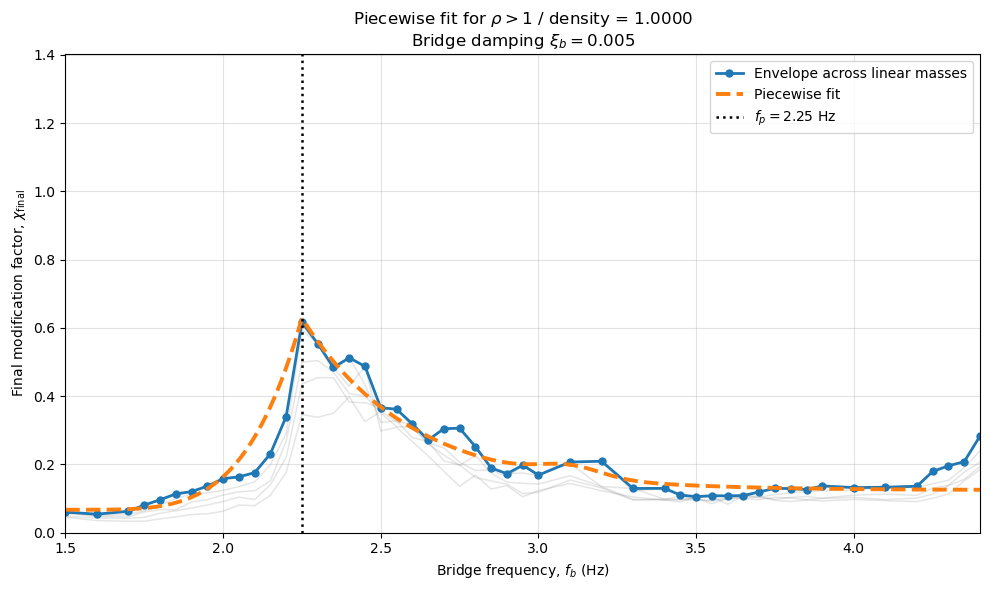


Piecewise fitting for damping = 0.010
Fitted parameters:
chi_low    = 0.126606
chi_peak   = 1.154665
n_left     = 3.924698
chi_inf    = 0.218159
c_right    = 2.687353
bump_amp   = 0.086914


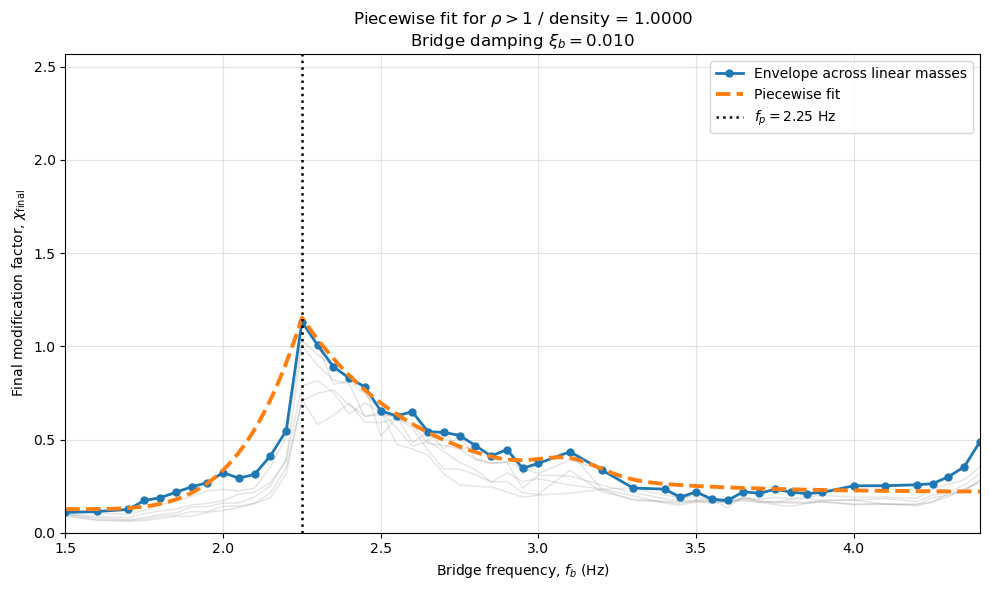


Piecewise fitting for damping = 0.015
Fitted parameters:
chi_low    = 0.202241
chi_peak   = 1.588241
n_left     = 4.885624
chi_inf    = 0.294463
c_right    = 2.588992
bump_amp   = 0.117041


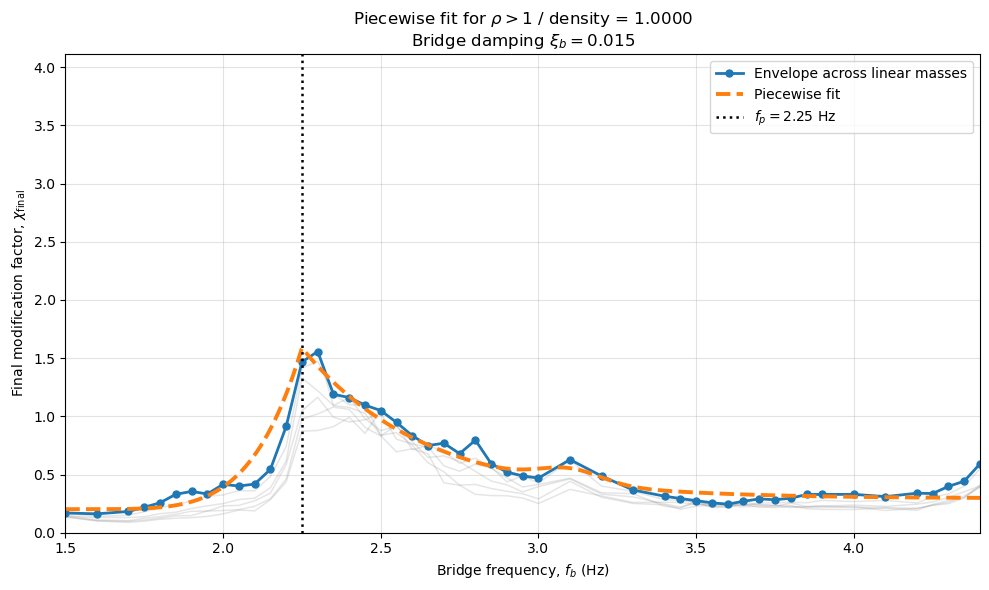


Piecewise fitting for damping = 0.020
Fitted parameters:
chi_low    = 0.297044
chi_peak   = 1.958481
n_left     = 7.395360
chi_inf    = 0.354855
c_right    = 2.429934
bump_amp   = 0.156361


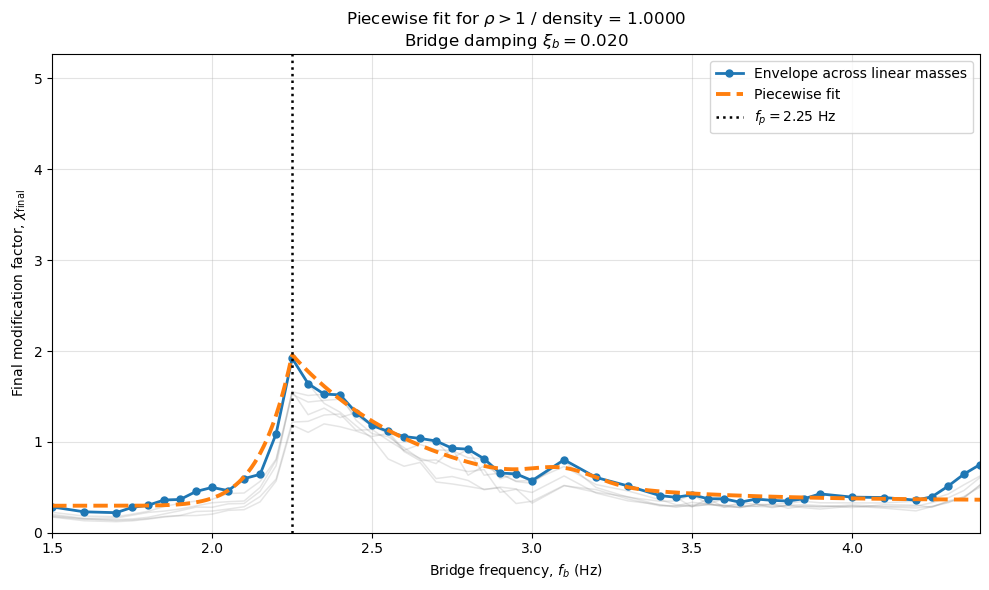


PIECEWISE PARAMETER TABLE FOR rho > 1
 damping  chi_low  chi_peak   n_left  chi_inf  c_right  bump_amp  f_p  f_peak_data  chi_peak_data  left_success  right_success  n_fit_points
   0.005 0.067216  0.628747 4.334226 0.124821 2.908596  0.031958 2.25         2.25       0.616419          True           True            50
   0.010 0.126606  1.154665 3.924698 0.218159 2.687353  0.086914 2.25         2.25       1.132024          True           True            50
   0.015 0.202241  1.588241 4.885624 0.294463 2.588992  0.117041 2.25         2.30       1.557099          True           True            50
   0.020 0.297044  1.958481 7.395360 0.354855 2.429934  0.156361 2.25         2.25       1.920080          True           True            50

Created:
full_df_rho_gt1
piecewise_param_df_rho_gt1
piecewise_curve_df_rho_gt1


In [40]:
# ==================================================
# PIECEWISE FITTING FOR rho > 1 / density = 1.0000 LM FILES
# Loads: density1.0000_damping*_lm*_bias_summary.pkl
# Fits envelope across linear masses for each damping ratio
# ==================================================

from pathlib import Path
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DENSITY = 1.0000

Y_COL = "final_modification_factor"

FIT_FMIN = 1.50
FIT_FMAX = 4.40

PLOT_FMIN = 1.50
PLOT_FMAX = 4.40

F_TARGET_PEAK = 2.25

SAFETY_MARGIN = 1.02

USE_RIGHT_BUMP = True
BUMP_CENTER = 3.10
BUMP_WIDTH = 0.10

eps = 1e-12

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"lm(?P<linear_mass>\d+)_"
    r"bias_summary\.pkl$"
)

# ==================================================
# LOAD PKL FILES
# ==================================================

def extract_dataframe_from_pickle(obj):
    """
    Handles either direct DataFrame pkl or dict containing a DataFrame.
    """

    if isinstance(obj, pd.DataFrame):
        return obj.copy()

    if isinstance(obj, dict):
        for key in [
            "summary_df",
            "bias_summary_df",
            "results_df",
            "plot_df",
            "df",
            "data",
        ]:
            if key in obj and isinstance(obj[key], pd.DataFrame):
                return obj[key].copy()

        # fallback: first DataFrame inside dict
        for value in obj.values():
            if isinstance(value, pd.DataFrame):
                return value.copy()

    raise TypeError("Could not find a DataFrame inside this pickle file.")


all_rows = []

for file in sorted(folder.glob("density*_damping*_lm*_bias_summary.pkl")):

    m = pattern.match(file.name)
    if m is None:
        continue

    density = float(m.group("density"))
    damping = float(m.group("damping"))
    linear_mass = int(m.group("linear_mass"))

    if not np.isclose(density, TARGET_DENSITY):
        continue

    with open(file, "rb") as f:
        obj = pickle.load(f)

    df = extract_dataframe_from_pickle(obj)

    df["source_file"] = file.name
    df["target_density"] = density
    df["target_beamdamp"] = damping
    df["linear_mass_key"] = linear_mass

    all_rows.append(df)

if len(all_rows) == 0:
    raise FileNotFoundError("No density1.0000 damping lm bias_summary.pkl files found.")

full_df_rho_gt1 = pd.concat(all_rows, ignore_index=True)

print("\nLoaded rho > 1 / density 1.0000 lm files:")
print("Combined shape:", full_df_rho_gt1.shape)
print("Dampings:", sorted(full_df_rho_gt1["target_beamdamp"].round(3).unique()))
print("Linear masses:", sorted(full_df_rho_gt1["linear_mass_key"].unique()))

# ==================================================
# CLEAN DATA
# ==================================================

required_cols = [
    "bridge_frequency",
    "target_beamdamp",
    "target_density",
    "linear_mass_key",
    Y_COL,
]

missing_cols = [c for c in required_cols if c not in full_df_rho_gt1.columns]
if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

for col in ["bridge_frequency", "target_beamdamp", "target_density", "linear_mass_key", Y_COL]:
    full_df_rho_gt1[col] = pd.to_numeric(full_df_rho_gt1[col], errors="coerce")

full_df_rho_gt1 = full_df_rho_gt1.dropna(subset=required_cols).copy()

# ==================================================
# PIECEWISE FIT FUNCTION
# ==================================================

def fit_piecewise_for_one_damping_rho_gt1(df_all, damping_to_fit):

    df = df_all[
        np.isclose(df_all["target_beamdamp"], damping_to_fit)
    ].copy()

    if df.empty:
        raise ValueError(f"No data found for damping = {damping_to_fit}")

    df["freq_key"] = df["bridge_frequency"].round(6)

    # One value per frequency and linear mass
    df_unique = df.drop_duplicates(
        subset=["freq_key", "linear_mass_key"],
        keep="first"
    ).copy()

    # Envelope across linear masses
    env_df = (
        df_unique
        .groupby("freq_key", as_index=False)
        .agg(
            bridge_frequency=("bridge_frequency", "mean"),
            y_env=(Y_COL, "max")
        )
        .sort_values("bridge_frequency")
    )

    fit_df = env_df[
        (env_df["bridge_frequency"] >= FIT_FMIN) &
        (env_df["bridge_frequency"] <= FIT_FMAX)
    ].copy()

    x_fit = fit_df["bridge_frequency"].to_numpy()
    y_fit = fit_df["y_env"].to_numpy()

    if len(x_fit) < 8:
        raise ValueError(f"Too few fitting points for damping = {damping_to_fit}")

    # --------------------------------------------------
    # Peak value fixed near target peak
    # --------------------------------------------------
    peak_window = fit_df[
        np.abs(fit_df["bridge_frequency"] - F_TARGET_PEAK) <= 0.05
    ].copy()

    if not peak_window.empty:
        chi_peak_data = peak_window["y_env"].max()
        f_peak_data = peak_window.loc[
            peak_window["y_env"].idxmax(),
            "bridge_frequency"
        ]
    else:
        peak_idx = np.argmin(np.abs(x_fit - F_TARGET_PEAK))
        chi_peak_data = y_fit[peak_idx]
        f_peak_data = x_fit[peak_idx]

    CHI_PEAK = SAFETY_MARGIN * chi_peak_data

    # --------------------------------------------------
    # Piecewise models
    # --------------------------------------------------
    def chi_left_model(f_bridge, chi_low, n_left):
        f_bridge = np.asarray(f_bridge, dtype=float)

        t = (f_bridge - FIT_FMIN) / (F_TARGET_PEAK - FIT_FMIN)
        t = np.clip(t, 0.0, 1.0)

        return chi_low + (CHI_PEAK - chi_low) * t**n_left

    def chi_right_model(f_bridge, chi_inf, c_right, bump_amp=0.0):
        f_bridge = np.asarray(f_bridge, dtype=float)

        d = np.maximum(f_bridge - F_TARGET_PEAK, 0.0)

        base = chi_inf + (CHI_PEAK - chi_inf) * np.exp(-c_right * d)

        if USE_RIGHT_BUMP:
            g = np.exp(-0.5 * ((f_bridge - BUMP_CENTER) / BUMP_WIDTH)**2)
            g0 = np.exp(-0.5 * ((F_TARGET_PEAK - BUMP_CENTER) / BUMP_WIDTH)**2)

            bump_shape = np.maximum(g - g0, 0.0)

            return base + bump_amp * bump_shape

        return base

    def chi_piecewise_model(f_bridge, chi_low, n_left, chi_inf, c_right, bump_amp):
        f_bridge = np.asarray(f_bridge, dtype=float)

        y = np.zeros_like(f_bridge, dtype=float)

        left_mask = f_bridge <= F_TARGET_PEAK
        right_mask = f_bridge > F_TARGET_PEAK

        y[left_mask] = chi_left_model(
            f_bridge[left_mask],
            chi_low=chi_low,
            n_left=n_left
        )

        y[right_mask] = chi_right_model(
            f_bridge[right_mask],
            chi_inf=chi_inf,
            c_right=c_right,
            bump_amp=bump_amp
        )

        return y

    # --------------------------------------------------
    # Left-side fit
    # --------------------------------------------------
    left_df = fit_df[fit_df["bridge_frequency"] <= F_TARGET_PEAK].copy()
    right_df = fit_df[fit_df["bridge_frequency"] >= F_TARGET_PEAK].copy()

    x_left = left_df["bridge_frequency"].to_numpy()
    y_left = left_df["y_env"].to_numpy()

    x_right = right_df["bridge_frequency"].to_numpy()
    y_right = right_df["y_env"].to_numpy()

    if len(x_left) < 3:
        raise ValueError(f"Too few left-side points for damping = {damping_to_fit}")

    if len(x_right) < 4:
        raise ValueError(f"Too few right-side points for damping = {damping_to_fit}")

    def residuals_left(p):
        chi_low, n_left = p

        y_model = chi_left_model(
            x_left,
            chi_low=chi_low,
            n_left=n_left
        )

        if np.any(y_model <= 0):
            return 1e6 * np.ones_like(y_left)

        return np.log(y_model + eps) - np.log(y_left + eps)

    chi_low0 = max(np.nanmin(y_left), 1e-6)
    chi_low0 = min(chi_low0, 0.95 * CHI_PEAK)

    p0_left = np.array([chi_low0, 3.0])

    lower_left = np.array([0.0, 0.80])
    upper_left = np.array([0.999 * CHI_PEAK, 12.0])

    result_left = least_squares(
        residuals_left,
        p0_left,
        bounds=(lower_left, upper_left),
        loss="soft_l1",
        f_scale=0.1,
        max_nfev=50000
    )

    chi_low_fit, n_left_fit = result_left.x

    # --------------------------------------------------
    # Right-side fit
    # --------------------------------------------------
    def residuals_right(p):

        if USE_RIGHT_BUMP:
            chi_inf, c_right, bump_amp = p
        else:
            chi_inf, c_right = p
            bump_amp = 0.0

        y_model = chi_right_model(
            x_right,
            chi_inf=chi_inf,
            c_right=c_right,
            bump_amp=bump_amp
        )

        if np.any(y_model <= 0):
            return 1e6 * np.ones_like(y_right)

        res = np.log(y_model + eps) - np.log(y_right + eps)

        weight_peak_shoulder = np.where(
            (x_right >= 2.25) & (x_right <= 3.10),
            1.50,
            1.00
        )

        return weight_peak_shoulder * res

    chi_inf0 = max(np.nanmin(y_right), 1e-6)
    chi_inf0 = min(chi_inf0, 0.95 * CHI_PEAK)

    c_right0 = 2.0

    if USE_RIGHT_BUMP:
        bump_amp0 = max(0.0, np.nanmax(y_right) - CHI_PEAK)
        p0_right = np.array([chi_inf0, c_right0, bump_amp0])

        lower_right = np.array([0.0, 0.05, 0.0])
        upper_right = np.array([0.999 * CHI_PEAK, 20.0, 5.0 * CHI_PEAK])
    else:
        p0_right = np.array([chi_inf0, c_right0])

        lower_right = np.array([0.0, 0.05])
        upper_right = np.array([0.999 * CHI_PEAK, 20.0])

    result_right = least_squares(
        residuals_right,
        p0_right,
        bounds=(lower_right, upper_right),
        loss="soft_l1",
        f_scale=0.1,
        max_nfev=50000
    )

    if USE_RIGHT_BUMP:
        chi_inf_fit, c_right_fit, bump_amp_fit = result_right.x
    else:
        chi_inf_fit, c_right_fit = result_right.x
        bump_amp_fit = 0.0

    # --------------------------------------------------
    # Smooth fitted curve
    # --------------------------------------------------
    x_smooth = np.linspace(PLOT_FMIN, PLOT_FMAX, 1500)

    y_smooth = chi_piecewise_model(
        x_smooth,
        chi_low=chi_low_fit,
        n_left=n_left_fit,
        chi_inf=chi_inf_fit,
        c_right=c_right_fit,
        bump_amp=bump_amp_fit
    )

    param_row = {
        "damping": damping_to_fit,
        "chi_low": chi_low_fit,
        "chi_peak": CHI_PEAK,
        "n_left": n_left_fit,
        "chi_inf": chi_inf_fit,
        "c_right": c_right_fit,
        "bump_amp": bump_amp_fit,
        "f_p": F_TARGET_PEAK,
        "f_peak_data": f_peak_data,
        "chi_peak_data": chi_peak_data,
        "left_success": result_left.success,
        "right_success": result_right.success,
        "n_fit_points": len(fit_df),
    }

    curve_df = pd.DataFrame({
        "damping": damping_to_fit,
        "bridge_frequency": x_smooth,
        "chi_piecewise": y_smooth,
    })

    return param_row, curve_df, df_unique, env_df

# ==================================================
# LOOP OVER DAMPING RATIOS
# ==================================================

piecewise_param_rows = []
piecewise_curve_rows = []

damping_values = sorted(full_df_rho_gt1["target_beamdamp"].dropna().unique())

for damping in damping_values:

    print("\n" + "=" * 80)
    print(f"Piecewise fitting for damping = {damping:.3f}")
    print("=" * 80)

    try:
        param_row, curve_df, data_df, env_df = fit_piecewise_for_one_damping_rho_gt1(
            full_df_rho_gt1,
            damping
        )

    except Exception as e:
        print(f"FAILED for damping = {damping:.3f}: {e}")
        continue

    piecewise_param_rows.append(param_row)
    piecewise_curve_rows.append(curve_df)

    print("Fitted parameters:")
    for key in ["chi_low", "chi_peak", "n_left", "chi_inf", "c_right", "bump_amp"]:
        print(f"{key:10s} = {param_row[key]:.6f}")

    # --------------------------------------------------
    # Plot original data + envelope + piecewise fit
    # --------------------------------------------------
    plt.figure(figsize=(10, 6))

    for lm in sorted(data_df["linear_mass_key"].dropna().unique()):

        sub = data_df[data_df["linear_mass_key"] == lm].copy()
        sub = sub.sort_values("bridge_frequency")

        plt.plot(
            sub["bridge_frequency"],
            sub[Y_COL],
            linewidth=1.1,
            alpha=0.20,
            color="gray"
        )

    plt.plot(
        env_df["bridge_frequency"],
        env_df["y_env"],
        "o-",
        linewidth=2.0,
        markersize=5,
        color="#1f77b4",
        label="Envelope across linear masses"
    )

    plt.plot(
        curve_df["bridge_frequency"],
        curve_df["chi_piecewise"],
        "--",
        linewidth=2.8,
        color="#ff7f0e",
        label="Piecewise fit"
    )

    plt.axvline(
        F_TARGET_PEAK,
        linestyle=":",
        linewidth=1.8,
        color="black",
        label=rf"$f_p={F_TARGET_PEAK:.2f}$ Hz"
    )

    plt.xlabel(r"Bridge frequency, $f_b$ (Hz)")
    plt.ylabel(r"Final modification factor, $\chi_{\mathrm{final}}$")

    plt.title(
        rf"Piecewise fit for $\rho>1$ / density = {TARGET_DENSITY:.4f}"
        "\n"
        rf"Bridge damping $\xi_b={damping:.3f}$"
    )

    plt.xlim(PLOT_FMIN, PLOT_FMAX)

    ymax = max(
        np.nanmax(data_df[Y_COL]),
        np.nanmax(env_df["y_env"]),
        np.nanmax(curve_df["chi_piecewise"])
    )

    plt.ylim(0, 1.15 * ymax)

    plt.grid(True, alpha=0.35)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

# ==================================================
# FINAL DATAFRAMES
# ==================================================

piecewise_param_df_rho_gt1 = pd.DataFrame(piecewise_param_rows)

if len(piecewise_curve_rows) > 0:
    piecewise_curve_df_rho_gt1 = pd.concat(piecewise_curve_rows, ignore_index=True)
else:
    piecewise_curve_df_rho_gt1 = pd.DataFrame()

print("\n" + "=" * 80)
print("PIECEWISE PARAMETER TABLE FOR rho > 1")
print("=" * 80)
print(piecewise_param_df_rho_gt1.to_string(index=False))

print("\nCreated:")
print("full_df_rho_gt1")
print("piecewise_param_df_rho_gt1")
print("piecewise_curve_df_rho_gt1")

Using parameter table: piecewise_param_df_rho_gt1


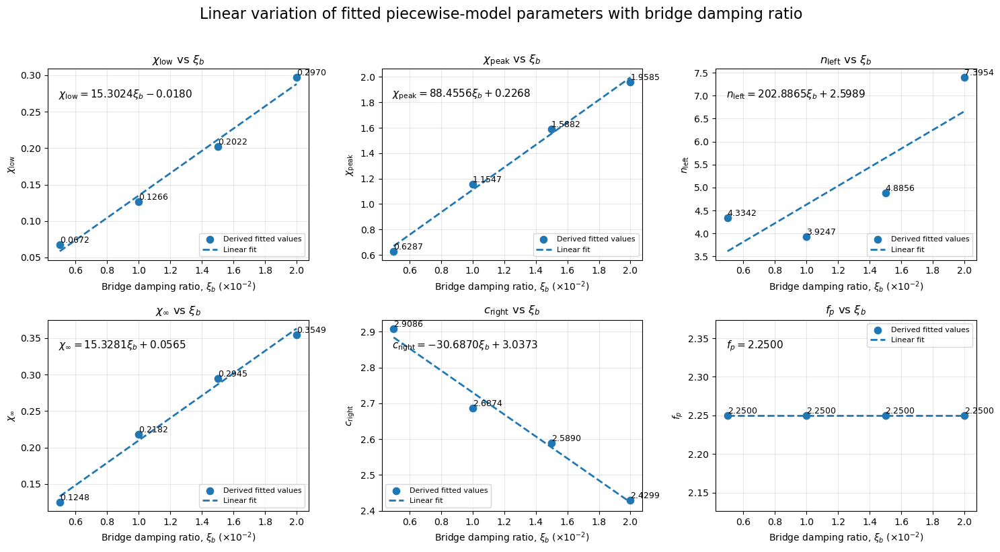


Linear parameter relationships
chi_low = 15.30241045 * xi_b + -0.01800323
chi_peak = 88.45559412 * xi_b + 0.22683858
n_left = 202.88650987 * xi_b + 2.59889570
chi_inf = 15.32809161 * xi_b + 0.05647334
c_right = -30.68697231 * xi_b + 3.03730586
f_p = -0.00000000 * xi_b + 2.25000000

Created:
linear_fits_piecewise_rho_gt1
piecewise_linear_equations_rho_gt1


In [41]:
# ==================================================
# PARAMETER VARIATION WITH DAMPING RATIO
# For rho > 1 piecewise-fitted parameters
# ==================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# CHOOSE PARAMETER TABLE
# ==================================================

if "piecewise_param_df_rho_gt1" in globals():
    param_df = piecewise_param_df_rho_gt1.copy()
    source_name = "piecewise_param_df_rho_gt1"
elif "piecewise_param_df" in globals():
    param_df = piecewise_param_df.copy()
    source_name = "piecewise_param_df"
else:
    raise NameError(
        "Could not find piecewise_param_df_rho_gt1 or piecewise_param_df. "
        "Run the piecewise fitting code first."
    )

print("Using parameter table:", source_name)

# ==================================================
# PREPARE DAMPING COLUMN
# ==================================================

if "damping" in param_df.columns:
    param_df["xi_b"] = pd.to_numeric(param_df["damping"], errors="coerce")
elif "xi_b" in param_df.columns:
    param_df["xi_b"] = pd.to_numeric(param_df["xi_b"], errors="coerce")
elif "zeta_b" in param_df.columns:
    param_df["xi_b"] = pd.to_numeric(param_df["zeta_b"], errors="coerce")
else:
    raise KeyError("Parameter dataframe must contain 'damping', 'xi_b', or 'zeta_b'.")

param_df = param_df.dropna(subset=["xi_b"]).copy()
param_df = param_df.sort_values("xi_b").reset_index(drop=True)

# x-axis shown as 0.5, 1.0, 1.5, etc.
param_df["xi_b_plot"] = param_df["xi_b"] * 100.0

# If f_p is missing, use F_TARGET_PEAK
if "f_p" not in param_df.columns:
    if "F_TARGET_PEAK" in globals():
        param_df["f_p"] = F_TARGET_PEAK
    else:
        param_df["f_p"] = 2.25

# ==================================================
# PARAMETERS TO PLOT
# ==================================================

plot_specs = [
    ("chi_low",  r"$\chi_{\mathrm{low}}$",  r"\chi_{\mathrm{low}}"),
    ("chi_peak", r"$\chi_{\mathrm{peak}}$", r"\chi_{\mathrm{peak}}"),
    ("n_left",   r"$n_{\mathrm{left}}$",    r"n_{\mathrm{left}}"),
    ("chi_inf",  r"$\chi_{\infty}$",        r"\chi_{\infty}"),
    ("c_right",  r"$c_{\mathrm{right}}$",   r"c_{\mathrm{right}}"),
    ("f_p",      r"$f_p$",                  r"f_p"),
]

missing_cols = [col for col, _, _ in plot_specs if col not in param_df.columns]

if missing_cols:
    raise KeyError(f"Missing fitted parameter columns: {missing_cols}")

# ==================================================
# CREATE SUBPLOTS
# ==================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

xi_b = param_df["xi_b"].to_numpy(dtype=float)
xi_b_plot = param_df["xi_b_plot"].to_numpy(dtype=float)

xi_smooth = np.linspace(xi_b.min(), xi_b.max(), 300)
xi_smooth_plot = xi_smooth * 100.0

linear_fits_piecewise_rho_gt1 = {}
equation_rows = []

for ax, (col, label, raw_label) in zip(axes, plot_specs):

    y = pd.to_numeric(param_df[col], errors="coerce").to_numpy(dtype=float)

    valid = np.isfinite(xi_b) & np.isfinite(y)

    xi_valid = xi_b[valid]
    xi_plot_valid = xi_b_plot[valid]
    y_valid = y[valid]

    if len(y_valid) < 2:
        ax.set_title(rf"{label} vs $\xi_b$")
        ax.text(
            0.5,
            0.5,
            "Not enough points",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=11
        )
        ax.grid(True, alpha=0.3)
        continue

    # Linear fit using real xi_b, e.g. 0.010, not percentage
    a1, a0 = np.polyfit(xi_valid, y_valid, 1)

    linear_fits_piecewise_rho_gt1[col] = {
        "slope": a1,
        "intercept": a0,
    }

    equation_rows.append({
        "parameter": col,
        "slope": a1,
        "intercept": a0,
        "equation": f"{col} = {a1:.8f} * xi_b + {a0:.8f}",
    })

    y_fit = a0 + a1 * xi_smooth

    # Original fitted parameter points
    ax.scatter(
        xi_plot_valid,
        y_valid,
        s=55,
        color="#1f77b4",
        label="Derived fitted values",
        zorder=3
    )

    # Linear fit line
    ax.plot(
        xi_smooth_plot,
        y_fit,
        "--",
        linewidth=2.0,
        color="#1f77b4",
        label="Linear fit"
    )

    # Value labels
    for xp, yp in zip(xi_plot_valid, y_valid):
        ax.text(
            xp,
            yp,
            f"{yp:.4f}",
            fontsize=9,
            ha="left",
            va="bottom"
        )

    # Equation annotation
    if abs(a1) < 1e-10:
        eq_text = rf"${raw_label} = {a0:.4f}$"
    else:
        sign = "+" if a0 >= 0 else "-"
        eq_text = rf"${raw_label} = {a1:.4f}\xi_b {sign} {abs(a0):.4f}$"

    ax.text(
        0.04,
        0.90,
        eq_text,
        transform=ax.transAxes,
        fontsize=11,
        va="top"
    )

    ax.set_title(rf"{label} vs $\xi_b$")
    ax.set_xlabel(r"Bridge damping ratio, $\xi_b$ $(\times 10^{-2})$")
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle(
    r"Linear variation of fitted piecewise-model parameters with bridge damping ratio",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

# ==================================================
# PRINT AND SAVE EQUATIONS IN MEMORY
# ==================================================

piecewise_linear_equations_rho_gt1 = pd.DataFrame(equation_rows)

print("\nLinear parameter relationships")
print("=" * 70)

for _, row in piecewise_linear_equations_rho_gt1.iterrows():
    print(row["equation"])

print("\nCreated:")
print("linear_fits_piecewise_rho_gt1")
print("piecewise_linear_equations_rho_gt1")

In [28]:
from pathlib import Path
import re
import numpy as np

folder = Path(".")

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"lm(?P<linear_mass>\d+)_"
    r"bias_summary\.pkl$"
)

files_found = []

for file in sorted(folder.glob("density*_damping*_lm*_bias_summary.pkl")):
    m = pattern.match(file.name)
    if m is None:
        continue

    density = float(m.group("density"))
    damping = float(m.group("damping"))
    lm = int(m.group("linear_mass"))

    if np.isclose(density, 1.0000):
        files_found.append((file.name, density, damping, lm))

print("All density 1 lm bias files found:")
for item in files_found:
    print(item)

print("\nDampings found:")
print(sorted(set(round(x[2], 3) for x in files_found)))

print("\nLinear masses found by damping:")
for d in sorted(set(round(x[2], 3) for x in files_found)):
    lms = sorted(x[3] for x in files_found if round(x[2], 3) == d)
    print(d, lms)

All density 1 lm bias files found:
('density1.0000_damping0.005_lm1000_bias_summary.pkl', 1.0, 0.005, 1000)
('density1.0000_damping0.005_lm1500_bias_summary.pkl', 1.0, 0.005, 1500)
('density1.0000_damping0.005_lm2000_bias_summary.pkl', 1.0, 0.005, 2000)
('density1.0000_damping0.005_lm500_bias_summary.pkl', 1.0, 0.005, 500)
('density1.0000_damping0.005_lm750_bias_summary.pkl', 1.0, 0.005, 750)
('density1.0000_damping0.010_lm1450_bias_summary.pkl', 1.0, 0.01, 1450)
('density1.0000_damping0.010_lm2900_bias_summary.pkl', 1.0, 0.01, 2900)
('density1.0000_damping0.010_lm483_bias_summary.pkl', 1.0, 0.01, 483)
('density1.0000_damping0.010_lm580_bias_summary.pkl', 1.0, 0.01, 580)
('density1.0000_damping0.010_lm725_bias_summary.pkl', 1.0, 0.01, 725)
('density1.0000_damping0.010_lm967_bias_summary.pkl', 1.0, 0.01, 967)
('density1.0000_damping0.015_lm1450_bias_summary.pkl', 1.0, 0.015, 1450)
('density1.0000_damping0.015_lm2900_bias_summary.pkl', 1.0, 0.015, 2900)
('density1.0000_damping0.015_lm483

Using equations from best_trend_info.

Using fixed peak frequency:
f_p = 2.250000 Hz

Parameter equations used in bias calculation
Using xi_b as a ratio, e.g. 0.005, 0.010, 0.015, 0.020
y0 = -0.32748523 * xi_b + 0.01971374
B = 13.14938173 * xi_b + 0.00845314
mu = 2.97095278 * xi_b + 0.18810038
alpha = -3.16022794 * xi_b + 0.59327465
zeta_a = -1.40332801 * xi_b + 0.32855795
beta_p = 0.50408401 * xi_b + 1.01764294
f_p = 2.25000000
Loading: density1.0000_damping0.005_lm1000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm1500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm2000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm750_bias_summary.pkl
Loading: density1.0000_damping0.010_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.010_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.010_lm483_bias_summary.pkl
Loading: density1.0000_damping0.010_lm580_bias_summary.pkl
Loading: density1.0000_damping0

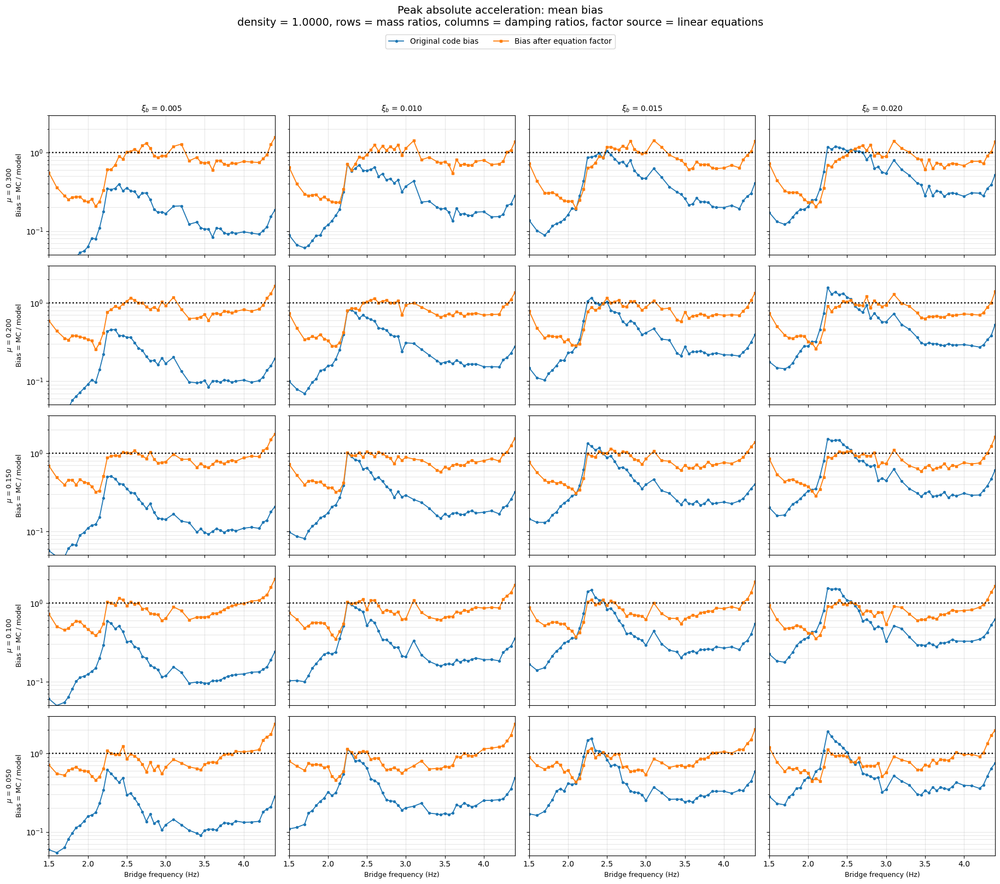

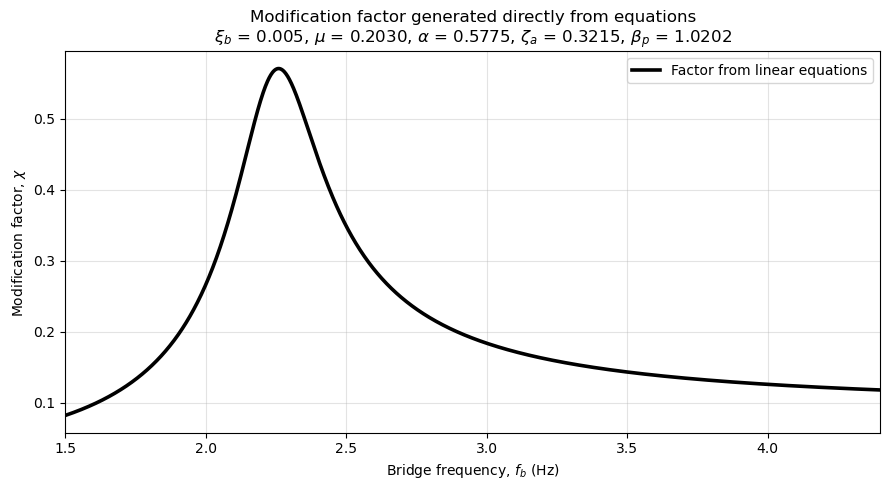

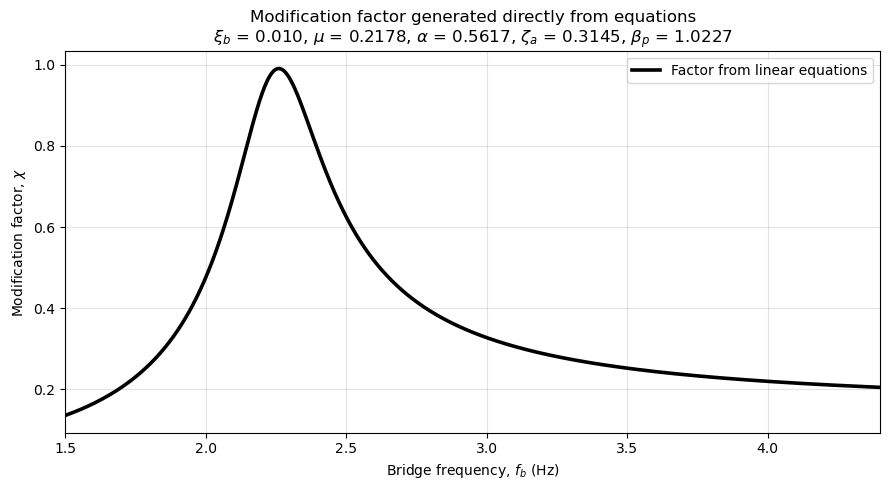

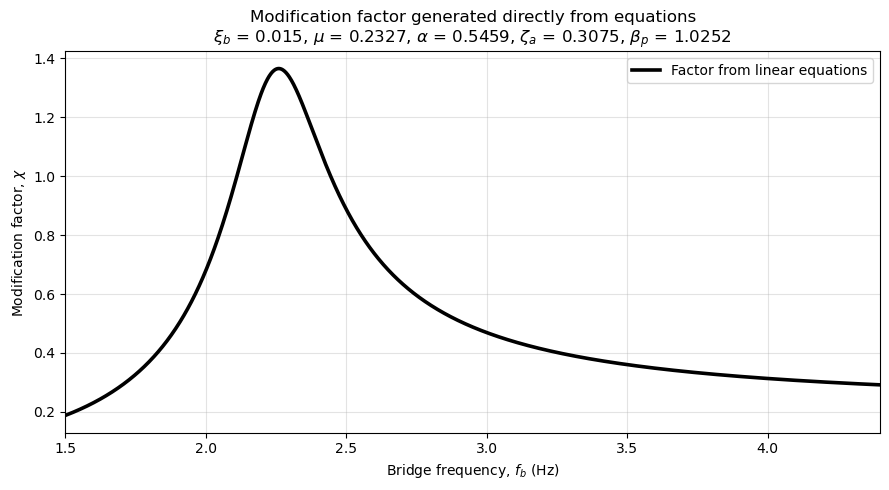

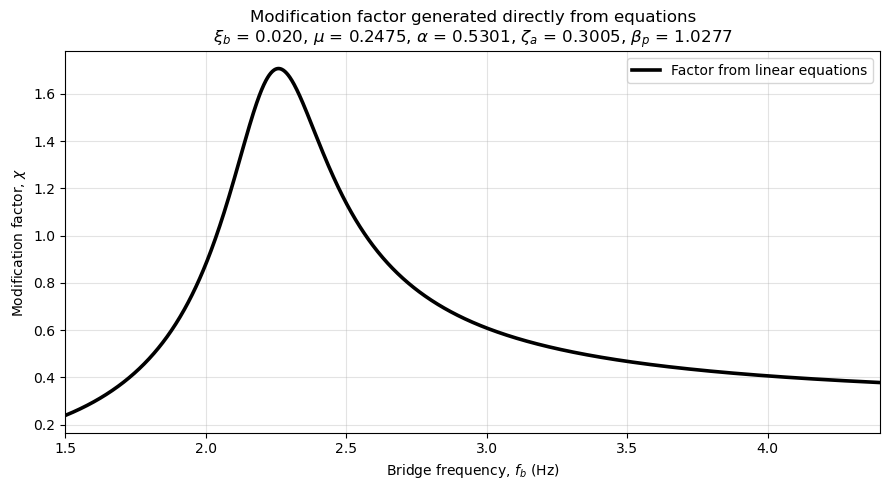

In [29]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DENSITY = 1.0000
TARGET_DAMPINGS = [0.005, 0.010, 0.015, 0.020]

MEASURE_NAME = "Peak absolute acceleration"

Y_COL_FACTOR = "final_modification_factor"

PLOT_FMIN = 1.50
PLOT_FMAX = 4.40

USE_LOG_Y = True
YMIN = 0.05
YMAX = 3.00

SAVE_PLOTS = False
EPS = 1e-12

# --------------------------------------------------
# Use beta_p equation or force beta_p = 1.0
# --------------------------------------------------

USE_BETA_P_EQUATION = True
# USE_BETA_P_EQUATION = False

# Nominal mass ratios expected in your files
TARGET_MASS_RATIOS = np.array([0.30, 0.25, 0.20, 0.15, 0.10, 0.05])


# ==================================================
# BUILD PARAMETER EQUATIONS
# ==================================================
# This first tries to use best_trend_info from the
# objective-selected anchor code.
#
# If best_trend_info does not exist, manually fill
# PARAM_EQUATIONS below using the equations printed earlier.
# ==================================================

PARAM_EQUATIONS = {}

if "best_trend_info" in globals():

    print("Using equations from best_trend_info.")

    for param in ["y0", "B", "mu", "alpha", "zeta_a", "beta_p"]:

        if param not in best_trend_info:
            raise KeyError(f"{param} not found in best_trend_info.")

        info = best_trend_info[param]

        PARAM_EQUATIONS[param] = {
            "slope": float(info["slope"]),
            "intercept": float(info["intercept"]),
            "method": info.get("method", "unknown"),
        }

elif "df_manual_equations" in globals():

    print("Using equations from df_manual_equations.")

    required_eq_cols = ["parameter", "slope_per_ratio", "intercept"]

    missing_eq_cols = [
        col for col in required_eq_cols
        if col not in df_manual_equations.columns
    ]

    if missing_eq_cols:
        raise KeyError(f"Missing columns in df_manual_equations: {missing_eq_cols}")

    for param in ["y0", "B", "mu", "alpha", "zeta_a", "beta_p"]:

        row = df_manual_equations[
            df_manual_equations["parameter"] == param
        ]

        if row.empty:
            raise KeyError(f"{param} not found in df_manual_equations.")

        row = row.iloc[0]

        PARAM_EQUATIONS[param] = {
            "slope": float(row["slope_per_ratio"]),
            "intercept": float(row["intercept"]),
            "method": "from_df_manual_equations",
        }

else:

    raise ValueError(
        "No equation source found.\n"
        "Run the objective-selected anchor code first so best_trend_info exists,\n"
        "or run the manual-equation code so df_manual_equations exists."
    )


# ==================================================
# FIXED PEAK FREQUENCY
# ==================================================

if "F_TARGET_PEAK" in globals():
    F_P_FIXED = float(F_TARGET_PEAK)
else:
    F_P_FIXED = 2.25

print("\nUsing fixed peak frequency:")
print(f"f_p = {F_P_FIXED:.6f} Hz")


# ==================================================
# PRINT EQUATIONS BEING USED
# ==================================================

print("\nParameter equations used in bias calculation")
print("Using xi_b as a ratio, e.g. 0.005, 0.010, 0.015, 0.020")
print("=" * 80)

for param in ["y0", "B", "mu", "alpha", "zeta_a", "beta_p"]:
    m = PARAM_EQUATIONS[param]["slope"]
    c = PARAM_EQUATIONS[param]["intercept"]
    print(f"{param} = {m:.8f} * xi_b + {c:.8f}")

print(f"f_p = {F_P_FIXED:.8f}")
print("=" * 80)


# ==================================================
# PARAMETER FUNCTION FROM EQUATIONS
# ==================================================

def params_from_equations(xi_b):
    """
    Evaluate linear parameter equations at a given xi_b.
    xi_b must be a damping ratio, e.g. 0.005, not 0.5%.
    """

    xi_b = float(xi_b)

    y0 = (
        PARAM_EQUATIONS["y0"]["slope"] * xi_b
        + PARAM_EQUATIONS["y0"]["intercept"]
    )

    B = (
        PARAM_EQUATIONS["B"]["slope"] * xi_b
        + PARAM_EQUATIONS["B"]["intercept"]
    )

    mu = (
        PARAM_EQUATIONS["mu"]["slope"] * xi_b
        + PARAM_EQUATIONS["mu"]["intercept"]
    )

    alpha = (
        PARAM_EQUATIONS["alpha"]["slope"] * xi_b
        + PARAM_EQUATIONS["alpha"]["intercept"]
    )

    zeta_a = (
        PARAM_EQUATIONS["zeta_a"]["slope"] * xi_b
        + PARAM_EQUATIONS["zeta_a"]["intercept"]
    )

    beta_p = (
        PARAM_EQUATIONS["beta_p"]["slope"] * xi_b
        + PARAM_EQUATIONS["beta_p"]["intercept"]
    )

    if not USE_BETA_P_EQUATION:
        beta_p = 1.0

    # Safety clipping
    y0 = max(y0, 1e-8)
    B = max(B, 1e-8)

    mu = np.clip(mu, 0.001, 0.50)
    alpha = np.clip(alpha, 0.50, 1.50)
    zeta_a = np.clip(zeta_a, 0.30, 2.00)
    beta_p = np.clip(beta_p, 0.80, 1.20)

    return {
        "y0": y0,
        "B": B,
        "mu": mu,
        "alpha": alpha,
        "zeta_a": zeta_a,
        "beta_p": beta_p,
        "f_p": F_P_FIXED,
    }


# ==================================================
# EQUATION-BASED MODIFICATION FACTOR
# ==================================================

def chi_from_equations(f_bridge, xi_b):
    """
    Compute chi(f_b, xi_b) directly from the derived parameter equations.
    Requires Q_mmd to already exist in notebook memory.
    """

    if "Q_mmd" not in globals():
        raise NameError(
            "Q_mmd is not defined. Run the fitting code that defines Q_mmd first."
        )

    p = params_from_equations(xi_b)

    f_bridge = np.asarray(f_bridge, dtype=float)

    beta_eff = p["beta_p"] * (f_bridge / p["f_p"])

    Q_eff = Q_mmd(
        beta=beta_eff,
        mu=p["mu"],
        alpha=p["alpha"],
        zeta_b=xi_b,
        zeta_a=p["zeta_a"]
    )

    chi = p["y0"] + p["B"] * Q_eff

    return np.maximum(chi, EPS)


# ==================================================
# MASS RATIO HELPERS
# ==================================================

LM_TO_MU = {
    # damping 0.005 files
    500:  0.30,
    750:  0.20,
    1000: 0.15,
    1500: 0.10,
    2000: 0.05,

    # damping 0.010, 0.015, 0.020 files
    483:  0.30,
    580:  0.25,
    725:  0.20,
    967:  0.15,
    1450: 0.10,
    2900: 0.05,
}

def snap_to_nominal_mu(mu):
    mu = float(mu)
    return float(TARGET_MASS_RATIOS[np.argmin(np.abs(TARGET_MASS_RATIOS - mu))])


def infer_file_mass_ratio(df, linear_mass):
    lm = int(round(float(linear_mass)))

    if lm in LM_TO_MU:
        return LM_TO_MU[lm]

    raise ValueError(
        f"Linear mass {lm} is not in LM_TO_MU. "
        "Add its intended mass ratio to the mapping."
    )


# ==================================================
# LOAD ALL DENSITY = 1 lm BIAS FILES
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"lm(?P<linear_mass>\d+)_"
    r"bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_lm*_bias_summary.pkl"))

all_dfs = []
loaded_files = []

for file in pkl_files:

    match = pattern.match(file.name)

    if match is None:
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_linear_mass = int(match.group("linear_mass"))

    if not np.isclose(file_density, TARGET_DENSITY):
        continue

    if not any(np.isclose(file_damping, d) for d in TARGET_DAMPINGS):
        continue

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    file_mu_raw = infer_file_mass_ratio(df, file_linear_mass)
    file_mu_key = snap_to_nominal_mu(file_mu_raw)

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["linear_mass"] = file_linear_mass
    df["mass_ratio_raw"] = file_mu_raw
    df["mass_ratio_key"] = file_mu_key

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)
    loaded_files.append(file.name)

if len(all_dfs) == 0:
    raise FileNotFoundError(
        "No matching density=1 lm bias summary PKL files were loaded."
    )

combined_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded combined dataframe shape:", combined_df.shape)


# ==================================================
# CLEAN DATA
# ==================================================

num_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "linear_mass",
    "mass_ratio_raw",
    "mass_ratio_key",
    Y_COL_FACTOR,
    "code_bias_mean",
    "corrected_bias_mean",
]

for col in num_cols:
    if col in combined_df.columns:
        combined_df[col] = pd.to_numeric(combined_df[col], errors="coerce")

required_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "linear_mass",
    "mass_ratio_key",
    Y_COL_FACTOR,
    "measure",
    "code_bias_mean",
    "corrected_bias_mean",
]

missing = [c for c in required_cols if c not in combined_df.columns]

if missing:
    raise KeyError(f"Missing required columns: {missing}")

combined_df = combined_df.dropna(subset=required_cols).copy()

combined_df["density_key"] = combined_df["target_density"].round(4)
combined_df["damping_key"] = combined_df["target_beamdamp"].round(3)
combined_df["linear_mass_key"] = combined_df["linear_mass"].round(0).astype(int)

combined_df = combined_df[
    (combined_df["bridge_frequency"] >= PLOT_FMIN) &
    (combined_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

combined_df = combined_df[
    combined_df["measure"].astype(str) == MEASURE_NAME
].copy()

if combined_df.empty:
    raise ValueError(f"No rows found for measure: {MEASURE_NAME}")


# ==================================================
# DIAGNOSTIC TABLE
# ==================================================

print("\nLoaded file matrix: rows = mass ratio, columns = damping")

file_matrix = (
    combined_df[["mass_ratio_key", "damping_key", "linear_mass_key"]]
    .drop_duplicates()
    .pivot_table(
        index="mass_ratio_key",
        columns="damping_key",
        values="linear_mass_key",
        aggfunc=lambda x: ", ".join(str(int(v)) for v in sorted(x))
    )
    .sort_index(ascending=False)
)

print(file_matrix)

print("\nAvailable damping ratios in bias data:")
print(sorted(combined_df["damping_key"].dropna().unique()))


# ==================================================
# CALCULATE EQUATION-BASED FACTOR BIAS
# ==================================================

combined_df["chi_file"] = combined_df[Y_COL_FACTOR]
combined_df["chi_equation"] = np.nan

for damp in TARGET_DAMPINGS:

    mask = np.isclose(combined_df["target_beamdamp"], damp)

    if not mask.any():
        continue

    combined_df.loc[mask, "chi_equation"] = chi_from_equations(
        combined_df.loc[mask, "bridge_frequency"].to_numpy(dtype=float),
        xi_b=float(damp)
    )

combined_df["chi_equation"] = pd.to_numeric(
    combined_df["chi_equation"],
    errors="coerce"
)

combined_df = combined_df.dropna(subset=["chi_equation"]).copy()

combined_df["chi_file"] = np.maximum(
    combined_df["chi_file"].to_numpy(dtype=float),
    EPS
)

combined_df["chi_equation"] = np.maximum(
    combined_df["chi_equation"].to_numpy(dtype=float),
    EPS
)

# --------------------------------------------------
# corrected_bias = MC / (simplified * chi_file)
# equation_bias  = MC / (simplified * chi_equation)
#
# Therefore:
# equation_bias = corrected_bias * chi_file / chi_equation
# --------------------------------------------------

combined_df["equation_factor_bias_mean"] = (
    combined_df["corrected_bias_mean"]
    * combined_df["chi_file"]
    / combined_df["chi_equation"]
)

combined_df["equation_factor_ratio_to_file_factor"] = (
    combined_df["chi_equation"] / combined_df["chi_file"]
)

combined_df.to_csv(
    "bias_from_linear_equation_factor_model.csv",
    index=False
)

print("\nSaved: bias_from_linear_equation_factor_model.csv")


# ==================================================
# SAVE PARAMETER VALUES USED
# ==================================================

param_rows = []

for damp in TARGET_DAMPINGS:

    p = params_from_equations(damp)

    row = {
        "xi_b": damp,
        "y0": p["y0"],
        "B": p["B"],
        "mu": p["mu"],
        "alpha": p["alpha"],
        "zeta_a": p["zeta_a"],
        "beta_p": p["beta_p"],
        "f_p": p["f_p"],
    }

    param_rows.append(row)

df_equation_params_used = pd.DataFrame(param_rows)

print("\nParameter values used from equations:")
print(df_equation_params_used.to_string(index=False))

df_equation_params_used.to_csv(
    "linear_equation_factor_parameters_used.csv",
    index=False
)

print("\nSaved: linear_equation_factor_parameters_used.csv")


# ==================================================
# FINAL GRID PLOT:
# ROWS = MASS RATIOS
# COLUMNS = DAMPING RATIOS
# ==================================================

plot_df = combined_df.copy()

mass_ratios = sorted(
    plot_df["mass_ratio_key"].dropna().unique(),
    reverse=True
)

# Remove mass ratio 0.25 from plotting
mass_ratios = [
    mr for mr in mass_ratios
    if not np.isclose(mr, 0.25)
]

damping_values = TARGET_DAMPINGS

nrows = len(mass_ratios)
ncols = len(damping_values)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4.6 * ncols, 3.1 * nrows),
    sharex=True,
    sharey=True,
    squeeze=False
)

for i, mr in enumerate(mass_ratios):

    for j, damp in enumerate(damping_values):

        ax = axes[i, j]

        sub = plot_df[
            (np.isclose(plot_df["mass_ratio_key"], mr)) &
            (np.isclose(plot_df["target_beamdamp"], damp))
        ].copy()

        if sub.empty:
            ax.text(
                0.5,
                0.5,
                "No file",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=11
            )

            if i == 0:
                ax.set_title(rf"$\xi_b$ = {damp:.3f}", fontsize=10)

            if j == 0:
                ax.set_ylabel(
                    rf"$\mu$ = {mr:.3f}" + "\nBias = MC / model",
                    fontsize=9
                )

            ax.set_xlim(PLOT_FMIN, PLOT_FMAX)
            ax.grid(True, alpha=0.25)
            continue

        sub = sub.sort_values("bridge_frequency")

        ax.plot(
            sub["bridge_frequency"],
            sub["code_bias_mean"],
            marker="o",
            markersize=2.8,
            linewidth=1.3,
            label="Original code bias"
        )

        ax.plot(
            sub["bridge_frequency"],
            sub["equation_factor_bias_mean"],
            marker="s",
            markersize=2.8,
            linewidth=1.3,
            label="Bias after equation factor"
        )

        ax.axhline(
            1.0,
            linestyle=":",
            linewidth=1.7,
            color="black"
        )

        if i == 0:
            ax.set_title(rf"$\xi_b$ = {damp:.3f}", fontsize=10)

        if j == 0:
            ax.set_ylabel(
                rf"$\mu$ = {mr:.3f}" + "\nBias = MC / model",
                fontsize=9
            )

        if i == nrows - 1:
            ax.set_xlabel("Bridge frequency (Hz)", fontsize=9)

        ax.set_xlim(PLOT_FMIN, PLOT_FMAX)

        if USE_LOG_Y:
            ax.set_yscale("log")
            ax.set_ylim(YMIN, YMAX)
        else:
            ax.set_ylim(0.0, YMAX)

        ax.grid(True, which="both", alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.01)
)

fig.suptitle(
    f"{MEASURE_NAME}: mean bias\n"
    f"density = {TARGET_DENSITY:.4f}, rows = mass ratios, columns = damping ratios, "
    f"factor source = linear equations",
    fontsize=14,
    y=1.04
)

fig.tight_layout(rect=[0, 0, 1, 0.97])

if SAVE_PLOTS:
    fig_name = (
        f"peak_absolute_bias_grid_density{TARGET_DENSITY:.4f}_"
        f"factor_linear_equations.png"
    )

    fig.savefig(fig_name, dpi=300, bbox_inches="tight")

    print("Saved:", fig_name)

plt.show()


# ==================================================
# OPTIONAL: CHECK THE FACTOR CURVES FROM EQUATIONS
# ==================================================

for damp in TARGET_DAMPINGS:

    f_grid = np.linspace(PLOT_FMIN, PLOT_FMAX, 1500)

    chi_eq = chi_from_equations(
        f_grid,
        xi_b=float(damp)
    )

    p = params_from_equations(damp)

    plt.figure(figsize=(9, 5))

    plt.plot(
        f_grid,
        chi_eq,
        "k-",
        linewidth=2.6,
        label="Factor from linear equations"
    )

    plt.xlabel(r"Bridge frequency, $f_b$ (Hz)")
    plt.ylabel(r"Modification factor, $\chi$")
    plt.title(
        "Modification factor generated directly from equations\n"
        rf"$\xi_b$ = {damp:.3f}, "
        rf"$\mu$ = {p['mu']:.4f}, "
        rf"$\alpha$ = {p['alpha']:.4f}, "
        rf"$\zeta_a$ = {p['zeta_a']:.4f}, "
        rf"$\beta_p$ = {p['beta_p']:.4f}"
    )

    plt.xlim(PLOT_FMIN, PLOT_FMAX)
    plt.grid(True, alpha=0.35)
    plt.legend()
    plt.tight_layout()
    plt.show()



Piecewise parameter source:
 damping  chi_low  chi_peak   n_left  chi_inf  c_right  bump_amp  f_p  f_peak_data  chi_peak_data  left_success  right_success  n_fit_points  xi_b
   0.005 0.067216  0.628747 4.334226 0.124821 2.908596  0.031958 2.25         2.25       0.616419          True           True            50 0.005
   0.010 0.126606  1.154665 3.924698 0.218159 2.687353  0.086914 2.25         2.25       1.132024          True           True            50 0.010
   0.015 0.202241  1.588241 4.885624 0.294463 2.588992  0.117041 2.25         2.30       1.557099          True           True            50 0.015
   0.020 0.297044  1.958481 7.395360 0.354855 2.429934  0.156361 2.25         2.25       1.920080          True           True            50 0.020

Piecewise equations used:
chi_low = 15.30241045 * xi_b + -0.01800323
chi_peak = 88.45559412 * xi_b + 0.22683858
n_left = 202.88650987 * xi_b + 2.59889570
chi_inf = 15.32809161 * xi_b + 0.05647334
c_right = -30.68697231 * xi_b + 3.03730

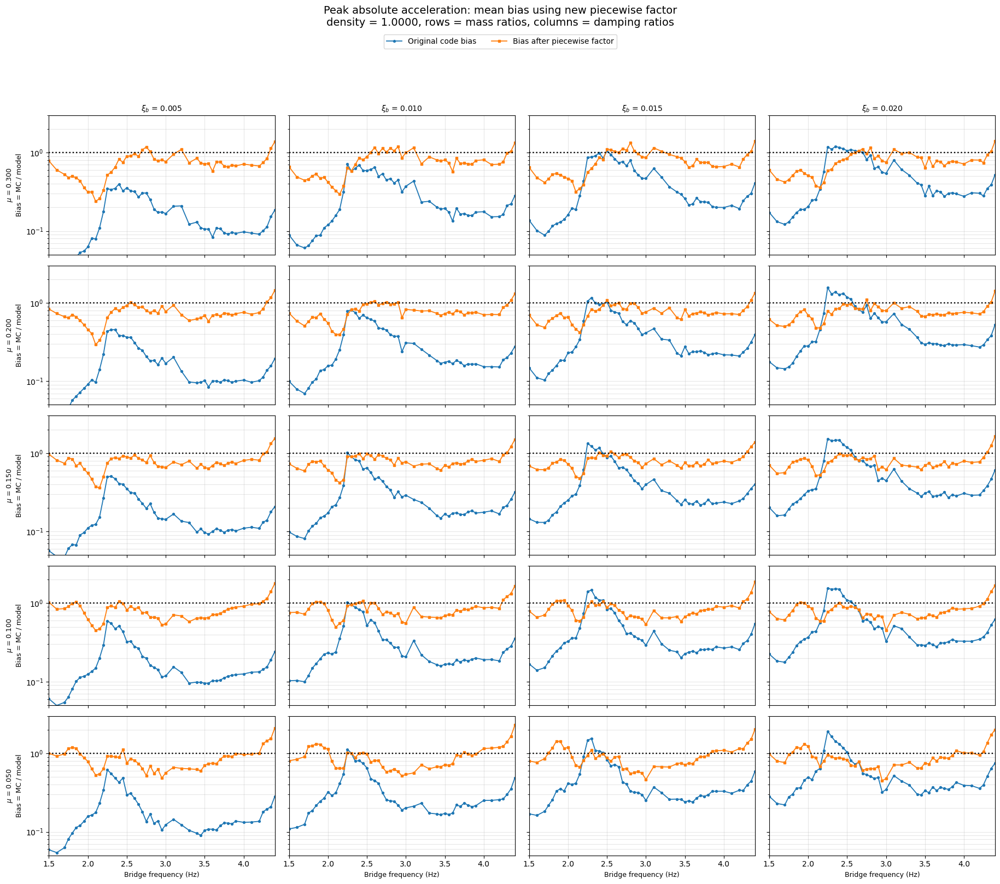

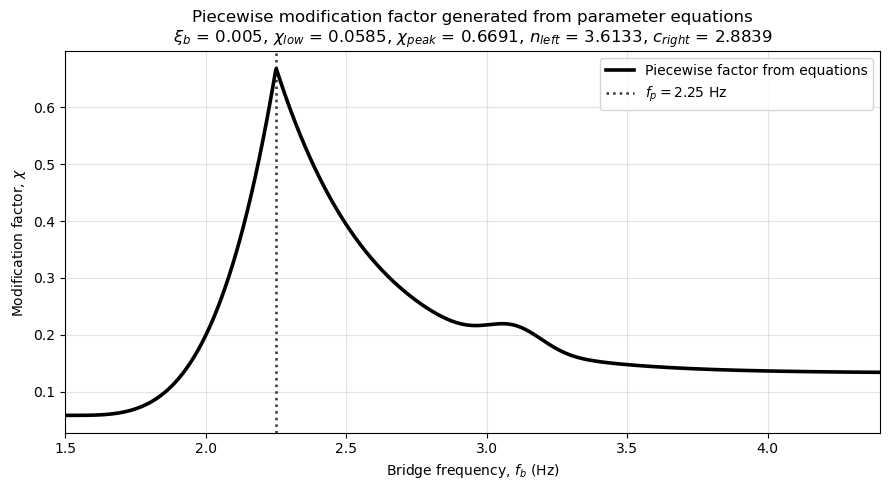

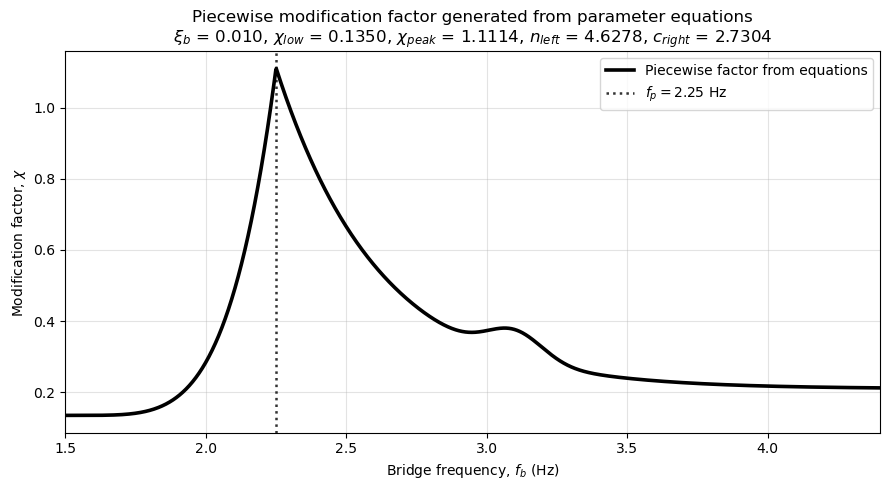

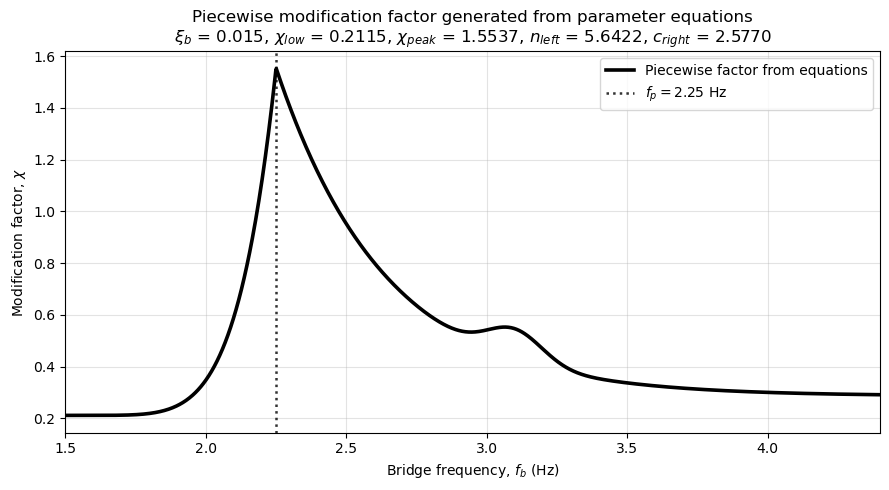

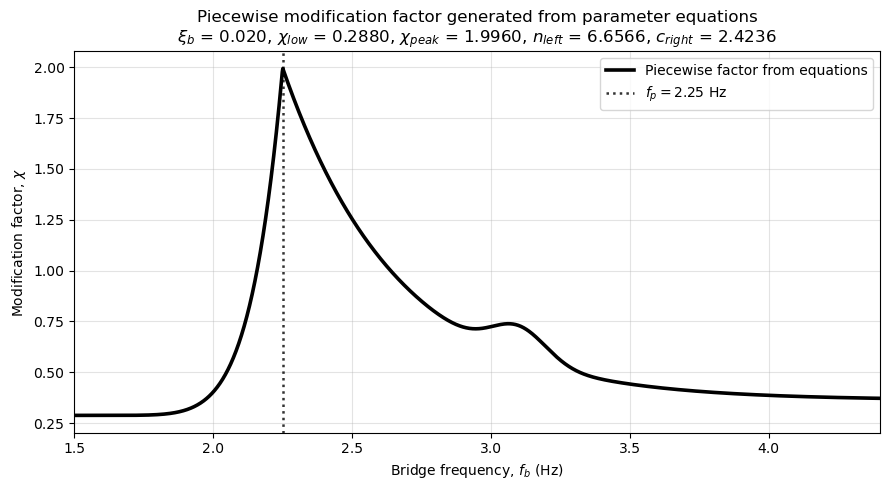

In [42]:
# ==================================================
# BIAS PLOT USING NEW PIECEWISE FUNCTION
# density = 1.0000, lm files, rho > 1
# ==================================================

from pathlib import Path
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DENSITY = 1.0000

MEASURE_NAME = "Peak absolute acceleration"

Y_COL_FACTOR = "final_modification_factor"

PLOT_FMIN = 1.50
PLOT_FMAX = 4.40

FIT_FMIN = 1.50

if "F_TARGET_PEAK" in globals():
    F_TARGET_PEAK_USE = float(F_TARGET_PEAK)
else:
    F_TARGET_PEAK_USE = 2.25

USE_LOG_Y = True
YMIN = 0.05
YMAX = 3.00

EPS = 1e-12

EXCLUDE_MASS_RATIOS_FROM_PLOT = [0.25]

SAVE_PLOT = False

# ==================================================
# CHECK PIECEWISE PARAMETERS EXIST
# ==================================================

if "piecewise_param_df_rho_gt1" in globals():
    piecewise_param_source = piecewise_param_df_rho_gt1.copy()
elif "piecewise_param_df" in globals():
    piecewise_param_source = piecewise_param_df.copy()
else:
    raise NameError(
        "Could not find piecewise_param_df_rho_gt1 or piecewise_param_df. "
        "Run the piecewise fitting code first."
    )

if "damping" in piecewise_param_source.columns:
    piecewise_param_source["xi_b"] = pd.to_numeric(
        piecewise_param_source["damping"],
        errors="coerce"
    )
elif "xi_b" in piecewise_param_source.columns:
    piecewise_param_source["xi_b"] = pd.to_numeric(
        piecewise_param_source["xi_b"],
        errors="coerce"
    )
elif "zeta_b" in piecewise_param_source.columns:
    piecewise_param_source["xi_b"] = pd.to_numeric(
        piecewise_param_source["zeta_b"],
        errors="coerce"
    )
else:
    raise KeyError("Piecewise parameter table needs damping, xi_b, or zeta_b column.")

piecewise_param_source = (
    piecewise_param_source
    .dropna(subset=["xi_b"])
    .sort_values("xi_b")
    .reset_index(drop=True)
)

print("\nPiecewise parameter source:")
print(piecewise_param_source.to_string(index=False))

# ==================================================
# BUILD LINEAR EQUATIONS FROM PIECEWISE PARAMETERS
# ==================================================

piecewise_params_to_use = [
    "chi_low",
    "chi_peak",
    "n_left",
    "chi_inf",
    "c_right",
    "f_p",
]

# Include bump_amp only if it exists
if "bump_amp" in piecewise_param_source.columns:
    piecewise_params_to_use.append("bump_amp")

missing_piecewise_cols = [
    c for c in piecewise_params_to_use
    if c not in piecewise_param_source.columns
]

if missing_piecewise_cols:
    raise KeyError(f"Missing piecewise parameter columns: {missing_piecewise_cols}")

piecewise_linear_fits = {}

x = piecewise_param_source["xi_b"].to_numpy(dtype=float)

for param in piecewise_params_to_use:

    y = pd.to_numeric(piecewise_param_source[param], errors="coerce").to_numpy(dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)

    if valid.sum() < 2:
        raise ValueError(f"Not enough valid points to fit {param}")

    a1, a0 = np.polyfit(x[valid], y[valid], 1)

    piecewise_linear_fits[param] = {
        "slope": a1,
        "intercept": a0,
    }

print("\nPiecewise equations used:")
print("=" * 70)

for param, info in piecewise_linear_fits.items():
    print(
        f"{param} = {info['slope']:.8f} * xi_b + {info['intercept']:.8f}"
    )

# ==================================================
# PIECEWISE FUNCTION FROM EQUATIONS
# ==================================================

def piecewise_params_from_equations(xi_b):
    xi_b = float(xi_b)

    p = {}

    for param, info in piecewise_linear_fits.items():
        p[param] = info["slope"] * xi_b + info["intercept"]

    # Safety limits
    p["chi_low"] = max(float(p["chi_low"]), EPS)
    p["chi_peak"] = max(float(p["chi_peak"]), EPS)
    p["chi_inf"] = max(float(p["chi_inf"]), EPS)

    p["n_left"] = np.clip(float(p["n_left"]), 0.20, 20.0)
    p["c_right"] = np.clip(float(p["c_right"]), 0.01, 50.0)

    if "f_p" not in p:
        p["f_p"] = F_TARGET_PEAK_USE

    p["f_p"] = float(p["f_p"])

    if "bump_amp" not in p:
        p["bump_amp"] = 0.0

    p["bump_amp"] = max(float(p["bump_amp"]), 0.0)

    return p


def chi_piecewise_from_equations(f_bridge, xi_b):
    f_bridge = np.asarray(f_bridge, dtype=float)

    p = piecewise_params_from_equations(xi_b)

    chi_low = p["chi_low"]
    chi_peak = p["chi_peak"]
    n_left = p["n_left"]
    chi_inf = p["chi_inf"]
    c_right = p["c_right"]
    f_p = p["f_p"]
    bump_amp = p["bump_amp"]

    y = np.zeros_like(f_bridge, dtype=float)

    left_mask = f_bridge <= f_p
    right_mask = f_bridge > f_p

    # Left branch
    t = (f_bridge[left_mask] - FIT_FMIN) / (f_p - FIT_FMIN)
    t = np.clip(t, 0.0, 1.0)

    y[left_mask] = (
        chi_low
        + (chi_peak - chi_low) * t**n_left
    )

    # Right branch
    d = np.maximum(f_bridge[right_mask] - f_p, 0.0)

    y[right_mask] = (
        chi_inf
        + (chi_peak - chi_inf) * np.exp(-c_right * d)
    )

    # Optional bump, if bump_amp was fitted
    if bump_amp > 0:
        BUMP_CENTER = 3.10
        BUMP_WIDTH = 0.10

        g = np.exp(-0.5 * ((f_bridge - BUMP_CENTER) / BUMP_WIDTH)**2)
        g0 = np.exp(-0.5 * ((f_p - BUMP_CENTER) / BUMP_WIDTH)**2)

        bump_shape = np.maximum(g - g0, 0.0)

        y = y + bump_amp * bump_shape

    return np.maximum(y, EPS)

# ==================================================
# FILE SEARCH
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"lm(?P<linear_mass>\d+)_"
    r"bias_summary\.pkl$"
)

files_found = []

for file in sorted(folder.glob("density*_damping*_lm*_bias_summary.pkl")):
    m = pattern.match(file.name)
    if m is None:
        continue

    density = float(m.group("density"))
    damping = float(m.group("damping"))
    lm = int(m.group("linear_mass"))

    if np.isclose(density, TARGET_DENSITY):
        files_found.append((file, file.name, density, damping, lm))

print("\nAll density 1 lm bias files found:")
for _, name, density, damping, lm in files_found:
    print((name, density, damping, lm))

print("\nDampings found:")
dampings_found = sorted(set(round(x[3], 3) for x in files_found))
print(dampings_found)

print("\nLinear masses found by damping:")
for d in dampings_found:
    lms = sorted(x[4] for x in files_found if round(x[3], 3) == d)
    print(d, lms)

# ==================================================
# MASS RATIO MAPPING
# ==================================================

LM_TO_MU = {
    500:  0.30,
    750:  0.20,
    1000: 0.15,
    1500: 0.10,
    2000: 0.05,

    483:  0.30,
    580:  0.25,
    725:  0.20,
    967:  0.15,
    1450: 0.10,
    2900: 0.05,
}

TARGET_MASS_RATIOS = np.array([0.30, 0.25, 0.20, 0.15, 0.10, 0.05])

def snap_to_nominal_mu(mu):
    mu = float(mu)
    return float(TARGET_MASS_RATIOS[np.argmin(np.abs(TARGET_MASS_RATIOS - mu))])

def infer_mass_ratio_from_lm(lm):
    lm = int(lm)

    if lm not in LM_TO_MU:
        raise ValueError(
            f"linear mass {lm} is not in LM_TO_MU. "
            "Add the corresponding mass ratio."
        )

    return snap_to_nominal_mu(LM_TO_MU[lm])

# ==================================================
# LOAD FILES
# ==================================================

all_dfs = []

for file, name, density, damping, lm in files_found:

    with open(file, "rb") as f:
        obj = pickle.load(f)

    if isinstance(obj, pd.DataFrame):
        df = obj.copy()
    elif isinstance(obj, dict):
        df = None

        for key in ["summary_df", "bias_summary_df", "results_df", "plot_df", "df", "data"]:
            if key in obj and isinstance(obj[key], pd.DataFrame):
                df = obj[key].copy()
                break

        if df is None:
            for value in obj.values():
                if isinstance(value, pd.DataFrame):
                    df = value.copy()
                    break

        if df is None:
            raise TypeError(f"No dataframe found inside {name}")
    else:
        df = pd.DataFrame(obj)

    df["source_file"] = name
    df["target_density"] = density
    df["target_beamdamp"] = damping
    df["linear_mass"] = lm
    df["mass_ratio_key"] = infer_mass_ratio_from_lm(lm)

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No density 1 lm bias files loaded.")

bias_df = pd.concat(all_dfs, ignore_index=True)

print("\nCombined dataframe shape:", bias_df.shape)

# ==================================================
# CLEAN DATA
# ==================================================

required_cols = [
    "bridge_frequency",
    "target_beamdamp",
    "linear_mass",
    "mass_ratio_key",
    Y_COL_FACTOR,
    "measure",
    "code_bias_mean",
    "corrected_bias_mean",
]

missing_cols = [c for c in required_cols if c not in bias_df.columns]

if missing_cols:
    raise KeyError(f"Missing required columns in loaded files: {missing_cols}")

for col in [
    "bridge_frequency",
    "target_beamdamp",
    "linear_mass",
    "mass_ratio_key",
    Y_COL_FACTOR,
    "code_bias_mean",
    "corrected_bias_mean",
]:
    bias_df[col] = pd.to_numeric(bias_df[col], errors="coerce")

bias_df = bias_df.dropna(subset=required_cols).copy()

bias_df = bias_df[
    (bias_df["bridge_frequency"] >= PLOT_FMIN) &
    (bias_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

bias_df = bias_df[
    bias_df["measure"].astype(str) == MEASURE_NAME
].copy()

if bias_df.empty:
    raise ValueError(f"No rows found for measure: {MEASURE_NAME}")

bias_df["damping_key"] = bias_df["target_beamdamp"].round(3)

# ==================================================
# CALCULATE BIAS USING NEW PIECEWISE FUNCTION
# ==================================================

bias_df["chi_file"] = np.maximum(
    bias_df[Y_COL_FACTOR].to_numpy(dtype=float),
    EPS
)

bias_df["chi_piecewise_equation"] = np.nan

for damp in sorted(bias_df["target_beamdamp"].dropna().unique()):

    mask = np.isclose(bias_df["target_beamdamp"], damp)

    bias_df.loc[mask, "chi_piecewise_equation"] = chi_piecewise_from_equations(
        bias_df.loc[mask, "bridge_frequency"].to_numpy(dtype=float),
        xi_b=float(damp)
    )

bias_df["chi_piecewise_equation"] = np.maximum(
    pd.to_numeric(bias_df["chi_piecewise_equation"], errors="coerce").to_numpy(dtype=float),
    EPS
)

# corrected_bias_mean = MC / (model * chi_file)
# piecewise_bias_mean = MC / (model * chi_piecewise)
bias_df["piecewise_bias_mean"] = (
    bias_df["corrected_bias_mean"]
    * bias_df["chi_file"]
    / bias_df["chi_piecewise_equation"]
)

bias_df["piecewise_factor_ratio_to_file_factor"] = (
    bias_df["chi_piecewise_equation"] / bias_df["chi_file"]
)

bias_df.to_csv(
    "bias_from_piecewise_equation_factor_model_density1_lm.csv",
    index=False
)

print("\nSaved: bias_from_piecewise_equation_factor_model_density1_lm.csv")

# ==================================================
# DIAGNOSTIC MATRIX
# ==================================================

print("\nLoaded file matrix: rows = mass ratio, columns = damping")

file_matrix = (
    bias_df[["mass_ratio_key", "damping_key", "linear_mass"]]
    .drop_duplicates()
    .pivot_table(
        index="mass_ratio_key",
        columns="damping_key",
        values="linear_mass",
        aggfunc=lambda x: ", ".join(str(int(v)) for v in sorted(x))
    )
    .sort_index(ascending=False)
)

print(file_matrix)

# ==================================================
# GRID PLOT: ROWS = MASS RATIO, COLUMNS = DAMPING
# ==================================================

plot_df = bias_df.copy()

mass_ratios = sorted(
    plot_df["mass_ratio_key"].dropna().unique(),
    reverse=True
)

mass_ratios = [
    mr for mr in mass_ratios
    if not any(np.isclose(mr, ex) for ex in EXCLUDE_MASS_RATIOS_FROM_PLOT)
]

damping_values = sorted(plot_df["target_beamdamp"].dropna().unique())

nrows = len(mass_ratios)
ncols = len(damping_values)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4.6 * ncols, 3.1 * nrows),
    sharex=True,
    sharey=True,
    squeeze=False
)

for i, mr in enumerate(mass_ratios):

    for j, damp in enumerate(damping_values):

        ax = axes[i, j]

        sub = plot_df[
            (np.isclose(plot_df["mass_ratio_key"], mr)) &
            (np.isclose(plot_df["target_beamdamp"], damp))
        ].copy()

        if sub.empty:
            ax.text(
                0.5,
                0.5,
                "No file",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=11
            )

            ax.grid(True, alpha=0.25)
            ax.set_xlim(PLOT_FMIN, PLOT_FMAX)

            if i == 0:
                ax.set_title(rf"$\xi_b$ = {damp:.3f}", fontsize=10)

            if j == 0:
                ax.set_ylabel(
                    rf"$\mu$ = {mr:.3f}" + "\nBias = MC / model",
                    fontsize=9
                )

            continue

        sub = sub.sort_values("bridge_frequency")

        ax.plot(
            sub["bridge_frequency"],
            sub["code_bias_mean"],
            marker="o",
            markersize=2.8,
            linewidth=1.3,
            label="Original code bias"
        )

        ax.plot(
            sub["bridge_frequency"],
            sub["piecewise_bias_mean"],
            marker="s",
            markersize=2.8,
            linewidth=1.3,
            label="Bias after piecewise factor"
        )

        ax.axhline(
            1.0,
            linestyle=":",
            linewidth=1.7,
            color="black"
        )

        if i == 0:
            ax.set_title(rf"$\xi_b$ = {damp:.3f}", fontsize=10)

        if j == 0:
            ax.set_ylabel(
                rf"$\mu$ = {mr:.3f}" + "\nBias = MC / model",
                fontsize=9
            )

        if i == nrows - 1:
            ax.set_xlabel("Bridge frequency (Hz)", fontsize=9)

        ax.set_xlim(PLOT_FMIN, PLOT_FMAX)

        if USE_LOG_Y:
            ax.set_yscale("log")
            ax.set_ylim(YMIN, YMAX)
        else:
            ax.set_ylim(0.0, YMAX)

        ax.grid(True, which="both", alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.01)
)

fig.suptitle(
    f"{MEASURE_NAME}: mean bias using new piecewise factor\n"
    f"density = {TARGET_DENSITY:.4f}, rows = mass ratios, columns = damping ratios",
    fontsize=14,
    y=1.04
)

fig.tight_layout(rect=[0, 0, 1, 0.97])

if SAVE_PLOT:
    fig_name = (
        f"peak_absolute_bias_grid_density{TARGET_DENSITY:.4f}_"
        f"piecewise_equation_factor.png"
    )

    fig.savefig(fig_name, dpi=300, bbox_inches="tight")
    print("Saved:", fig_name)

plt.show()

# ==================================================
# OPTIONAL: PLOT PIECEWISE FACTOR CURVES ONLY
# ==================================================

for damp in damping_values:

    f_grid = np.linspace(PLOT_FMIN, PLOT_FMAX, 1500)

    chi_pw = chi_piecewise_from_equations(
        f_grid,
        xi_b=float(damp)
    )

    p = piecewise_params_from_equations(damp)

    plt.figure(figsize=(9, 5))

    plt.plot(
        f_grid,
        chi_pw,
        linewidth=2.6,
        color="black",
        label="Piecewise factor from equations"
    )

    plt.axvline(
        p["f_p"],
        linestyle=":",
        linewidth=1.8,
        color="black",
        alpha=0.8,
        label=rf"$f_p={p['f_p']:.2f}$ Hz"
    )

    plt.xlabel(r"Bridge frequency, $f_b$ (Hz)")
    plt.ylabel(r"Modification factor, $\chi$")

    plt.title(
        "Piecewise modification factor generated from parameter equations\n"
        rf"$\xi_b$ = {damp:.3f}, "
        rf"$\chi_{{low}}$ = {p['chi_low']:.4f}, "
        rf"$\chi_{{peak}}$ = {p['chi_peak']:.4f}, "
        rf"$n_{{left}}$ = {p['n_left']:.4f}, "
        rf"$c_{{right}}$ = {p['c_right']:.4f}"
    )

    plt.xlim(PLOT_FMIN, PLOT_FMAX)
    plt.grid(True, alpha=0.35)
    plt.legend()
    plt.tight_layout()
    plt.show()

Loading: density1.0000_damping0.005_lm1000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm1500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm2000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm750_bias_summary.pkl
Loading: density1.0000_damping0.010_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.010_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.010_lm483_bias_summary.pkl
Loading: density1.0000_damping0.010_lm580_bias_summary.pkl
Loading: density1.0000_damping0.010_lm725_bias_summary.pkl
Loading: density1.0000_damping0.010_lm967_bias_summary.pkl
Loading: density1.0000_damping0.015_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.015_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.015_lm483_bias_summary.pkl
Loading: density1.0000_damping0.015_lm580_bias_summary.pkl
Loading: density1.0000_damping0.015_lm725_bias_summary.pkl
Loading: density1.0000_damping0.015_lm967_bias_su

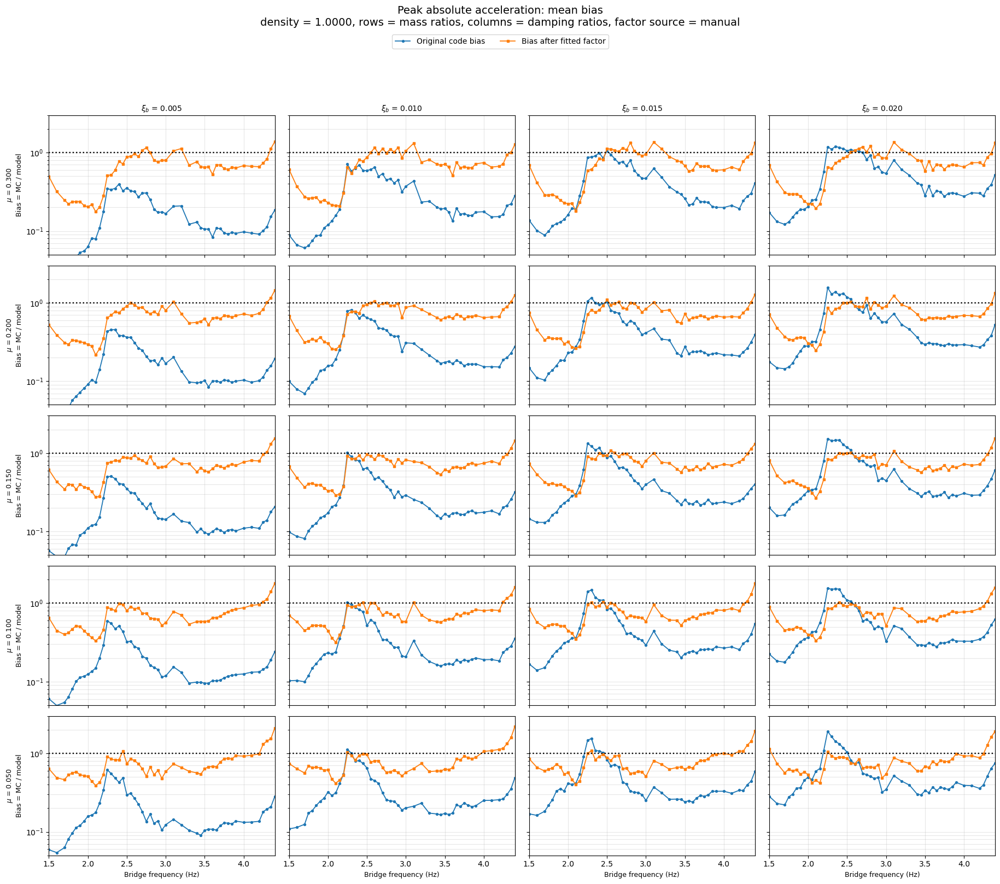

In [57]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DENSITY = 1.0000
TARGET_DAMPINGS = [0.005, 0.010, 0.015, 0.020]

MEASURE_NAME = "Peak absolute acceleration"

Y_COL_FACTOR = "final_modification_factor"

PLOT_FMIN = 1.50
PLOT_FMAX = 4.40

USE_LOG_Y = True
YMIN = 0.05
YMAX = 3.00

SAVE_PLOTS = False
EPS = 1e-12

FACTOR_SOURCE = "manual"

# Nominal mass ratios expected in your files
TARGET_MASS_RATIOS = np.array([0.30, 0.25, 0.20, 0.15, 0.10, 0.05])


# ==================================================
# SELECT FITTED FACTOR CURVES
# ==================================================

if FACTOR_SOURCE == "manual":
    factor_curve_df = df_manual_curves.copy()
    factor_chi_col = "chi_manual"

elif FACTOR_SOURCE == "improved":
    factor_curve_df = df_fit_curves.copy()
    factor_chi_col = "chi_ideal"

else:
    raise ValueError("FACTOR_SOURCE must be 'manual' or 'improved'.")

required_curve_cols = ["xi_b", "bridge_frequency", factor_chi_col]

missing_curve = [c for c in required_curve_cols if c not in factor_curve_df.columns]
if missing_curve:
    raise KeyError(f"Missing columns in fitted curve dataframe: {missing_curve}")

for col in required_curve_cols:
    factor_curve_df[col] = pd.to_numeric(factor_curve_df[col], errors="coerce")

factor_curve_df = factor_curve_df.dropna(subset=required_curve_cols).copy()


def get_fitted_chi_from_curve(frequencies, damping):
    curve_sub = factor_curve_df[
        np.isclose(factor_curve_df["xi_b"], damping)
    ].copy()

    if curve_sub.empty:
        raise ValueError(f"No fitted curve found for damping = {damping:.3f}")

    curve_sub = curve_sub.sort_values("bridge_frequency")

    return np.interp(
        frequencies,
        curve_sub["bridge_frequency"].to_numpy(),
        curve_sub[factor_chi_col].to_numpy(),
        left=np.nan,
        right=np.nan
    )


# ==================================================
# MASS RATIO HELPERS
# ==================================================
LM_TO_MU = {
    # damping 0.005 files
    500:  0.30,
    750:  0.20,
    1000: 0.15,
    1500: 0.10,
    2000: 0.05,   # corrected from previous accidental 0.075

    # damping 0.010, 0.015, 0.020 files
    483:  0.30,
    580:  0.25,
    725:  0.20,
    967:  0.15,
    1450: 0.10,
    2900: 0.05,
}

def snap_to_nominal_mu(mu):
    """
    Snap to the nearest intended mass ratio.
    """

    mu = float(mu)
    return float(TARGET_MASS_RATIOS[np.argmin(np.abs(TARGET_MASS_RATIOS - mu))])

def infer_file_mass_ratio(df, linear_mass):
    """
    Force intended nominal mass ratio from linear mass.
    This avoids accidentally creating mu = 0.075.
    """

    lm = int(round(float(linear_mass)))

    if lm in LM_TO_MU:
        return LM_TO_MU[lm]

    raise ValueError(
        f"Linear mass {lm} is not in LM_TO_MU. "
        "Add its intended mass ratio to the mapping."
    )

    

# ==================================================
# LOAD ALL DENSITY = 1 lm BIAS FILES
# IMPORTANT: no LINEAR_MASSES_TO_LOAD filter here
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"lm(?P<linear_mass>\d+)_"
    r"bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_lm*_bias_summary.pkl"))

all_dfs = []
loaded_files = []

for file in pkl_files:

    match = pattern.match(file.name)

    if match is None:
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_linear_mass = int(match.group("linear_mass"))

    if not np.isclose(file_density, TARGET_DENSITY):
        continue

    if not any(np.isclose(file_damping, d) for d in TARGET_DAMPINGS):
        continue

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    file_mu_raw = infer_file_mass_ratio(df, file_linear_mass)
    file_mu_key = snap_to_nominal_mu(file_mu_raw)

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["linear_mass"] = file_linear_mass
    df["mass_ratio_raw"] = file_mu_raw
    df["mass_ratio_key"] = file_mu_key

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)
    loaded_files.append(file.name)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching density=1 lm bias summary PKL files were loaded.")

combined_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded combined dataframe shape:", combined_df.shape)


# ==================================================
# CLEAN DATA
# ==================================================

num_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "linear_mass",
    "mass_ratio_raw",
    "mass_ratio_key",
    Y_COL_FACTOR,
    "code_bias_mean",
    "corrected_bias_mean",
]

for col in num_cols:
    if col in combined_df.columns:
        combined_df[col] = pd.to_numeric(combined_df[col], errors="coerce")

required_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "linear_mass",
    "mass_ratio_key",
    Y_COL_FACTOR,
    "measure",
    "code_bias_mean",
    "corrected_bias_mean",
]

missing = [c for c in required_cols if c not in combined_df.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

combined_df = combined_df.dropna(subset=required_cols).copy()

combined_df["density_key"] = combined_df["target_density"].round(4)
combined_df["damping_key"] = combined_df["target_beamdamp"].round(3)
combined_df["linear_mass_key"] = combined_df["linear_mass"].round(0).astype(int)

combined_df = combined_df[
    (combined_df["bridge_frequency"] >= PLOT_FMIN) &
    (combined_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

combined_df = combined_df[
    combined_df["measure"].astype(str) == MEASURE_NAME
].copy()

if combined_df.empty:
    raise ValueError(f"No rows found for measure: {MEASURE_NAME}")


# ==================================================
# DIAGNOSTIC TABLE
# ==================================================

print("\nLoaded file matrix: rows = mass ratio, columns = damping")
file_matrix = (
    combined_df[["mass_ratio_key", "damping_key", "linear_mass_key"]]
    .drop_duplicates()
    .pivot_table(
        index="mass_ratio_key",
        columns="damping_key",
        values="linear_mass_key",
        aggfunc=lambda x: ", ".join(str(int(v)) for v in sorted(x))
    )
    .sort_index(ascending=False)
)

print(file_matrix)

print("\nAvailable damping ratios in bias data:")
print(sorted(combined_df["damping_key"].dropna().unique()))

print("\nAvailable damping ratios in fitted curves:")
print(sorted(factor_curve_df["xi_b"].dropna().round(3).unique()))


# ==================================================
# CALCULATE FITTED-FACTOR BIAS
# ==================================================

combined_df["chi_final"] = combined_df[Y_COL_FACTOR]
combined_df["chi_fit"] = np.nan

for damp in TARGET_DAMPINGS:

    mask = np.isclose(combined_df["target_beamdamp"], damp)

    if not mask.any():
        continue

    combined_df.loc[mask, "chi_fit"] = get_fitted_chi_from_curve(
        combined_df.loc[mask, "bridge_frequency"].to_numpy(),
        damp
    )

combined_df["chi_fit"] = pd.to_numeric(combined_df["chi_fit"], errors="coerce")
combined_df = combined_df.dropna(subset=["chi_fit"]).copy()
combined_df["chi_fit"] = np.maximum(combined_df["chi_fit"], EPS)

# corrected_bias = MC / (simplified * chi_final)
# fitted_bias    = MC / (simplified * chi_fit)
combined_df["fitted_factor_bias_mean"] = (
    combined_df["corrected_bias_mean"]
    * combined_df["chi_final"]
    / combined_df["chi_fit"]
)


# ==================================================
# FINAL GRID PLOT:
# ROWS = MASS RATIOS
# COLUMNS = DAMPING RATIOS
# ==================================================

plot_df = combined_df.copy()

mass_ratios = sorted(
    plot_df["mass_ratio_key"].dropna().unique(),
    reverse=True
)

# Remove mass ratio 0.25 from plotting
mass_ratios = [
    mr for mr in mass_ratios
    if not np.isclose(mr, 0.25)
]
damping_values = TARGET_DAMPINGS

nrows = len(mass_ratios)
ncols = len(damping_values)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4.6 * ncols, 3.1 * nrows),
    sharex=True,
    sharey=True,
    squeeze=False
)

for i, mr in enumerate(mass_ratios):

    for j, damp in enumerate(damping_values):

        ax = axes[i, j]

        sub = plot_df[
            (np.isclose(plot_df["mass_ratio_key"], mr)) &
            (np.isclose(plot_df["target_beamdamp"], damp))
        ].copy()

        if sub.empty:
            ax.text(
                0.5,
                0.5,
                "No file",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=11
            )

            if i == 0:
                ax.set_title(rf"$\xi_b$ = {damp:.3f}", fontsize=10)

            if j == 0:
                ax.set_ylabel(
                    rf"$\mu$ = {mr:.3f}" + "\nBias = MC / model",
                    fontsize=9
                )

            ax.set_xlim(PLOT_FMIN, PLOT_FMAX)
            ax.grid(True, alpha=0.25)
            continue

        sub = sub.sort_values("bridge_frequency")

        ax.plot(
            sub["bridge_frequency"],
            sub["code_bias_mean"],
            marker="o",
            markersize=2.8,
            linewidth=1.3,
            label="Original code bias"
        )

        ax.plot(
            sub["bridge_frequency"],
            sub["fitted_factor_bias_mean"],
            marker="s",
            markersize=2.8,
            linewidth=1.3,
            label="Bias after fitted factor"
        )

        ax.axhline(
            1.0,
            linestyle=":",
            linewidth=1.7,
            color="black"
        )

        if i == 0:
            ax.set_title(rf"$\xi_b$ = {damp:.3f}", fontsize=10)

        if j == 0:
            ax.set_ylabel(
                rf"$\mu$ = {mr:.3f}" + "\nBias = MC / model",
                fontsize=9
            )

        if i == nrows - 1:
            ax.set_xlabel("Bridge frequency (Hz)", fontsize=9)

        ax.set_xlim(PLOT_FMIN, PLOT_FMAX)

        if USE_LOG_Y:
            ax.set_yscale("log")
            ax.set_ylim(YMIN, YMAX)
        else:
            ax.set_ylim(0.0, YMAX)

        ax.grid(True, which="both", alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.01)
)

fig.suptitle(
    f"{MEASURE_NAME}: mean bias\n"
    f"density = {TARGET_DENSITY:.4f}, rows = mass ratios, columns = damping ratios, "
    f"factor source = {FACTOR_SOURCE}",
    fontsize=14,
    y=1.04
)

fig.tight_layout(rect=[0, 0, 1, 0.97])

if SAVE_PLOTS:
    fig_name = (
        f"peak_absolute_bias_grid_density{TARGET_DENSITY:.4f}_"
        f"factor_{FACTOR_SOURCE}.png"
    )
    fig.savefig(fig_name, dpi=300, bbox_inches="tight")
    print("Saved:", fig_name)

plt.show()

In [54]:
from pathlib import Path

folder = Path(".")

print("All density1.0000 PKL files in this folder:")
for f in sorted(folder.glob("*density1.0000*.pkl")):
    print(f.name)

All density1.0000 PKL files in this folder:
density1.0000_damping0.005_0S125_bias_summary.pkl
density1.0000_damping0.005_0S456_bias_summary.pkl
density1.0000_damping0.005_0S_bias_summary.pkl
density1.0000_damping0.005_lm1000_bias_summary.pkl
density1.0000_damping0.005_lm1500_bias_summary.pkl
density1.0000_damping0.005_lm2000_bias_summary.pkl
density1.0000_damping0.005_lm500_bias_summary.pkl
density1.0000_damping0.005_lm750_bias_summary.pkl
density1.0000_damping0.010_0S125_bias_summary.pkl
density1.0000_damping0.010_0S456_bias_summary.pkl
density1.0000_damping0.010_0S_bias_summary.pkl
density1.0000_damping0.010_lm1450_bias_summary.pkl
density1.0000_damping0.010_lm2900_bias_summary.pkl
density1.0000_damping0.010_lm483_bias_summary.pkl
density1.0000_damping0.010_lm580_bias_summary.pkl
density1.0000_damping0.010_lm725_bias_summary.pkl
density1.0000_damping0.010_lm967_bias_summary.pkl
density1.0000_damping0.015_lm1450_bias_summary.pkl
density1.0000_damping0.015_lm2900_bias_summary.pkl
densi

In [15]:
# ==================================================
# MANUAL / ANCHORED PARAMETER APPROXIMATION
# Clean version:
#   - no light-blue source points in parameter plots
#   - no previous improved dashed curve in fit plots
#   - linear equations printed and shown on plots
# ==================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==================================================
# REQUIRED VARIABLES FROM PREVIOUS FITTING CODE
# ==================================================
# This block assumes these already exist:
#   full_df
#   df_fit_params
#   df_raw_params
#   Q_mmd
#   Y_COL
#   TARGET_DENSITY
#   TARGET_DAMPINGS
#   F_TARGET_PEAK
#   PLOT_FMIN, PLOT_FMAX
#
# Example:
# TARGET_DAMPINGS = [0.005, 0.010, 0.015, 0.020]
# F_TARGET_PEAK = 2.25
# Y_COL = "final_modification_factor"


# ==================================================
# CHOOSE PARAMETER SOURCE
# ==================================================
# "improved" = dark-blue improved fitted parameters
# "raw"      = original independent fitted parameters

PARAM_SOURCE = "improved"

if PARAM_SOURCE == "improved":
    source_params = df_fit_params.copy()
elif PARAM_SOURCE == "raw":
    source_params = df_raw_params.copy()
else:
    raise ValueError("PARAM_SOURCE must be 'improved' or 'raw'.")

source_params = source_params.sort_values("xi_b").reset_index(drop=True)

required_param_cols = [
    "xi_b",
    "y0",
    "B",
    "mu",
    "alpha",
    "zeta_a",
    "beta_p",
    "f_p",
]

missing_param_cols = [
    col for col in required_param_cols
    if col not in source_params.columns
]

if missing_param_cols:
    raise KeyError(f"Missing columns in source_params: {missing_param_cols}")

for col in required_param_cols:
    source_params[col] = pd.to_numeric(source_params[col], errors="coerce")

source_params = source_params.dropna(subset=required_param_cols).copy()

if len(source_params) < 4:
    raise ValueError(
        "source_params has fewer than 4 damping points. "
        "The selected anchor points use 4th, 3rd, and 2nd points."
    )


# ==================================================
# ANCHOR POINT SELECTION
# ==================================================
# 1-based indexing:
# y0      : 4th point from y0 graph
# B       : 2nd point from B graph
# mu      : 3rd point from mu graph
# alpha   : handled separately
# zeta_a  : 4th point from zeta_a graph
# beta_p  : 3rd point from beta_p graph

ANCHOR_POINT = {
    "y0": 4,
    "B": 2,
    "mu": 3,
    "zeta_a": 4,
    "beta_p": 3,
}

# Alpha options:
#   "linear_all"       = ordinary linear fit through all alpha points
#   "constant_median"  = constant median alpha
#   "anchor_shift"     = linear slope shifted through selected alpha point

ALPHA_MODE = "linear_all"
ALPHA_ANCHOR_POINT = 3


# ==================================================
# HELPER FUNCTIONS
# ==================================================

def anchored_linear_values(df, param, anchor_point_1based, xi_eval):
    """
    Linear trend using slope from all source points,
    shifted so that it passes exactly through the selected anchor point.

    y = m * xi_b + c_shifted
    """

    x = df["xi_b"].to_numpy(dtype=float)
    y = df[param].to_numpy(dtype=float)

    m, c_raw = np.polyfit(x, y, 1)

    anchor_idx = anchor_point_1based - 1

    if anchor_idx < 0 or anchor_idx >= len(df):
        raise IndexError(
            f"Anchor point {anchor_point_1based} is invalid for {param}. "
            f"Only {len(df)} source points are available."
        )

    x_anchor = x[anchor_idx]
    y_anchor = y[anchor_idx]

    c_shifted = y_anchor - m * x_anchor

    y_eval = m * xi_eval + c_shifted

    return y_eval, m, c_shifted, x_anchor, y_anchor


def ordinary_linear_values(df, param, xi_eval):
    """
    Ordinary least-squares linear trend through all source points.

    y = m * xi_b + c
    """

    x = df["xi_b"].to_numpy(dtype=float)
    y = df[param].to_numpy(dtype=float)

    m, c = np.polyfit(x, y, 1)

    y_eval = m * xi_eval + c

    return y_eval, m, c


def clip_manual_params(row):
    """
    Keep parameters inside sensible physical/numerical ranges.
    """

    row["y0"] = max(row["y0"], 1e-8)
    row["B"] = max(row["B"], 1e-8)

    row["mu"] = np.clip(row["mu"], 0.001, 0.50)
    row["alpha"] = np.clip(row["alpha"], 0.50, 1.50)
    row["zeta_a"] = np.clip(row["zeta_a"], 0.30, 2.00)
    row["beta_p"] = np.clip(row["beta_p"], 0.80, 1.20)

    row["f_p"] = F_TARGET_PEAK

    return row


def chi_manual_beta_model(
    f_bridge,
    y0,
    B,
    mu,
    alpha,
    zeta_a,
    zeta_b,
    beta_p,
    f_p=F_TARGET_PEAK
):
    """
    Manual anchored MMD/TMD shape.
    beta_p is supplied directly from the manual parameter trend.
    """

    beta_eff = beta_p * (np.asarray(f_bridge, dtype=float) / f_p)

    Q_eff = Q_mmd(
        beta=beta_eff,
        mu=mu,
        alpha=alpha,
        zeta_b=zeta_b,
        zeta_a=zeta_a
    )

    return y0 + B * Q_eff


# ==================================================
# BUILD MANUAL PARAMETER TABLE
# ==================================================

xi_eval = np.array(TARGET_DAMPINGS, dtype=float)

manual_param_data = {
    "xi_b": xi_eval,
}

trend_info = {}

# --------------------------------------------------
# y0, B, mu, zeta_a, beta_p:
# anchored linear trends
# --------------------------------------------------

for param in ["y0", "B", "mu", "zeta_a", "beta_p"]:

    y_eval, m, c, x_anchor, y_anchor = anchored_linear_values(
        source_params,
        param,
        ANCHOR_POINT[param],
        xi_eval
    )

    manual_param_data[param] = y_eval

    trend_info[param] = {
        "method": "anchor_shift",
        "slope": m,
        "intercept": c,
        "anchor_xi_b": x_anchor,
        "anchor_value": y_anchor,
        "anchor_point": ANCHOR_POINT[param],
    }


# --------------------------------------------------
# alpha:
# choose the selected treatment
# --------------------------------------------------

if ALPHA_MODE == "linear_all":

    y_eval, m, c = ordinary_linear_values(
        source_params,
        "alpha",
        xi_eval
    )

    manual_param_data["alpha"] = y_eval

    trend_info["alpha"] = {
        "method": "linear_all",
        "slope": m,
        "intercept": c,
    }

elif ALPHA_MODE == "constant_median":

    alpha_const = np.nanmedian(source_params["alpha"])

    manual_param_data["alpha"] = np.full_like(xi_eval, alpha_const)

    trend_info["alpha"] = {
        "method": "constant_median",
        "value": alpha_const,
    }

elif ALPHA_MODE == "anchor_shift":

    y_eval, m, c, x_anchor, y_anchor = anchored_linear_values(
        source_params,
        "alpha",
        ALPHA_ANCHOR_POINT,
        xi_eval
    )

    manual_param_data["alpha"] = y_eval

    trend_info["alpha"] = {
        "method": "anchor_shift",
        "slope": m,
        "intercept": c,
        "anchor_xi_b": x_anchor,
        "anchor_value": y_anchor,
        "anchor_point": ALPHA_ANCHOR_POINT,
    }

else:
    raise ValueError("Unknown ALPHA_MODE.")


# --------------------------------------------------
# f_p is fixed
# --------------------------------------------------

manual_param_data["f_p"] = np.full_like(xi_eval, F_TARGET_PEAK)

df_manual_params = pd.DataFrame(manual_param_data)

df_manual_params = df_manual_params.apply(
    lambda row: clip_manual_params(row),
    axis=1
)

df_manual_params["xi_b_percent"] = 100.0 * df_manual_params["xi_b"]


# ==================================================
# PRINT MANUAL PARAMETER TABLE
# ==================================================

print("\n" + "="*80)
print("MANUAL / ANCHORED PARAMETER TABLE")
print("="*80)
print(df_manual_params)
print("="*80)


# ==================================================
# BUILD LINEAR EQUATION TABLE
# Equations are shown against xi_b as a ratio:
#
#   p = m * xi_b + c
#
# Example:
#   xi_b = 0.005, 0.010, 0.015, 0.020
# ==================================================

params_to_plot = ["y0", "B", "mu", "alpha", "zeta_a", "beta_p", "f_p"]

equation_rows = []

for param in params_to_plot:

    if param == "f_p":
        m_ratio = 0.0
        c_ratio = F_TARGET_PEAK

        equation_rows.append({
            "parameter": param,
            "method": "fixed",
            "equation_ratio": f"{param} = {c_ratio:.8f}",
            "slope_per_ratio": m_ratio,
            "intercept": c_ratio,
        })

        continue

    info = trend_info[param]

    if info["method"] in ["anchor_shift", "linear_all"]:

        # These are already based on xi_b as a ratio
        # p = m_ratio * xi_b + c_ratio
        m_ratio = info["slope"]
        c_ratio = info["intercept"]

        equation_rows.append({
            "parameter": param,
            "method": info["method"],
            "equation_ratio": (
                f"{param} = {m_ratio:.8f} * xi_b + {c_ratio:.8f}"
            ),
            "slope_per_ratio": m_ratio,
            "intercept": c_ratio,
        })

    elif info["method"] == "constant_median":

        m_ratio = 0.0
        c_ratio = info["value"]

        equation_rows.append({
            "parameter": param,
            "method": info["method"],
            "equation_ratio": f"{param} = {c_ratio:.8f}",
            "slope_per_ratio": m_ratio,
            "intercept": c_ratio,
        })

df_manual_equations = pd.DataFrame(equation_rows)


print("\n" + "="*80)
print("LINEAR EQUATIONS FOR MANUAL ANCHORED PARAMETERS")
print("Using xi_b as damping ratio, e.g. 0.005, 0.010, 0.015, 0.020")
print("="*80)

for _, row in df_manual_equations.iterrows():
    print(row["equation_ratio"])

print("="*80)


# ==================================================
# CLEAN PARAMETER PLOT
# No light-blue source points
# ==================================================

symbol_labels = {
    "y0": r"$y_0$",
    "B": r"$B$",
    "mu": r"$\mu$",
    "alpha": r"$\alpha$",
    "zeta_a": r"$\zeta_a$",
    "beta_p": r"$\beta_p$",
    "f_p": r"$f_p$",
    "xi_b": r"$\xi_b$",
}

n = len(params_to_plot)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(14, 4.2 * nrows)
)

axes = np.asarray(axes).reshape(-1)

for ax, param in zip(axes, params_to_plot):

    ax.plot(
        df_manual_params["xi_b_percent"],
        df_manual_params[param],
        marker="o",
        linewidth=2.2,
        markersize=6,
        
    )

    for x, y in zip(df_manual_params["xi_b_percent"], df_manual_params[param]):
        ax.annotate(
            f"{y:.4f}",
            (x, y),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

    eq_row = df_manual_equations[
        df_manual_equations["parameter"] == param
    ].iloc[0]

    # Use equation in terms of xi_b ratio, not percentage
    m_ratio = eq_row["slope_per_ratio"]
    c_ratio = eq_row["intercept"]

    latex_symbols = {
        "y0": r"y_0",
        "B": r"B",
        "mu": r"\mu",
        "alpha": r"\alpha",
        "zeta_a": r"\zeta_a",
        "beta_p": r"\beta_p",
        "f_p": r"f_p",
    }

    if param == "f_p":
        eq_text = rf"${latex_symbols[param]} = {c_ratio:.4f}$"
    else:
        eq_text = rf"${latex_symbols[param]} = {m_ratio:.4f}\xi_b + {c_ratio:.4f}$"

    ax.text(
        0.04,
        0.92,
        eq_text,
        transform=ax.transAxes,
        fontsize=10,
        va="top",
        bbox=dict(
            facecolor="white",
            alpha=0.75,
            edgecolor="none"
        )
    )

    ax.set_title(f"{symbol_labels[param]} vs {symbol_labels['xi_b']}")
    ax.set_xlabel(r"Bridge damping ratio, $\xi_b$ (%)")
    ax.set_ylabel(symbol_labels[param])

    ax.set_xticks(df_manual_params["xi_b_percent"])
    ax.set_xticklabels([
        f"{x:.1f}" for x in df_manual_params["xi_b_percent"]
    ])

    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

for j in range(len(params_to_plot), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Manual anchored linear approximation of fitted parameters",
    fontsize=14
)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# ==================================================
# REDRAW CURVE FITS USING MANUAL PARAMETERS
# Clean version:
#   - grey individual linear-mass curves
#   - grey maximum envelope
#   - black manual anchored curve
#   - no previous improved dashed curve
#   - no light-blue points
# ==================================================

manual_curve_rows = []

for _, prow in df_manual_params.iterrows():

    zeta_b = float(prow["xi_b"])

    damping_df = full_df[
        np.isclose(full_df["target_beamdamp"], zeta_b)
    ].copy()

    if damping_df.empty:
        print(f"No data for damping {zeta_b:.3f}")
        continue

    env_df = (
        damping_df
        .groupby("bridge_frequency", as_index=False)
        .agg(envelope_factor=(Y_COL, "max"))
        .sort_values("bridge_frequency")
    )

    x_smooth = np.linspace(PLOT_FMIN, PLOT_FMAX, 1500)

    y_manual = chi_manual_beta_model(
        f_bridge=x_smooth,
        y0=float(prow["y0"]),
        B=float(prow["B"]),
        mu=float(prow["mu"]),
        alpha=float(prow["alpha"]),
        zeta_a=float(prow["zeta_a"]),
        zeta_b=zeta_b,
        beta_p=float(prow["beta_p"]),
        f_p=float(prow["f_p"])
    )

    for xb, yb in zip(x_smooth, y_manual):
        manual_curve_rows.append({
            "xi_b": zeta_b,
            "bridge_frequency": xb,
            "chi_manual": yb,
        })

    plt.figure(figsize=(10, 6))

    # --------------------------------------------------
    # Individual linear-mass curves in grey
    # --------------------------------------------------

    for lm in sorted(damping_df["linear_mass_key"].dropna().unique()):

        sub = damping_df[
            damping_df["linear_mass_key"] == lm
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        plt.plot(
            sub["bridge_frequency"],
            sub[Y_COL],
            linewidth=1.0,
            alpha=0.18,
            color="gray",
            label=None
        )

    # --------------------------------------------------
    # Maximum envelope
    # --------------------------------------------------

    plt.plot(
        env_df["bridge_frequency"],
        env_df["envelope_factor"],
        "o-",
        linewidth=2.0,
        markersize=4,
        color="gray",
        label="Maximum envelope across linear masses"
    )

    # --------------------------------------------------
    # Manual anchored curve only
    # --------------------------------------------------

    plt.plot(
        x_smooth,
        y_manual,
        color="black",
        linewidth=2.8,
        label="fitted TMD curve"
    )

    plt.xlabel(r"Bridge frequency, $f_b$ (Hz)")
    plt.ylabel(r"Final modification factor, $\chi_{\mathrm{final}}$")

    plt.title(
        
        rf"Density = {TARGET_DENSITY:.4f}, bridge damping $\xi_b={zeta_b:.3f}$"
    )

    plt.xlim(PLOT_FMIN, PLOT_FMAX)

    ymax_plot = max(
        np.nanmax(env_df["envelope_factor"]),
        np.nanmax(y_manual),
        np.nanmax(damping_df[Y_COL])
    )

    plt.ylim(0, 1.15 * ymax_plot)

    plt.grid(True, alpha=0.35)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


df_manual_curves = pd.DataFrame(manual_curve_rows)

print("\nManual curves dataframe:")
print(df_manual_curves.head())


# ==================================================
# PRINT FINAL MANUAL / ANCHORED EQUATIONS
# ==================================================

print("\n" + "="*80)
print("FINAL MANUAL / ANCHORED MODIFICATION FACTOR EQUATIONS")
print("="*80)

for _, row in df_manual_params.iterrows():

    print("\n" + "-"*80)
    print(f"Bridge damping xi_b = {row['xi_b']:.3f}")
    print("-"*80)

    print("Model form:")
    print("chi_manual(f_b) = y0 + B * Q(beta_eff)")
    print("beta_eff        = beta_p * f_b / f_p")
    print("f_p             = 2.25 Hz")

    print("\nManual anchored equation:")
    print(
        f"chi_manual(f_b) = {row['y0']:.6f} "
        f"+ {row['B']:.6e} * Q({row['beta_p']:.6f} * f_b / {F_TARGET_PEAK:.6f})"
    )

    print("\nParameters:")
    print(f"y0       = {row['y0']:.8f}")
    print(f"B        = {row['B']:.8e}")
    print(f"mu       = {row['mu']:.8f}")
    print(f"alpha    = {row['alpha']:.8f}")
    print(f"zeta_b   = {row['xi_b']:.8f}")
    print(f"zeta_a   = {row['zeta_a']:.8f}")
    print(f"beta_p   = {row['beta_p']:.8f}")
    print(f"f_p      = {row['f_p']:.8f} Hz")

print("="*80)


# ==================================================
# SAVE TABLES IF NEEDED
# ==================================================

SAVE_MANUAL_RESULTS = True

if SAVE_MANUAL_RESULTS:

    df_manual_params.to_csv(
        f"manual_anchored_params_density{TARGET_DENSITY:.4f}.csv",
        index=False
    )

    df_manual_equations.to_csv(
        f"manual_anchored_linear_equations_density{TARGET_DENSITY:.4f}.csv",
        index=False
    )

    df_manual_curves.to_csv(
        f"manual_anchored_curves_density{TARGET_DENSITY:.4f}.csv",
        index=False
    )

    print("\nSaved:")
    print(f"manual_anchored_params_density{TARGET_DENSITY:.4f}.csv")
    print(f"manual_anchored_linear_equations_density{TARGET_DENSITY:.4f}.csv")
    print(f"manual_anchored_curves_density{TARGET_DENSITY:.4f}.csv")

NameError: name 'df_fit_params' is not defined

Loading: density1.0000_damping0.005_lm1000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm1500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm2000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm750_bias_summary.pkl
Loading: density1.0000_damping0.010_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.010_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.010_lm483_bias_summary.pkl
Loading: density1.0000_damping0.010_lm580_bias_summary.pkl
Loading: density1.0000_damping0.010_lm725_bias_summary.pkl
Loading: density1.0000_damping0.010_lm967_bias_summary.pkl
Loading: density1.0000_damping0.015_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.015_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.015_lm483_bias_summary.pkl
Loading: density1.0000_damping0.015_lm580_bias_summary.pkl
Loading: density1.0000_damping0.015_lm725_bias_summary.pkl
Loading: density1.0000_damping0.015_lm967_bias_su

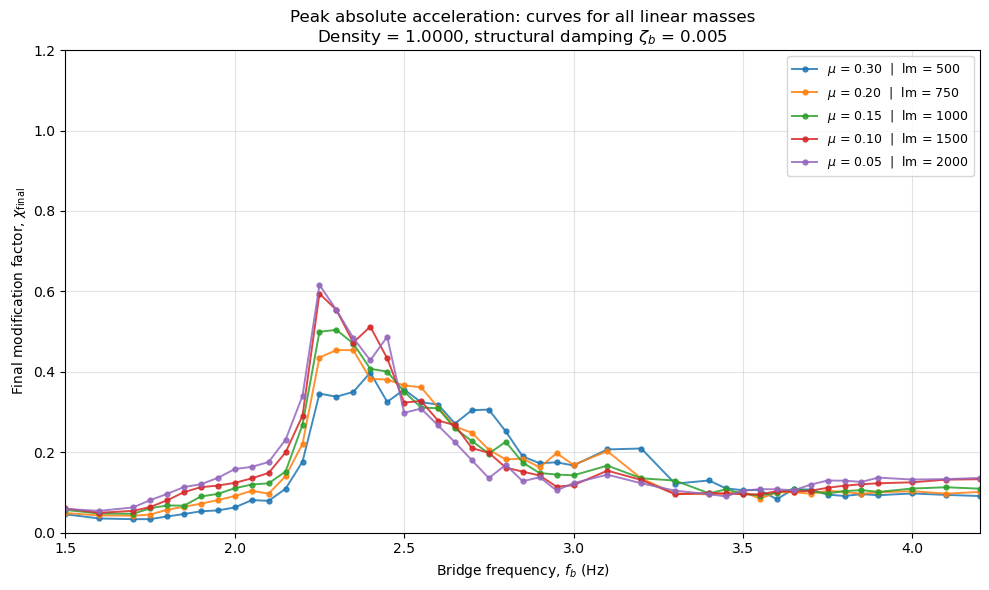

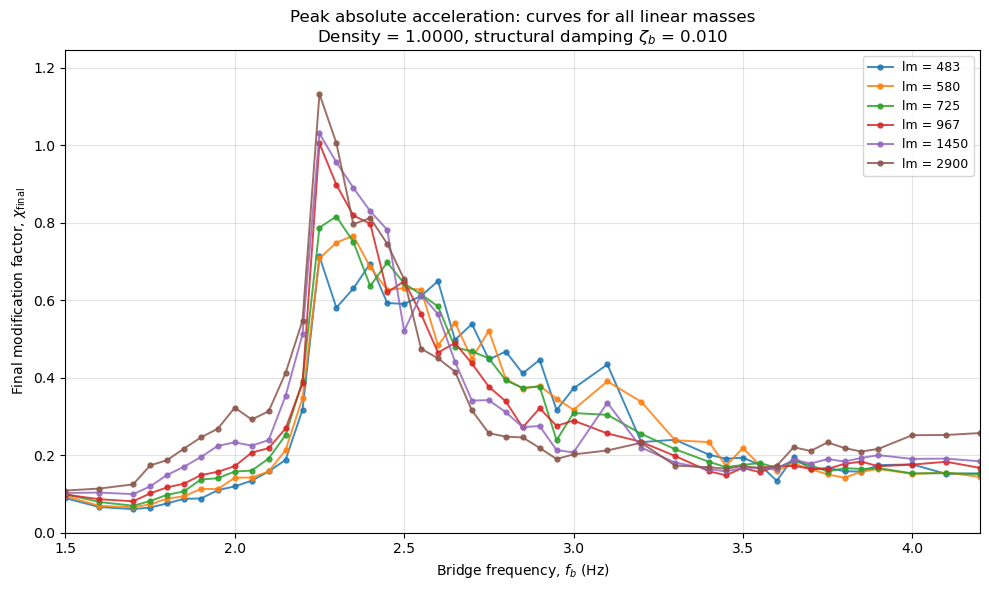

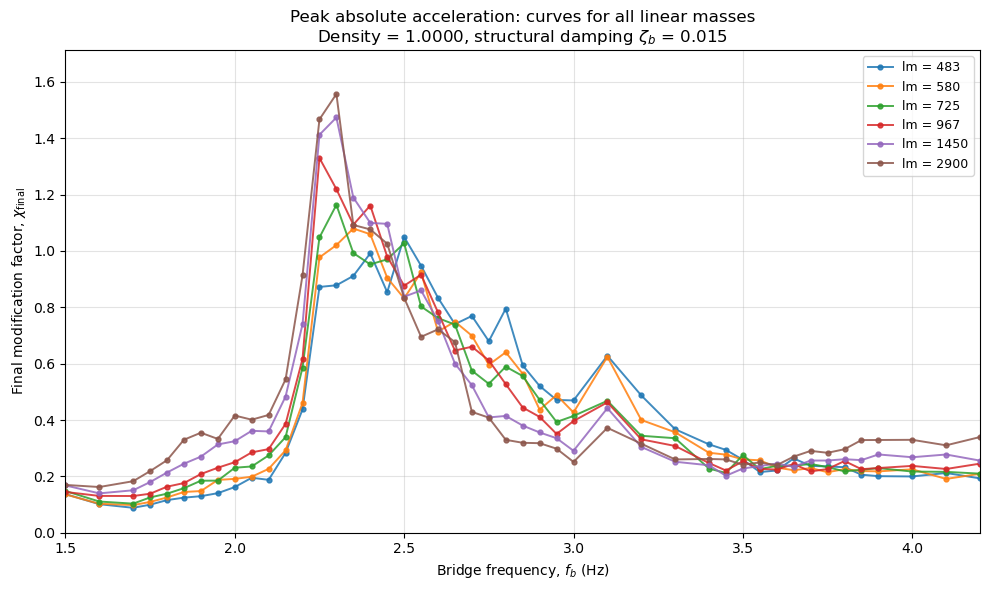

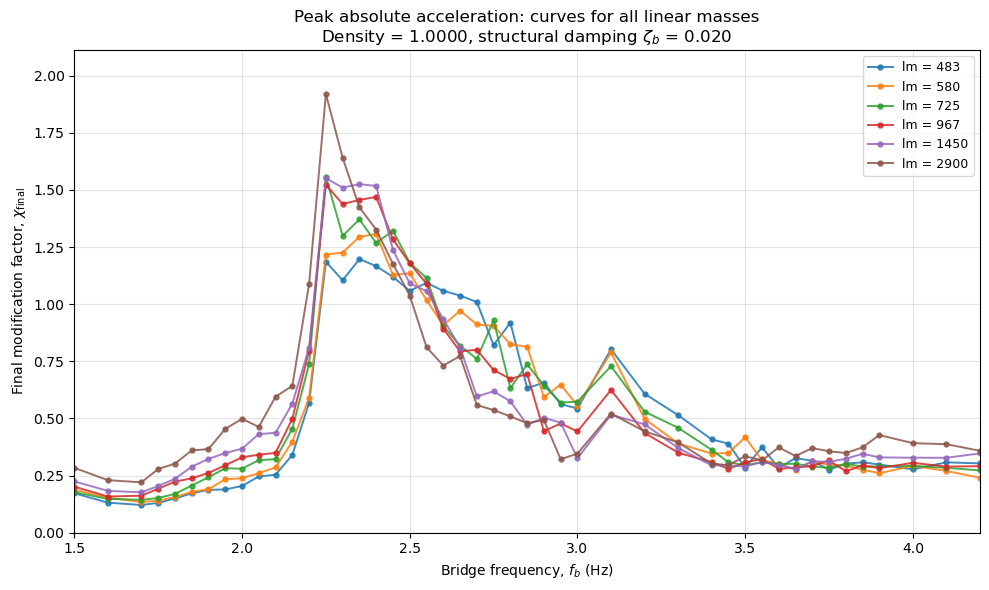

In [43]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DENSITY = 1.0000

TARGET_DAMPINGS = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]
# Or use all damping ratios found:
# TARGET_DAMPINGS = None

MEASURE_TO_USE = "Peak absolute acceleration"

# This is the column plotted in your fitting code
Y_COL = "final_modification_factor"

PLOT_FMIN = 1.50
PLOT_FMAX = 4.20

SAVE_FIGURES = False
FIG_DPI = 300

# Optional labels for legend.
# Edit these if your lm-to-mass-ratio mapping is different.
linear_mass_to_mass_ratio = {
    500: 0.30,
    750: 0.20,
    1000: 0.15,
    1500: 0.10,
    2000: 0.05,
    3000: 0.05,
}

# ==================================================
# LOAD lm FILES
# Expected:
# density1.0000_damping0.005_lm500_bias_summary.pkl
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"lm(?P<linear_mass>\d+)_"
    r"bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_lm*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:

    match = pattern.match(file.name)

    if match is None:
        print("Skipping unmatched file:", file.name)
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_linear_mass = int(match.group("linear_mass"))

    if not np.isclose(file_density, TARGET_DENSITY):
        continue

    if TARGET_DAMPINGS is not None:
        if not any(np.isclose(file_damping, d) for d in TARGET_DAMPINGS):
            continue

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["linear_mass"] = file_linear_mass

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError(
        "No matching lm files found. Check that files like "
        "'density1.0000_damping0.005_lm500_bias_summary.pkl' are in this folder."
    )

plot_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded dataframe shape:", plot_df.shape)
print("\nColumns:")
print(plot_df.columns.tolist())


# ==================================================
# CLEAN DATA
# ==================================================

needed_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "linear_mass",
    Y_COL,
]

for col in needed_cols:
    if col not in plot_df.columns:
        raise KeyError(f"Missing required column: {col}")

    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

plot_df = plot_df.dropna(subset=needed_cols).copy()

# Keep only the required measure if a measure column exists
if "measure" in plot_df.columns:
    plot_df = plot_df[
        plot_df["measure"].astype(str).str.strip().eq(MEASURE_TO_USE)
    ].copy()

    if plot_df.empty:
        raise ValueError(
            f"No rows found for measure = '{MEASURE_TO_USE}'. "
            "Check the exact text in the measure column."
        )

plot_df["density_key"] = plot_df["target_density"].round(4)
plot_df["damping_key"] = plot_df["target_beamdamp"].round(3)
plot_df["linear_mass_key"] = plot_df["linear_mass"].round(0).astype(int)

# Add mass-ratio label from lm value
plot_df["mass_ratio_label"] = plot_df["linear_mass_key"].map(linear_mass_to_mass_ratio)

# Frequency filter
plot_df = plot_df[
    (plot_df["bridge_frequency"] >= PLOT_FMIN) &
    (plot_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

# Important:
# Average only exact duplicate points.
# Do NOT group by mass ratio from dataframe.
plot_df = (
    plot_df
    .groupby(
        ["damping_key", "linear_mass_key", "bridge_frequency"],
        as_index=False
    )
    .agg(
        y_value=(Y_COL, "mean"),
        mass_ratio_label=("mass_ratio_label", "first")
    )
    .sort_values(["damping_key", "linear_mass_key", "bridge_frequency"])
)

print("\nFinal plotting dataframe shape:", plot_df.shape)

print("\nFrequency coverage:")
coverage = (
    plot_df
    .groupby(["damping_key", "linear_mass_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)
print(coverage)

print("\nAvailable damping ratios:")
print(sorted(plot_df["damping_key"].unique()))

print("\nAvailable linear masses:")
print(sorted(plot_df["linear_mass_key"].unique()))


# ==================================================
# PLOT: ONE GRAPH PER DAMPING RATIO
# EACH GRAPH HAS ALL LINEAR MASSES / MASS RATIOS
# ==================================================

for damping in sorted(plot_df["damping_key"].unique()):

    damping_df = plot_df[
        np.isclose(plot_df["damping_key"], damping)
    ].copy()

    if damping_df.empty:
        continue

    plt.figure(figsize=(10, 6))

    for lm in sorted(damping_df["linear_mass_key"].unique()):

        sub = damping_df[
            damping_df["linear_mass_key"] == lm
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        mu_values = sub["mass_ratio_label"].dropna().unique()

        if len(mu_values) > 0:
            label = rf"$\mu$ = {mu_values[0]:.2f}  |  lm = {lm}"
        else:
            label = f"lm = {lm}"

        plt.plot(
            sub["bridge_frequency"],
            sub["y_value"],
            marker="o",
            markersize=3.5,
            linewidth=1.4,
            alpha=0.85,
            label=label
        )

    plt.xlabel(r"Bridge frequency, $f_b$ (Hz)")
    plt.ylabel(r"Final modification factor, $\chi_{\mathrm{final}}$")

    plt.title(
        "Peak absolute acceleration: curves for all linear masses\n"
        rf"Density = {TARGET_DENSITY:.4f}, structural damping $\zeta_b$ = {damping:.3f}"
    )

    plt.xlim(PLOT_FMIN, PLOT_FMAX)

    ymax = np.nanmax(damping_df["y_value"])
    plt.ylim(0, max(1.2, 1.10 * ymax))

    plt.grid(True, alpha=0.35)
    plt.legend(loc="upper right", fontsize=9)

    plt.tight_layout()

    if SAVE_FIGURES:
        save_name = (
            f"density{TARGET_DENSITY:.4f}_"
            f"damping{damping:.3f}_all_lm_curves.png"
        )
        plt.savefig(save_name, dpi=FIG_DPI, bbox_inches="tight")
        print("Saved:", save_name)

    plt.show()

Loaded: NMFR_2.pkl
Bands: ['1.25_to_4.60']
Densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]
Damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]


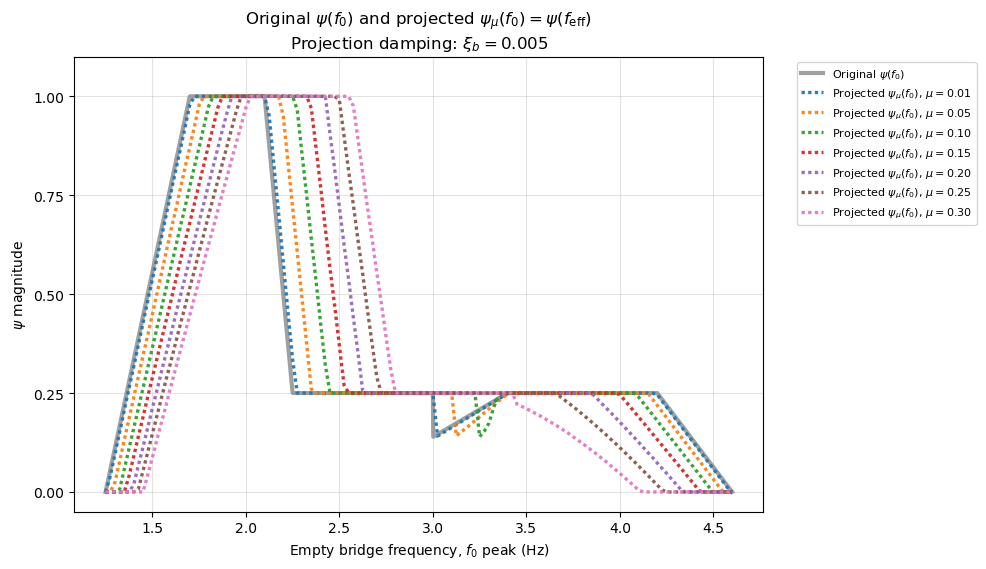

In [44]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# LOAD SAVED NMFR RESULTS
# ==================================================

pkl_file = "NMFR_2.pkl"

with open(pkl_file, "rb") as f:
    saved = pickle.load(f)

results_all = saved["results_all"]
frequency_bands = saved["frequency_bands"]
densities = saved["densities"]
damping_values = saved["damping_values"]

bands_to_combine = list(frequency_bands.keys())

print("Loaded:", pkl_file)
print("Bands:", bands_to_combine)
print("Densities:", densities)
print("Damping values:", damping_values)


# ==================================================
# DENSITY TO MASS RATIO LABEL
# ==================================================

mass_ratio_label = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
    1.0:    0.30,
}


# ==================================================
# UPDATED ORIGINAL PSI FUNCTION
# Minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz
# ==================================================

def psi_original(f):
    """
    Original pedestrian excitation reduction function ψ(f),
    with minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz.
    """

    f = np.asarray(f, dtype=float)
    psi = np.zeros_like(f)

    # 1.25–1.70 Hz : ramp from 0 to 1
    m = (f >= 1.25) & (f < 1.70)
    psi[m] = (f[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 Hz : full value = 1
    m = (f >= 1.70) & (f <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 Hz : ramp from 1 to 0
    m = (f > 2.10) & (f <= 2.30)
    psi[m] = (2.30 - f[m]) / (2.30 - 2.10)

    # 2.30–2.50 Hz : zero
    m = (f > 2.30) & (f < 2.50)
    psi[m] = 0.0

    # 2.50–3.40 Hz : ramp from 0 to 0.25
    m = (f >= 2.50) & (f < 3.40)
    psi[m] = 0.25 * (f[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 Hz : constant 0.25
    m = (f >= 3.40) & (f <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 Hz : ramp from 0.25 to 0
    m = (f > 4.20) & (f <= 4.60)
    psi[m] = 0.25 * (4.60 - f[m]) / (4.60 - 4.20)

    # Minimum ψ = 0.25 for 2.25 Hz <= f <= 3.00 Hz
    m = (f >= 2.25) & (f <= 3.00)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi


# ==================================================
# HELPER FUNCTION: COLLECT f0_peak AND f_eff_peak
# ==================================================

def collect_f0_feff(results_all, bands_to_combine, beamdamp, density):
    x_vals = []
    y_vals = []

    for band_name in bands_to_combine:

        if band_name not in results_all:
            continue

        if beamdamp not in results_all[band_name]:
            continue

        freq_dict = results_all[band_name][beamdamp]

        for bf in sorted(freq_dict.keys()):

            if density not in freq_dict[bf]:
                continue

            data = freq_dict[bf][density]

            f0_arr = np.asarray(data["f0_peak"], dtype=float).reshape(-1)
            feff_arr = np.asarray(data["f_eff_peak"], dtype=float).reshape(-1)

            valid = np.isfinite(f0_arr) & np.isfinite(feff_arr)

            if np.any(valid):
                x_vals.append(np.nanmean(f0_arr[valid]))
                y_vals.append(np.nanmean(feff_arr[valid]))

    x_vals = np.asarray(x_vals)
    y_vals = np.asarray(y_vals)

    if len(x_vals) == 0:
        return x_vals, y_vals

    order = np.argsort(x_vals)
    return x_vals[order], y_vals[order]


# ==================================================
# SETTINGS
# ==================================================

PROJECT_DAMPING = 0.005

default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

density_to_color = {
    density: default_colors[i % len(default_colors)]
    for i, density in enumerate(densities)
}


# ==================================================
# PLOT ORIGINAL PSI AND PROJECTED PSI ONLY
# ==================================================

fig, ax = plt.subplots(figsize=(10, 5.8))

# --------------------------------------------------
# Determine frequency range from projected data
# --------------------------------------------------

all_f0 = []

for density in densities:

    x_vals, feff_vals = collect_f0_feff(
        results_all=results_all,
        bands_to_combine=bands_to_combine,
        beamdamp=PROJECT_DAMPING,
        density=density
    )

    if len(x_vals) > 0:
        all_f0.extend(x_vals)

all_f0 = np.asarray(all_f0, dtype=float)

lo = np.nanmin(all_f0)
hi = np.nanmax(all_f0)


# --------------------------------------------------
# Original psi:
# x = f0
# y = psi_original(f0)
# --------------------------------------------------

f_grid = np.linspace(lo, hi, 1500)
psi_grid = psi_original(f_grid)

ax.plot(
    f_grid,
    psi_grid,
    color="gray",
    linestyle="-",
    linewidth=3.0,
    alpha=0.75,
    label=r"Original $\psi(f_0)$"
)


# --------------------------------------------------
# Projected psi:
# x = f0
# y = psi_original(f_eff(f0, mu, xi_b))
# --------------------------------------------------

for density in densities:

    color = density_to_color[density]
    mu_val = mass_ratio_label.get(round(float(density), 4), density)

    x_vals, feff_vals = collect_f0_feff(
        results_all=results_all,
        bands_to_combine=bands_to_combine,
        beamdamp=PROJECT_DAMPING,
        density=density
    )

    if len(x_vals) == 0:
        print(f"No projected psi data for density={density}, damping={PROJECT_DAMPING}")
        continue

    x_vals = np.asarray(x_vals, dtype=float)
    feff_vals = np.asarray(feff_vals, dtype=float)

    order = np.argsort(x_vals)
    x_vals = x_vals[order]
    feff_vals = feff_vals[order]

    psi_projected = psi_original(feff_vals)

    ax.plot(
        x_vals,
        psi_projected,
        color=color,
        linestyle=(0, (1, 1)),
        linewidth=2.4,
        alpha=0.95,
        label=fr"Projected $\psi_\mu(f_0)$, $\mu={mu_val:.2f}$"
    )


# ==================================================
# FORMATTING
# ==================================================

ax.set_xlabel(r"Empty bridge frequency, $f_0$ peak (Hz)")
ax.set_ylabel(r"$\psi$ magnitude")

ax.set_title(
    r"Original $\psi(f_0)$ and projected $\psi_\mu(f_0)=\psi(f_{\mathrm{eff}})$"
    "\n"
    fr"Projection damping: $\xi_b={PROJECT_DAMPING:.3f}$"
)

ax.set_ylim(-0.05, 1.10)
ax.set_yticks([0.00, 0.25, 0.50, 0.75, 1.00])

ax.grid(True, alpha=0.35)

ax.legend(
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
    fontsize=8,
    frameon=True
)

plt.tight_layout()
plt.show()

Loaded: NMFR_2.pkl
NMFR densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]
NMFR damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Loading: density1.0000_damping0.005_lm1000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm1500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm2000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm750_bias_summary.pkl
Loading: density1.0000_damping0.010_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.010_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.010_lm483_bias_summary.pkl
Loading: density1.0000_damping0.010_lm580_bias_summary.pkl
Loading: density1.0000_damping0.010_lm725_bias_summary.pkl
Loading: density1.0000_damping0.010_lm967_bias_summary.pkl
Loading: density1.0000_damping0.015_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.015_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.015_lm483_bias_summary.pkl
Loading: density1.00

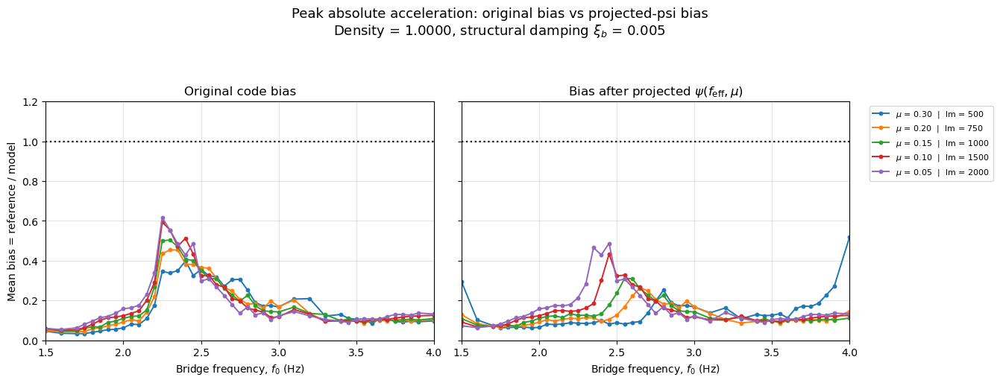

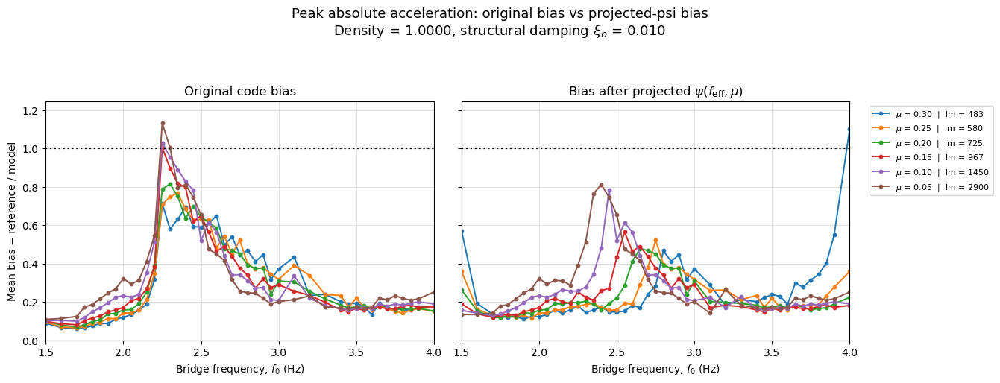

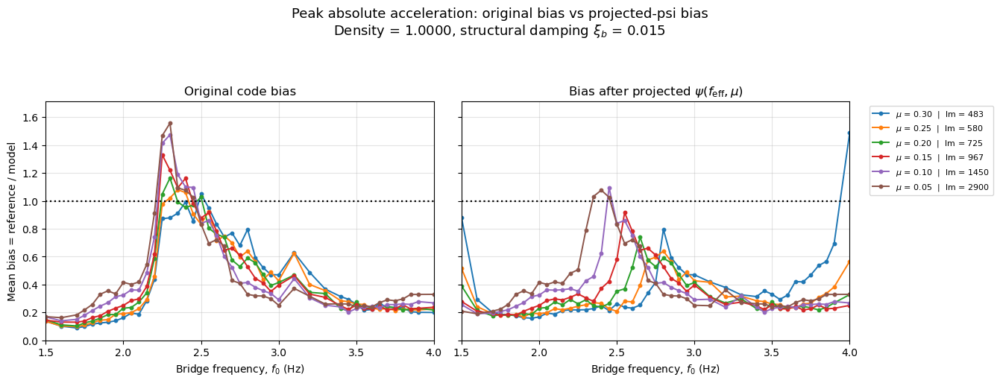

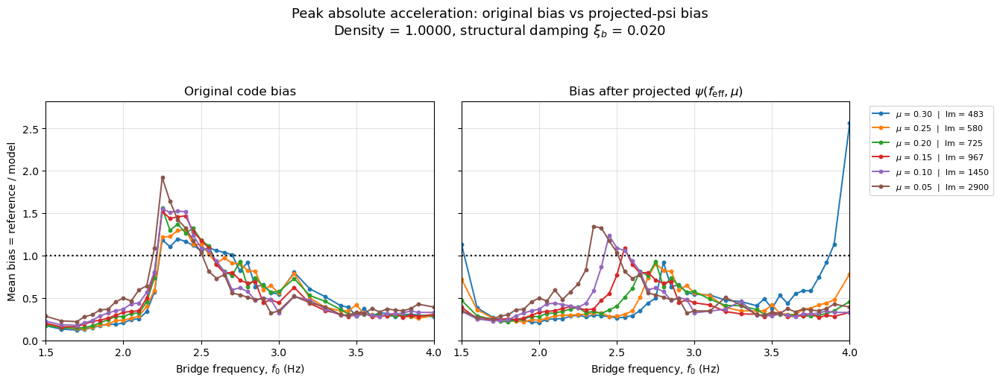

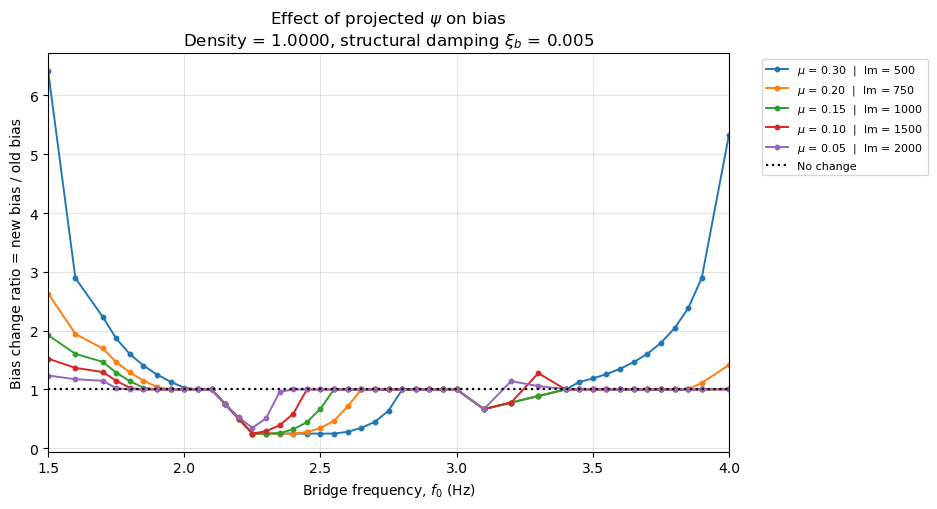

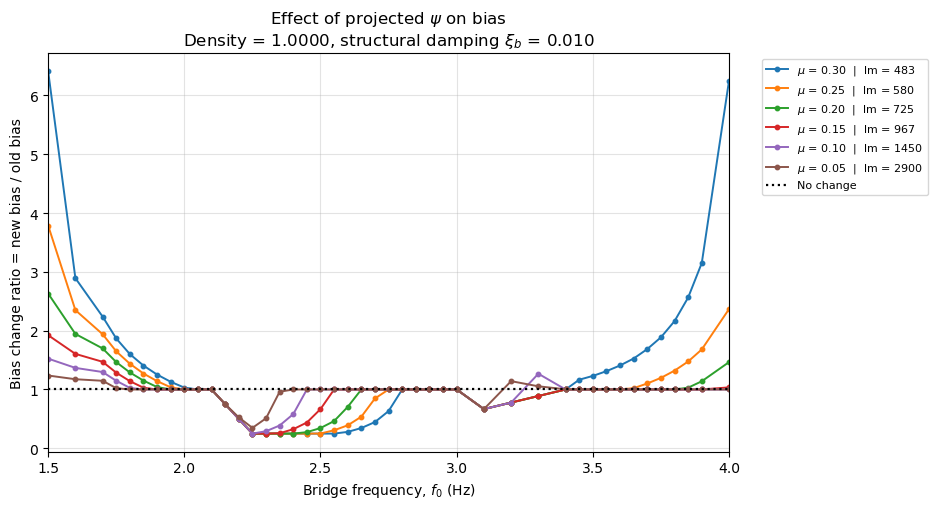

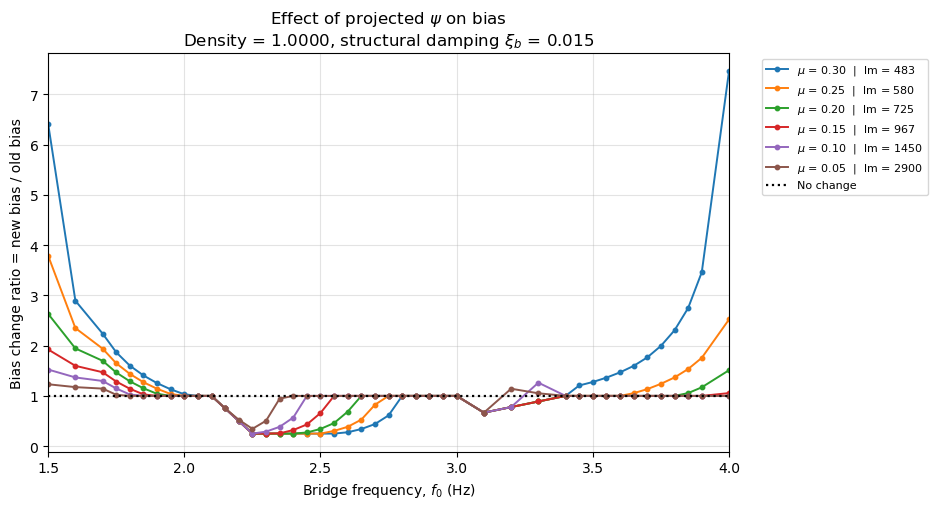

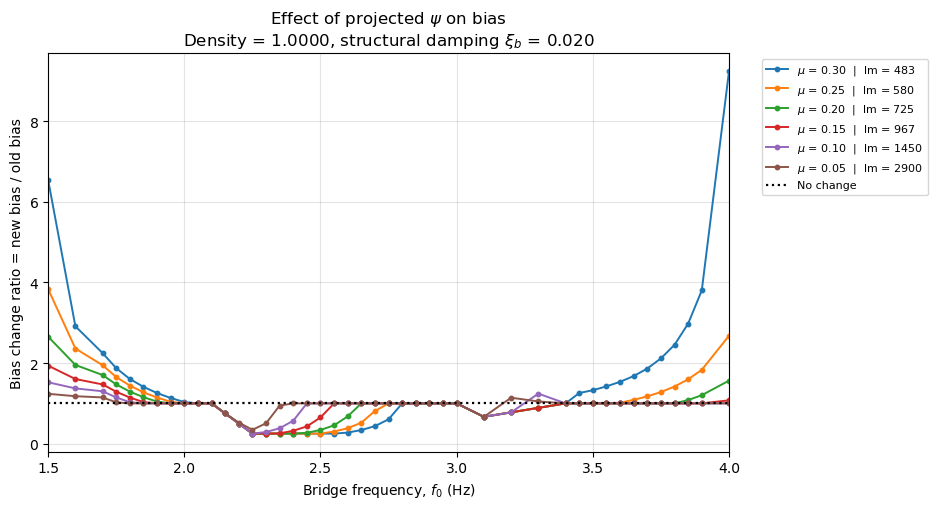

In [45]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

NMFR_FILE = "NMFR_2.pkl"

TARGET_DENSITY = 1.0000

TARGET_DAMPINGS = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]
# Use None to load all damping ratios found:
# TARGET_DAMPINGS = None

MEASURE_TO_USE = "Peak absolute acceleration"

# This is the column you plotted in your previous graph.
# It is treated as old bias / old correction factor.
OLD_BIAS_COL = "final_modification_factor"

PLOT_FMIN = 1.50
PLOT_FMAX = 4.00

SAVE_FIGURES = False
FIG_DPI = 300

PSI_EPS = 1e-8


# ==================================================
# LINEAR MASS TO MASS RATIO
# Edit this table only if your lm values are different.
# ==================================================

linear_mass_to_mass_ratio = {
    483:  0.30,
    500:  0.30,

    580:  0.25,

    725:  0.20,
    750:  0.20,

    967:  0.15,
    1000: 0.15,

    1450: 0.10,
    1500: 0.10,

    2000: 0.05,
    2900: 0.05,
}


# ==================================================
# MASS RATIO TO NMFR DENSITY
# Because NMFR_2.pkl was stored by density, not by lm.
# ==================================================

mass_ratio_to_nmfr_density = {
    0.01: 0.0333,
    0.05: 0.1667,
    0.10: 0.3333,
    0.15: 0.5000,
    0.20: 0.6667,
    0.25: 0.8333,
    0.30: 1.0000,
}


# ==================================================
# ORIGINAL PSI FUNCTION
# ==================================================

def psi_original(f):
    """
    Original pedestrian excitation reduction function ψ(f),
    with minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz.
    """

    f = np.asarray(f, dtype=float)
    psi = np.zeros_like(f)

    # 1.25–1.70 Hz : ramp from 0 to 1
    m = (f >= 1.25) & (f < 1.70)
    psi[m] = (f[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 Hz : full value = 1
    m = (f >= 1.70) & (f <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 Hz : ramp from 1 to 0
    m = (f > 2.10) & (f <= 2.30)
    psi[m] = (2.30 - f[m]) / (2.30 - 2.10)

    # 2.30–2.50 Hz : zero
    m = (f > 2.30) & (f < 2.50)
    psi[m] = 0.0

    # 2.50–3.40 Hz : ramp from 0 to 0.25
    m = (f >= 2.50) & (f < 3.40)
    psi[m] = 0.25 * (f[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 Hz : constant 0.25
    m = (f >= 3.40) & (f <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 Hz : ramp from 0.25 to 0
    m = (f > 4.20) & (f <= 4.60)
    psi[m] = 0.25 * (4.60 - f[m]) / (4.60 - 4.20)

    # Minimum ψ = 0.25 for 2.25 Hz <= f <= 3.00 Hz
    m = (f >= 2.25) & (f <= 3.00)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi


# ==================================================
# HELPER: FIND NEAREST FLOAT KEY IN NESTED DICTS
# ==================================================

def nearest_float_key(mapping, target, tol=1e-4):
    keys = list(mapping.keys())
    key_vals = np.asarray([float(k) for k in keys], dtype=float)

    idx = np.argmin(np.abs(key_vals - target))

    if abs(key_vals[idx] - target) > tol:
        return None

    return keys[idx]


def nearest_mu_key(mu):
    mu_keys = np.asarray(list(mass_ratio_to_nmfr_density.keys()), dtype=float)
    idx = np.argmin(np.abs(mu_keys - mu))
    return float(mu_keys[idx])


# ==================================================
# LOAD NMFR RESULTS
# ==================================================

with open(NMFR_FILE, "rb") as f:
    saved = pickle.load(f)

results_all = saved["results_all"]
frequency_bands = saved["frequency_bands"]
densities = saved["densities"]
damping_values = saved["damping_values"]

bands_to_combine = list(frequency_bands.keys())

print("Loaded:", NMFR_FILE)
print("NMFR densities:", densities)
print("NMFR damping values:", damping_values)


# ==================================================
# COLLECT f0 AND f_eff FROM NMFR
# ==================================================

def collect_f0_feff(results_all, bands_to_combine, beamdamp, nmfr_density):
    x_vals = []
    y_vals = []

    for band_name in bands_to_combine:

        if band_name not in results_all:
            continue

        damp_key = nearest_float_key(results_all[band_name], beamdamp, tol=5e-4)

        if damp_key is None:
            continue

        freq_dict = results_all[band_name][damp_key]

        for bf in sorted(freq_dict.keys()):

            density_key = nearest_float_key(freq_dict[bf], nmfr_density, tol=5e-4)

            if density_key is None:
                continue

            data = freq_dict[bf][density_key]

            f0_arr = np.asarray(data["f0_peak"], dtype=float).reshape(-1)
            feff_arr = np.asarray(data["f_eff_peak"], dtype=float).reshape(-1)

            valid = np.isfinite(f0_arr) & np.isfinite(feff_arr)

            if np.any(valid):
                x_vals.append(np.nanmean(f0_arr[valid]))
                y_vals.append(np.nanmean(feff_arr[valid]))

    x_vals = np.asarray(x_vals, dtype=float)
    y_vals = np.asarray(y_vals, dtype=float)

    if len(x_vals) == 0:
        return x_vals, y_vals

    temp = (
        pd.DataFrame({
            "f0": x_vals,
            "feff": y_vals
        })
        .dropna()
        .groupby("f0", as_index=False)
        .agg(feff=("feff", "mean"))
        .sort_values("f0")
    )

    return temp["f0"].to_numpy(), temp["feff"].to_numpy()


def interpolate_feff(f0_query, beamdamp, mu):
    """
    For a given damping and mass ratio,
    interpolate f_eff from NMFR results.
    """

    mu_key = nearest_mu_key(mu)
    nmfr_density = mass_ratio_to_nmfr_density[mu_key]

    x_nmfr, feff_nmfr = collect_f0_feff(
        results_all=results_all,
        bands_to_combine=bands_to_combine,
        beamdamp=beamdamp,
        nmfr_density=nmfr_density
    )

    if len(x_nmfr) < 2:
        raise ValueError(
            f"Not enough NMFR data for damping={beamdamp:.3f}, "
            f"mu={mu:.3f}, NMFR density={nmfr_density:.4f}"
        )

    return np.interp(
        f0_query,
        x_nmfr,
        feff_nmfr,
        left=feff_nmfr[0],
        right=feff_nmfr[-1]
    )


# ==================================================
# LOAD lm BIAS FILES
# Expected:
# density1.0000_damping0.005_lm483_bias_summary.pkl
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"lm(?P<linear_mass>\d+)_"
    r"bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_lm*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:

    match = pattern.match(file.name)

    if match is None:
        print("Skipping unmatched file:", file.name)
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_linear_mass = int(match.group("linear_mass"))

    if not np.isclose(file_density, TARGET_DENSITY):
        continue

    if TARGET_DAMPINGS is not None:
        if not any(np.isclose(file_damping, d) for d in TARGET_DAMPINGS):
            continue

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["linear_mass"] = file_linear_mass

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching lm bias summary files found.")

raw_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded lm dataframe shape:", raw_df.shape)
print("\nColumns:")
print(raw_df.columns.tolist())


# ==================================================
# CLEAN lm DATA
# ==================================================

needed_cols = [
    "bridge_frequency",
    "target_beamdamp",
    "linear_mass",
    OLD_BIAS_COL,
]

for col in needed_cols:
    if col not in raw_df.columns:
        raise KeyError(f"Missing required column: {col}")

    raw_df[col] = pd.to_numeric(raw_df[col], errors="coerce")

raw_df = raw_df.dropna(subset=needed_cols).copy()

# Keep peak absolute acceleration only
if "measure" in raw_df.columns:
    raw_df = raw_df[
        raw_df["measure"].astype(str).str.strip().eq(MEASURE_TO_USE)
    ].copy()

    if raw_df.empty:
        raise ValueError(
            f"No rows found for measure = '{MEASURE_TO_USE}'."
        )

raw_df["damping_key"] = raw_df["target_beamdamp"].round(3)
raw_df["linear_mass_key"] = raw_df["linear_mass"].round(0).astype(int)

raw_df = raw_df[
    (raw_df["bridge_frequency"] >= PLOT_FMIN) &
    (raw_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

# --------------------------------------------------
# Assign one stable mass ratio per lm.
# Prefer your manual lm map, because grouping by row-wise
# mean_modal_mass_ratio can split a curve into one-point pieces.
# --------------------------------------------------

raw_df["mass_ratio"] = raw_df["linear_mass_key"].map(linear_mass_to_mass_ratio)

missing_lm = sorted(
    raw_df.loc[raw_df["mass_ratio"].isna(), "linear_mass_key"].unique()
)

if len(missing_lm) > 0:
    raise ValueError(
        "These linear masses are missing from linear_mass_to_mass_ratio:\n"
        f"{missing_lm}\n\n"
        "Add them to the dictionary near the top."
    )

# Average only exact duplicate points
compare_df = (
    raw_df
    .groupby(
        ["damping_key", "linear_mass_key", "mass_ratio", "bridge_frequency"],
        as_index=False
    )
    .agg(old_bias=(OLD_BIAS_COL, "mean"))
    .sort_values(
        ["damping_key", "linear_mass_key", "bridge_frequency"]
    )
)

print("\nFinal comparison dataframe shape:", compare_df.shape)

print("\nAvailable lm and mass-ratio mapping:")
print(
    compare_df[["linear_mass_key", "mass_ratio"]]
    .drop_duplicates()
    .sort_values("mass_ratio", ascending=False)
    .to_string(index=False)
)

print("\nFrequency coverage:")
coverage = (
    compare_df
    .groupby(["damping_key", "linear_mass_key", "mass_ratio"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)
print(coverage)


# ==================================================
# COMPUTE NEW PROJECTED-PSI BIAS
# ==================================================

compare_df["psi_old"] = psi_original(compare_df["bridge_frequency"].to_numpy())

compare_df["f_eff_interp"] = np.nan
compare_df["psi_new"] = np.nan

for (damping, lm, mu), idx in compare_df.groupby(
    ["damping_key", "linear_mass_key", "mass_ratio"]
).groups.items():

    sub = compare_df.loc[idx].copy()

    f0 = sub["bridge_frequency"].to_numpy(dtype=float)

    feff = interpolate_feff(
        f0_query=f0,
        beamdamp=float(damping),
        mu=float(mu)
    )

    psi_new = psi_original(feff)

    compare_df.loc[idx, "f_eff_interp"] = feff
    compare_df.loc[idx, "psi_new"] = psi_new

# Safe ratio
psi_old_safe = np.maximum(compare_df["psi_old"].to_numpy(dtype=float), PSI_EPS)
psi_new_safe = np.maximum(compare_df["psi_new"].to_numpy(dtype=float), PSI_EPS)

compare_df["psi_scale_new_over_old"] = psi_new_safe / psi_old_safe

# Since bias = reference / model:
compare_df["new_bias_projected_psi"] = (
    compare_df["old_bias"] * psi_old_safe / psi_new_safe
)

compare_df["bias_ratio_new_over_old"] = (
    compare_df["new_bias_projected_psi"] / compare_df["old_bias"]
)

compare_df.to_csv(
    "old_vs_projected_psi_bias_from_lm_files.csv",
    index=False
)

print("\nSaved: old_vs_projected_psi_bias_from_lm_files.csv")


# ==================================================
# PLOT OLD BIAS VS NEW PROJECTED-PSI BIAS
# One figure per damping ratio.
# Each figure has all lm / mass-ratio lines.
# ==================================================

for damping in sorted(compare_df["damping_key"].unique()):

    damp_df = compare_df[
        np.isclose(compare_df["damping_key"], damping)
    ].copy()

    if damp_df.empty:
        continue

    fig, axes = plt.subplots(
        1, 2,
        figsize=(13.5, 5.2),
        sharex=True,
        sharey=True
    )

    plot_specs = [
        ("old_bias", "Original code bias"),
        ("new_bias_projected_psi", r"Bias after projected $\psi(f_{\mathrm{eff}},\mu)$"),
    ]

    for ax, (y_col, title) in zip(axes, plot_specs):

        for lm in sorted(damp_df["linear_mass_key"].unique()):

            sub = damp_df[
                damp_df["linear_mass_key"] == lm
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            mu = sub["mass_ratio"].iloc[0]

            ax.plot(
                sub["bridge_frequency"],
                sub[y_col],
                marker="o",
                markersize=3.2,
                linewidth=1.4,
                label=rf"$\mu$ = {mu:.2f}  |  lm = {lm}"
            )

        ax.axhline(
            1.0,
            linestyle=":",
            linewidth=1.6,
            color="black"
        )

        ax.set_title(title)
        ax.set_xlabel(r"Bridge frequency, $f_0$ (Hz)")
        ax.grid(True, alpha=0.35)
        ax.set_xlim(PLOT_FMIN, PLOT_FMAX)

    axes[0].set_ylabel("Mean bias = reference / model")

    ymax = np.nanmax(
        compare_df.loc[
            np.isclose(compare_df["damping_key"], damping),
            ["old_bias", "new_bias_projected_psi"]
        ].to_numpy()
    )

    axes[0].set_ylim(0, max(1.2, 1.10 * ymax))

    axes[1].legend(
        bbox_to_anchor=(1.04, 1),
        loc="upper left",
        fontsize=8,
        frameon=True
    )

    fig.suptitle(
        "Peak absolute acceleration: original bias vs projected-psi bias\n"
        rf"Density = {TARGET_DENSITY:.4f}, structural damping $\xi_b$ = {damping:.3f}",
        fontsize=13
    )

    fig.tight_layout(rect=[0, 0, 1, 0.92])

    if SAVE_FIGURES:
        save_name = (
            f"old_vs_projected_psi_bias_"
            f"density{TARGET_DENSITY:.4f}_damping{damping:.3f}.png"
        )
        plt.savefig(save_name, dpi=FIG_DPI, bbox_inches="tight")
        print("Saved:", save_name)

    plt.show()


# ==================================================
# OPTIONAL: PLOT HOW MUCH THE BIAS CHANGES
# new_bias / old_bias
# ==================================================

for damping in sorted(compare_df["damping_key"].unique()):

    damp_df = compare_df[
        np.isclose(compare_df["damping_key"], damping)
    ].copy()

    plt.figure(figsize=(9.5, 5.2))

    for lm in sorted(damp_df["linear_mass_key"].unique()):

        sub = damp_df[
            damp_df["linear_mass_key"] == lm
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        mu = sub["mass_ratio"].iloc[0]

        plt.plot(
            sub["bridge_frequency"],
            sub["bias_ratio_new_over_old"],
            marker="o",
            markersize=3.2,
            linewidth=1.4,
            label=rf"$\mu$ = {mu:.2f}  |  lm = {lm}"
        )

    plt.axhline(
        1.0,
        linestyle=":",
        linewidth=1.6,
        color="black",
        label="No change"
    )

    plt.xlabel(r"Bridge frequency, $f_0$ (Hz)")
    plt.ylabel(r"Bias change ratio = new bias / old bias")

    plt.title(
        r"Effect of projected $\psi$ on bias"
        "\n"
        rf"Density = {TARGET_DENSITY:.4f}, structural damping $\xi_b$ = {damping:.3f}"
    )

    plt.xlim(PLOT_FMIN, PLOT_FMAX)
    plt.grid(True, alpha=0.35)
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=8)

    plt.tight_layout()
    plt.show()

Loaded: NMFR_2.pkl
Bands: ['1.25_to_4.60']
Densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]
Damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]

Collected curves: 8
Envelope data points: 5000

Optimised breakpoints
---------------------
a = 1.700000
b = 2.567634
c = 2.793735
d = 4.200000

Objective value: 1.1616063031133033e-06

Piecewise-linear envelope:
--------------------------
For 1.2500 <= f0 <= 1.7000: psi_env(f0) = 2.222222 * f0 + -2.777778
For 1.7000 <= f0 <= 2.5676: psi_env(f0) = 0.000000 * f0 + 1.000000
For 2.5676 <= f0 <= 2.7937: psi_env(f0) = -3.317111 * f0 + 9.517127
For 2.7937 <= f0 <= 4.2000: psi_env(f0) = 0.000000 * f0 + 0.250000
For 4.2000 <= f0 <= 4.6000: psi_env(f0) = -0.625000 * f0 + 2.875000


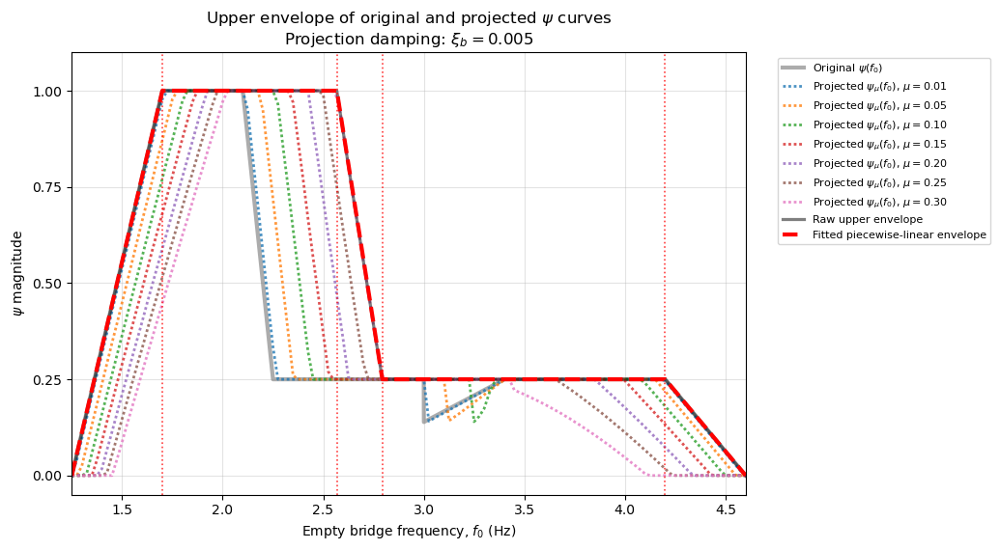


Manual breakpoints you suggested
--------------------------------
a = 1.7109
b = 2.4968
c = 2.7130
d = 4.1928

Manual piecewise-linear envelope:
---------------------------------
For 1.2500 <= f0 <= 1.7109: psi_env_manual(f0) = 2.169668 * f0 + -2.712085
For 1.7109 <= f0 <= 2.4968: psi_env_manual(f0) = 0.000000 * f0 + 1.000000
For 2.4968 <= f0 <= 2.7130: psi_env_manual(f0) = -3.469010 * f0 + 9.661425
For 2.7130 <= f0 <= 4.1928: psi_env_manual(f0) = 0.000000 * f0 + 0.250000
For 4.1928 <= f0 <= 4.6000: psi_env_manual(f0) = -0.613949 * f0 + 2.824165


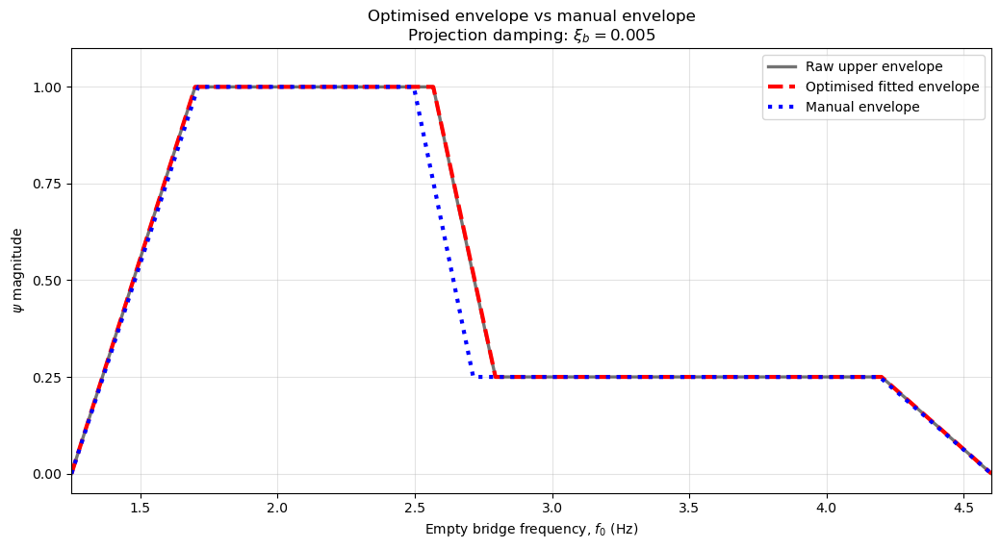

In [46]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution, minimize


# ==================================================
# LOAD SAVED NMFR RESULTS
# ==================================================

pkl_file = "NMFR_2.pkl"

with open(pkl_file, "rb") as f:
    saved = pickle.load(f)

results_all = saved["results_all"]
frequency_bands = saved["frequency_bands"]
densities = saved["densities"]
damping_values = saved["damping_values"]

bands_to_combine = list(frequency_bands.keys())

print("Loaded:", pkl_file)
print("Bands:", bands_to_combine)
print("Densities:", densities)
print("Damping values:", damping_values)


# ==================================================
# SETTINGS
# ==================================================

PROJECT_DAMPING = 0.005

F_START = 1.25
F_END   = 4.60

PSI_TOP = 1.00
PSI_LOW = 0.25

N_GRID = 5000

INCLUDE_ORIGINAL_PSI_IN_ENVELOPE = True

PENALTY_BELOW = 1e6

PLOT_RAW_PROJECTED_CURVES = True


# ==================================================
# DENSITY TO MASS RATIO LABEL
# ==================================================

mass_ratio_label = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
    1.0:    0.30,
}


# ==================================================
# ORIGINAL PSI FUNCTION
# Minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz
# ==================================================

def psi_original(f):
    """
    Original pedestrian excitation reduction function ψ(f),
    with minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz.
    """

    f = np.asarray(f, dtype=float)
    psi = np.zeros_like(f)

    # 1.25–1.70 Hz : ramp from 0 to 1
    m = (f >= 1.25) & (f < 1.70)
    psi[m] = (f[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 Hz : full value = 1
    m = (f >= 1.70) & (f <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 Hz : ramp from 1 to 0
    m = (f > 2.10) & (f <= 2.30)
    psi[m] = (2.30 - f[m]) / (2.30 - 2.10)

    # 2.30–2.50 Hz : zero
    m = (f > 2.30) & (f < 2.50)
    psi[m] = 0.0

    # 2.50–3.40 Hz : ramp from 0 to 0.25
    m = (f >= 2.50) & (f < 3.40)
    psi[m] = 0.25 * (f[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 Hz : constant 0.25
    m = (f >= 3.40) & (f <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 Hz : ramp from 0.25 to 0
    m = (f > 4.20) & (f <= 4.60)
    psi[m] = 0.25 * (4.60 - f[m]) / (4.60 - 4.20)

    # Minimum ψ = 0.25 for 2.25 Hz <= f <= 3.00 Hz
    m = (f >= 2.25) & (f <= 3.00)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi


# ==================================================
# ROBUST FLOAT-KEY HELPER
# This avoids problems where dictionary keys are 0.005 vs np.float64(0.005)
# ==================================================

def nearest_float_key(mapping, target, tol=1e-6):
    keys = list(mapping.keys())

    if len(keys) == 0:
        return None

    key_vals = np.asarray([float(k) for k in keys], dtype=float)

    idx = np.argmin(np.abs(key_vals - float(target)))

    if abs(key_vals[idx] - float(target)) <= tol:
        return keys[idx]

    return None


# ==================================================
# NEW HELPER FUNCTION
# Do not call it collect_f0_feff, to avoid notebook function conflicts.
# ==================================================

def collect_f0_feff_for_envelope(
    results_all,
    bands_to_combine,
    beamdamp_value,
    density_value,
    key_tol=1e-5
):
    x_vals = []
    y_vals = []

    for band_name in bands_to_combine:

        if band_name not in results_all:
            continue

        damp_key = nearest_float_key(
            results_all[band_name],
            beamdamp_value,
            tol=key_tol
        )

        if damp_key is None:
            continue

        freq_dict = results_all[band_name][damp_key]

        for bf in sorted(freq_dict.keys()):

            density_key = nearest_float_key(
                freq_dict[bf],
                density_value,
                tol=key_tol
            )

            if density_key is None:
                continue

            data = freq_dict[bf][density_key]

            if "f0_peak" not in data or "f_eff_peak" not in data:
                continue

            f0_arr = np.asarray(data["f0_peak"], dtype=float).reshape(-1)
            feff_arr = np.asarray(data["f_eff_peak"], dtype=float).reshape(-1)

            valid = np.isfinite(f0_arr) & np.isfinite(feff_arr)

            if np.any(valid):
                x_vals.append(np.nanmean(f0_arr[valid]))
                y_vals.append(np.nanmean(feff_arr[valid]))

    x_vals = np.asarray(x_vals, dtype=float)
    y_vals = np.asarray(y_vals, dtype=float)

    if len(x_vals) == 0:
        return x_vals, y_vals

    # Average repeated f0 points
    temp = (
        pd.DataFrame({
            "f0": x_vals,
            "feff": y_vals
        })
        .dropna()
        .groupby("f0", as_index=False)
        .agg(feff=("feff", "mean"))
        .sort_values("f0")
    )

    return temp["f0"].to_numpy(), temp["feff"].to_numpy()


# ==================================================
# COLLECT ORIGINAL AND PROJECTED PSI CURVES ON COMMON GRID
# ==================================================

f_grid = np.linspace(F_START, F_END, N_GRID)

curve_list = []
curve_names = []

# Original psi curve
if INCLUDE_ORIGINAL_PSI_IN_ENVELOPE:
    curve_list.append(psi_original(f_grid))
    curve_names.append("Original psi")

# Projected psi curves
projected_curves_for_plot = []

for density in densities:

    x_vals, feff_vals = collect_f0_feff_for_envelope(
        results_all=results_all,
        bands_to_combine=bands_to_combine,
        beamdamp_value=PROJECT_DAMPING,
        density_value=density
    )

    if len(x_vals) < 2:
        print(f"Skipping density={density}: not enough projected data")
        continue

    x_vals = np.asarray(x_vals, dtype=float)
    feff_vals = np.asarray(feff_vals, dtype=float)

    order = np.argsort(x_vals)
    x_vals = x_vals[order]
    feff_vals = feff_vals[order]

    psi_projected_raw = psi_original(feff_vals)

    projected_curves_for_plot.append({
        "density": density,
        "mu": mass_ratio_label.get(round(float(density), 4), density),
        "x_vals": x_vals,
        "feff_vals": feff_vals,
        "psi_projected_raw": psi_projected_raw
    })

    # Interpolate projected psi onto common f0 grid
    feff_interp = np.interp(
        f_grid,
        x_vals,
        feff_vals,
        left=np.nan,
        right=np.nan
    )

    psi_projected_interp = psi_original(feff_interp)

    # Remove extrapolated ends
    psi_projected_interp[~np.isfinite(feff_interp)] = np.nan

    curve_list.append(psi_projected_interp)
    curve_names.append(f"Projected psi density={density}")


if len(curve_list) == 0:
    raise ValueError("No curves were collected. Check PROJECT_DAMPING and NMFR_2.pkl keys.")

curve_array = np.vstack(curve_list)

# Raw upper envelope
psi_env_raw = np.nanmax(curve_array, axis=0)

valid = np.isfinite(psi_env_raw)

f_env_data = f_grid[valid]
psi_env_data = psi_env_raw[valid]

print("\nCollected curves:", len(curve_list))
print("Envelope data points:", len(f_env_data))


# ==================================================
# PIECEWISE-LINEAR ENVELOPE MODEL
#
# Breakpoints:
# a = end of first ramp to 1.0
# b = end of 1.0 plateau
# c = end of ramp down to 0.25
# d = end of 0.25 plateau
# ==================================================

def psi_piecewise_env(f, a, b, c, d):
    f = np.asarray(f, dtype=float)
    psi = np.zeros_like(f)

    # Segment 1:
    # F_START to a, ramp from 0 to 1
    m = (f >= F_START) & (f < a)
    psi[m] = PSI_TOP * (f[m] - F_START) / (a - F_START)

    # Segment 2:
    # a to b, plateau at 1
    m = (f >= a) & (f < b)
    psi[m] = PSI_TOP

    # Segment 3:
    # b to c, ramp from 1 to 0.25
    m = (f >= b) & (f < c)
    psi[m] = PSI_TOP + (PSI_LOW - PSI_TOP) * (f[m] - b) / (c - b)

    # Segment 4:
    # c to d, plateau at 0.25
    m = (f >= c) & (f < d)
    psi[m] = PSI_LOW

    # Segment 5:
    # d to F_END, ramp from 0.25 to 0
    m = (f >= d) & (f <= F_END)
    psi[m] = PSI_LOW * (F_END - f[m]) / (F_END - d)

    return psi


# ==================================================
# OBJECTIVE FUNCTION
# ==================================================

def objective(params):
    a, b, c, d = params

    # Ordering constraint
    if not (F_START < a < b < c < d < F_END):
        return 1e30

    psi_fit = psi_piecewise_env(f_env_data, a, b, c, d)

    residual = psi_fit - psi_env_data

    # Strong penalty if fitted envelope goes below raw upper envelope
    below = np.minimum(residual, 0.0)

    # Small penalty for being unnecessarily above the raw envelope
    above = np.maximum(residual, 0.0)

    obj = (
        PENALTY_BELOW * np.mean(below**2)
        + np.mean(above**2)
    )

    return obj


# ==================================================
# FIT BREAKPOINTS
# ==================================================

bounds = [
    (1.50, 1.90),  # a
    (2.20, 2.70),  # b
    (2.45, 2.95),  # c
    (3.80, 4.40),  # d
]

result_global = differential_evolution(
    objective,
    bounds=bounds,
    seed=42,
    tol=1e-10,
    polish=False,
    updating="immediate"
)

result_local = minimize(
    objective,
    result_global.x,
    method="Nelder-Mead",
    options={
        "maxiter": 30000,
        "xatol": 1e-12,
        "fatol": 1e-12
    }
)

a, b, c, d = result_local.x

print("\nOptimised breakpoints")
print("---------------------")
print(f"a = {a:.6f}")
print(f"b = {b:.6f}")
print(f"c = {c:.6f}")
print(f"d = {d:.6f}")

print("\nObjective value:", result_local.fun)


# ==================================================
# CONVERT BREAKPOINTS TO EQUATIONS
# y = m*f0 + q
# ==================================================

segments = []

# Segment 1: (F_START, 0) to (a, 1)
m1 = PSI_TOP / (a - F_START)
q1 = -m1 * F_START
segments.append((F_START, a, m1, q1))

# Segment 2: plateau at 1
m2 = 0.0
q2 = PSI_TOP
segments.append((a, b, m2, q2))

# Segment 3: (b, 1) to (c, 0.25)
m3 = (PSI_LOW - PSI_TOP) / (c - b)
q3 = PSI_TOP - m3 * b
segments.append((b, c, m3, q3))

# Segment 4: plateau at 0.25
m4 = 0.0
q4 = PSI_LOW
segments.append((c, d, m4, q4))

# Segment 5: (d, 0.25) to (F_END, 0)
m5 = (0.0 - PSI_LOW) / (F_END - d)
q5 = PSI_LOW - m5 * d
segments.append((d, F_END, m5, q5))


print("\nPiecewise-linear envelope:")
print("--------------------------")

for f1, f2, m, q in segments:
    print(
        f"For {f1:.4f} <= f0 <= {f2:.4f}: "
        f"psi_env(f0) = {m:.6f} * f0 + {q:.6f}"
    )


# ==================================================
# FINAL ENVELOPE FUNCTION
# Use this later in your bias calculation
# ==================================================

def psi_envelope(f):
    return psi_piecewise_env(f, a, b, c, d)


# ==================================================
# PLOT CHECK
# ==================================================

psi_fit_grid = psi_envelope(f_grid)

fig, ax = plt.subplots(figsize=(10.5, 5.8))

# Original psi
ax.plot(
    f_grid,
    psi_original(f_grid),
    color="gray",
    linewidth=3.0,
    alpha=0.65,
    label=r"Original $\psi(f_0)$"
)

# Projected psi curves
if PLOT_RAW_PROJECTED_CURVES:
    for item in projected_curves_for_plot:

        ax.plot(
            item["x_vals"],
            item["psi_projected_raw"],
            linestyle=(0, (1, 1)),
            linewidth=2.0,
            alpha=0.80,
            label=fr"Projected $\psi_\mu(f_0)$, $\mu={item['mu']:.2f}$"
        )

# Raw numerical upper envelope
ax.plot(
    f_env_data,
    psi_env_data,
    color="black",
    linewidth=2.3,
    alpha=0.50,
    label="Raw upper envelope"
)

# Fitted piecewise envelope
ax.plot(
    f_grid,
    psi_fit_grid,
    color="red",
    linestyle="--",
    linewidth=3.0,
    label="Fitted piecewise-linear envelope"
)

# Breakpoints
for x in [a, b, c, d]:
    ax.axvline(
        x,
        color="red",
        linestyle=":",
        linewidth=1.2,
        alpha=0.75
    )

ax.set_xlabel(r"Empty bridge frequency, $f_0$ (Hz)")
ax.set_ylabel(r"$\psi$ magnitude")

ax.set_title(
    r"Upper envelope of original and projected $\psi$ curves"
    "\n"
    fr"Projection damping: $\xi_b={PROJECT_DAMPING:.3f}$"
)

ax.set_xlim(F_START, F_END)
ax.set_ylim(-0.05, 1.10)

ax.set_yticks([0.00, 0.25, 0.50, 0.75, 1.00])

ax.grid(True, alpha=0.35)

ax.legend(
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
    fontsize=8,
    frameon=True
)

plt.tight_layout()
plt.show()


# ==================================================
# OPTIONAL: COMPARE WITH YOUR MANUAL EQUATION
# ==================================================

manual_breakpoints = {
    "a": 1.7109,
    "b": 2.4968,
    "c": 2.7130,
    "d": 4.1928,
}

a_m = manual_breakpoints["a"]
b_m = manual_breakpoints["b"]
c_m = manual_breakpoints["c"]
d_m = manual_breakpoints["d"]

psi_manual = psi_piecewise_env(f_grid, a_m, b_m, c_m, d_m)

print("\nManual breakpoints you suggested")
print("--------------------------------")
print(f"a = {a_m:.4f}")
print(f"b = {b_m:.4f}")
print(f"c = {c_m:.4f}")
print(f"d = {d_m:.4f}")

manual_segments = []

m1 = PSI_TOP / (a_m - F_START)
q1 = -m1 * F_START
manual_segments.append((F_START, a_m, m1, q1))

m2 = 0.0
q2 = PSI_TOP
manual_segments.append((a_m, b_m, m2, q2))

m3 = (PSI_LOW - PSI_TOP) / (c_m - b_m)
q3 = PSI_TOP - m3 * b_m
manual_segments.append((b_m, c_m, m3, q3))

m4 = 0.0
q4 = PSI_LOW
manual_segments.append((c_m, d_m, m4, q4))

m5 = (0.0 - PSI_LOW) / (F_END - d_m)
q5 = PSI_LOW - m5 * d_m
manual_segments.append((d_m, F_END, m5, q5))

print("\nManual piecewise-linear envelope:")
print("---------------------------------")

for f1, f2, m, q in manual_segments:
    print(
        f"For {f1:.4f} <= f0 <= {f2:.4f}: "
        f"psi_env_manual(f0) = {m:.6f} * f0 + {q:.6f}"
    )

plt.figure(figsize=(10.5, 5.8))

plt.plot(
    f_env_data,
    psi_env_data,
    color="black",
    linewidth=2.4,
    alpha=0.55,
    label="Raw upper envelope"
)

plt.plot(
    f_grid,
    psi_fit_grid,
    color="red",
    linestyle="--",
    linewidth=3.0,
    label="Optimised fitted envelope"
)

plt.plot(
    f_grid,
    psi_manual,
    color="blue",
    linestyle=":",
    linewidth=3.0,
    label="Manual envelope"
)

plt.xlabel(r"Empty bridge frequency, $f_0$ (Hz)")
plt.ylabel(r"$\psi$ magnitude")

plt.title(
    r"Optimised envelope vs manual envelope"
    "\n"
    fr"Projection damping: $\xi_b={PROJECT_DAMPING:.3f}$"
)

plt.xlim(F_START, F_END)
plt.ylim(-0.05, 1.10)

plt.yticks([0.00, 0.25, 0.50, 0.75, 1.00])

plt.grid(True, alpha=0.35)
plt.legend(loc="best")

plt.tight_layout()
plt.show()

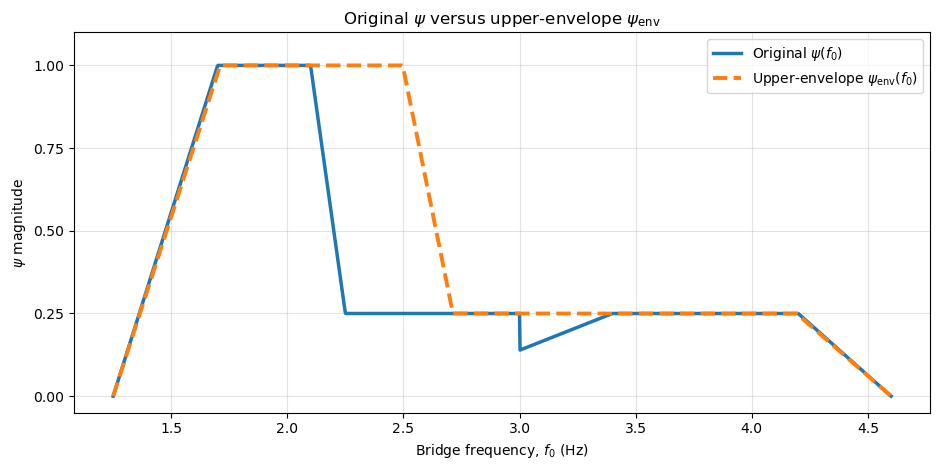

Loading: density1.0000_damping0.005_lm1000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm1500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm2000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm750_bias_summary.pkl
Loading: density1.0000_damping0.010_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.010_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.010_lm483_bias_summary.pkl
Loading: density1.0000_damping0.010_lm580_bias_summary.pkl
Loading: density1.0000_damping0.010_lm725_bias_summary.pkl
Loading: density1.0000_damping0.010_lm967_bias_summary.pkl
Loading: density1.0000_damping0.015_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.015_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.015_lm483_bias_summary.pkl
Loading: density1.0000_damping0.015_lm580_bias_summary.pkl
Loading: density1.0000_damping0.015_lm725_bias_summary.pkl
Loading: density1.0000_damping0.015_lm967_bias_su

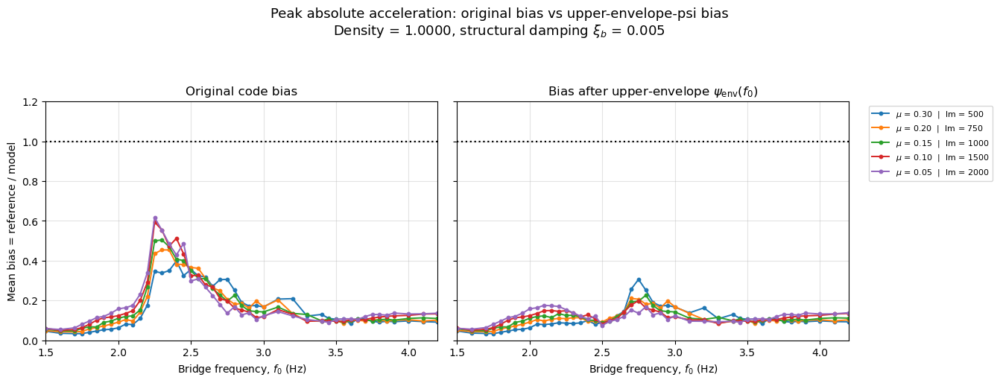

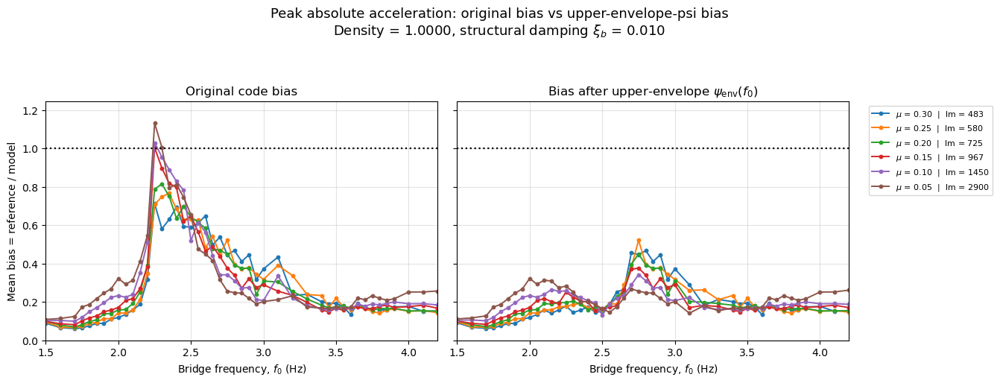

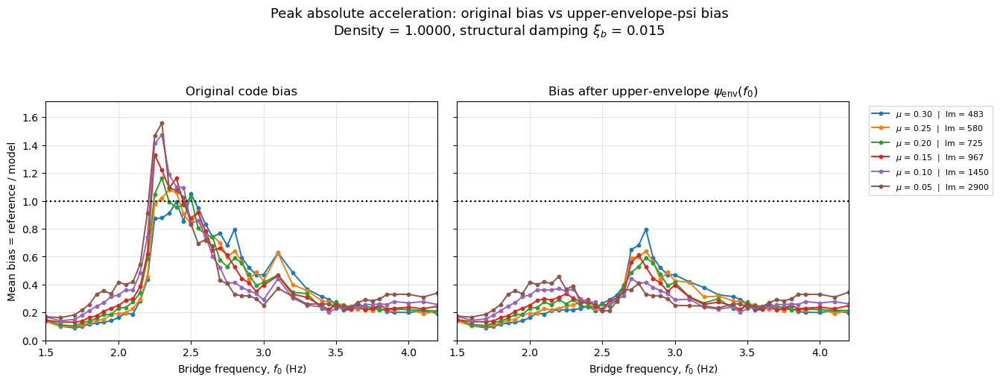

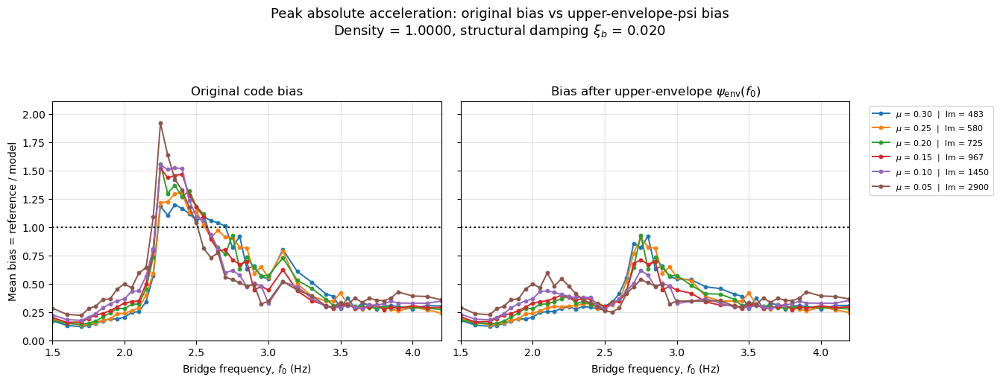

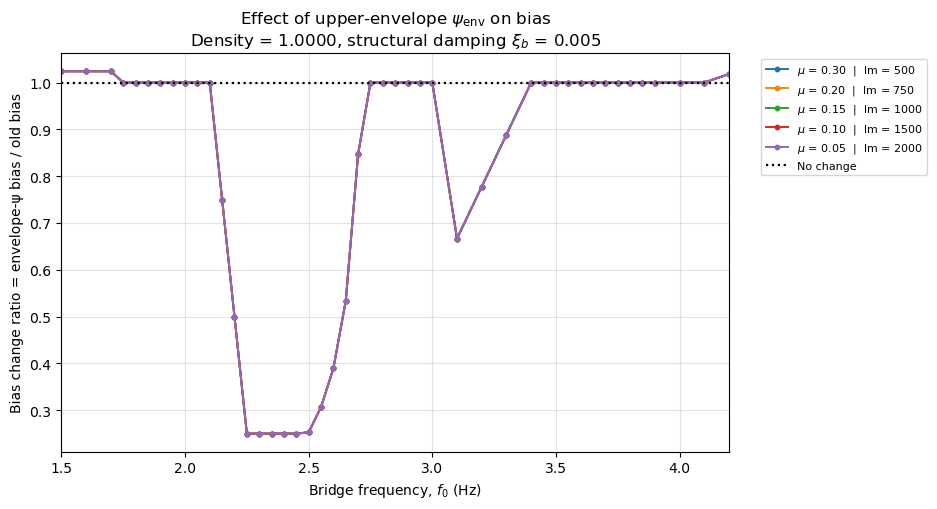

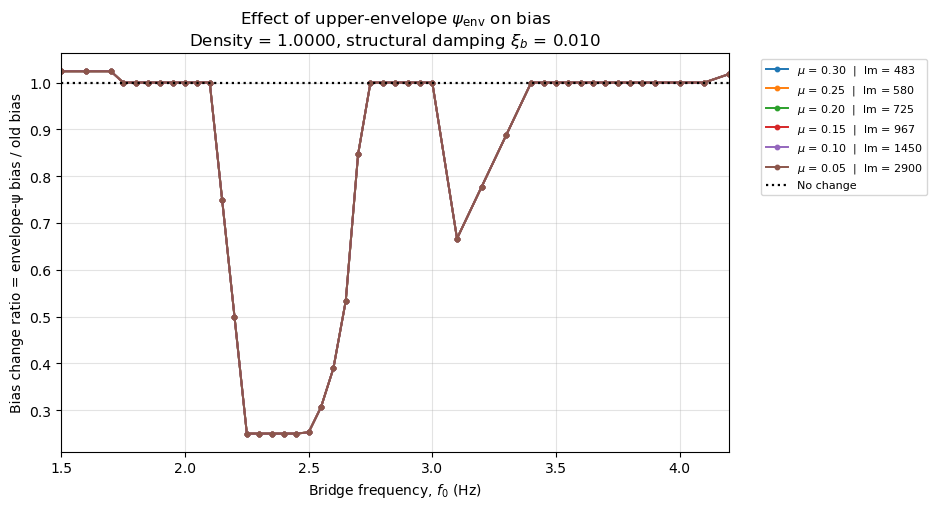

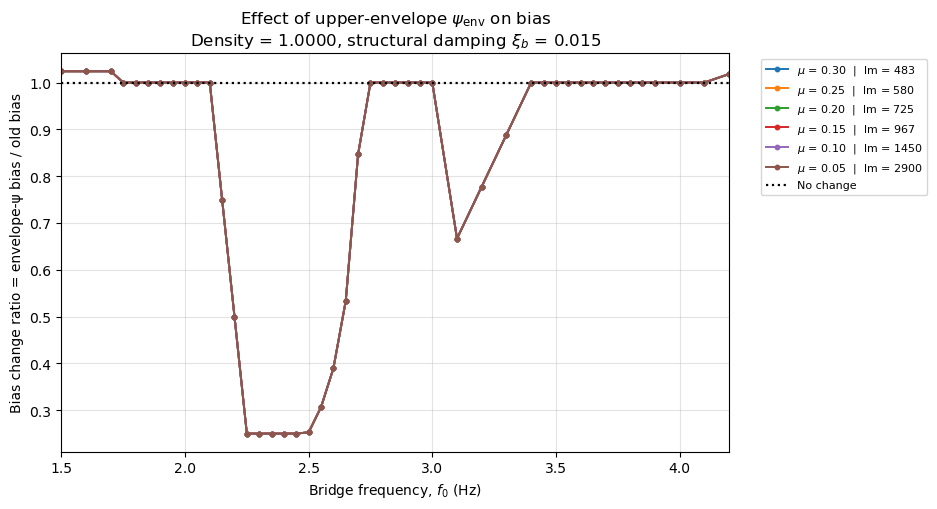

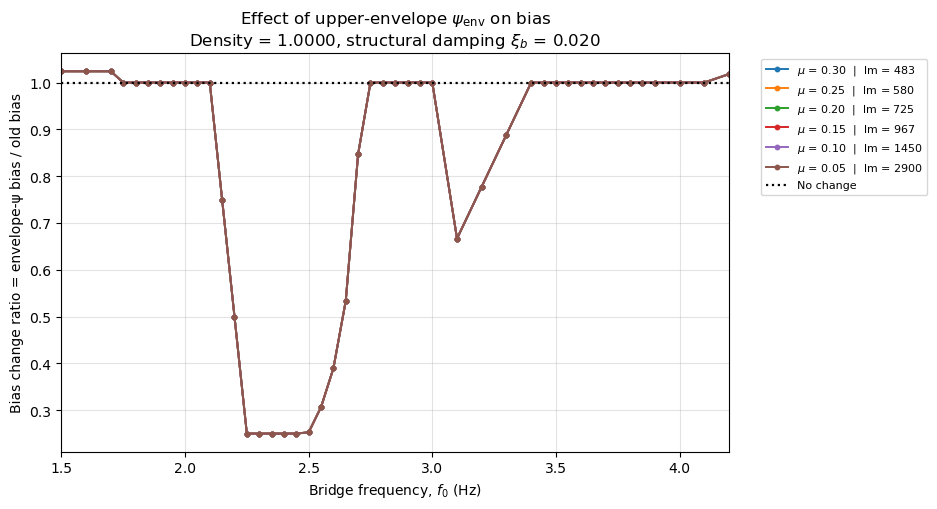


Summary table:
 damping_key  linear_mass_key  mass_ratio  old_bias_mean  env_bias_mean  old_bias_max  env_bias_max  mean_bias_change_ratio
       0.005              500        0.30       0.160823       0.108266      0.398131      0.306204                0.831589
       0.005              750        0.20       0.167101       0.108297      0.454150      0.210449                0.831589
       0.005             1000        0.15       0.173092       0.112188      0.504448      0.226072                0.831589
       0.005             1500        0.10       0.181362       0.116096      0.594561      0.198859                0.831589
       0.005             2000        0.05       0.184129       0.119601      0.616419      0.175922                0.831589
       0.010              483        0.30       0.291698       0.195941      0.712788      0.467535                0.831589
       0.010              580        0.25       0.296683       0.196153      0.766111      0.521570                0

In [49]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DENSITY = 1.0000

TARGET_DAMPINGS = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]
# Use None to load all damping ratios found:
# TARGET_DAMPINGS = None

MEASURE_TO_USE = "Peak absolute acceleration"

# This is the column you plotted as original bias / correction factor
OLD_BIAS_COL = "final_modification_factor"

PLOT_FMIN = 1.50
PLOT_FMAX = 4.20

SAVE_FIGURES = False
FIG_DPI = 300

PSI_EPS = 1e-8


# ==================================================
# LINEAR MASS TO MASS RATIO
# Edit this table only if your lm values are different.
# ==================================================

linear_mass_to_mass_ratio = {
    483:  0.30,
    500:  0.30,

    580:  0.25,

    725:  0.20,
    750:  0.20,

    967:  0.15,
    1000: 0.15,

    1450: 0.10,
    1500: 0.10,

    2000: 0.05,
    2900: 0.05,
}


# ==================================================
# ORIGINAL PSI FUNCTION
# Minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz
# ==================================================

def psi_original(f):
    """
    Original pedestrian excitation reduction function ψ(f),
    with minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz.
    """

    f = np.asarray(f, dtype=float)
    psi = np.zeros_like(f)

    # 1.25–1.70 Hz : ramp from 0 to 1
    m = (f >= 1.25) & (f < 1.70)
    psi[m] = (f[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 Hz : full value = 1
    m = (f >= 1.70) & (f <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 Hz : ramp from 1 to 0
    m = (f > 2.10) & (f <= 2.30)
    psi[m] = (2.30 - f[m]) / (2.30 - 2.10)

    # 2.30–2.50 Hz : zero
    m = (f > 2.30) & (f < 2.50)
    psi[m] = 0.0

    # 2.50–3.40 Hz : ramp from 0 to 0.25
    m = (f >= 2.50) & (f < 3.40)
    psi[m] = 0.25 * (f[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 Hz : constant 0.25
    m = (f >= 3.40) & (f <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 Hz : ramp from 0.25 to 0
    m = (f > 4.20) & (f <= 4.60)
    psi[m] = 0.25 * (4.60 - f[m]) / (4.60 - 4.20)

    # Minimum ψ = 0.25 for 2.25 Hz <= f <= 3.00 Hz
    m = (f >= 2.25) & (f <= 3.00)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi


# ==================================================
# UPPER-ENVELOPE PSI FUNCTION
#
# Your suggested envelope:
#
# For 1.2500 <= f0 <= 1.7109: psi_env =  2.169878*f0 - 2.712347
# For 1.7109 <= f0 <= 2.4968: psi_env =  1.000000
# For 2.4968 <= f0 <= 2.7130: psi_env = -3.469281*f0 + 9.662183
# For 2.7130 <= f0 <= 4.1928: psi_env =  0.250000
# For 4.1928 <= f0 <= 4.6000: psi_env = -0.613906*f0 + 2.823967
# ==================================================

def psi_upper_envelope(f):
    f = np.asarray(f, dtype=float)
    psi = np.zeros_like(f)

    # Breakpoints
    f_start = 1.2500
    a = 1.7109
    b = 2.4968
    c = 2.7130
    d = 4.1928
    f_end = 4.6000

    # Segment 1: ramp from 0 to 1
    m = (f >= f_start) & (f < a)
    psi[m] = 2.169878 * f[m] - 2.712347

    # Segment 2: plateau at 1
    m = (f >= a) & (f < b)
    psi[m] = 1.0

    # Segment 3: ramp from 1 to 0.25
    m = (f >= b) & (f < c)
    psi[m] = -3.469281 * f[m] + 9.662183

    # Segment 4: plateau at 0.25
    m = (f >= c) & (f < d)
    psi[m] = 0.25

    # Segment 5: ramp from 0.25 to 0
    m = (f >= d) & (f <= f_end)
    psi[m] = -0.613906 * f[m] + 2.823967

    # Outside range: keep zero
    psi = np.clip(psi, 0.0, 1.0)

    return psi


# ==================================================
# QUICK CHECK: PLOT OLD PSI VS UPPER-ENVELOPE PSI
# ==================================================

f_check = np.linspace(1.25, 4.60, 1500)

plt.figure(figsize=(9.5, 4.8))

plt.plot(
    f_check,
    psi_original(f_check),
    linewidth=2.5,
    label=r"Original $\psi(f_0)$"
)

plt.plot(
    f_check,
    psi_upper_envelope(f_check),
    "--",
    linewidth=2.8,
    label=r"Upper-envelope $\psi_{\mathrm{env}}(f_0)$"
)

plt.xlabel(r"Bridge frequency, $f_0$ (Hz)")
plt.ylabel(r"$\psi$ magnitude")
plt.title(r"Original $\psi$ versus upper-envelope $\psi_{\mathrm{env}}$")
plt.ylim(-0.05, 1.10)
plt.yticks([0.00, 0.25, 0.50, 0.75, 1.00])
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# LOAD lm BIAS FILES
# Expected:
# density1.0000_damping0.005_lm483_bias_summary.pkl
# density1.0000_damping0.005_lm500_bias_summary.pkl
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"lm(?P<linear_mass>\d+)_"
    r"bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_lm*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:

    match = pattern.match(file.name)

    if match is None:
        print("Skipping unmatched file:", file.name)
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_linear_mass = int(match.group("linear_mass"))

    if not np.isclose(file_density, TARGET_DENSITY):
        continue

    if TARGET_DAMPINGS is not None:
        if not any(np.isclose(file_damping, d) for d in TARGET_DAMPINGS):
            continue

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["linear_mass"] = file_linear_mass

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching lm bias summary files found.")

raw_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded lm dataframe shape:", raw_df.shape)
print("\nColumns:")
print(raw_df.columns.tolist())


# ==================================================
# CLEAN lm DATA
# ==================================================

needed_cols = [
    "bridge_frequency",
    "target_beamdamp",
    "linear_mass",
    OLD_BIAS_COL,
]

for col in needed_cols:
    if col not in raw_df.columns:
        raise KeyError(f"Missing required column: {col}")

    raw_df[col] = pd.to_numeric(raw_df[col], errors="coerce")

raw_df = raw_df.dropna(subset=needed_cols).copy()

# Keep peak absolute acceleration only
if "measure" in raw_df.columns:
    raw_df = raw_df[
        raw_df["measure"].astype(str).str.strip().eq(MEASURE_TO_USE)
    ].copy()

    if raw_df.empty:
        raise ValueError(
            f"No rows found for measure = '{MEASURE_TO_USE}'."
        )

raw_df["damping_key"] = raw_df["target_beamdamp"].round(3)
raw_df["linear_mass_key"] = raw_df["linear_mass"].round(0).astype(int)

raw_df = raw_df[
    (raw_df["bridge_frequency"] >= PLOT_FMIN) &
    (raw_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

# Stable mass-ratio label from lm
raw_df["mass_ratio"] = raw_df["linear_mass_key"].map(linear_mass_to_mass_ratio)

missing_lm = sorted(
    raw_df.loc[raw_df["mass_ratio"].isna(), "linear_mass_key"].unique()
)

if len(missing_lm) > 0:
    raise ValueError(
        "These linear masses are missing from linear_mass_to_mass_ratio:\n"
        f"{missing_lm}\n\n"
        "Add them to the dictionary near the top."
    )

# Average only exact duplicate points
compare_df = (
    raw_df
    .groupby(
        ["damping_key", "linear_mass_key", "mass_ratio", "bridge_frequency"],
        as_index=False
    )
    .agg(old_bias=(OLD_BIAS_COL, "mean"))
    .sort_values(
        ["damping_key", "linear_mass_key", "bridge_frequency"]
    )
)

print("\nFinal comparison dataframe shape:", compare_df.shape)

print("\nAvailable lm and mass-ratio mapping:")
print(
    compare_df[["linear_mass_key", "mass_ratio"]]
    .drop_duplicates()
    .sort_values("mass_ratio", ascending=False)
    .to_string(index=False)
)

print("\nFrequency coverage:")
coverage = (
    compare_df
    .groupby(["damping_key", "linear_mass_key", "mass_ratio"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)
print(coverage)


# ==================================================
# COMPUTE BIAS IF UPPER-ENVELOPE PSI IS USED
# ==================================================

compare_df["psi_old"] = psi_original(
    compare_df["bridge_frequency"].to_numpy(dtype=float)
)

compare_df["psi_env"] = psi_upper_envelope(
    compare_df["bridge_frequency"].to_numpy(dtype=float)
)

psi_old_safe = np.maximum(
    compare_df["psi_old"].to_numpy(dtype=float),
    PSI_EPS
)

psi_env_safe = np.maximum(
    compare_df["psi_env"].to_numpy(dtype=float),
    PSI_EPS
)

# Model_new = Model_old * psi_env / psi_old
# Bias = Reference / Model
# Therefore:
# Bias_new = Bias_old * psi_old / psi_env

compare_df["env_bias"] = (
    compare_df["old_bias"] * psi_old_safe / psi_env_safe
)

compare_df["bias_ratio_env_over_old"] = (
    compare_df["env_bias"] / compare_df["old_bias"]
)

compare_df["psi_scale_env_over_old"] = (
    psi_env_safe / psi_old_safe
)

compare_df.to_csv(
    "old_vs_upper_envelope_psi_bias_from_lm_files.csv",
    index=False
)

print("\nSaved: old_vs_upper_envelope_psi_bias_from_lm_files.csv")


# ==================================================
# PLOT OLD BIAS VS UPPER-ENVELOPE-PSI BIAS
# One figure per damping ratio.
# Each figure has all lm / mass-ratio lines.
# ==================================================

for damping in sorted(compare_df["damping_key"].unique()):

    damp_df = compare_df[
        np.isclose(compare_df["damping_key"], damping)
    ].copy()

    if damp_df.empty:
        continue

    fig, axes = plt.subplots(
        1, 2,
        figsize=(13.5, 5.2),
        sharex=True,
        sharey=True
    )

    plot_specs = [
        ("old_bias", "Original code bias"),
        ("env_bias", r"Bias after upper-envelope $\psi_{\mathrm{env}}(f_0)$"),
    ]

    for ax, (y_col, title) in zip(axes, plot_specs):

        for lm in sorted(damp_df["linear_mass_key"].unique()):

            sub = damp_df[
                damp_df["linear_mass_key"] == lm
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            mu = sub["mass_ratio"].iloc[0]

            ax.plot(
                sub["bridge_frequency"],
                sub[y_col],
                marker="o",
                markersize=3.2,
                linewidth=1.4,
                label=rf"$\mu$ = {mu:.2f}  |  lm = {lm}"
            )

        ax.axhline(
            1.0,
            linestyle=":",
            linewidth=1.6,
            color="black"
        )

        ax.set_title(title)
        ax.set_xlabel(r"Bridge frequency, $f_0$ (Hz)")
        ax.grid(True, alpha=0.35)
        ax.set_xlim(PLOT_FMIN, PLOT_FMAX)

    axes[0].set_ylabel("Mean bias = reference / model")

    ymax = np.nanmax(
        damp_df[["old_bias", "env_bias"]].to_numpy()
    )

    axes[0].set_ylim(0, max(1.2, 1.10 * ymax))

    axes[1].legend(
        bbox_to_anchor=(1.04, 1),
        loc="upper left",
        fontsize=8,
        frameon=True
    )

    fig.suptitle(
        "Peak absolute acceleration: original bias vs upper-envelope-psi bias\n"
        rf"Density = {TARGET_DENSITY:.4f}, structural damping $\xi_b$ = {damping:.3f}",
        fontsize=13
    )

    fig.tight_layout(rect=[0, 0, 1, 0.92])

    if SAVE_FIGURES:
        save_name = (
            f"old_vs_upper_envelope_psi_bias_"
            f"density{TARGET_DENSITY:.4f}_damping{damping:.3f}.png"
        )
        plt.savefig(save_name, dpi=FIG_DPI, bbox_inches="tight")
        print("Saved:", save_name)

    plt.show()


# ==================================================
# OPTIONAL: PLOT HOW MUCH THE BIAS CHANGES
# env_bias / old_bias
# ==================================================

for damping in sorted(compare_df["damping_key"].unique()):

    damp_df = compare_df[
        np.isclose(compare_df["damping_key"], damping)
    ].copy()

    plt.figure(figsize=(9.5, 5.2))

    for lm in sorted(damp_df["linear_mass_key"].unique()):

        sub = damp_df[
            damp_df["linear_mass_key"] == lm
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        mu = sub["mass_ratio"].iloc[0]

        plt.plot(
            sub["bridge_frequency"],
            sub["bias_ratio_env_over_old"],
            marker="o",
            markersize=3.2,
            linewidth=1.4,
            label=rf"$\mu$ = {mu:.2f}  |  lm = {lm}"
        )

    plt.axhline(
        1.0,
        linestyle=":",
        linewidth=1.6,
        color="black",
        label="No change"
    )

    plt.xlabel(r"Bridge frequency, $f_0$ (Hz)")
    plt.ylabel(r"Bias change ratio = envelope-ψ bias / old bias")

    plt.title(
        r"Effect of upper-envelope $\psi_{\mathrm{env}}$ on bias"
        "\n"
        rf"Density = {TARGET_DENSITY:.4f}, structural damping $\xi_b$ = {damping:.3f}"
    )

    plt.xlim(PLOT_FMIN, PLOT_FMAX)
    plt.grid(True, alpha=0.35)
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=8)

    plt.tight_layout()
    plt.show()


# ==================================================
# OPTIONAL: SUMMARY TABLE
# ==================================================

summary_df = (
    compare_df
    .groupby(["damping_key", "linear_mass_key", "mass_ratio"], as_index=False)
    .agg(
        old_bias_mean=("old_bias", "mean"),
        env_bias_mean=("env_bias", "mean"),
        old_bias_max=("old_bias", "max"),
        env_bias_max=("env_bias", "max"),
        mean_bias_change_ratio=("bias_ratio_env_over_old", "mean"),
    )
    .sort_values(["damping_key", "mass_ratio"], ascending=[True, False])
)

print("\nSummary table:")
print(summary_df.to_string(index=False))

summary_df.to_csv(
    "summary_upper_envelope_psi_bias_effect.csv",
    index=False
)

print("\nSaved: summary_upper_envelope_psi_bias_effect.csv")

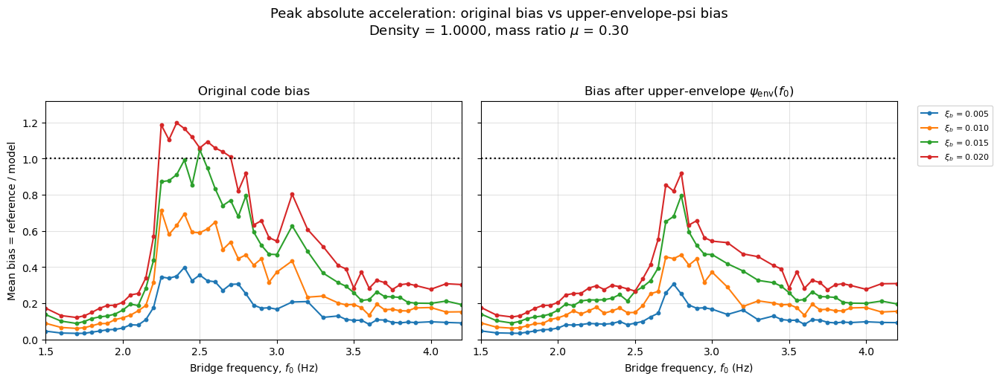

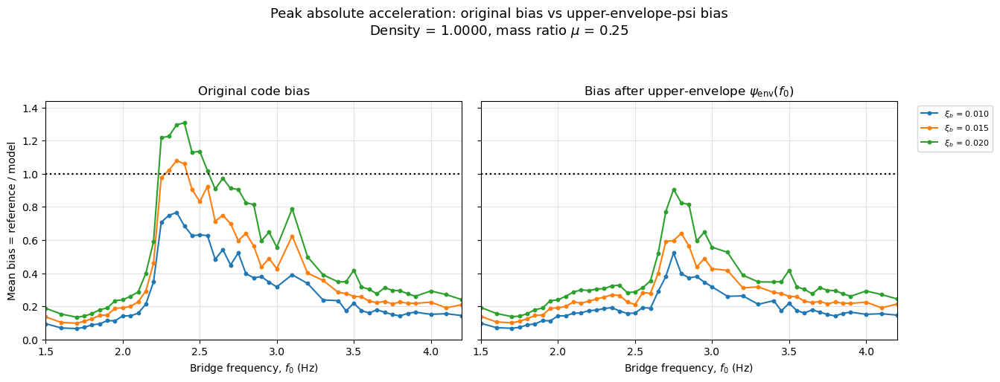

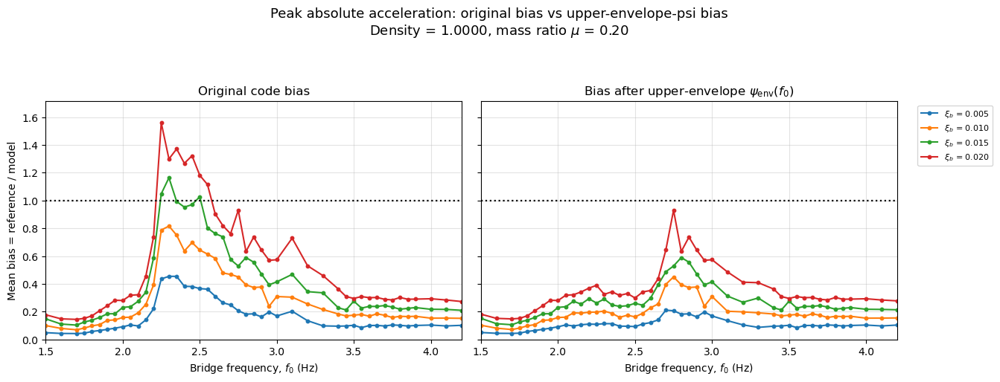

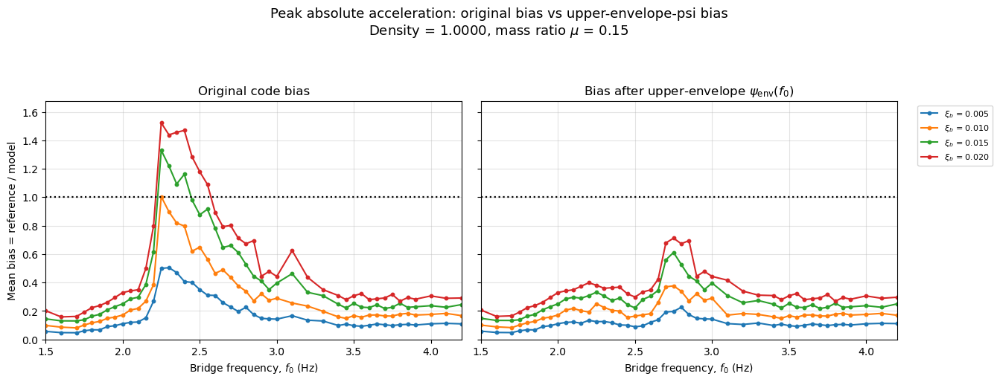

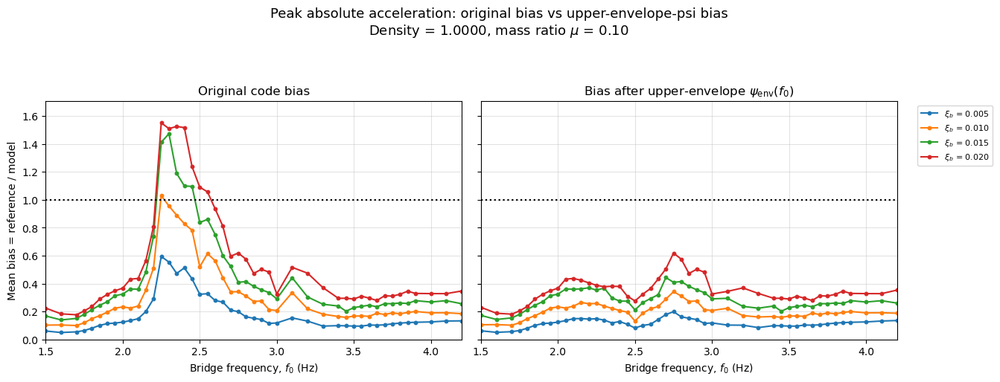

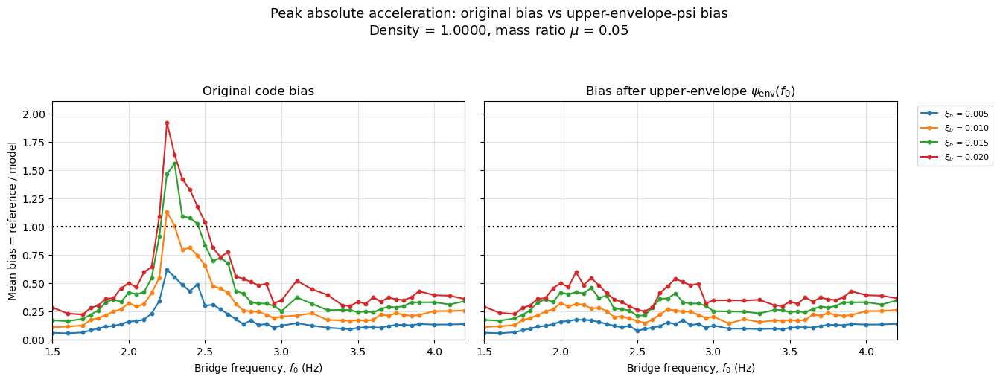

In [50]:
# ==================================================
# PLOT OLD BIAS VS UPPER-ENVELOPE-PSI BIAS
# One figure per mass ratio.
# Each figure has all damping-ratio lines.
# ==================================================

for mu in sorted(compare_df["mass_ratio"].unique(), reverse=True):

    mu_df = compare_df[
        np.isclose(compare_df["mass_ratio"], mu)
    ].copy()

    if mu_df.empty:
        continue

    # If more than one lm maps to the same mass ratio, average duplicates
    mu_plot_df = (
        mu_df
        .groupby(["mass_ratio", "damping_key", "bridge_frequency"], as_index=False)
        .agg(
            old_bias=("old_bias", "mean"),
            env_bias=("env_bias", "mean"),
            bias_ratio_env_over_old=("bias_ratio_env_over_old", "mean"),
        )
        .sort_values(["damping_key", "bridge_frequency"])
    )

    fig, axes = plt.subplots(
        1, 2,
        figsize=(13.5, 5.2),
        sharex=True,
        sharey=True
    )

    plot_specs = [
        ("old_bias", "Original code bias"),
        ("env_bias", r"Bias after upper-envelope $\psi_{\mathrm{env}}(f_0)$"),
    ]

    for ax, (y_col, title) in zip(axes, plot_specs):

        for damping in sorted(mu_plot_df["damping_key"].unique()):

            sub = mu_plot_df[
                np.isclose(mu_plot_df["damping_key"], damping)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            ax.plot(
                sub["bridge_frequency"],
                sub[y_col],
                marker="o",
                markersize=3.2,
                linewidth=1.5,
                label=rf"$\xi_b$ = {damping:.3f}"
            )

        ax.axhline(
            1.0,
            linestyle=":",
            linewidth=1.6,
            color="black"
        )

        ax.set_title(title)
        ax.set_xlabel(r"Bridge frequency, $f_0$ (Hz)")
        ax.grid(True, alpha=0.35)
        ax.set_xlim(PLOT_FMIN, PLOT_FMAX)

    axes[0].set_ylabel("Mean bias = reference / model")

    ymax = np.nanmax(
        mu_plot_df[["old_bias", "env_bias"]].to_numpy()
    )

    axes[0].set_ylim(0, max(1.2, 1.10 * ymax))

    axes[1].legend(
        bbox_to_anchor=(1.04, 1),
        loc="upper left",
        fontsize=8,
        frameon=True
    )

    fig.suptitle(
        "Peak absolute acceleration: original bias vs upper-envelope-psi bias\n"
        rf"Density = {TARGET_DENSITY:.4f}, mass ratio $\mu$ = {mu:.2f}",
        fontsize=13
    )

    fig.tight_layout(rect=[0, 0, 1, 0.92])

    if SAVE_FIGURES:
        save_name = (
            f"old_vs_upper_envelope_psi_bias_"
            f"density{TARGET_DENSITY:.4f}_massratio{mu:.2f}.png"
        )
        plt.savefig(save_name, dpi=FIG_DPI, bbox_inches="tight")
        print("Saved:", save_name)

    plt.show()

In [52]:
# ==================================================
# P90 AND P95 OF MODIFIED-PSI BIAS LINES
# One percentile value per mass ratio and damping ratio
# ==================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "compare_df" not in globals():
    raise NameError("compare_df not found. Run the modified-psi bias code first.")

if "env_bias" not in compare_df.columns:
    raise KeyError("env_bias not found. Run the modified-psi bias calculation first.")

# ==================================================
# SETTINGS
# ==================================================

BIAS_COL_FOR_PERCENTILES = "env_bias"
# If you want original bias percentiles instead:
# BIAS_COL_FOR_PERCENTILES = "old_bias"

PERCENTILES_TO_CALCULATE = [90, 95]

# ==================================================
# CLEAN / AVERAGE DUPLICATES
# ==================================================

percentile_work_df = compare_df.copy()

percentile_work_df[BIAS_COL_FOR_PERCENTILES] = pd.to_numeric(
    percentile_work_df[BIAS_COL_FOR_PERCENTILES],
    errors="coerce"
)

percentile_work_df = percentile_work_df.dropna(
    subset=[
        "mass_ratio",
        "damping_key",
        "bridge_frequency",
        BIAS_COL_FOR_PERCENTILES
    ]
).copy()

# Average duplicate points, if same mu, damping, frequency appears more than once
percentile_work_df = (
    percentile_work_df
    .groupby(["mass_ratio", "damping_key", "bridge_frequency"], as_index=False)
    .agg(bias_value=(BIAS_COL_FOR_PERCENTILES, "mean"))
    .sort_values(["mass_ratio", "damping_key", "bridge_frequency"])
)

# ==================================================
# CALCULATE P90 AND P95 FOR EACH LINE
# ==================================================

percentile_rows = []

for (mu, damping), sub in percentile_work_df.groupby(["mass_ratio", "damping_key"]):

    vals = sub["bias_value"].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        continue

    row = {
        "mass_ratio": mu,
        "xi_b": damping,
        "n_frequency_points": len(vals),
        "mean_bias": np.mean(vals),
        "max_bias": np.max(vals),
    }

    for p in PERCENTILES_TO_CALCULATE:
        row[f"P{p}_bias"] = np.percentile(vals, p)

    percentile_rows.append(row)

bias_percentile_df = pd.DataFrame(percentile_rows)

bias_percentile_df = bias_percentile_df.sort_values(
    ["mass_ratio", "xi_b"],
    ascending=[False, True]
).reset_index(drop=True)

print("\nBias percentile table:")
print(bias_percentile_df.to_string(index=False))

bias_percentile_df.to_csv(
    "modified_psi_bias_P90_P95_by_mass_ratio_and_damping.csv",
    index=False
)

print("\nSaved: modified_psi_bias_P90_P95_by_mass_ratio_and_damping.csv")




Bias percentile table:
 mass_ratio  xi_b  n_frequency_points  mean_bias  max_bias  P90_bias  P95_bias
       0.30 0.005                  46   0.108266  0.306204  0.173968  0.236357
       0.30 0.010                  46   0.195941  0.467535  0.391781  0.446751
       0.30 0.015                  46   0.280786  0.795375  0.496057  0.637272
       0.30 0.020                  46   0.357385  0.919452  0.597914  0.779664
       0.25 0.010                  46   0.196153  0.521570  0.358920  0.380176
       0.25 0.015                  46   0.274210  0.640438  0.462615  0.585305
       0.25 0.020                  46   0.356776  0.905508  0.620895  0.803535
       0.20 0.005                  46   0.108297  0.210449  0.175476  0.194412
       0.20 0.010                  46   0.194554  0.450093  0.341336  0.389106
       0.20 0.015                  46   0.270805  0.589435  0.442990  0.518194
       0.20 0.020                  46   0.359196  0.929996  0.603262  0.644220
       0.15 0.005           

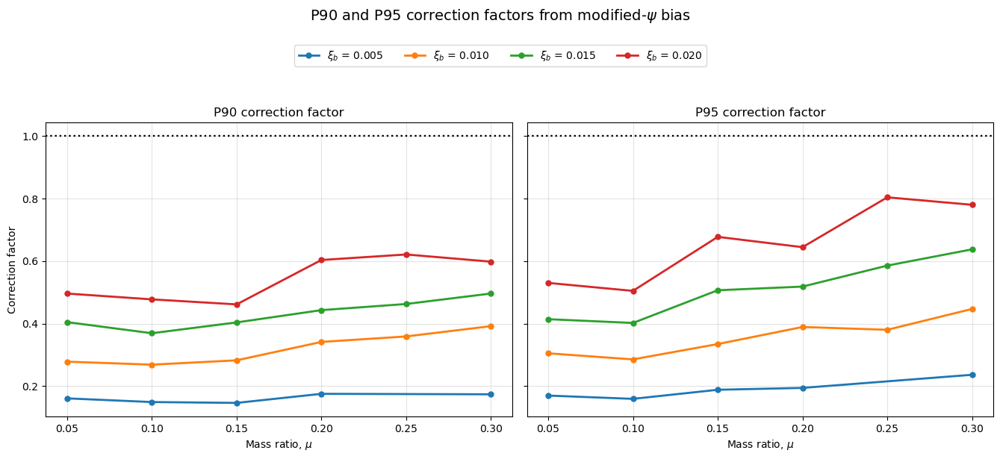

In [56]:
# ==================================================
# SIDE-BY-SIDE P90 AND P95 CORRECTION FACTOR PLOTS
# x-axis = mass ratio
# y-axis = correction factor / bias percentile
# each line = damping ratio
# ==================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "bias_percentile_df" not in globals():
    raise NameError("bias_percentile_df not found. Run the P90/P95 percentile code first.")

required_cols = ["mass_ratio", "xi_b", "P90_bias", "P95_bias"]

missing_cols = [c for c in required_cols if c not in bias_percentile_df.columns]
if missing_cols:
    raise KeyError(f"Missing columns in bias_percentile_df: {missing_cols}")

plot_df = bias_percentile_df.copy()

for col in required_cols:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

plot_df = plot_df.dropna(subset=required_cols).copy()

# Sort mass ratios left to right
mass_ratios = sorted(plot_df["mass_ratio"].unique())

damping_values = sorted(plot_df["xi_b"].unique())

fig, axes = plt.subplots(
    1, 2,
    figsize=(13.5, 5.4),
    sharex=True,
    sharey=True
)

plot_specs = [
    ("P90_bias", "P90 correction factor"),
    ("P95_bias", "P95 correction factor"),
]

for ax, (y_col, title) in zip(axes, plot_specs):

    for damping in damping_values:

        sub = plot_df[
            np.isclose(plot_df["xi_b"], damping)
        ].copy()

        sub = sub.sort_values("mass_ratio")

        ax.plot(
            sub["mass_ratio"],
            sub[y_col],
            marker="o",
            linewidth=2.0,
            markersize=5,
            label=rf"$\xi_b$ = {damping:.3f}"
        )

       

    ax.axhline(
        1.0,
        linestyle=":",
        linewidth=1.7,
        color="black",
        label="Bias = 1" if y_col == "P90_bias" else None
    )

    ax.set_title(title)
    ax.set_xlabel(r"Mass ratio, $\mu$")
    ax.set_xticks(mass_ratios)
    
    ax.grid(True, alpha=0.35)

axes[0].set_ylabel("Correction factor")

handles, labels = axes[1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=min(len(damping_values), 4),
    bbox_to_anchor=(0.5, 1.05),
    frameon=True
)

fig.suptitle(
    r"P90 and P95 correction factors from modified-$\psi$ bias",
    fontsize=14,
    y=1.13
)

fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

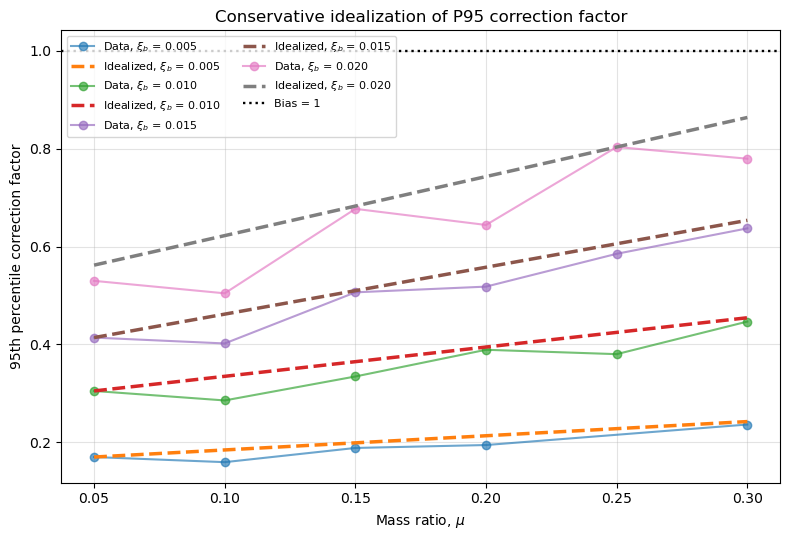

,xi_b,m,c_safe,equation
0,0.005,0.290009,0.155381,$C_{95} = 0.290\mu + 0.155$
1,0.010,0.598546,0.275018,$C_{95} = 0.599\mu + 0.275$
2,0.015,0.958693,0.366091,$C_{95} = 0.959\mu + 0.366$
3,0.020,1.207170,0.501742,$C_{95} = 1.207\mu + 0.502$


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# CONSERVATIVE LINEAR IDEALIZATION OF P95 BIAS
# Each damping ratio gets one upper shifted straight line
# ==================================================

plot_df = bias_percentile_df.copy()

plot_df["mass_ratio"] = pd.to_numeric(plot_df["mass_ratio"], errors="coerce")
plot_df["xi_b"] = pd.to_numeric(plot_df["xi_b"], errors="coerce")
plot_df["P95_bias"] = pd.to_numeric(plot_df["P95_bias"], errors="coerce")

plot_df = plot_df.dropna(subset=["mass_ratio", "xi_b", "P95_bias"]).copy()

mass_ratios = sorted(plot_df["mass_ratio"].unique())
damping_values = sorted(plot_df["xi_b"].unique())

fig, ax = plt.subplots(figsize=(8, 5.5))

equation_rows = []

for damping in damping_values:

    sub = plot_df[np.isclose(plot_df["xi_b"], damping)].copy()
    sub = sub.sort_values("mass_ratio")

    x = sub["mass_ratio"].to_numpy()
    y = sub["P95_bias"].to_numpy()

    # Ordinary linear fit: y = m*x + c
    m, c = np.polyfit(x, y, 1)

    # Shift upward so the line is conservative at all data points
    y_fit_at_data = m * x + c
    upward_shift = np.max(y - y_fit_at_data)

    c_safe = c + upward_shift

    x_smooth = np.linspace(x.min(), x.max(), 200)
    y_safe = m * x_smooth + c_safe

    # Optional: do not exceed bias = 1
    y_safe = np.minimum(y_safe, 1.0)

    ax.plot(
        x,
        y,
        marker="o",
        linewidth=1.5,
        alpha=0.65,
        label=rf"Data, $\xi_b$ = {damping:.3f}"
    )

    ax.plot(
        x_smooth,
        y_safe,
        linewidth=2.5,
        linestyle="--",
        label=rf"Idealized, $\xi_b$ = {damping:.3f}"
    )

    equation_rows.append({
        "xi_b": damping,
        "m": m,
        "c_safe": c_safe,
        "equation": rf"$C_{{95}} = {m:.3f}\mu + {c_safe:.3f}$"
    })

ax.axhline(1.0, linestyle=":", linewidth=1.7, color="black", label="Bias = 1")

ax.set_xlabel(r"Mass ratio, $\mu$")
ax.set_ylabel("95th percentile correction factor")
ax.set_title("Conservative idealization of P95 correction factor")
ax.set_xticks(mass_ratios)
ax.grid(True, alpha=0.35)
ax.legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

equation_df = pd.DataFrame(equation_rows)
display(equation_df)

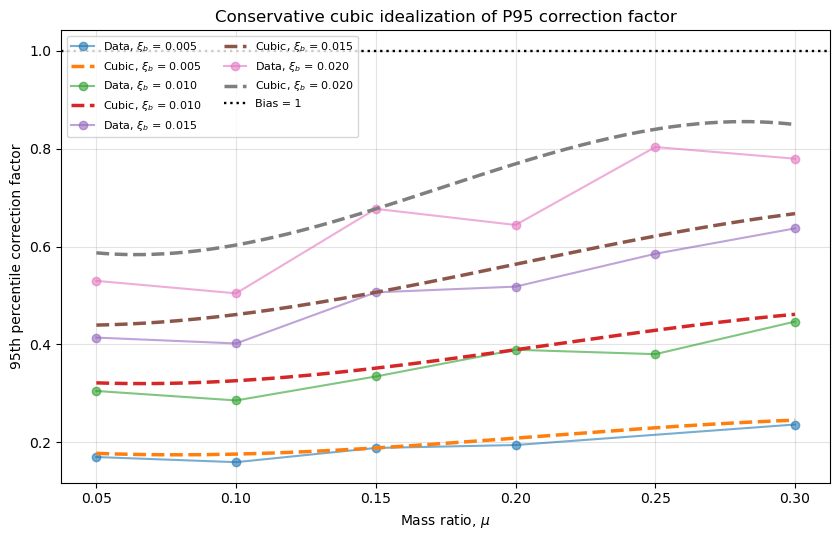

,xi_b,a,b,c,d_safe,equation
0,0.005,-8.691970,5.421103,-0.691444,0.199525,$C_{95} = -8.692\mu^3 + 5.421\mu^2 + -0.691\mu...
1,0.010,-12.709372,8.087916,-0.904095,0.348083,$C_{95} = -12.709\mu^3 + 8.088\mu^2 + -0.904\m...
2,0.015,-15.803655,9.513164,-0.719432,0.453730,$C_{95} = -15.804\mu^3 + 9.513\mu^2 + -0.719\m...
3,0.020,-52.816063,27.404992,-2.865298,0.668582,$C_{95} = -52.816\mu^3 + 27.405\mu^2 + -2.865\...


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# CUBIC CONSERVATIVE IDEALIZATION OF P95 BIAS
# One cubic curve per damping ratio
# ==================================================

SAFETY_MARGIN = 0.00   # try 0.00 first; use 0.01 or 0.02 if needed
CAP_AT_ONE = True

plot_df = bias_percentile_df.copy()

plot_df["mass_ratio"] = pd.to_numeric(plot_df["mass_ratio"], errors="coerce")
plot_df["xi_b"] = pd.to_numeric(plot_df["xi_b"], errors="coerce")
plot_df["P95_bias"] = pd.to_numeric(plot_df["P95_bias"], errors="coerce")

plot_df = plot_df.dropna(subset=["mass_ratio", "xi_b", "P95_bias"]).copy()

mass_ratios = sorted(plot_df["mass_ratio"].unique())
damping_values = sorted(plot_df["xi_b"].unique())

fig, ax = plt.subplots(figsize=(8.5, 5.5))

equation_rows = []

for damping in damping_values:

    sub = plot_df[np.isclose(plot_df["xi_b"], damping)].copy()
    sub = sub.sort_values("mass_ratio")

    x = sub["mass_ratio"].to_numpy()
    y = sub["P95_bias"].to_numpy()

    # Cubic fit: y = a*x^3 + b*x^2 + c*x + d
    a, b, c, d = np.polyfit(x, y, 3)

    # Shift upward so the cubic is conservative at all data points
    y_fit_at_data = a*x**3 + b*x**2 + c*x + d
    upward_shift = np.max(y - y_fit_at_data)

    d_safe = d + upward_shift + SAFETY_MARGIN

    x_smooth = np.linspace(x.min(), x.max(), 300)
    y_cubic = a*x_smooth**3 + b*x_smooth**2 + c*x_smooth + d_safe

    if CAP_AT_ONE:
        y_cubic = np.minimum(y_cubic, 1.0)

    # Original P95 points
    ax.plot(
        x,
        y,
        marker="o",
        linewidth=1.5,
        alpha=0.6,
        label=rf"Data, $\xi_b$ = {damping:.3f}"
    )

    # Conservative cubic idealization
    ax.plot(
        x_smooth,
        y_cubic,
        linewidth=2.5,
        linestyle="--",
        label=rf"Cubic, $\xi_b$ = {damping:.3f}"
    )

    equation_rows.append({
        "xi_b": damping,
        "a": a,
        "b": b,
        "c": c,
        "d_safe": d_safe,
        "equation": rf"$C_{{95}} = {a:.3f}\mu^3 + {b:.3f}\mu^2 + {c:.3f}\mu + {d_safe:.3f}$"
    })

ax.axhline(
    1.0,
    linestyle=":",
    linewidth=1.7,
    color="black",
    label="Bias = 1"
)

ax.set_xlabel(r"Mass ratio, $\mu$")
ax.set_ylabel("95th percentile correction factor")
ax.set_title("Conservative cubic idealization of P95 correction factor")
ax.set_xticks(mass_ratios)
ax.grid(True, alpha=0.35)
ax.legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

equation_df = pd.DataFrame(equation_rows)
display(equation_df)

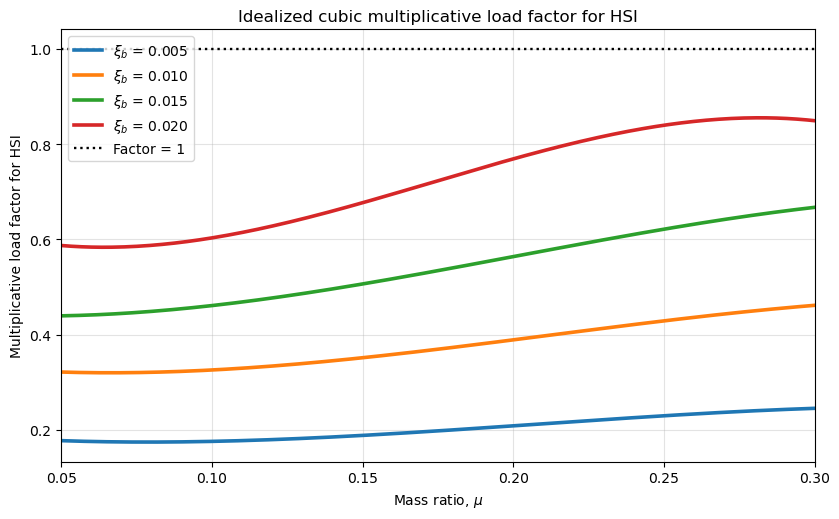

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# PLOT FITTED CUBIC CURVES ONLY
# y-axis = multiplicative load factor for HSI
# ==================================================

CAP_AT_ONE = True

# Same colour code as before
color_map = {
    0.005: "tab:blue",
    0.010: "tab:orange",
    0.015: "tab:green",
    0.020: "tab:red",
}

if "equation_df" not in globals():
    raise NameError("equation_df not found. Run the cubic fitting code first.")

required_cols = ["xi_b", "a", "b", "c", "d_safe"]

missing_cols = [c for c in required_cols if c not in equation_df.columns]
if missing_cols:
    raise KeyError(f"Missing columns in equation_df: {missing_cols}")

fit_df = equation_df.copy()

for col in required_cols:
    fit_df[col] = pd.to_numeric(fit_df[col], errors="coerce")

fit_df = fit_df.dropna(subset=required_cols).copy()
fit_df = fit_df.sort_values("xi_b")

# x-axis range from your available mass ratios
mu_min = float(plot_df["mass_ratio"].min())
mu_max = float(plot_df["mass_ratio"].max())

mu_smooth = np.linspace(mu_min, mu_max, 300)

fig, ax = plt.subplots(figsize=(8.5, 5.3))

for _, row in fit_df.iterrows():

    xi_b = row["xi_b"]
    a = row["a"]
    b = row["b"]
    c = row["c"]
    d_safe = row["d_safe"]

    y_fit = a*mu_smooth**3 + b*mu_smooth**2 + c*mu_smooth + d_safe

    if CAP_AT_ONE:
        y_fit = np.minimum(y_fit, 1.0)

    ax.plot(
        mu_smooth,
        y_fit,
        linewidth=2.6,
        color=color_map.get(round(xi_b, 3), None),
        label=rf"$\xi_b$ = {xi_b:.3f}"
    )

ax.axhline(
    1.0,
    linestyle=":",
    linewidth=1.7,
    color="black",
    label="Factor = 1"
)

ax.set_xlabel(r"Mass ratio, $\mu$")
ax.set_ylabel("Multiplicative load factor for HSI")
ax.set_title("Idealized cubic multiplicative load factor for HSI")
ax.set_xlim(mu_min, mu_max)
ax.set_xticks(sorted(plot_df["mass_ratio"].unique()))
ax.grid(True, alpha=0.35)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

Available damping ratios:
[np.float64(0.005), np.float64(0.01), np.float64(0.015), np.float64(0.02)]

Available mass ratios:
[np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(0.3)]

Raw P95 correction factors:
 damping_key  mass_ratio  p95_factor_raw  n_points  modified_bias_mean  modified_bias_p90  modified_bias_p95  modified_bias_max
       0.005        0.05        0.169882        46            0.119601           0.160992           0.169882           0.175922
       0.005        0.10        0.159411        46            0.116096           0.149231           0.159411           0.198859
       0.005        0.15        0.188448        46            0.112188           0.146487           0.188448           0.226072
       0.005        0.20        0.194412        46            0.108297           0.175476           0.194412           0.210449
       0.005        0.30        0.236357        46            0.108266           0.173968           

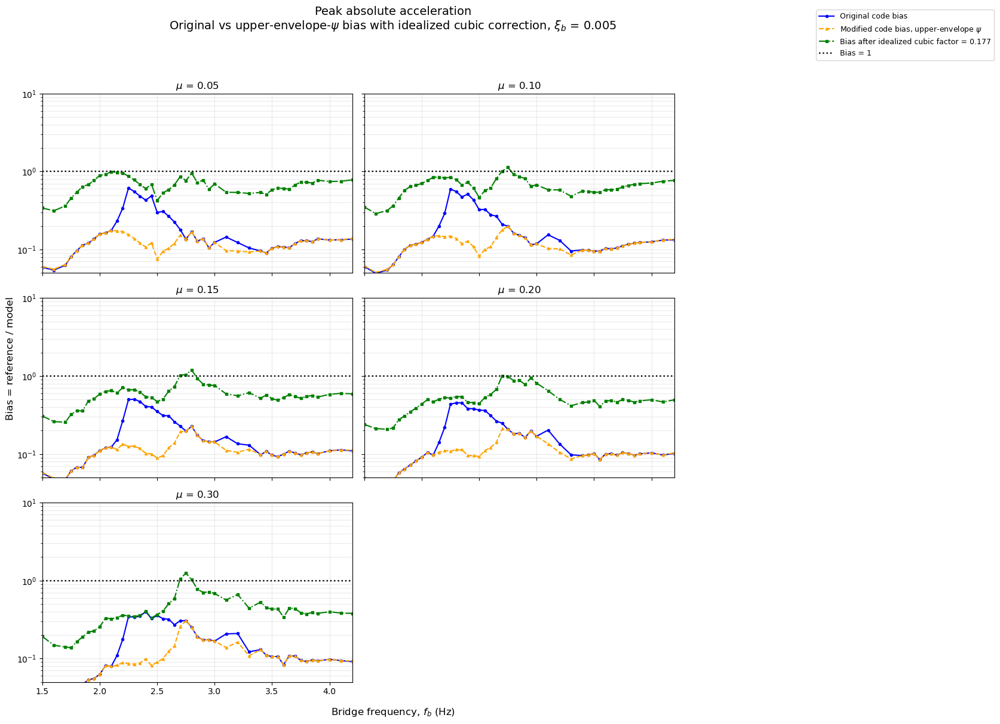

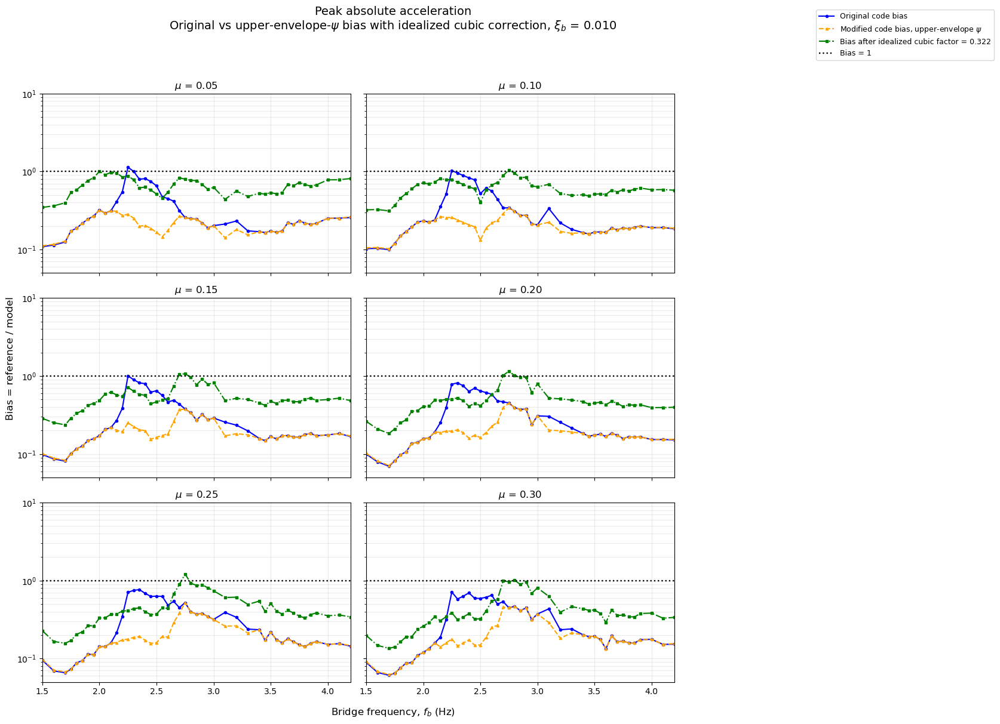

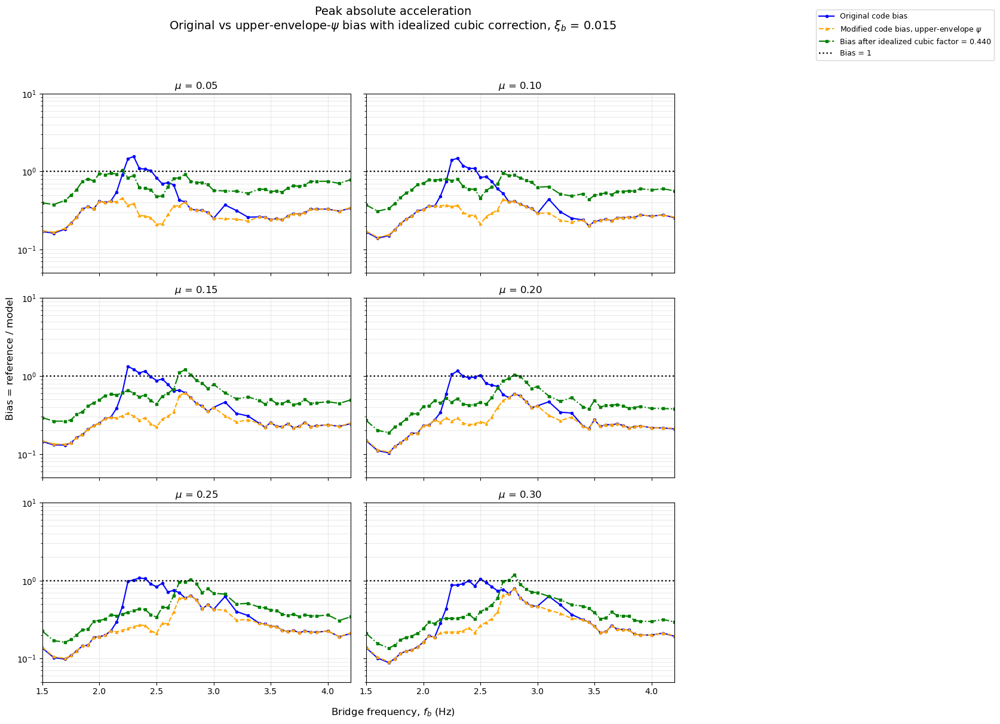

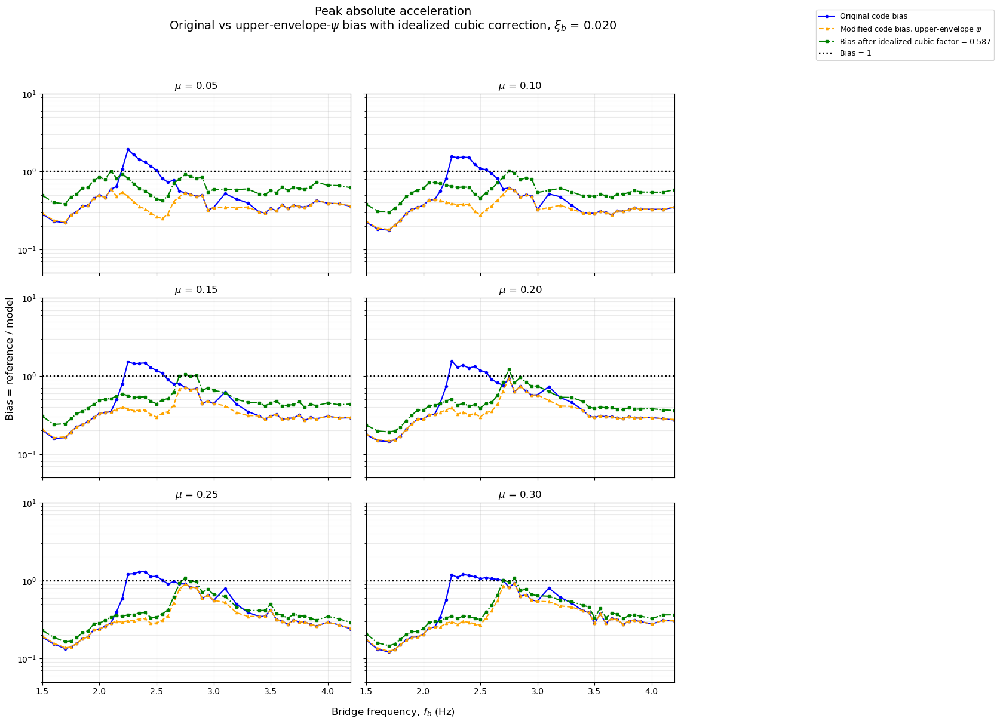

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ==================================================
# SETTINGS
# ==================================================

BIAS_COL_ORIGINAL = "old_bias"
BIAS_COL_MODIFIED = "env_bias"

PERCENTILE_TO_USE = 95

PLOT_FMIN = 1.50
PLOT_FMAX = 4.20

USE_LOG_Y = True
YMIN_LOG = 0.05
YMAX_LOG = 10.0

SAVE_FIGURES = False
FIG_DPI = 300

EXCLUDE_MU_025 = False
# EXCLUDE_MU_025 = True

SAFETY_MARGIN = 0.00
CAP_FACTOR_AT_ONE = True

preferred_mu_order = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]


# ==================================================
# CHECK REQUIRED DATA
# ==================================================

required_cols = [
    "damping_key",
    "mass_ratio",
    "linear_mass_key",
    "bridge_frequency",
    BIAS_COL_ORIGINAL,
    BIAS_COL_MODIFIED,
]

for col in required_cols:
    if col not in compare_df.columns:
        raise KeyError(f"Missing required column in compare_df: {col}")

work_df = compare_df.copy()

for col in required_cols:
    work_df[col] = pd.to_numeric(work_df[col], errors="coerce")

work_df = work_df.dropna(subset=required_cols).copy()

work_df = work_df[
    (work_df["bridge_frequency"] >= PLOT_FMIN) &
    (work_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

if EXCLUDE_MU_025:
    work_df = work_df[~np.isclose(work_df["mass_ratio"], 0.25)].copy()

print("Available damping ratios:")
print(sorted(work_df["damping_key"].unique()))

print("\nAvailable mass ratios:")
print(sorted(work_df["mass_ratio"].unique()))


# ==================================================
# COMPUTE RAW P95 FACTOR FOR EACH DAMPING AND MASS RATIO
# ==================================================

p95_rows = []

for (damp, mu), sub in work_df.groupby(["damping_key", "mass_ratio"]):

    y = sub[BIAS_COL_MODIFIED].to_numpy(dtype=float)
    y = y[np.isfinite(y)]

    if len(y) == 0:
        continue

    p_factor = np.percentile(y, PERCENTILE_TO_USE)

    p95_rows.append({
        "damping_key": float(damp),
        "mass_ratio": float(mu),
        "p95_factor_raw": p_factor,
        "n_points": len(y),
        "modified_bias_mean": np.mean(y),
        "modified_bias_p90": np.percentile(y, 90),
        "modified_bias_p95": np.percentile(y, 95),
        "modified_bias_max": np.max(y),
    })

p95_factor_df = pd.DataFrame(p95_rows)

if p95_factor_df.empty:
    raise ValueError("No P95 factors were calculated.")

p95_factor_df = p95_factor_df.sort_values(
    ["damping_key", "mass_ratio"]
).reset_index(drop=True)

print("\nRaw P95 correction factors:")
print(p95_factor_df.to_string(index=False))


# ==================================================
# FIT ONE CONSERVATIVE CUBIC CURVE PER DAMPING RATIO
# C95(mu) = a*mu^3 + b*mu^2 + c*mu + d
# ==================================================

cubic_rows = []
ideal_factor_rows = []

for damping, sub in p95_factor_df.groupby("damping_key"):

    sub = sub.sort_values("mass_ratio").copy()

    x = sub["mass_ratio"].to_numpy(dtype=float)
    y = sub["p95_factor_raw"].to_numpy(dtype=float)

    if len(x) < 4:
        raise ValueError(
            f"Need at least 4 mass-ratio points for cubic fit at damping = {damping:.3f}"
        )

    a, b, c, d = np.polyfit(x, y, 3)

    # Shift upward so idealized cubic is conservative
    y_fit_at_data = a*x**3 + b*x**2 + c*x + d
    upward_shift = np.max(y - y_fit_at_data)

    d_safe = d + upward_shift + SAFETY_MARGIN

    y_ideal_at_data = a*x**3 + b*x**2 + c*x + d_safe

    if CAP_FACTOR_AT_ONE:
        y_ideal_at_data = np.minimum(y_ideal_at_data, 1.0)

    for mu, raw_factor, ideal_factor in zip(x, y, y_ideal_at_data):
        ideal_factor_rows.append({
            "damping_key": float(damping),
            "mass_ratio": float(mu),
            "p95_factor_raw": float(raw_factor),
            "p95_factor_ideal_cubic": float(ideal_factor),
        })

    cubic_rows.append({
        "damping_key": float(damping),
        "a": a,
        "b": b,
        "c": c,
        "d_safe": d_safe,
        "equation": (
            rf"$C_{{95}} = {a:.3f}\mu^3 "
            rf"+ {b:.3f}\mu^2 "
            rf"+ {c:.3f}\mu "
            rf"+ {d_safe:.3f}$"
        )
    })

ideal_factor_df = pd.DataFrame(ideal_factor_rows)
cubic_equation_df = pd.DataFrame(cubic_rows)

print("\nIdealized cubic correction factors:")
print(ideal_factor_df.to_string(index=False))

print("\nCubic equations:")
print(cubic_equation_df.to_string(index=False))


# ==================================================
# MERGE IDEALIZED CUBIC FACTOR BACK INTO MAIN DATAFRAME
# ==================================================

work_df = work_df.merge(
    ideal_factor_df[
        ["damping_key", "mass_ratio", "p95_factor_raw", "p95_factor_ideal_cubic"]
    ],
    on=["damping_key", "mass_ratio"],
    how="left"
)

if work_df["p95_factor_ideal_cubic"].isna().any():
    raise ValueError("Some rows did not receive an idealized cubic factor after merge.")


# --------------------------------------------------
# New bias after applying idealized cubic correction:
#
# bias_new = env_bias / C95_ideal(mu)
# --------------------------------------------------

work_df["env_bias_idealized_cubic_corrected"] = (
    work_df[BIAS_COL_MODIFIED] / work_df["p95_factor_ideal_cubic"]
)


# ==================================================
# CHECK RESULTING P95 AFTER IDEALIZED CUBIC CORRECTION
# ==================================================

check_df = (
    work_df
    .groupby(["damping_key", "mass_ratio"], as_index=False)
    .agg(
        p95_before=(BIAS_COL_MODIFIED, lambda x: np.percentile(x, 95)),
        raw_p95_factor=("p95_factor_raw", "first"),
        ideal_cubic_factor=("p95_factor_ideal_cubic", "first"),
        p95_after_ideal_cubic=("env_bias_idealized_cubic_corrected", lambda x: np.percentile(x, 95)),
    )
)

print("\nP95 check after idealized cubic correction:")
print(check_df.to_string(index=False))

work_df.to_csv(
    "bias_curves_original_env_and_idealized_cubic_corrected.csv",
    index=False
)

ideal_factor_df.to_csv(
    "p95_factors_idealized_cubic_by_damping_and_mass_ratio.csv",
    index=False
)

cubic_equation_df.to_csv(
    "p95_factor_idealized_cubic_equations_by_damping.csv",
    index=False
)

print("\nSaved: bias_curves_original_env_and_idealized_cubic_corrected.csv")
print("Saved: p95_factors_idealized_cubic_by_damping_and_mass_ratio.csv")
print("Saved: p95_factor_idealized_cubic_equations_by_damping.csv")


# ==================================================
# PLOT: ONE FIGURE PER DAMPING RATIO
# SUBPLOTS = MASS RATIOS
# LINES:
# 1. original code bias
# 2. modified bias with upper-envelope psi
# 3. bias after idealized cubic correction
# ==================================================

for damping in sorted(work_df["damping_key"].unique()):

    damp_df = work_df[np.isclose(work_df["damping_key"], damping)].copy()

    if damp_df.empty:
        continue

    mu_available = sorted(damp_df["mass_ratio"].unique())

    mu_order = [mu for mu in preferred_mu_order if mu in mu_available]
    mu_order += [mu for mu in mu_available if mu not in mu_order]

    n_mu = len(mu_order)

    ncols = 2
    nrows = math.ceil(n_mu / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(13.5, 4.1 * nrows),
        sharex=True,
        sharey=True
    )

    axes = np.asarray(axes).reshape(-1)

    for ax, mu in zip(axes, mu_order):

        sub_mu = damp_df[np.isclose(damp_df["mass_ratio"], mu)].copy()
        sub_mu = sub_mu.sort_values("bridge_frequency")

        if sub_mu.empty:
            ax.set_visible(False)
            continue

        ideal_factor = sub_mu["p95_factor_ideal_cubic"].iloc[0]

        ax.plot(
            sub_mu["bridge_frequency"],
            sub_mu[BIAS_COL_ORIGINAL],
            marker="o",
            markersize=3.0,
            linewidth=1.5,
            color="blue",
            label="Original code bias"
        )

        ax.plot(
            sub_mu["bridge_frequency"],
            sub_mu[BIAS_COL_MODIFIED],
            marker="^",
            markersize=3.0,
            linewidth=1.5,
            linestyle="--",
            color="orange",
            label=r"Modified code bias, upper-envelope $\psi$"
        )

        ax.plot(
            sub_mu["bridge_frequency"],
            sub_mu["env_bias_idealized_cubic_corrected"],
            marker="s",
            markersize=3.0,
            linewidth=1.5,
            linestyle="-.",
            color="green",
            label=rf"Bias after idealized cubic factor = {ideal_factor:.3f}"
        )

        ax.axhline(
            1.0,
            linestyle=":",
            linewidth=1.7,
            color="black",
            label="Bias = 1"
        )

        ax.set_title(rf"$\mu$ = {mu:.2f}")
        ax.grid(True, which="both", alpha=0.25)
        ax.set_xlim(PLOT_FMIN, PLOT_FMAX)

        if USE_LOG_Y:
            ax.set_yscale("log")
            ax.set_ylim(YMIN_LOG, YMAX_LOG)
        else:
            ymax = np.nanmax(
                sub_mu[
                    [
                        BIAS_COL_ORIGINAL,
                        BIAS_COL_MODIFIED,
                        "env_bias_idealized_cubic_corrected"
                    ]
                ].to_numpy()
            )
            ax.set_ylim(0, max(1.2, 1.10 * ymax))

    for j in range(n_mu, len(axes)):
        fig.delaxes(axes[j])

    fig.supxlabel(r"Bridge frequency, $f_b$ (Hz)")
    fig.supylabel("Bias = reference / model")

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        bbox_to_anchor=(1.02, 0.98),
        loc="upper left",
        fontsize=9,
        frameon=True
    )

    fig.suptitle(
        "Peak absolute acceleration\n"
        rf"Original vs upper-envelope-$\psi$ bias with idealized cubic correction, "
        rf"$\xi_b$ = {damping:.3f}",
        fontsize=14
    )

    fig.tight_layout(rect=[0, 0, 0.86, 0.94])

    if SAVE_FIGURES:
        save_name = (
            f"original_vs_upper_env_psi_bias_with_idealized_cubic_correction_"
            f"damping{damping:.3f}.png"
        )

        fig.savefig(save_name, dpi=FIG_DPI, bbox_inches="tight")
        print("Saved:", save_name)

    plt.show()

Using bias column: env_bias
Available damping ratios: [np.float64(0.005), np.float64(0.01), np.float64(0.015), np.float64(0.02)]
Available mass ratios: [np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(0.3)]

Percentile summary:
 damping_key  mass_ratio  n_frequency_points      p50      p75      p90      p95     mean      max
       0.005        0.05                  46 0.120769 0.136904 0.160992 0.169882 0.119601 0.175922
       0.005        0.10                  46 0.115748 0.135405 0.149231 0.159411 0.116096 0.198859
       0.005        0.15                  46 0.108283 0.122252 0.146487 0.188448 0.112188 0.226072
       0.005        0.20                  46 0.101342 0.112862 0.175476 0.194412 0.108297 0.210449
       0.005        0.30                  46 0.094400 0.120613 0.173968 0.236357 0.108266 0.306204
       0.010        0.05                  46 0.213672 0.251611 0.278289 0.304946 0.213378 0.322651
       0.010        0.10    

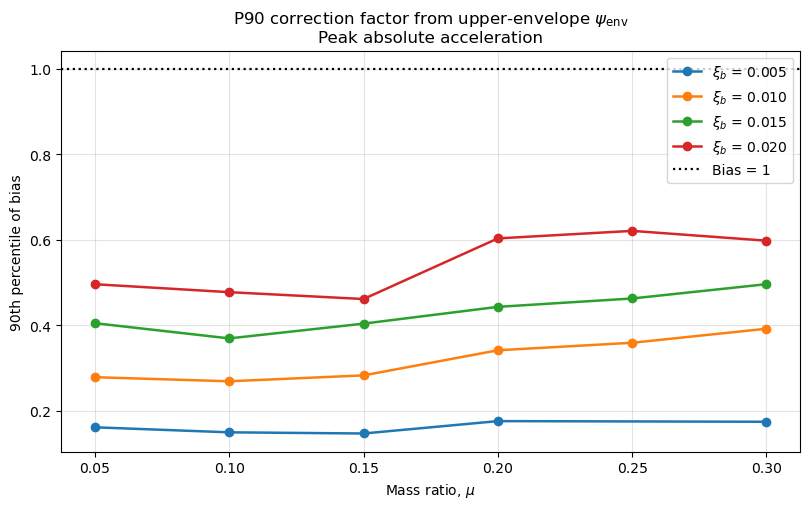

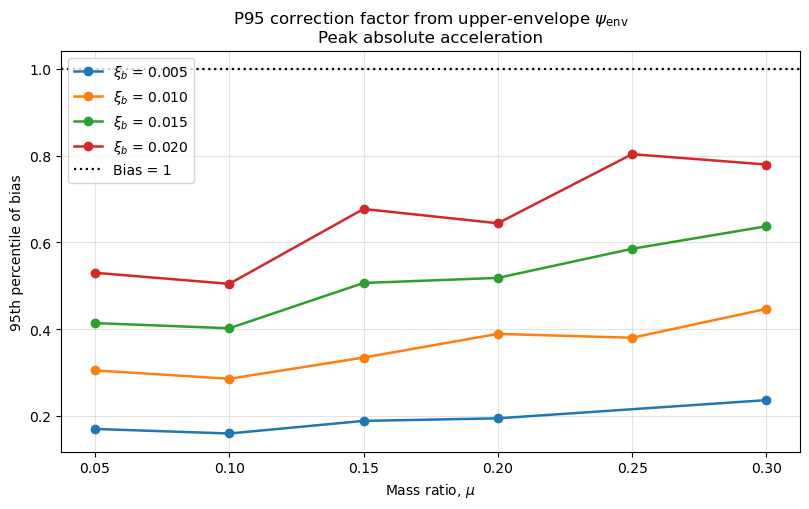

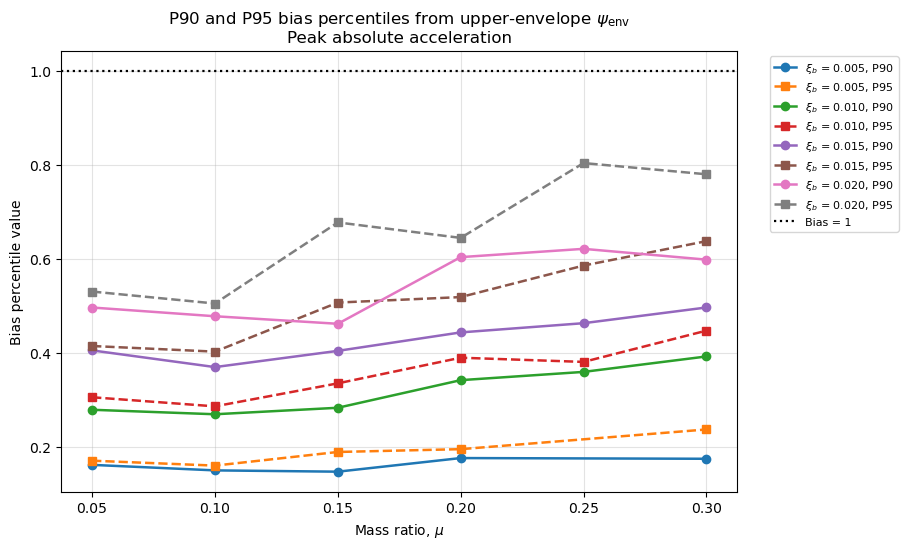

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# SETTINGS
# ==================================================

BIAS_COL = "env_bias"      # upper-envelope-psi bias from your previous code

PERCENTILES = [90, 95]

EXCLUDE_MU_025 = False
# Set True if you do not want mass ratio 0.25 in the final plot
# EXCLUDE_MU_025 = True

SAVE_FIGURES = False
FIG_DPI = 300

preferred_mu_order = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]


# ==================================================
# CHECK DATAFRAME
# ==================================================

required_cols = [
    "damping_key",
    "mass_ratio",
    "bridge_frequency",
    BIAS_COL,
]

for col in required_cols:
    if col not in compare_df.columns:
        raise KeyError(f"Missing column in compare_df: {col}")

work_df = compare_df.copy()

work_df["damping_key"] = pd.to_numeric(work_df["damping_key"], errors="coerce")
work_df["mass_ratio"] = pd.to_numeric(work_df["mass_ratio"], errors="coerce")
work_df["bridge_frequency"] = pd.to_numeric(work_df["bridge_frequency"], errors="coerce")
work_df[BIAS_COL] = pd.to_numeric(work_df[BIAS_COL], errors="coerce")

work_df = work_df.dropna(subset=required_cols).copy()

if EXCLUDE_MU_025:
    work_df = work_df[~np.isclose(work_df["mass_ratio"], 0.25)].copy()

print("Using bias column:", BIAS_COL)
print("Available damping ratios:", sorted(work_df["damping_key"].unique()))
print("Available mass ratios:", sorted(work_df["mass_ratio"].unique()))


# ==================================================
# COMPUTE PERCENTILES FOR EACH DAMPING AND MASS RATIO
# ==================================================

rows = []

for (damp, mu), sub in work_df.groupby(["damping_key", "mass_ratio"]):

    y = sub[BIAS_COL].to_numpy(dtype=float)
    y = y[np.isfinite(y)]

    if len(y) == 0:
        continue

    rows.append({
        "damping_key": float(damp),
        "mass_ratio": float(mu),
        "n_frequency_points": len(y),
        "p50": np.percentile(y, 50),
        "p75": np.percentile(y, 75),
        "p90": np.percentile(y, 90),
        "p95": np.percentile(y, 95),
        "mean": np.mean(y),
        "max": np.max(y),
    })

percentile_df = pd.DataFrame(rows)

if percentile_df.empty:
    raise ValueError("No percentile values were calculated.")

# Sort mass ratios in preferred order
mu_available = sorted(percentile_df["mass_ratio"].unique())
mu_order = [mu for mu in preferred_mu_order if mu in mu_available]
mu_order += [mu for mu in mu_available if mu not in mu_order]

percentile_df["mass_ratio_ordered"] = pd.Categorical(
    percentile_df["mass_ratio"],
    categories=mu_order,
    ordered=True
)

percentile_df = percentile_df.sort_values(
    ["damping_key", "mass_ratio_ordered"]
).reset_index(drop=True)

print("\nPercentile summary:")
print(percentile_df.drop(columns=["mass_ratio_ordered"]).to_string(index=False))

percentile_df.drop(columns=["mass_ratio_ordered"]).to_csv(
    "upper_envelope_psi_bias_percentiles_by_damping_and_mass_ratio.csv",
    index=False
)

print("\nSaved: upper_envelope_psi_bias_percentiles_by_damping_and_mass_ratio.csv")


# ==================================================
# PLOT P90 VS MASS RATIO
# One line per damping ratio
# ==================================================

plt.figure(figsize=(8.2, 5.2))

for damp in sorted(percentile_df["damping_key"].unique()):

    sub = percentile_df[
        np.isclose(percentile_df["damping_key"], damp)
    ].copy()

    sub = sub.sort_values("mass_ratio_ordered")

    plt.plot(
        sub["mass_ratio"].astype(float),
        sub["p90"],
        marker="o",
        linewidth=1.8,
        label=rf"$\xi_b$ = {damp:.3f}"
    )

plt.axhline(
    1.0,
    linestyle=":",
    linewidth=1.6,
    color="black",
    label="Bias = 1"
)

plt.xlabel(r"Mass ratio, $\mu$")
plt.ylabel("90th percentile of bias")

plt.title(
    r"P90 correction factor from upper-envelope $\psi_{\mathrm{env}}$"
    "\n"
    "Peak absolute acceleration"
)

plt.grid(True, alpha=0.35)
plt.legend(loc="best")
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(
        "p90_upper_envelope_psi_bias_vs_mass_ratio.png",
        dpi=FIG_DPI,
        bbox_inches="tight"
    )

plt.show()


# ==================================================
# PLOT P95 VS MASS RATIO
# One line per damping ratio
# ==================================================

plt.figure(figsize=(8.2, 5.2))

for damp in sorted(percentile_df["damping_key"].unique()):

    sub = percentile_df[
        np.isclose(percentile_df["damping_key"], damp)
    ].copy()

    sub = sub.sort_values("mass_ratio_ordered")

    plt.plot(
        sub["mass_ratio"].astype(float),
        sub["p95"],
        marker="o",
        linewidth=1.8,
        label=rf"$\xi_b$ = {damp:.3f}"
    )

plt.axhline(
    1.0,
    linestyle=":",
    linewidth=1.6,
    color="black",
    label="Bias = 1"
)

plt.xlabel(r"Mass ratio, $\mu$")
plt.ylabel("95th percentile of bias")

plt.title(
    r"P95 correction factor from upper-envelope $\psi_{\mathrm{env}}$"
    "\n"
    "Peak absolute acceleration"
)

plt.grid(True, alpha=0.35)
plt.legend(loc="best")
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(
        "p95_upper_envelope_psi_bias_vs_mass_ratio.png",
        dpi=FIG_DPI,
        bbox_inches="tight"
    )

plt.show()


# ==================================================
# OPTIONAL: P90 AND P95 TOGETHER
# Solid = P90, dashed = P95
# ==================================================

plt.figure(figsize=(9.2, 5.6))

for damp in sorted(percentile_df["damping_key"].unique()):

    sub = percentile_df[
        np.isclose(percentile_df["damping_key"], damp)
    ].copy()

    sub = sub.sort_values("mass_ratio_ordered")

    x = sub["mass_ratio"].astype(float).to_numpy()

    plt.plot(
        x,
        sub["p90"],
        marker="o",
        linewidth=1.8,
        label=rf"$\xi_b$ = {damp:.3f}, P90"
    )

    plt.plot(
        x,
        sub["p95"],
        marker="s",
        linestyle="--",
        linewidth=1.8,
        label=rf"$\xi_b$ = {damp:.3f}, P95"
    )

plt.axhline(
    1.0,
    linestyle=":",
    linewidth=1.6,
    color="black",
    label="Bias = 1"
)

plt.xlabel(r"Mass ratio, $\mu$")
plt.ylabel("Bias percentile value")

plt.title(
    r"P90 and P95 bias percentiles from upper-envelope $\psi_{\mathrm{env}}$"
    "\n"
    "Peak absolute acceleration"
)

plt.grid(True, alpha=0.35)
plt.legend(
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(
        "p90_p95_upper_envelope_psi_bias_vs_mass_ratio.png",
        dpi=FIG_DPI,
        bbox_inches="tight"
    )

plt.show()

Available damping ratios:
[np.float64(0.005), np.float64(0.01), np.float64(0.015), np.float64(0.02)]

Available mass ratios:
[np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(0.3)]

P95 correction factors:
 damping_key  mass_ratio  p95_factor  n_points  modified_bias_mean  modified_bias_p90  modified_bias_p95  modified_bias_max
       0.005        0.05    0.169882        46            0.119601           0.160992           0.169882           0.175922
       0.005        0.10    0.159411        46            0.116096           0.149231           0.159411           0.198859
       0.005        0.15    0.188448        46            0.112188           0.146487           0.188448           0.226072
       0.005        0.20    0.194412        46            0.108297           0.175476           0.194412           0.210449
       0.005        0.30    0.236357        46            0.108266           0.173968           0.236357           0.306204


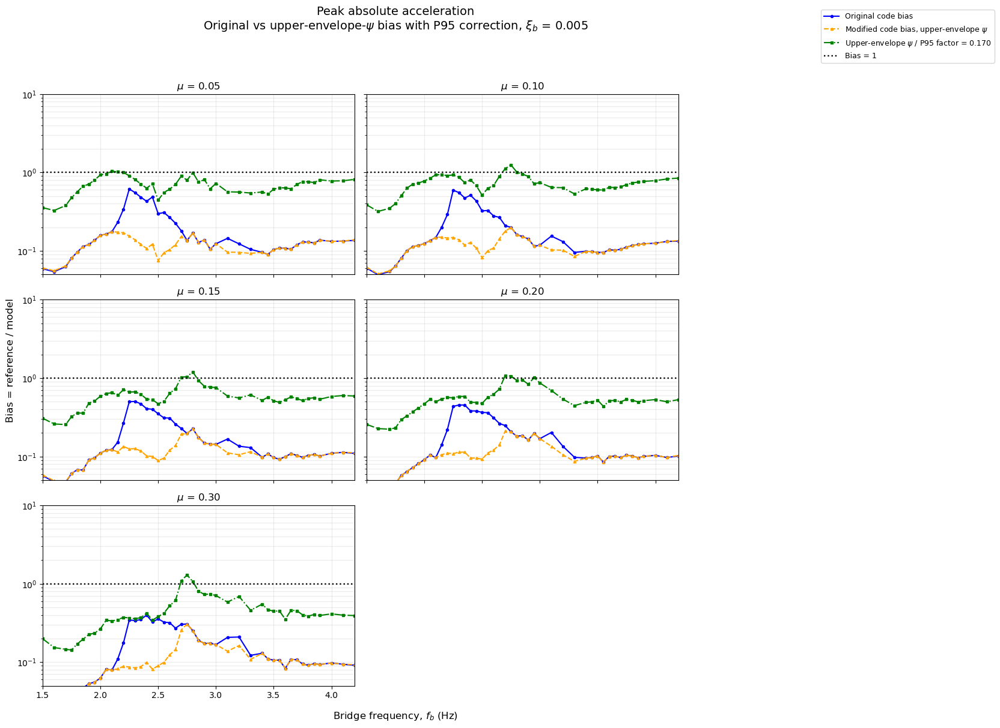

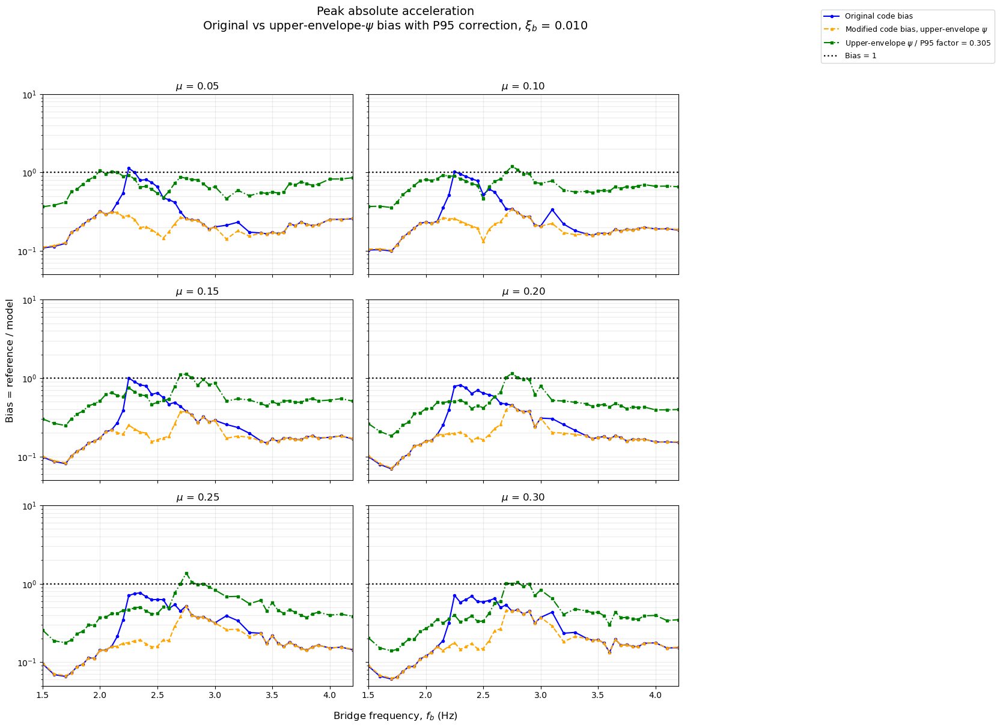

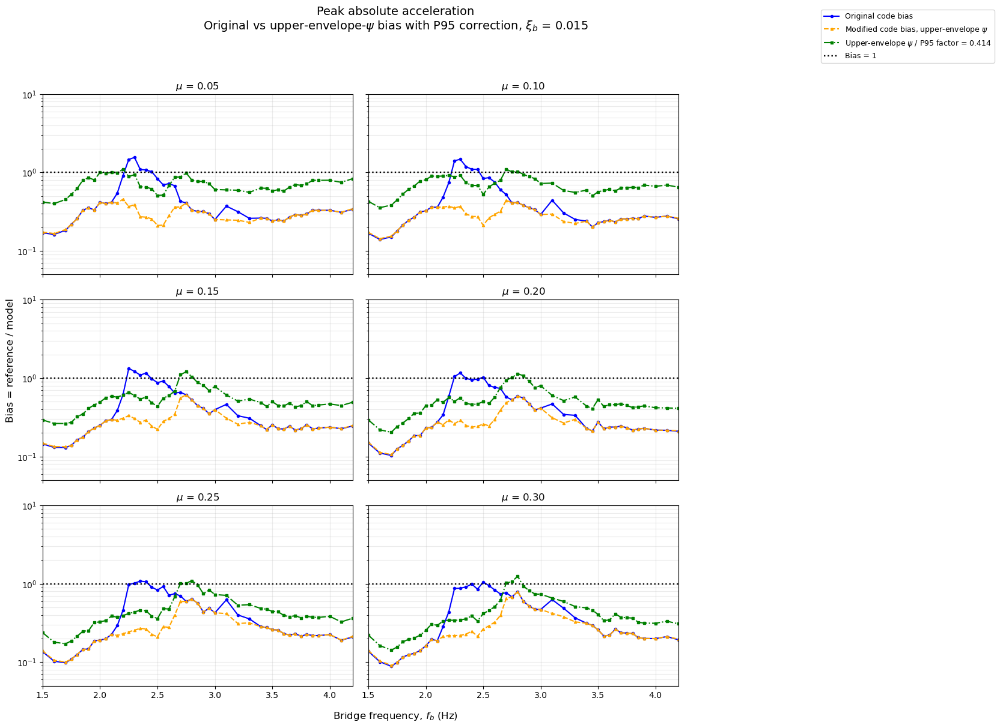

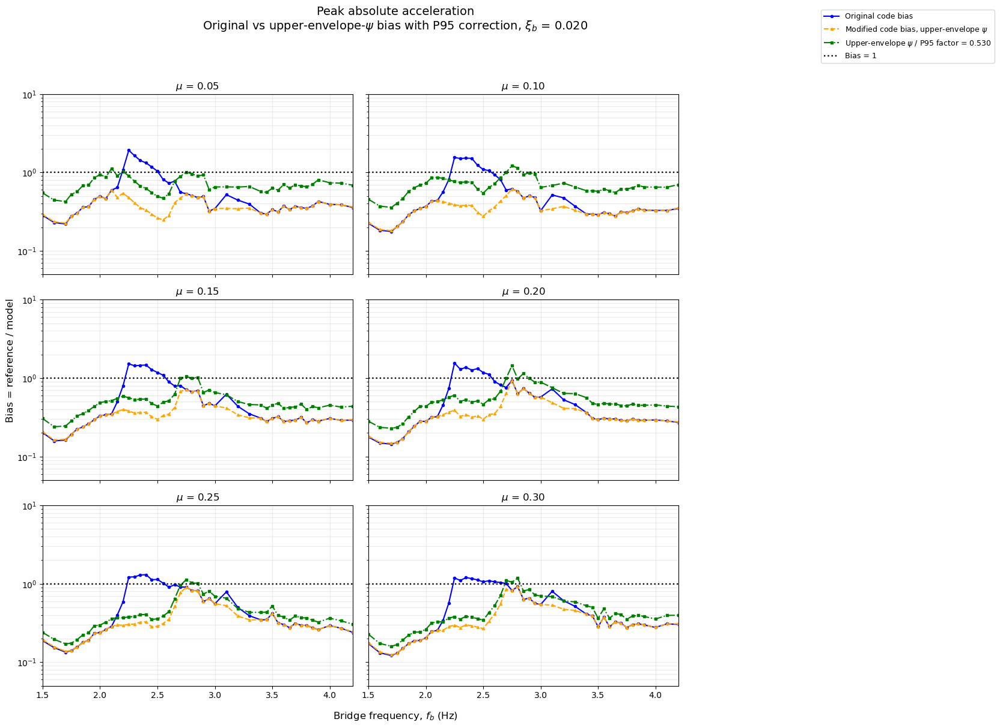

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ==================================================
# SETTINGS
# ==================================================

BIAS_COL_ORIGINAL = "old_bias"
BIAS_COL_MODIFIED = "env_bias"

PERCENTILE_TO_USE = 95

PLOT_FMIN = 1.50
PLOT_FMAX = 4.20

USE_LOG_Y = True

YMIN_LOG = 0.05
YMAX_LOG = 10.0

SAVE_FIGURES = False
FIG_DPI = 300

EXCLUDE_MU_025 = False
# EXCLUDE_MU_025 = True

preferred_mu_order = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]


# ==================================================
# CHECK REQUIRED DATA
# ==================================================

required_cols = [
    "damping_key",
    "mass_ratio",
    "linear_mass_key",
    "bridge_frequency",
    BIAS_COL_ORIGINAL,
    BIAS_COL_MODIFIED,
]

for col in required_cols:
    if col not in compare_df.columns:
        raise KeyError(f"Missing required column in compare_df: {col}")

work_df = compare_df.copy()

for col in required_cols:
    work_df[col] = pd.to_numeric(work_df[col], errors="coerce")

work_df = work_df.dropna(subset=required_cols).copy()

work_df = work_df[
    (work_df["bridge_frequency"] >= PLOT_FMIN) &
    (work_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

if EXCLUDE_MU_025:
    work_df = work_df[~np.isclose(work_df["mass_ratio"], 0.25)].copy()

print("Available damping ratios:")
print(sorted(work_df["damping_key"].unique()))

print("\nAvailable mass ratios:")
print(sorted(work_df["mass_ratio"].unique()))


# ==================================================
# COMPUTE P95 FACTOR FOR EACH DAMPING AND MASS RATIO
# ==================================================

p95_rows = []

for (damp, mu), sub in work_df.groupby(["damping_key", "mass_ratio"]):

    y = sub[BIAS_COL_MODIFIED].to_numpy(dtype=float)
    y = y[np.isfinite(y)]

    if len(y) == 0:
        continue

    p_factor = np.percentile(y, PERCENTILE_TO_USE)

    p95_rows.append({
        "damping_key": float(damp),
        "mass_ratio": float(mu),
        "p95_factor": p_factor,
        "n_points": len(y),
        "modified_bias_mean": np.mean(y),
        "modified_bias_p90": np.percentile(y, 90),
        "modified_bias_p95": np.percentile(y, 95),
        "modified_bias_max": np.max(y),
    })

p95_factor_df = pd.DataFrame(p95_rows)

if p95_factor_df.empty:
    raise ValueError("No P95 factors were calculated.")

p95_factor_df = p95_factor_df.sort_values(
    ["damping_key", "mass_ratio"]
).reset_index(drop=True)

print("\nP95 correction factors:")
print(p95_factor_df.to_string(index=False))

p95_factor_df.to_csv(
    "p95_factors_upper_envelope_psi_by_damping_and_mass_ratio.csv",
    index=False
)

print("\nSaved: p95_factors_upper_envelope_psi_by_damping_and_mass_ratio.csv")


# ==================================================
# MERGE P95 FACTOR BACK INTO MAIN DATAFRAME
# ==================================================

work_df = work_df.merge(
    p95_factor_df[["damping_key", "mass_ratio", "p95_factor"]],
    on=["damping_key", "mass_ratio"],
    how="left"
)

if work_df["p95_factor"].isna().any():
    raise ValueError("Some rows did not receive a P95 factor after merge.")

# --------------------------------------------------
# If model is multiplied by p95_factor:
#
# bias_corrected = reference / (model_modified * p95_factor)
#                = env_bias / p95_factor
# --------------------------------------------------

work_df["env_bias_p95_corrected"] = (
    work_df[BIAS_COL_MODIFIED] / work_df["p95_factor"]
)

# Check resulting P95 should be 1 for each damping and mass ratio
check_df = (
    work_df
    .groupby(["damping_key", "mass_ratio"], as_index=False)
    .agg(
        p95_before=(BIAS_COL_MODIFIED, lambda x: np.percentile(x, 95)),
        p95_factor=("p95_factor", "first"),
        p95_after=("env_bias_p95_corrected", lambda x: np.percentile(x, 95)),
    )
)

print("\nP95 check after correction:")
print(check_df.to_string(index=False))

work_df.to_csv(
    "bias_curves_original_env_and_p95_corrected.csv",
    index=False
)

print("\nSaved: bias_curves_original_env_and_p95_corrected.csv")


# ==================================================
# PLOT: ONE FIGURE PER DAMPING RATIO
# SUBPLOTS = MASS RATIOS
# LINES:
# 1. original code bias
# 2. modified bias with upper-envelope psi
# 3. modified load model with upper-envelope psi and P95 factor
# ==================================================

for damping in sorted(work_df["damping_key"].unique()):

    damp_df = work_df[
        np.isclose(work_df["damping_key"], damping)
    ].copy()

    if damp_df.empty:
        continue

    mu_available = sorted(damp_df["mass_ratio"].unique())

    mu_order = [mu for mu in preferred_mu_order if mu in mu_available]
    mu_order += [mu for mu in mu_available if mu not in mu_order]

    n_mu = len(mu_order)

    ncols = 2
    nrows = math.ceil(n_mu / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(13.5, 4.1 * nrows),
        sharex=True,
        sharey=True
    )

    axes = np.asarray(axes).reshape(-1)

    for ax, mu in zip(axes, mu_order):

        sub_mu = damp_df[
            np.isclose(damp_df["mass_ratio"], mu)
        ].copy()

        sub_mu = sub_mu.sort_values("bridge_frequency")

        if sub_mu.empty:
            ax.set_visible(False)
            continue

        p95_factor = sub_mu["p95_factor"].iloc[0]

        ax.plot(
            sub_mu["bridge_frequency"],
            sub_mu[BIAS_COL_ORIGINAL],
            marker="o",
            markersize=3.0,
            linewidth=1.5,
            color="blue",
            label="Original code bias"
        )

        ax.plot(
            sub_mu["bridge_frequency"],
            sub_mu[BIAS_COL_MODIFIED],
            marker="^",
            markersize=3.0,
            linewidth=1.5,
            linestyle="--",
            color="orange",
            label=r"Modified code bias, upper-envelope $\psi$"
        )

        ax.plot(
            sub_mu["bridge_frequency"],
            sub_mu["env_bias_p95_corrected"],
            marker="s",
            markersize=3.0,
            linewidth=1.5,
            linestyle="-.",
            color="green",
            label=rf"Upper-envelope $\psi$ / P95 factor = {p95_factor:.3f}"
        )

        ax.axhline(
            1.0,
            linestyle=":",
            linewidth=1.7,
            color="black",
            label="Bias = 1"
        )

        ax.set_title(rf"$\mu$ = {mu:.2f}")

        ax.grid(True, which="both", alpha=0.25)

        ax.set_xlim(PLOT_FMIN, PLOT_FMAX)

        if USE_LOG_Y:
            ax.set_yscale("log")
            ax.set_ylim(YMIN_LOG, YMAX_LOG)
        else:
            ymax = np.nanmax(
                sub_mu[
                    [
                        BIAS_COL_ORIGINAL,
                        BIAS_COL_MODIFIED,
                        "env_bias_p95_corrected"
                    ]
                ].to_numpy()
            )
            ax.set_ylim(0, max(1.2, 1.10 * ymax))

    # Remove unused axes
    for j in range(n_mu, len(axes)):
        fig.delaxes(axes[j])

    # Shared labels
    fig.supxlabel(r"Bridge frequency, $f_b$ (Hz)")
    fig.supylabel("Bias = reference / model")

    # One common legend
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        bbox_to_anchor=(1.02, 0.98),
        loc="upper left",
        fontsize=9,
        frameon=True
    )

    fig.suptitle(
        "Peak absolute acceleration\n"
        rf"Original vs upper-envelope-$\psi$ bias with P95 correction, "
        rf"$\xi_b$ = {damping:.3f}",
        fontsize=14
    )

    fig.tight_layout(rect=[0, 0, 0.86, 0.94])

    if SAVE_FIGURES:
        save_name = (
            f"original_vs_upper_env_psi_bias_with_p95_correction_"
            f"damping{damping:.3f}.png"
        )

        fig.savefig(
            save_name,
            dpi=FIG_DPI,
            bbox_inches="tight"
        )

        print("Saved:", save_name)

    plt.show()